In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [27]:
# Đọc dữ liệu từ file Excel
df = pd.read_excel("final dataset.xlsx")
# Hiển thị 5 dòng đầu tiên của DataFrame
df.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q40g,Q40h,Q40i,Q40j,Q40k,Q40l,Q40m,Q40n,Q40o,source
0,Afghanistan,2.0,27.0,Afghanistan,القدس المفتوحة,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AR
1,Afghanistan,4.0,100.0,Afghanistan,456,2.0,2.0,3.0,2.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EN
2,Afghanistan,1.0,21.0,Albania,منيا,1.0,1.0,1.0,1.0,1.0,...,3.0,2.0,3.0,4.0,3.0,2.0,2.0,1.0,1.0,EN
3,Afghanistan,1.0,18.0,Ecuador,"Universidad Indoamerica., Facultad Arquitectur...",2.0,1.0,1.0,1.0,4.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,ES
4,Afghanistan,2.0,26.0,Spain,De vigo universidad,1.0,2.0,2.0,1.0,2.0,...,4.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,4.0,ES


In [3]:
# Tổng quan về dữ liệu
df.info()

# Kiểm tra số dòng và số cột
print(f"Số dòng: {df.shape[0]}\nSố cột: {df.shape[1]}")

# Kiểm tra tên cột
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23218 entries, 0 to 23217
Columns: 174 entries, Q1 to source
dtypes: float64(170), object(4)
memory usage: 30.8+ MB
Số dòng: 23218
Số cột: 174
['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18a', 'Q18b', 'Q18c', 'Q18d', 'Q18e', 'Q18f', 'Q18g', 'Q18h', 'Q18i', 'Q18j', 'Q18k', 'Q18l', 'Q19a', 'Q19b', 'Q19c', 'Q19d', 'Q19e', 'Q19f', 'Q19g', 'Q19h', 'Q19i', 'Q19j', 'Q20', 'Q21a', 'Q21b', 'Q21c', 'Q21d', 'Q22a', 'Q22b', 'Q22c', 'Q22d', 'Q22e', 'Q22f', 'Q22g', 'Q22h', 'Q22i', 'Q22j', 'Q23a', 'Q23b', 'Q23c', 'Q23d', 'Q24a', 'Q24b', 'Q24c', 'Q24d', 'Q24e', 'Q24f', 'Q24g', 'Q25a', 'Q25b', 'Q25c', 'Q25d', 'Q26a', 'Q26b', 'Q26c', 'Q26d', 'Q26e', 'Q26f', 'Q26g', 'Q26h', 'Q26i', 'Q26j', 'Q27a', 'Q27b', 'Q27c', 'Q27d', 'Q27e', 'Q27f', 'Q27g', 'Q27h', 'Q27i', 'Q27j', 'Q28a', 'Q28b', 'Q28c', 'Q28d', 'Q28e', 'Q28f', 'Q28g', 'Q28h', 'Q28i', 'Q29a', 'Q29b', 'Q29c', 'Q29d', 'Q29e', 'Q29f', '

In [4]:
# Thống kê số lượng giá tri thiếu
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Số lượng giá trị thiếu trong từng cột:")
print(missing_values)

Số lượng giá trị thiếu trong từng cột:
Q32i    10777
Q32d    10777
Q32g    10777
Q32j    10774
Q32m    10774
        ...  
Q7        455
Q12       450
Q4        301
Q3        212
Q2        168
Length: 173, dtype: int64


In [28]:
df = df.dropna(how='all')  # loại bỏ dòng nếu tất cả cột đều NaN
q13_to_q18l = ['Q13', 'Q14', 'Q15', 'Q16', 'Q17'] + [f"Q18{c}" for c in "abcdefghijkl"]
q19 = [f"Q19{c}" for c in "abcdefghij"]
q20_23 = ['Q20'] + [f"Q21{c}" for c in "abcd"] + [f"Q22{c}" for c in "abcdefghij"] + [f"Q23{c}" for c in "abcd"]
q24_25 = [f"Q24{c}" for c in "abcdefg"] + [f"Q25{c}" for c in "abcd"]
q26_27 = [f"Q26{c}" for c in "abcdefghij"] + [f"Q27{c}" for c in "abcdefghij"]
q28_29 = [f"Q28{c}" for c in "abcdefghi"] + [f"Q29{c}" for c in "abcdefghi"]
q30_31 = [f"Q30{c}" for c in "abcdefghijkl"] + [f"Q31{c}" for c in "abcd"]
q32 = [f"Q32{c}" for c in "abcdefghijklmno"]
q33_40 = ['Q33', 'Q34'] + [f"Q35{c}" for c in "abcdefghijklmno"] + ['Q36', 'Q37', 'Q38', 'Q39'] + [f"Q40{c}" for c in "abcdefghijklmno"]

In [29]:
cols_q13_q40o = (
    ['Q13', 'Q14', 'Q15', 'Q16', 'Q17'] + 
    [f"Q18{c}" for c in "abcdefghijkl"] +
    [f"Q19{c}" for c in "abcdefghij"] +
    ['Q20'] +
    [f"Q21{c}" for c in "abcd"] +
    [f"Q22{c}" for c in "abcdefghij"] +
    [f"Q23{c}" for c in "abcd"] +
    [f"Q24{c}" for c in "abcdefg"] +
    [f"Q25{c}" for c in "abcd"] +
    [f"Q26{c}" for c in "abcdefghij"] +
    [f"Q27{c}" for c in "abcdefghij"] +
    [f"Q28{c}" for c in "abcdefghi"] +
    [f"Q29{c}" for c in "abcdefghi"] +
    [f"Q30{c}" for c in "abcdefghijkl"] +
    [f"Q31{c}" for c in "abcd"] +
    [f"Q32{c}" for c in "abcdefghijklmno"] +
    ['Q33', 'Q34'] +
    [f"Q35{c}" for c in "abcdefghijklmno"] +
    ['Q36', 'Q37', 'Q38', 'Q39'] +
    [f"Q40{c}" for c in "abcdefghijklmno"]
)

def is_empty_q13_q40o(row):
    for col in cols_q13_q40o:
        val = row.get(col, None)
        if isinstance(val, str):
            if val.strip() != "" and val.strip().lower() != "không trả lời":
                return False  # có ít nhất một câu trả lời hợp lệ
        elif pd.notna(val):  # nếu không phải chuỗi mà vẫn có giá trị
            return False
    return True  # tất cả đều bị bỏ trống hoặc không hợp lệ

df = df[~df.apply(is_empty_q13_q40o, axis=1)].copy()
print(df.shape[0])

22477


In [30]:
rename_dict = {
    'Q1': 'Citizenship',
    'Q2': 'Gender',
    'Q3': 'Age',
    'Q4': 'Study_Country',
    'Q5': 'Institution_Name',
    'Q6': 'Institution_Public',
    'Q7': 'Student_Status',
    'Q8': 'Level_Of_Study',
    'Q9': 'First_Year_Student',
    'Q10': 'Field_Of_Study',
    'Q11': 'Learning_Method',
    'Q12': 'Job_Confidence',

    'Q13': 'Used_ChatGPT',
    'Q14': 'ChatGPT_Version',
    'Q15': 'Usage_Frequency',
    'Q16': 'Overall_Experience',
    'Q17': 'How_Did_You_Learn_About_ChatGPT',

    **{f'Q18{c}': f'Usage_{desc}' for c, desc in zip("abcdefghijkl", [
        'Academic_Writing', 'Professional_Writing', 'Creative_Writing', 'Proofreading', 'Brainstorming',
        'Translating', 'Summarizing', 'Calculating_Help', 'Study_Assistance',
        'Personal_Assistance', 'Research_Assistance', 'Coding_Assistance'
    ])},

    **{f'Q19{c}': f'Capability_{desc}' for c, desc in zip("abcdefghij", [
        'Understand_Human_Language', 'Respond_Human_Language', 'Pleasant_Conversation', 'Provide_Information_Efficiently',
        'Provide_Reliable_Information', 'Summarize_Info', 'Simplify_Complex_Info', 'Facilitate_Traditional_Learning',
        'Facilitate_Online_Learning', 'Facilitate_Blended_Learning'
    ])},

    'Q20': 'Institution_Has_Policy',

    **{f'Q21{c}': f'Regulation_{desc}' for c, desc in zip("abcd", [
        'Need_International_Regulation', 'Need_Gov_Regulation', 'Need_University_Guidelines', 'Need_Employer_Guidelines'
    ])},

    **{f'Q22{c}': f'Ethical_Concern_{desc}' for c, desc in zip("abcdefghij", [
        'Encourage_Unethical_Behavior', 'Encourage_Cheating', 'Encourage_Plagiarism', 'Threaten_Ethics',
        'Mislead_Info', 'Invade_Privacy', 'Reduce_Interaction', 'Replace_Education',
        'Increase_Isolation', 'Hinder_Learning'
    ])},

    **{f'Q23{c}': f'Student_Ethics_{desc}' for c, desc in zip("abcd", [
        'Consult_Professors', 'Disclose_Use', 'Report_Misuse', 'Protect_Personal_Info'
    ])},

    **{f'Q24{c}': f'Satisfaction_{desc}' for c, desc in zip("abcdefg", [
        'More_Useful_Than_Google', 'Easier_Than_Professors', 'Easier_Than_Colleagues',
        'Clearer_Than_Professors', 'Satisfied_Assistance', 'Satisfied_Quality', 'Satisfied_Accuracy'
    ])},

    **{f'Q25{c}': f'Attitude_{desc}' for c, desc in zip("abcd", [
        'Using_Under_Control', 'Interesting', 'Important_To_Use', 'Helps_Everyday_Life'
    ])},

    **{f'Q26{c}': f'Learning_{desc}' for c, desc in zip("abcdefghij", [
        'Enhance_Knowledge_Sources', 'Improve_General_Knowledge', 'Improve_Specific_Knowledge',
        'Personalized_Education', 'Study_Efficiency', 'Motivation', 'Complete_Studies',
        'Class_Engagement', 'Meet_Deadlines', 'Improve_Assignment_Quality'
    ])},

    **{f'Q27{c}': f'Development_{desc}' for c, desc in zip("abcdefghij", [
        'Exam_Readiness', 'Improve_Grades', 'Complete_Outside_Activities', 'Complete_Internships',
        'Learning_Experience', 'Improve_Skills', 'Personal_Development', 'Academic_Development',
        'Study_Satisfaction', 'Improve_Employability'
    ])},

    **{f'Q28{c}': f'Skills_Proficiency_{desc}' for c, desc in zip("abcdefghi", [
        'Academic_Writing', 'Professional_Writing', 'Typing', 'Native_Language',
        'Foreign_Language', 'Interpersonal_Communication', 'Digital_Communication',
        'Information_Literacy', 'Digital_Content_Creation'
    ])},

    **{f'Q29{c}': f'Skills_Analytical_{desc}' for c, desc in zip("abcdefghi", [
        'Numeracy', 'Decision_Making', 'Problem_Solving', 'Analytical', 'Critical_Thinking',
        'Creativity', 'Data_Analysis', 'Programming', 'AI_Literacy'
    ])},

    **{f'Q30{c}': f'LabourMarket_{desc}' for c, desc in zip("abcdefghijkl", [
        'Reduce_Jobs', 'Require_New_Skills', 'Enhance_Edu_Labour_Link', 'Need_AI_Knowledge',
        'Demand_AI_Skills', 'Increase_Young_Old_Inequality', 'Create_New_Jobs', 'Change_Job_Nature',
        'Facilitate_Remote_Work', 'Reduce_Workload', 'Improve_Productivity', 'Improve_Innovation'
    ])},

    **{f'Q31{c}': f'SkillsMismatch_{desc}' for c, desc in zip("abcd", [
        'Reduce_Skills_Shortage', 'Reduce_Underskilling', 'Resolve_Skills_Obsolescence', 'Resolve_Skills_Gap'
    ])},

    **{f'Q32{c}': f'Emotion_{desc}' for c, desc in zip("abcdefghijklmno", [
        'Bored', 'Hopeful', 'Sad', 'Ashamed', 'Calm', 'Angry', 'Relieved',
        'Happy', 'Proud', 'Anxious', 'Surprised', 'Curious', 'Excited', 'Confused', 'Frustrated'
    ])},

    'Q33': 'Study_Difficulty',
    'Q34': 'Preferred_Learning_Method',

    **{f'Q35{c}': f'Study_Info_{desc}' for c, desc in zip("abcdefghijklmno", [
        'Successful', 'Attend_Classes', 'Meet_Deadlines', 'Grades_Reflect_Knowledge', 'Motivated_To_Study',
        'Enough_Financial_Aid', 'Taxes_Too_High', 'Strong_Social_Network', 'Strong_Skill_Set',
        'Enough_Work_Experience', 'Enough_General_Knowledge', 'Enough_Specific_Knowledge',
        'Faculty_Enhances_Employability', 'Want_Job_In_Field', 'Personal_Satisfaction'
    ])},

    'Q36': 'Living_Area',
    'Q37': 'Financial_Aid',
    'Q38': 'Have_Job',
    'Q39': 'Economic_Status',

    **{f'Q40{c}': f'Personality_{desc}' for c, desc in zip("abcdefghijklmno", [
        'Sociable', 'Helpful', 'Neat', 'Handles_Stress_Well', 'Curious', 'Determined',
        'Respectful', 'Persistent', 'Secure', 'Values_Art', 'Energetic', 'Optimistic',
        'Dependable', 'Emotionally_Stable', 'Creative'
    ])}
}

df = df.rename(columns=rename_dict)
print(df.columns.tolist())

['Citizenship', 'Gender', 'Age', 'Study_Country', 'Institution_Name', 'Institution_Public', 'Student_Status', 'Level_Of_Study', 'First_Year_Student', 'Field_Of_Study', 'Learning_Method', 'Job_Confidence', 'Used_ChatGPT', 'ChatGPT_Version', 'Usage_Frequency', 'Overall_Experience', 'How_Did_You_Learn_About_ChatGPT', 'Usage_Academic_Writing', 'Usage_Professional_Writing', 'Usage_Creative_Writing', 'Usage_Proofreading', 'Usage_Brainstorming', 'Usage_Translating', 'Usage_Summarizing', 'Usage_Calculating_Help', 'Usage_Study_Assistance', 'Usage_Personal_Assistance', 'Usage_Research_Assistance', 'Usage_Coding_Assistance', 'Capability_Understand_Human_Language', 'Capability_Respond_Human_Language', 'Capability_Pleasant_Conversation', 'Capability_Provide_Information_Efficiently', 'Capability_Provide_Reliable_Information', 'Capability_Summarize_Info', 'Capability_Simplify_Complex_Info', 'Capability_Facilitate_Traditional_Learning', 'Capability_Facilitate_Online_Learning', 'Capability_Facilitate_B

In [31]:
def is_valid_institution_name(name):
    """
    Trả về True nếu tên hợp lệ: là chuỗi, chứa ít nhất một chữ cái Latin (a–z),
    và không phải toàn số.
    """
    if not isinstance(name, str):
        return False
    name = name.strip()

    # Loại nếu chỉ toàn số (ví dụ "123", "2024")
    if name.isdigit():
        return False

    # Loại nếu không chứa chữ cái Latin
    if not re.search(r'[A-Za-z]', name):
        return False

    return True

# Hiển thị các tên trường hợp nghi ngờ không hợp lệ
invalid_names = df[~df['Institution_Name'].apply(is_valid_institution_name)]['Institution_Name'].unique()
print("Tên trường nghi ngờ không hợp lệ:")
for name in invalid_names:
    print("-", repr(name))

Tên trường nghi ngờ không hợp lệ:
- 'القدس المفتوحة'
- 'منيا'
- nan
- 'جامعة البولتكنك ،كلية الطب وعلوم الصحة'
- 'ари'
- '3'
- '.'
- '嘉应学院'
- 'جامعة الشارقة ، كلية العلوم ، التقنيات الحيوية'
- 'جامعة الشارقة , كلية العلوم , التقنيات الحيوية'
- 'Икономически университет Варна'
- 'ФМИ ,,Св. Климент Охридски\\"'
- 'Технически университет- София,  Факултет по телекомуникации'
- 'ТУ София'
- 'Технически университет- София'
- 'Ту софия'
- 'Ту София'
- 'ТУ - София'
- 'НПГ по КТС гр. Правец'
- 'ТУ'
- '大三'
- '刑法'
- '口译'
- '外国语学院'
- '明治大学経営学部'
- '明治学院大学\u3000経済学部'
- '明治大学商学部'
- '関西学院大学総合政策学部'
- '関西学院大学\u3000総合政策学部'
- '法学部'
- '山梨学院大学経営学部'
- 'やまなしだいがく'
- '?????????? ????? ????? ?? ???????'
- 'Ευρωπαϊκό Πανεπιστήμιο Κύπρου'
- 'جامعة المنيا، كلية التربية النوعية'
- 'جامعة المنيا (كلية التربية النوعية)'
- 'جامعه المنيا كليه التربيه النوعية'
- 'جامعه المنيا كليه التربيه النوعيه'
- 'جامعة المنيا'
- 'جامعه المنيا'
- 'جامعة المنيا  كلية التربيه النوعيه'
- 'جامعة المنيا كلية التربية النوعية'
- 'جامعه  الم

In [32]:
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Loại bỏ emoji & ký tự đặc biệt, chỉ giữ chữ, dấu cách, dấu tiếng Việt
    cleaned = re.sub(r"[^a-zA-ZÀ-Ỹà-ỷĂ-ặĐđÊ-ựÔ-ỹƯ-ự\s]", "", text)

    # Thay nhiều khoảng trắng thành một khoảng trắng
    cleaned = re.sub(r'\s+', ' ', cleaned)

    return cleaned.strip()

# Làm sạch tên trường
df['Institution_Name'] = df['Institution_Name'].apply(clean_text)
# Kiểm tra lại các tên trường sau khi làm sạch
invalid_names_after_cleaning = df[~df['Institution_Name'].apply(is_valid_institution_name)]['Institution_Name'].unique()
print("Tên trường sau khi làm sạch:")
for name in invalid_names_after_cleaning:
    print("-", repr(name))

Tên trường sau khi làm sạch:
- 'القدس المفتوحة'
- 'منيا'
- ''
- 'جامعة البولتكنك ،كلية الطب وعلوم الصحة'
- 'ари'
- 'جامعة الشارقة ، كلية العلوم ، التقنيات الحيوية'
- 'جامعة الشارقة كلية العلوم التقنيات الحيوية'
- 'Икономически университет Варна'
- 'ФМИ Св Климент Охридски'
- 'Технически университет София Факултет по телекомуникации'
- 'ТУ София'
- 'Технически университет София'
- 'Ту софия'
- 'Ту София'
- 'НПГ по КТС гр Правец'
- 'ТУ'
- 'Ευρωπαϊκό Πανεπιστήμιο Κύπρου'
- 'جامعة المنيا، كلية التربية النوعية'
- 'جامعة المنيا كلية التربية النوعية'
- 'جامعه المنيا كليه التربيه النوعية'
- 'جامعه المنيا كليه التربيه النوعيه'
- 'جامعة المنيا'
- 'جامعه المنيا'
- 'جامعة المنيا كلية التربيه النوعيه'
- 'جامعه المنيا كليه التربية النوعيه'
- 'جامعة المنيا كلية تربيه نوعيه'
- 'جامعة المنيا، كلية التربية النوعية، قسم الاعلام التربوي شعبة اذاعة'
- 'جامعة المنيا كلية التربية النوعية قسم إعلام تربوي'
- 'جامعة المنيا كليه التربيه النوعيه'
- 'جامعة المنيا ؛ كلية تربية نوعية قسم الاعلام'
- 'جامعه المنيا ، ك

In [ ]:
df['Institution_Name']

In [ ]:
unique_names = df['Institution_Name'].dropna().unique()

# In ra từng giá trị
for name in unique_names:
    print(name)


In [ ]:
name_map = {
    'القدس المفتوحة': 'Al-Quds Open University',
    'منيا': 'Minia University',
    'Universidad Indoamerica Facultad Arquitectura y construcción': 'Indoamerica University',
    'De vigo universidad': 'University of Vigo',
    'Cumhuriyet Üniversitesi': 'Cumhuriyet University',
    'Cumhuriyet üniversitesi': 'Cumhuriyet University',
    'Sivas cumhuriyet üniversite Eğitim Fakültesi': 'Sivas Cumhuriyet University',
    'Sivas cumhuriyet üniversite Eğitim fakültesi': 'Sivas Cumhuriyet University',
    'University of Sharjah College of Health Sciences': 'University of Sharjah',
    ' ': '',
    'seeu': 'South East European University',
    'University of Korca faculty of natyral': 'University of Korça',
    'University of korcafaculty of natural sciences and human siences': 'University of Korça',
    'Universsity of KorcaFaculty of Naturale sciencs ang human sciencs': 'University of Korça',
    'University of KorcaFaculty of natural sciences and human sciences': 'University of Korça',
    'University of Korca Faculty of natural sciences and human sciences': 'University of Korça',
    'University of korca faculty of natural science and human science': 'University of Korça',
    'University of KorçaFaculty natyral sciences and human sciences': 'University of Korça',
    'Faculty of natyral siense and human sienses': 'University of Korça',
    'Universiteti Fan S Noli': 'Fan S. Noli University',
    'University of korca': 'University of Korça',
    'university of korça': 'University of Korça',
    'University of Fan S NoliKorcaFaculty of Education and Phylology': 'Fan S. Noli University',
    'University Fan noli Korce Albania faculty phfilology': 'Fan S. Noli University',
    'University of Fan SNoli Korce ALBANIA': 'Fan S. Noli University',
    'University of FanSNoli Faculty of Education Phylologi': 'Fan S. Noli University',
    'University of FanNoli Korca Albania Faculty EducationFilology': 'Fan S. Noli University',
    'University Fans Noli': 'Fan S. Noli University',
    'University of Korça': 'University of Korça',
    'Fan S Noli': 'Fan S. Noli University',
    'University of Korca': 'University of Korça',
    'Of korca': 'University of Korça',
    'Univeristy of Korca': 'University of Korça',
    'Univerisiteti of Korca': 'University of Korça',
    'Universy of Fan S Noli korcafaculty education filolgy': 'Fan S. Noli University',
    'Universy of Fan S Noli korcafaculty education filolology': 'Fan S. Noli University',
    'jUniversity Fan Noli Korca Faculty of Education Philology': 'Fan S. Noli University',
    'universiti Fan Noli Korce': 'Fan S. Noli University',
    'University Fan S Noli Korca Faculty of Education Philology': 'Fan S. Noli University',
    'University fans noli korca facuty of education and filology': 'Fan S. Noli University',
    'Universiteti Fan Noli': 'Fan S. Noli University',
    'university of Korca': 'University of Korça',
    'Universiteti i Korces Fan Noli': 'Fan S. Noli University',
    'Unversiteti of Fan S noli': 'Fan S. Noli University',
    'universiteti Fan Stilian Noli': 'Fan S. Noli University',
    'Fan S Noli Korce': 'Fan S. Noli University',
    'Universieti Fan S Noli Korce': 'Fan S. Noli University',
    'University of Fan S Noli Economic Faculty': 'Fan S. Noli University',
    'University of Fan Noli': 'Fan S. Noli University',
    'Universiteti i Korces Fan SNoli': 'Fan S. Noli University',
    'University FanSNoli': 'Fan S. Noli University',
    'University of Fan SNoli': 'Fan S. Noli University',
    'University of Fan S Noli': 'Fan S. Noli University',
    'University Korca Fan SNoli': 'Fan S. Noli University',
    'FanSNoli': 'Fan S. Noli University',
    'University FanSNoli korca': 'Fan S. Noli University',
    'Universiteti Korca': 'University of Korça',
    'Fan S noli': 'Fan S. Noli University',
    'Korc': 'University of Korça',
    'University of Korca Faculty Bussnines Administration': 'University of Korça',
    'Universitu of Korça Faculty of Economics': 'University of Korça',
    'Fan S Noli University economic faculty': 'Fan S. Noli University',
    'University of Korca Faculty of economics': 'University of Korça',
    'University of Korca Faculty of Economics': 'University of Korça',
    'Universiteti FanS Noli': 'Fan S. Noli University',
    'University of Korce Faculty of Economics': 'University of Korça',
    'Fan Noli': 'Fan S. Noli University',
    'Universiteti Fan Noli Korce': 'Fan S. Noli University',
    'University of Korca Faculty of Economy': 'University of Korça',
    'Umiversity Fan nolikorce': 'Fan S. Noli University',
    'University of KorcaFaculty of Public Administration': 'University of Korça',
    'Universiteti i Korces Fakulteti ekonomik': 'University of Korça',
    'University of FanSNoli financeaccounting': 'Fan S. Noli University',
    'University of economis': 'University of Korça',
    'University Fan stiljan noli': 'Fan S. Noli University',
    'University Fan Noli Korce': 'Fan S. Noli University',
    'University fan noli': 'Fan S. Noli University',
    'University Fan Noli': 'Fan S. Noli University',
    'University FanS Noli Korce': 'Fan S. Noli University',
    'University of Fan S Noli in Korca': 'Fan S. Noli University',
    'University FanS Noli': 'Fan S. Noli University',
    'University Fan S Noli Korçë': 'Fan S. Noli University',
    'University korce FanSNoli': 'Fan S. Noli University',
    'University Fans Noli Korçë': 'Fan S. Noli University',
    'University FanSNoli Korce': 'Fan S. Noli University',
    'University Fan NoliFaculty of science': 'Fan S. Noli University',
    # 'Finance': 'Fan S. Noli University',
    'University of Korca Fan Kristian Nol Faculty of economic': 'Fan S. Noli University',
    'University Fan SNoli Faculty of Economics': 'Fan S. Noli University',
    'University of Fan SNoli Faculty of Economic': 'Fan S. Noli University',
    'University of Fan NoliFaculty of Economic': 'Fan S. Noli University',
    'University Fan SNoli': 'Fan S. Noli University',
    'Universiteti FanSNoli fakulteti I ekonomise': 'Fan S. Noli University',
    'Universiteti i Korçes': 'University of Korça',
    'Universitety of Korça': 'University of Korça',
    'university of korca': 'University of Korça',
    'Universitet Fan Noli': 'Fan S. Noli University',
    'University FanSNoli of Korca': 'Fan S. Noli University',
    'University of Korce': 'University of Korça',
    'Fan S Noli Korçë Albania': 'Fan S. Noli University',
    'Fan S Noli University of Korça Faculty of Natural and Huaman Science': 'University of Korça',
    'University Fan S Noli': 'Fan S. Noli University',
    # 'Business Menagment': 'Fan S. Noli University',
    'University of Korca Economic Faculty': 'University of Korça',
    'Fan S Noli university': 'Fan S. Noli University',
    'University of Korca Faculty Economy': 'University of Korça',
    'Univeraiteti fan stilian noli fakulteti ekonomik': 'Fan S. Noli University',
    'Fan Noli University': 'Fan S. Noli University',
    'University of KorçaFaculty of Finance': 'University of Korça',
    'Fan S NOLI UNIVERSITY FACULTY OF ECONOMICS': 'Fan S. Noli University',
    'Univerdity of Korca Faculty of Economy': 'University of Korça',
    'universiteri Fan S Noli': 'Fan S. Noli University',
    # 'Physical Education': 'Fan S. Noli University',
    'Universiteti FanSNoli': 'Fan S. Noli University',
    'Universiteti Fansnoli': 'Fan S. Noli University',
    'University Fan S Noli Korca Albania': 'Fan S. Noli University',
    # 'University': 'Fan S. Noli University',
    'Korce unversiteti fan noli': 'Fan S. Noli University',
    'Univesity Fan Noli Korca Albania': 'Fan S. Noli University',
    'Uiversity Fan S Noli korca abaia': 'Fan S. Noli University',
    'Universiteti FanSNoliFakulteti i Edukimit dhe Filologjise': 'Fan S. Noli University',
    'FanSnNoli': 'Fan S. Noli University',
    'University Fan Noli korce': 'Fan S. Noli University',
    'Universiteti i Korces': 'University of Korça',
    'Universiteti i korces': 'University of Korça',
    'University korce': 'University of Korça',
    'Fan Stilian Noli': 'Fan S. Noli University',
    'Univiersity Fan Noli': 'Fan S. Noli University',
    # 'Public': 'Fan S. Noli University',
    # 'Korce': 'University of Korça',
    'Universiteti Korce': 'University of Korça',
    'Fan snoli': 'Fan S. Noli University',
    'Universiteti Korces': 'University of Korça',
    'Universiteti Fan SNoli': 'Fan S. Noli University',
    'university fan s noli': 'Fan S. Noli University',
    'Fan noli': 'Fan S. Noli University',
    'FanS Noli': 'Fan S. Noli University',
    'University fan snoli korçë': 'Fan S. Noli University',
    'universiteti fan s noli': 'Fan S. Noli University',
    'Fan noli university': 'Fan S. Noli University',
    'Faculty Korça': 'University of Korça',
    'Universiteti fan stilian noli': 'Fan S. Noli University',
    'Universiteti Fans Noli': 'Fan S. Noli University',
    'Universiteti FanSNoli Fakulteti i shkencave natyrore dhe shkencave humane': 'University of Korça',
    'University Fan Noli Korçë': 'Fan S. Noli University',
    'Unversiteti Fan s noli': 'Fan S. Noli University',
    'University of Fan Noli Faculty of economics': 'Fan S. Noli University',
    'Universitety Fan S Noli': 'Fan S. Noli University',
    'Universiteti FaSNoli Korce': 'Fan S. Noli University',
    'Fan SNoli University': 'Fan S. Noli University',
    'Universiteti i Korces Fakulteti ekonomik finance kontabilitet': 'University of Korça',
    'FanNoli korceekonomiku': 'Fan S. Noli University',
    'Fan Noli university': 'Fan S. Noli University',
    'Universiteti i Korces fakulteti i ekonomise': 'University of Korça',
    'Universiteti FanSNoli Korce': 'Fan S. Noli University',
    # 'Administrim dhe politika sociale': 'Fan S. Noli University',
    'University of korça': 'University of Korça',
    'University of Public Administration': 'University of Korça',
    'University FanSNoli korca': 'Fan S. Noli University',
    'Univerity FanSNoliFaculty of natural sciences and humanities': 'University of Korça',
    # 'A': 'Fan S. Noli University',
    # 'Udhdi': 'Fan S. Noli University',
    'University fan NOLI korca faculty of education and': 'Fan S. Noli University',
    'Universiteti Fan Noli Korca Faculty of education and philology Albania': 'Fan S. Noli University',
    'University of FanNoli Korca Faculty of Education Philology Albania': 'Fan S. Noli University',
    'University FanS Noli Korca faculty of education and Philology Albania': 'Fan S. Noli University',
    'University Fan Noli Korca faculty of education and philology Albania': 'Fan S. Noli University',
    'University of Fan SNoli Korca Faculty of Education and Philology Albania': 'Fan S. Noli University',
    'University of KorçaFaculty of Education': 'University of Korça',
    'Universiteti Fan S Noli Korce': 'Fan S. Noli University',
    'University Fan SNoli Korce': 'Fan S. Noli University',
    'University Korce master HistoryGeography': 'University of Korça',
    'UNIVERSITETI FAN S NOLI KORCE FAKULTETI I EDUKIMIT DHE FILOLOGJISË': 'Fan S. Noli University',
    'University of Korça Faculty of Education and Philology': 'University of Korça',
    'Univeristeti Fan Noli': 'Fan S. Noli University',
    'university Fan Noli': 'Fan S. Noli University',
    'Fan S Noli University': 'Fan S. Noli University',
    'University of Tirana Faculty of Social Sciences': 'University of Tirana',
    'University of Tirana Faculty of Social Science': 'University of Tirana',
    'Faculty of Social Sciences': 'University of Tirana',
    'Universiteti Shkencave Sociale': 'University of Tirana',
    'Universiteti i Tiranës Fakulteti i shkencave sociale': 'University of Tirana',
    'University of Tirana Faculty of social sciences': 'University of Tirana',
    'Fakulteti shkencave sociale': 'University of Tirana',
    'University of TiranaFaculty of Social Sciences': 'University of Tirana',
    'University of social sciences': 'University of Tirana',
    'Universi i Tiranes Fakulteti i Shkencave Sociale': 'University of Tirana',
    'Faculty of social sciences': 'University of Tirana',
    'faculty of Social Sciences': 'University of Tirana',
    'University of Tirana Faculty of Sociology': 'University of Tirana',
    'Aldent': 'Aldent University',
    'Universiteti i Tiranes': 'University of Tirana',
    'University of tirana': 'University of Tirana',
    'Universiteti i Tiranes Fakulteti i Shkencave Sociale': 'University of Tirana',
    'Fakulteti i Shkencave Sociale': 'University of Tirana',
    'Uneversiteti of social science': 'University of Tirana',
    'Univrsiteri tiranes fakulteti shkencave sociale': 'University of Tirana',
    'Univeriteti i Tiranës Fakulteti i shkencave sociale': 'University of Tirana',
    'Universitetti i Trainese Fakulteteti Shkeca Sociale': 'University of Tirana',
    'Faculty of social science': 'University of Tirana',
    'Fakulteti i shkencave sociale': 'University of Tirana',
    'Faculty of Social Science': 'University of Tirana',
    'University of Social Sciences Tirane': 'University of Tirana',
    'Univerisity of TiranaFaculty of Social Sciences': 'University of Tirana',
    'Universiteti i Tiranes fakulteti i shkencave sociale': 'University of Tirana',
    'جامعة البولتكنك ،كلية الطب وعلوم الصحة': 'Palestine Polytechnic University',
    'جامعة الشارقة ، كلية العلوم ، التقنيات الحيوية': 'University of Sharjah',
    'جامعة الشارقة كلية العلوم التقنيات الحيوية': 'University of Sharjah',
    'Икономически университет Варна': 'University of Economics Varna',
    'ФМИ Св Климент Охридски': 'Sofia University St. Kliment Ohridski',
    'Технически университет София Факултет по телекомуникации': 'Technical University of Sofia',
    'ТУ София': 'Technical University of Sofia',
    'Технически университет София': 'Technical University of Sofia',
    'НПГ по КТС гр Правец': 'National Vocational High School of Computer Technology and Electronics',
    'ТУ': 'Technical University of Sofia',
    'Ευρωπαϊκό Πανεπιστήμιο Κύπρου': 'European University Cyprus',
    'جامعة المنيا، كلية التربية النوعية': 'Minia University',
    'جامعة المنيا كلية التربية النوعية': 'Minia University',
    'جامعة المنيا': 'Minia University',
    'جامعة المنيا كلية التربيه النوعيه': 'Minia University',
    'جامعة المنيا كلية تربيه نوعيه': 'Minia University',
    'جامعة المنيا، كلية التربية النوعية، قسم الاعلام التربوي شعبة اذاعة': 'Minia University',
    'جامعة المنيا كلية التربية النوعية قسم إعلام تربوي': 'Minia University',
    'جامعة المنيا ؛ كلية تربية نوعية قسم الاعلام': 'Minia University',
    'Universidad Técnica Indoamérica': 'Indoamerica University',
    'Universidad tecnológica Indoamérica facultad de ingeniería industria y producción': 'Indoamerica University',
    'Universidad Indoamerica facultad de Derecho': 'Indoamerica University',
    'Universidad Indoamérica facultad de Derecho': 'Indoamerica University',
    'Universidad Indoamerica Facultad de Ciencias políticas y económicas': 'Indoamerica University',
    'Universidad INDOAMÉRICA': 'Indoamerica University',
    'Universidad Indoamerica de AmbatoFacultad de Derecho': 'Indoamerica University',
    'Indoamérica': 'Indoamerica University',
    'Universidad Tecnologica Indoamerica Facultad de Salud y Bienestar Humano': 'Indoamerica University',
    'Universidad Tecnológica Indoamerica Facultad de Jurisprudencia': 'Indoamerica University',
    'Universidad Indoamerica Facultad aria de Salud': 'Indoamerica University',
    'Universidad indoramerica': 'Indoamerica University',
    'Universidad Indoamerica facultad de medicina': 'Indoamerica University',
    'Universidad técnica indoamericana Facultad de contabilidad y auditoría': 'Indoamerica University',
    'Universidad Indoamerica facultad de derecho': 'Indoamerica University',
    'Univercidad indoamerica': 'Indoamerica University',
    'Universidad indoamerica Facultad de Ciencias de la salud y bienestar humano': 'Indoamerica University',
    'Universidad Tecnológica Indoamérica Facultad de Arquitectura': 'Indoamerica University',
    'Universidad Técnica Indoamerica': 'Indoamerica University',
    'Universidad Indoamerica t Jurisprudencia y Ciencas Económicas': 'Indoamerica University',
    'Universidad Indoamerica facultad administración de empresas': 'Indoamerica University',
    'Universidad Indoamerica En La Facultad De Administración De Empresas': 'Indoamerica University',
    'Universidad Indoamérica facultad de administacion de empresas': 'Indoamerica University',
    'Universidad Indoamérica facultad de ciencias de la salud y bienestar humano': 'Indoamerica University',
    'Universidad Técnica de Ambato Facultad de Contabilidad de Auditoría': 'Indoamerica University',
    'Universidad Tecnológica Indoamérica Facult de Jurisprudencia y Ciencias Políticas': 'Indoamerica University',
    'Universidad Indoamérica Facultad en ciencias de la educación': 'Indoamerica University',
    'univercidad indoamerica': 'Indoamerica University',
    'Universidad tecnológica indoamerica faculdad de jurisprudenciay cienciaspolíticas': 'Indoamerica University',
    'Universidad Indoamerica Facultad de Administración de empresas': 'Indoamerica University',
    'Universidad indoamerica facultad Derecho': 'Indoamerica University',
    'Universidad Tecnológica Indoamérica Facultad Ciencias de la salud y bienestar humano': 'Indoamerica University',
    'Universidad Tecnologica Indoamerica Facultad de Derecho': 'Indoamerica University',
    'UNIVERSIDAD INDOAMERICA FACULTAD JURISPRUDENCIA': 'Indoamerica University',
    'Universidad IndoamericaFacultad de administración': 'Indoamerica University',
    'Universidad tecnológica Indoamérica facultad de jurisprudencia y ciencias sociales': 'Indoamerica University',
    'Universidad Indoamerica Facultad de Administración y Negocios': 'Indoamerica University',
    'Universidad Indoamerica Facultad de jurisprudencia y ciencias políticas': 'Indoamerica University',
    'Universidad Indoamérica Facultad de Jurisprudencia y Ciencias Políticas': 'Indoamerica University',
    'Universidad Indoamerica facultad de jurisprudencia': 'Indoamerica University',
    'Universidad Indoamèrica': 'Indoamerica University',
    'Univercidad Tecnica Indoametica': 'Indoamerica University',
    'Universidad tecnologica Indoameric': 'Indoamerica University',
    'Derecho universidad Indoamerica': 'Indoamerica University',
    'Universidad de Indoamerica Facultad de jurisprudencia y ciencias políticas': 'Indoamerica University',
    'Uti': 'Indoamerica University',
    'Unibercidad Indoaerica facultad de ciencias en la Educacion': 'Indoamerica University',
    'Escuela Superior Politécnica del Litoral Facultad de FADCOM': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica de Litoral Facultad de Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación Visual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad FCSH': 'ESPOL',
    'Espol': 'ESPOL',
    'Escuela Superior Politécnica del Litoral FCSH': 'ESPOL',
    'Universidad Politécnica de Litoral facultad de ciencias sociales y humanistica': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad FSCH': 'ESPOL',
    'Escuela Superior Politécnica del Litoral FSCH': 'ESPOL',
    'ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL FCSH': 'ESPOL',
    'Escuela Superior Politécnica de Litoral Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Espol Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Falcutad de Ciencias Sociales y Humanística': 'ESPOL',
    'Escuela Superior Politecníca del Litoral Faculta de Ciencias Sociales y Humanistica': 'ESPOL',
    'Escuela politécnica del litoral FCSH': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad FCSH': 'ESPOL',
    'Universidad Politécnica del Litoral Facultad de Ciencias Sociales y Humanística': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Marítima y Ciencias del Mar': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politécnica del litoral': 'ESPOL',
    'Escuela Superior politécnica del litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería mecánica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de electricidad y computación': 'ESPOL',
    'Escuela Superior Politécnica de Litoral': 'ESPOL',
    'Escuela Superior Politecnica del litoral Facultad de Arte diseño y comunicación audiovisual': 'ESPOL',
    'Escuela superior politecnica del litoral facultad de arte diseño comunicación audiovisual': 'ESPOL',
    'ESPOL facultad FADCOM': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanistica': 'ESPOL',
    'Universidad politécnica del litoral facultad de arte diseño y comunicación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación': 'ESPOL',
    'Escuela Superior politécnica del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral FADCOM': 'ESPOL',
    'Escuela Superior Politecnica del Litoral FADCOM': 'ESPOL',
    'Universidad Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior del Litoral Facultad de Ciencias de la Vida': 'ESPOL',
    'Escuela superior politécnica del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad de diseño y comunicación audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Diseño y Comunicación Audiovisual': 'ESPOL',
    'ESCUELA SUPERIOR POLITÉCNICA DEL LITORALFACULTAD DE CIENCIAS SOCIALES Y HUMANÍSTICAS': 'ESPOL',
    'Escuela Superior POlitecnica del litoral': 'ESPOL',
    'Escuela superior politécnica facultad de arte diseño y comunicación audiovisual': 'ESPOL',
    'Escuela superior politécnica del litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Sociales y Humanística': 'ESPOL',
    'Escuela Superior Politécnica del Litoral FAcultad de arte diseño y comunicación audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Naturales y Matemáticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Sociales y Humanisticas': 'ESPOL',
    'Escuela Superior Politécnica del Litorial Facultad de Arte Diseño y Comunicación': 'ESPOL',
    'Escuela Superior Politecnica del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ArteDiseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias de la vida': 'ESPOL',
    'Escuela Superior Politecnica Del Litoral Facultad Ciencias De La Tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ingeniería en Ciencias de la Tierra': 'ESPOL',
    'EspolFacultad de ciencias de la tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad FIEC': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad FADCOM': 'ESPOL',
    'Espol Facultad de arte diseño y comunicación': 'ESPOL',
    'La Escuela Superior Politécnica del LitoralFacultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria en Electricidad y Computacion': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Electricidad y Computaciòn': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Faculta Ciencias de la Vida': 'ESPOL',
    'Escuela Supeior del Litoral Facultad de Arte Diseño y comunicación': 'ESPOL',
    'ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL': 'ESPOL',
    'Escuela Superior Politénica del Litorial Facultad de Arte Diseño y Comunicación': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE CIENCIAS DE LA VIDA': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Artes Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Faculta de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE DISEÑO Y COMUNICACIÓN': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación Audivisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Diseño Arte y Comunicación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de arte diseño y comunicación audiovisual': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE ARTE DISEÑO Y COMUNICACION AUDIOVISUAL': 'ESPOL',
    'Escuela Superior Politecnica del litoral Facultad FADOM': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ciencias sociales y humanistica': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad FADCOM': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de artes diseño y comunicacion audivisual': 'ESPOL',
    'Escuela superior politécnica del litoral Fadcom': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de arte diseño y comunicación': 'ESPOL',
    'Escuela superior politecnica del litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Mecánica en Ciencias de la Producción': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE INGENIERÍA Y CIENCIAS DE LA PRODUCCIÓN': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Producción audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de arte diseño y Comunicación audivisual arte diseño y comunicación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica Del Litoral Facultad de Arte Diseño Y Comunicación': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Mecánica y Ciencas de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del LitoralFacultad de diseño y medios audiovisuales': 'ESPOL',
    'espol': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria Mecanica y Ciencias de la Producción FIMCP': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería de Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria Mecanica y Ciencias de la Produccion': 'ESPOL',
    'Escuela Superior Politécnica del Ecuador': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Mecánica': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de ingenieria mecanica y ciencias de la produccion': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de Ingenieria en Electricidad y Computacion': 'ESPOL',
    'Escuela Superior Politécnica Del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral FIEC': 'ESPOL',
    'Escuela Superior Politécnica del Litoral ESPOL Facultad de Ingeniería en Electricidad y Computación FIEC': 'ESPOL',
    'Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Facultad de Ingeniería Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Mecánica y Ciencias de la Producción': 'ESPOL',
    'ESPOL Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Politécnica del Litoral Facultad de Ciencias y Matemáticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanisticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ingenieria Mecanica Y Ciencia de la Produccion': 'ESPOL',
    'ESCUELA POLITÉCNICA SUPERIOR DEL LITORAL': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y Comunicación Social': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Electricidad': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ciencias sociales y humanísticas': 'ESPOL',
    'Escuela Superior Politécnica Litoral FIEC': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Naturales y Matematicas': 'ESPOL',
    'ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL FACULTAD DE ARTE DISEÑO Y COMUNICACIÓN': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenería Marítima y Ciencias del Mar': 'ESPOL',
    'ESPOCH Facultad de Ciencias': 'ESPOCH',
    'Facultad de ciencias': 'ESPOCH',
    'Escuela Superior Politécnica de Chimborazo': 'ESPOCH',
    'Escuela superior politécnica de chimborazo': 'ESPOCH',
    'Escuela Polictecnica Superior Chimborazo': 'ESPOCH',
    'Escuela Superior Politecnica del Litoral Facultad de Ciencias Naturales y Matematicas': 'ESPOL',
    'Espoch facultad de ciencias': 'ESPOCH',
    'ESPOCH': 'ESPOCH',
    'Escuela Superior Politécnica de Chimborazo Facultad de Ciencias': 'ESPOCH',
    'Espol Facultad de Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politecnica de ChimborazoFacultad de ciencias': 'ESPOCH',
    'ESCUELA SUPERIOR POLITÉCNICA DE CHIMBORAZO': 'ESPOCH',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Sociales y Humanistica': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Matemáticas y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ciencias de la vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ingenieria Maritima y Ciencias del Mar': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ciencias sociales y humanística': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad de fimcp': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanísticas FCSH': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad ciencias de la vida': 'ESPOL',
    'ESPOL FCSH': 'ESPOL',
    'escuela superior politécnica del litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Fadcom': 'ESPOL',
    'Escuela Superior Politécnica del Litoral ESPOL Facultad Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politécnica de Litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica Litoral': 'ESPOL',
    'Escuela Superior Politécnico del Litoram': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales Humanísticas': 'ESPOL',
    'Espol FICM': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad en ciencias de la vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ciencias sociales y humanísticas': 'ESPOL',
    'Escuela Politécnica Nacional Facultad de Ciencias': 'National Polytechnic School',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción FIMCP': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Sociales Y Humanisticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Electricidad y computación': 'ESPOL',
    'Escuela politécnica Nacional': 'National Polytechnic School',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenier Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior del Litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Naturales y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria en Mecánica y ciencas de la producción': 'ESPOL',
    'Escuela Politécnica Nacional': 'National Polytechnic School',
    'Escuela Politécnica Nacional del Ecuador Facultad de Geología y Petróleos': 'National Polytechnic School',
    'Escuela Superior Politecnica del Litoral Facultad de Ciencias Sociales Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias sociales y Humanística': 'ESPOL',
    'Escuela Politécnica Superior del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Mecánica y ciencias de la Producción': 'ESPOL',
    'Escuela superior del litoral facultad de ciencias de la Vida': 'ESPOL',
    'Universidad Politécnica Nacional': 'National Polytechnic School',
    'Escuela Superior Politécnica de Chimborazo facultad de ciencias': 'ESPOCH',
    'Escuela superior politécnica de Chimborazo': 'ESPOCH',
    'Universidad de Riobamba facultad de ciencias': 'Universidad de Riobamba',
    'Escuela Superior Politécnica Del Chimborazo': 'ESPOCH',
    'Escuela Superior Politecnica del Litoral Facultad de Ciencias Sociales y Humanisticas': 'ESPOL',
    'Escuela Politécnica Nacional EPN Facultad de ingeniería civil y ambiental': 'National Polytechnic School',
    'Escuela Superior Politécnica del Litoral ESPOL': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Mecánica y Ciencias en la Producción': 'ESPOL',
    'Escuela Politécnica Nacional Facultad de Mecánica': 'National Polytechnic School',
    'ESPOCH facultad de Ciencias Carrera de Ingeniería Ambiental': 'ESPOCH',
    'Escuela Superior Politecnica del Litoral ESPOL': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en mecánica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica Del Litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Politécnica Nacional Facultad de Ingeniería Civil y Ambiental': 'National Polytechnic School',
    'La Escuela Superior Politécnica del Litoral': 'ESPOL',
    'scuela Superior Politécnica del Litoral Facultad Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseñó y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Arte Diseño y Comuncacion Audiovisual': 'ESPOL',
    'Escuela superior del litoral facultad de arte diseño y comunicación audiovisual': 'ESPOL',
    'Escuela Politécnica del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litorial Facultad de Ingeniería Mecánica y ciencia de la producción': 'ESPOL',
    'Escuela Politécnica del Litoral Facultad ciencias sociales y humanísticas': 'ESPOL',
    'ESPOL facultad de ingeniería naval': 'ESPOL',
    'Escuela Superior Politécnica del litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad de arte diseño y comunicación audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte diseño y comunicación Audiovisual': 'ESPOL',
    'Universidad Espol Facultad Fadcom': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingenieria mecanica y ciencias de la produccion': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Faculta de Ciencias Sociales y Humanística': 'ESPOL',
    'Escuela Politécnica del Litoral Facultad de Arte Diseño y Comunicación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ingenieria Mecanica Y Ciencias de la Produccion': 'ESPOL',
    'Escuela Superior Politécnica del LitoralFaculta Ciencias Sociales y Humanistica': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias de la vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad de arte diseño y comunicación': 'ESPOL',
    'escuela superior politecnica del litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Maritima y Ciencias del Mar': 'ESPOL',
    'ESPOL FADCOM': 'ESPOL',
    'ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL ESPOL': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ingeniería marítima y ciencias del mar': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE CIENCIAS SOCIALES Y HUMANISTICA': 'ESPOL',
    'Escuela superior politécnica del litoral Facultad Fadcom': 'ESPOL',
    'Universidad Estatal de Bolivar': 'State University of Bolivar',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería de Electricidad y Computación': 'ESPOL',
    'Pontificia Universidad Católica del Ecuador Sede Manabí': 'Pontifical Catholic University of Ecuador',
    'Universidad Yachay': 'Yachay Tech University',
    'Universidad de Investigación de Tecnología Experimental Yachay': 'Yachay Tech University',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería mecánica y ciencias de la producción': 'ESPOL',
    'Pontificia Universidad Católica del Ecuador': 'Pontifical Catholic University of Ecuador',
    'Universidad Yachay Tech': 'Yachay Tech University',
    'Pontificia Universidad Católica del Ecuador sede Manabi': 'Pontifical Catholic University of Ecuador',
    'PONTIFICA UNIVERSIDAD CATÓLICA DEL ECUADOR': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica del Ecuador Sede Manabí Facultad de biología': 'Pontifical Catholic University of Ecuador',
    'Pontificia universidad católica del Ecuador': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica del Ecuador Sede en Manabi': 'Pontifical Catholic University of Ecuador',
    'Pontificia Universidad Católica del Ecuador Sede Manabí': 'Pontifical Catholic University of Ecuador',
    'Escuela Superior Politécnica del Litoral Facultad FCNM': 'ESPOL',
    'Ponticifica Universidad Catolica del Ecuador': 'Pontifical Catholic University of Ecuador',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales Y Humanística': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias naturales y matemáticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería y Ciencias de la Tierra': 'ESPOL',
    'Universidad Yachay Tech Escuela de Ciencias Biológicas e Ingeniería': 'Yachay Tech University',
    'Yachay Tech': 'Yachay Tech University',
    'Escuela Superior Politécnica del Literoal Facultad de Ciencias de la Vida': 'ESPOL',
    'Escuela superior politécnica del litoral Facultad de ciencias sociales y humanísticas': 'ESPOL',
    'ESPOL Facultad de Ingeniería Mecánica y Ciencias de la Producción': 'ESPOL',
    'Universidad Escuela Superior Politécnica del Litoral Facultad de Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería marítima y ciencias del mar': 'ESPOL',
    'Escuela Superior Politecnica de Litorial': 'ESPOL',
    'Espol facultad de ciencias de la tierra': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ciencias naturales y matemáticas': 'ESPOL',
    'Pontificia Universidad del Ecuador Sede Manabi': 'Pontifical Catholic University of Ecuador',
    'Escuela Superior Politécnica del Litoral Facultad De Ciencias Naturales y Matemáticas': 'ESPOL',
    'Escuela superior politécnica del litoral Facultad de ciencias naturales y matemáticas': 'ESPOL',
    'Universidad Yachay Tech Facultad de Química e Ingeniería': 'Yachay Tech University',
    'Escuela Superior Politécnica del Litoral Facultad Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela superior politécnica del litoral Espol': 'ESPOL',
    'Universidad Yachay Tech Escuela de Ciencias Agroindustriales': 'Yachay Tech University',
    'Pontificia Universidad Católica del Ecuador PUCE MANABI': 'Pontifical Catholic University of Ecuador',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencia Naturales y Matemáticas': 'ESPOL',
    'Universidad Yachay Tech Escuela de Ciencias Físicas y Nanotecnología': 'Yachay Tech University',
    'Pontificia Unidad Católica del Ecuador': 'Pontifical Catholic University of Ecuador',
    'Universidad pontificia católica de Ecuador': 'Pontifical Catholic University of Ecuador',
    'ESPOL Facultad Ciencias de la tierra': 'ESPOL',
    'Escuela Superior del Litoral Facultad de Ciencias Sociales y Humanisticas': 'ESPOL',
    'Escuela Politécnica Del Litoral': 'ESPOL',
    'Escuela superior politécnica del litoral ESPOL': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD CIENCIAS DE LA VIDA': 'ESPOL',
    'Universidad Escuela superior Politécnica del Litoral': 'ESPOL',
    'Escuela superior politécnica de litoral facultad de ingeniería en electricidad y computación': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería en electricidad y computación': 'ESPOL',
    'ESPOLFIEC': 'ESPOL',
    'Escuela Superior Politecnica del Literal': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE INGENIERIA EN ELECTRICIDAD Y COMPUTACIÓN': 'ESPOL',
    'Escuela Superior Politécnica del LitoralFacultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Electricidad y Computación': 'ESPOL',
    'EspolFacultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Politécnica Nacional Facultad de Ciencias Administrativas': 'National Polytechnic School',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Electricidad y Computación FIEC': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería en ciencias de la tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litorall Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería eléctrica y computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria en electricidad y computación': 'ESPOL',
    'Escuela Supeiro Politecnica del Litoral': 'ESPOL',
    'ESPOL Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Literal Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería en electrónica y automatización': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniera mecánica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ciencias Naturales y Matemáticas': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de Ingenieria Maritima y Ciencias del Mar': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultan de Ingeniería mecánica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica Del Litoral Facultad de Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica espol facultad de ciencias naturales y matemáticas': 'ESPOL',
    'Escuela Superior del Litoral Facultad de Ciencias de la Tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad ingeniería mecanica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias de la Tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria Maritima y Ciencias del Mar': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencia Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería de Mecánica y Ciencias de la Producción': 'ESPOL',
    'ESCUELA SUPERIOR POLITECNICA DEL LITORAL Facultad de Ciencias Naturales y Matemáticass': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria en Electricidad y Computación': 'ESPOL',
    'ESPOL FCNM': 'ESPOL',
    'ESPOL Facultad Ciencias de la Vida': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ciencias de la vida': 'ESPOL',
    'Universidad politecnica nacional del ecuador': 'National Polytechnic School',
    'ESPOL Facultad de ciencia de la vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanísitcas': 'ESPOL',
    'Escuela superior politecnica del Litoral Facultad Fimcp': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería Mecánica y de ciencias de producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria en Ciencias de la Tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral ESPOL Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Universidad Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del LitoralFacultad de Ciencias Naturales y Matemáticas': 'ESPOL',
    'Universidad superior Politecnica del litoral': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de ciencias de la vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Naturales y matemáticas': 'ESPOL',
    'Escuela superior politecnica del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias sociales y humanísticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte Diseño y comunicación visual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral facultad de ciencias de la vida': 'ESPOL',
    'ESPE Administración de Negocios': 'ESPE Administration of Business',
    'Universidad Politecnica del Litoral': 'ESPOL',
    'ESPOL Facultad de Ciencias Sociales y Humanisticas': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad De Ciencias Sociales Y Humanísticas': 'ESPOL',
    'Escuela superior politécnica del Litoral facultad ciencias ingenieria de la tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenierías en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela superior politecnica del Litoral Facultad de ciencias sociales y humanistica': 'ESPOL',
    'Escuela Superior Politecnica Del Litoral Facultad de Ingenieria En Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad en Ingeniería Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería marítima y ciencias del Mar': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte diseño y comunicación audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del LitoralFacultad de Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ingeniería en ciencias de la la tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingenieria Ciencia de la Tierra': 'ESPOL',
    'Escuela Superior Politécnica del Literal': 'ESPOL',
    'Universidad Politécnica del Litoral': 'ESPOL',
    'Escuela superior técnica del litoral facultad de': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Mecánica y Ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ingeniería en electricidad y computación': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de Mecánica y Ciencias de la Producción': 'ESPOL',
    'ESCUELA SUPERIOR POLITÉCNICA DEL LITORAL FACULTAD DE CIENCIAS SOCIALES Y HUMANISTICAS': 'ESPOL',
    'Escuela Superior politécnica del Litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela politécnica del Litoral': 'ESPOL',
    'Escuela Politécnica del Litoral Facultad de Arte Diseño y Comunicación Visual': 'ESPOL',
    'Escuela superior politécnica litoral': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de arte diseño y comunicación audiovisual': 'ESPOL',
    'Espolfadcom': 'ESPOL',
    'ESPOL Facultad de Maritima': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ciencas sociales y humanisticas': 'ESPOL',
    'Escuela Superior Politécnica del litoral facultad de ciencias sociales y humanidades': 'ESPOL',
    'ESCUELSA SUPERIOR POLITECNICA DEL LITORAL FACULTAD DE ARTE DISEÑO Y COMUNICACION AUDIOVISUAL': 'ESPOL',
    'EPN Facultad ingeniería química y agroindustrial': 'National Polytechnic School',
    'Escuela superior politécnica del litoral facultad de ingeniería en electricidad y computación': 'ESPOL',
    'Escuela superior politécnica del litoral facultad de ingeniería mecánica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de ingeniería en Electricidad y Computación': 'ESPOL',
    'Facultad Ciencias Sociales y Humanísticas': 'ESPOL',
    'Escuela Superior Politecnica del litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Espol Facultad de Ingeniería en Electricidad y Computación': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Arte diseño y Comunicación audiovisual': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanisticasticas': 'ESPOL',
    'Universivad politecnica del litoral facultad de arte y comunicación audiovisual': 'ESPOL',
    'Escuela superior politécnica del litoral Facultad de ingeniería mecánica y ciencias de la producción': 'ESPOL',
    'Escuela Superior Politécnica del LitoraL Facultad Ciencias de la Vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias de la tierra': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanística': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facutad de Ciencias Naturales y Matemáticas': 'ESPOL',
    'Escuela Superior Politécnica Del Litoral Facultad de Arte Diseño y Comunicación Audiovisual': 'ESPOL',
    'Escuela superior politécnica del litorial': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Producción para medios de comunicación': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Facultad de ciencias de la Tierra': 'ESPOL',
    'Universidad Politecnica Facultad de Arte Diseño y medios de comunicacion audiovisuales': 'ESPOL',
    'Escuela Superior Politecnica Del Litoral': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad de Ciencias De La Vida': 'ESPOL',
    'Escuela Superior Politécnica del Litoral Facultad Ingeniería en Mecánica y Ciencias de la Producción': 'ESPOL',
    'Escuela Superior Politecnica del Litoral Diseño Grafico': 'ESPOL',
    'Escuela superior politécnica del litoral FIMCP': 'ESPOL',
    'Escuela superior politécnica del litoral Facultad de ciencias sociales y humanística': 'ESPOL',
    'Escuela Superior Politécnica del Litoral FIMCP': 'ESPOL',
    'Muhammadiyah Metro University Faculty Education of English Language': 'Muhammadiyah University of Metro',
    'BINUS University': 'BINUS University',
    'Muhammadiyah university of metro Faculty of Teacher Training and Education': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah Metro Faculty of Teacher and Training Education': 'Muhammadiyah University of Metro',
    'University of Muhammadiyah Metro Faculty of teaching training and education': 'Muhammadiyah University of Metro',
    'University of binus': 'BINUS University',
    'University of Bina Nusantara Faculty of Accounting': 'BINUS University',
    'Bina Nusantara University': 'BINUS University',
    'Bina Nusantara': 'BINUS University',
    'Binus University': 'BINUS University',
    'University Bina Nusantara': 'BINUS University',
    'Bina Nusantara University School of Accounting': 'BINUS University',
    'University of Bina Nusantara': 'BINUS University',
    'binus university': 'BINUS University',
    'University of Tirana Faculty of SocialSciences Sociology Department': 'University of Tirana',
    'Universiteti of Shkencave Sociale': 'University of Tirana',
    'Shkenca sociale': 'University of Tirana',
    'Universiteti i TiranësFakulteti i Shkencave Sociale': 'University of Tirana',
    'University of Tirana Faculty of social sience': 'University of Tirana',
    'Universiteti i Tiranes Fakulteti i shkencave sociale': 'University of Tirana',
    'University of Tirana Fakulty of Social Sciences': 'University of Tirana',
    'University of Social Science': 'University of Tirana',
    'Unversiteti i shkencave sociale': 'University of Tirana',
    'University of Tirana Faculty of Public Administration': 'University of Tirana',
    'Universiteti I Tiranes': 'University of Tirana',
    'University pf Tirana': 'University of Tirana',
    'University of Albania Faculty of Social Sciences': 'University of Tirana',
    'University of Albania faculty of social science': 'University of Tirana',
    'University of TiranaFaculty of social sciences': 'University of Tirana',
    'Fakulteti I shkencave sociale': 'University of Tirana',
    'FAKULTETI I SHKENCAVE SOCIALE UT': 'University of Tirana',
    'University of Social Sciences': 'University of Tirana',
    'Fakulteti I Shkencave Sociale': 'University of Tirana',
    'university of Tirana Faculty of Social Sciences': 'University of Tirana',
    'University of Innsbruck Faculty of Educational Studies': 'University of Innsbruck',
    'Technical University of SofiaFaculty of Telecommunications': 'Technical University of Sofia',
    'University of Aegean': 'University of the Aegean',
    'Universita di Verona': 'University of Verona',
    'Università degli Studi di Brescia': 'University of Brescia',
    'università degli studi di brescia': 'University of Brescia',
    'Sapienza Universita di ROma': 'Sapienza University of Rome',
    'University of Luxembourg': 'University of Luxembourg',
    'University of Luxembourg Department of Computer Science': 'University of Luxembourg',
    'University South East European': 'South East European University',
    'South East European University': 'South East European University',
    'South european universityfaculty of public administration': 'South East European University',
    'UEJL Faculty of Law': 'South East European University',
    'University Seeu Tetovo': 'South East European University',
    'SEEU': 'South East European University',
    'South East Evrope University': 'South East European University',
    'South East Europian university': 'South East European University',
    'South East European University faculty of languages culture and communication': 'South East European University',
    'Faculty social science': 'South East European University',
    'University of South East Europe Tetovo': 'South East European University',
    'Seeu fac Law': 'South East European University',
    'SEEU University Tetovo': 'South East European University',
    'IAU University college of science Humanities': 'Imam Abdulrahman Bin Faisal University',
    'Universidade de Coruna': 'University of A Coruña',
    'Univeritade de Coruna': 'University of A Coruña',
    'Universiteti i Shkencave Sociale': 'University of Tirana',
    'Service pneumologie Rouiba Algerest Faculté de médecine': 'University of Algiers',
    'University of oran faculty of medicine': 'University of Oran',
    'University of oran faculty of medecine': 'University of Oran',
    'University of Oran faculty of medicine': 'University of Oran',
    'University of oran Faculty of medicine': 'University of Oran',
    'Université oran faculté de médecine': 'University of Oran',
    'University oran faculté of medecine': 'University of Oran',
    'Faculté de médecine université oran': 'University of Oran',
    'Faculté de médecine Oran': 'University of Oran',
    'University oran faculty of medicine': 'University of Oran',
    'University Oran faculty of medecine': 'University of Oran',
    'University of Ahmed Ben Bella faculty of medicine': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medicine Oran': 'University of Oran',
    'University Ahmed Ben Bella': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medicine university of oran': 'University of Oran',
    'Faculty of medecine University of Oran': 'University of Oran',
    'Faculty of medecine university of oran': 'University of Oran',
    'Ahmed ben bella University oran Faculty of Medicine': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medecine oran': 'University of Oran',
    'University of USTO ORAN': 'University of Oran',
    'Faculty of medcine oran': 'University of Oran',
    'Faculty of oran': 'University of Oran',
    'Faculty of medicine oram': 'University of Oran',
    'Faculté de Medecine Université Ahmed Ben Bella Oran': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty medicine oran': 'University of Oran',
    'Faculty of medecine Oran University Oran': 'University of Oran',
    'Université Ahmed Benbella Oran': 'University of Oran 1 Ahmed Ben Bella',
    'University of medical science Oran Algeria': 'University of Oran',
    'University of medicine of Oran algeria': 'University of Oran',
    'Faculty of medicine unervisty of oran algeria': 'University of Oran',
    'Faculty of medecineUniversity oran Algeria': 'University of Oran',
    'faculty of ahmed ben bella oran algeria': 'University of Oran 1 Ahmed Ben Bella',
    'University of medicine Oran': 'University of Oran',
    'University of medicine oran': 'University of Oran',
    'Université doran faculté de médecine': 'University of Oran',
    'Faculty of medicine of oran': 'University of Oran',
    'Faculty of medicine university Oran': 'University of Oran',
    'université usto': 'University of Oran',
    'University of OranFaculty of applied sciences': 'University of Oran',
    'University of Oran Ahmed Ben Bellafaculty of exact sciences': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medicin oran': 'University of Oran',
    'Science of technology of Oran': 'University of Oran',
    'University of Oran': 'University of Oran',
    'Université oran': 'University of Oran',
    'Faculty of Medicine University of Oran': 'University of Oran',
    'University of Oran faculty of of medicine': 'University of Oran',
    'university of ahemed ben bella oran faculty of science': 'University of Oran 1 Ahmed Ben Bella',
    'Faculté de médecine dOran Algérie': 'University of Oran',
    'University medical': 'University of Oran',
    'University of Oran Faculty of medecine': 'University of Oran',
    'Faculté de médecine': 'University of Oran',
    'Faculté de médecine dOran': 'University of Oran',
    'Faculté de médecine oran': 'University of Oran',
    'university of oran faculty of medicine': 'University of Oran',
    'Faculté de Médecine Oran': 'University of Oran',
    'Oran': 'University of Oran',
    'University of oranmedical school': 'University of Oran',
    'University of medicine university oran': 'University of Oran',
    'university ahmed ben bella oran faculty of medecine': 'University of Oran 1 Ahmed Ben Bella',
    'University of Oran faculty of Applied Sciences': 'University of Oran',
    'University Oran': 'University of Oran',
    'university of Oran faculty of exact and applied science': 'University of Oran',
    'University of ORAN faculty of medicine': 'University of Oran',
    'University of Oran Faculty of Medicine': 'University of Oran',
    'University of ORAN Faculty of Exact and applied Sciences': 'University of Oran',
    'Université Oran': 'University of Oran',
    'Faculté of medicine oran': 'University of Oran',
    'university of algers': 'University of Algiers',
    'Faculty of medical oran': 'University of Oran',
    'University of oran médecine': 'University of Oran',
    'University of oran algeria faculty of medicine': 'University of Oran',
    'Università di Verona dipartimento culture e civiltà': 'University of Verona',
    'University of Economics in Katowice': 'University of Economics in Katowice',
    'Katowice university of economics': 'University of Economics in Katowice',
    'UNIVERSIDAD DE ALICANTE': 'University of Alicante',
    'Universitat Internacional de Catalunya Doctorate School': 'International University of Catalonia',
    'Manchester Metropolitan University Business School': 'Manchester Metropolitan University',
    'Universidad internacional de Cataluña': 'International University of Catalonia',
    'Universidad de Alicante': 'University of Alicante',
    'UIC': 'International University of Catalonia',
    'UICARQ': 'International University of Catalonia',
    'Universitat Internacional de Catalunya': 'International University of Catalonia',
    'UiC': 'International University of Catalonia',
    'UicCom': 'International University of Catalonia',
    'University of Ljubljana': 'University of Ljubljana',
    'Universidade Katyavala Bwila Faculdade de Economia': 'Katyavala Bwila University',
    'Uic': 'International University of Catalonia',
    'NOVA University IHMT': 'NOVA University of Lisbon',
    'Universitat Internacional de Catalunya Faculty of Communication': 'International University of Catalonia',
    'Università Domenicana': 'Pontifical University of Saint Thomas Aquinas',
    'Universidad Tecnológica Nacional Facultad Regional de Rosario': 'National Technological University',
    'Universidad Nacional Guillermo Brown Rectorado': 'National University of Guillermo Brown',
    'UICLAW': 'International University of Catalonia',
    'Universidade de Coruña': 'University of A Coruña',
    'Universidad de Coruña': 'University of A Coruña',
    'Universidad da Coruña': 'University of A Coruña',
    'Universidade da Coruña Facultad de economia y empresa': 'University of A Coruña',
    'UIC ARQ': 'International University of Catalonia',
    'University of Medicine Pharmacy Carol Davila Faculty of General Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'University of East London School of Psychology': 'University of East London',
    'Universität Innsbruck': 'University of Innsbruck',
    'Universität Innsbruck Fakultät für Chemie und Pharmazie': 'University of Innsbruck',
    'University of Innsbruck Faculty of Pharmacy': 'University of Innsbruck',
    'University of Innsbruck Institute of Pharmacy': 'University of Innsbruck',
    'University of Innsbruck': 'University of Innsbruck',
    'University of Innsbruck Faculty for Chemistry and Pharmacy': 'University of Innsbruck',
    'Universität of Innsbruck Faculty of Pharmacy': 'University of Innsbruck',
    'University of innsbruck': 'University of Innsbruck',
    'Art education University of Innsbruck': 'University of Innsbruck',
    'IBK': 'University of Innsbruck',
    'University of Innsbruck Faculty of Media Studies': 'University of Innsbruck',
    'University of Innsbruck Faculty of Mathematics Computer Science and Physics': 'University of Innsbruck',
    'University of Innsbruck Faculty of Language Literature and Culture': 'University of Innsbruck',
    'Leopold Franzens Universität': 'University of Innsbruck',
    'University of Innsbruck Faculty of Teacher Education': 'University of Innsbruck',
    'LeopoldFranzensUniversität Innsbruck Facukty of Law': 'University of Innsbruck',
    'LeopoldFranzensUniversität Innsbruck Faculty of art history': 'University of Innsbruck',
    'University of Innsbruck Germanistik': 'University of Innsbruck',
    'University of Innsbruck Mathematics': 'University of Innsbruck',
    'LFUI Technische Wissenschaften': 'University of Innsbruck',
    'University of Innsbruck historicphilosophical Faculty': 'University of Innsbruck',
    'university innsbruck faculty of philological and cultural studies faculty of political science': 'University of Innsbruck',
    'University of Innsbruck Computer Science': 'University of Innsbruck',
    'Innsbruck': 'University of Innsbruck',
    'Universität of Innsbruck': 'University of Innsbruck',
    'Universität Innsbruck Linguistik und Medien': 'University of Innsbruck',
    'LeopoldFranzens Universität Innsbruck Fakultät für Mathematik Informatik und Physik': 'University of Innsbruck',
    'University of Innsbruck Faculty for Teachers Education': 'University of Innsbruck',
    'University of Innsbruck Lehramt': 'University of Innsbruck',
    'University of Innsbruck English': 'University of Innsbruck',
    'University of Innsbruck Institut for Media Institut for Geography and Institut for Political Sciences': 'University of Innsbruck',
    'University of Innsbruck Master Medien': 'University of Innsbruck',
    'University of Innsbruck faculty of business and management': 'University of Innsbruck',
    'Leopold Franzens Universität Innsbruck': 'University of Innsbruck',
    'Uibk': 'University of Innsbruck',
    'university of innsbruck': 'University of Innsbruck',
    'University of Innsbruck Sociology': 'University of Innsbruck',
    'LeopoldFranzensUniversität Innsbruck': 'University of Innsbruck',
    'SoWi': 'University of Innsbruck',
    'University of Innsbruck faculty of biology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Math Informatic and Physic': 'University of Innsbruck',
    'LFU': 'University of Innsbruck',
    'LeopoldFranzens University Innsbruck': 'University of Innsbruck',
    'University of Innsbruck Faculty of LawFaculty of Social and Political Science': 'University of Innsbruck',
    'University of Innsbruck sociology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Biology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Education': 'University of Innsbruck',
    'Innsbruck Universität': 'University of Innsbruck',
    'University of Innsbruck Faculty of Philosophy and History': 'University of Innsbruck',
    'University of Innsbruck Faculty of Law': 'University of Innsbruck',
    'Universität Innsbruck Interfakultäres Studium': 'University of Innsbruck',
    'University of Innsbruck Faculty of Mathematics Physics and Computer Science': 'University of Innsbruck',
    'University of Innsbruck Psychology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Business Management': 'University of Innsbruck',
    'Universität Innsbruck Fakultät Erziehungs Bildungswissenschaften': 'University of Innsbruck',
    'University of Innsbruck Faculty of teachers education': 'University of Innsbruck',
    'University of Innsbruck Faculty of Social and Political Sciences': 'University of Innsbruck',
    'University of Innsbruck Department of Translation Studies': 'University of Innsbruck',
    'University of Sarajevo School of Economics and Business': 'University of Sarajevo',
    'European University Cyprus SCHOOL OF HUMANITIES SOCIAL EDUCATION SCIENCES': 'European University Cyprus',
    'European University of Cyprus': 'European University Cyprus',
    'Sapienza University of Rome Faculty Statistical Sciences': 'Sapienza University of Rome',
    'UICADE': 'International University of Catalonia',
    'Universitat International Cataluña': 'International University of Catalonia',
    'UICVENTURE': 'International University of Catalonia',
    'Manchester Metropolitan University Faculty of Business and Law': 'Manchester Metropolitan University',
    'La Sapienza Health Economics': 'Sapienza University of Rome',
    'Sapienza University of Rome': 'Sapienza University of Rome',
    'Istanbul üniversitesi iktisat fakültesi': 'Istanbul University',
    'university of Sharjah': 'University of Sharjah',
    'University of Sharjah': 'University of Sharjah',
    'Patuakhali science and technology university': 'Patuakhali Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee mohammad danesh science and technology university Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali Science and Technology University Department of Agricultural Extension and Rural Development': 'Patuakhali Science and Technology University',
    'University of Patuakhali Science and Technology faculty of Agricultural Extension and Rural Development': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University': 'Patuakhali Science and Technology University',
    'University of Patuakhali Science and Technology University Department of Agricultural extension and Rural development': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University Agriculture Extension Rural Development': 'Patuakhali Science and Technology University',
    'Hajee Mohammad danesh science and technology University faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology UniversityDinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Daesh Science and Technology University Dinajpur Bangladesh Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'university of hajee mohammed danesh science and technology university Faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh Science and technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danish Science and Technology University Faculty of Business Administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Faculty of Business Study': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Faculty of BBA': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology UniversityDinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology university dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu Faculty of BBA LS': 'Hajee Mohammad Danesh Science and Technology University',
    'HstuFaculty of Business studiesBBA in MarketingLS': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Daesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Bangladesh Faculty of Business Administration': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science and Technology Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUDinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed danesh science technology university': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University faculty of business administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajje Mohammad Danesh Science Technology Universit Dinajpu': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology university': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Bangladesh Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad Danesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad danesh science and technology University Dinajpur Faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology UniversityFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu BBA in marketing L S': 'Hajee Mohammad Danesh Science and Technology University',
    'University of HSTU Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad danesh science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hazee Muhammad Danesh Science And Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Ljubljana Faculty of Public Administration': 'University of Ljubljana',
    'Hajee Mohammed Danesh Science and Technology University Dinajpur under Faculty of Business Administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajer Mohammad danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad Danesh Science and Technology University faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali science amd technology University': 'Patuakhali Science and Technology University',
    'HSTU Dinajpur Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and Technology University Dinajpur Faculty of Business administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University BBA in Marketing': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Danesh Science Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpurFaculty of Business StudiesDepartment of Marketing': 'Hajee Mohammad Danesh Science and Technology University',
    'BBA in Marketing HSTU': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajjee Mohammad Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohamma Danesh science and Technology University Dinajpure Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danwsh Science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology Universit Dinajpur Faculty of Business Studie': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Teach University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohamamd Danesh science Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad danesh science and technology faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'hajee mohammed danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HAJEE DANESH SCIENCE AND TECHNOLOGY UNIVERSITY': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology Universal Faculty of Businessmen Administration Department of Marketing': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mahmammad Danesh Science and Technology university Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University faculty of business studies Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh Science and Technology University Dinajpur faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpur Faculty of Markteing': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee mohammad danesh science and technology University dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science Technology Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Faculty Of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUFaculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee mohammad Danesh science and Technology universitydinajpurFaculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University DinajpurFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Faculty Of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Faculty Of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed danesh science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science And Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science and Technology University faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and technology Unversity': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and Technology universityDinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hakeem Mohammad Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU Department of MKT': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali Science and Technology Univarsity Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology university faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology universityfaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology universityFaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Sciences And Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'University of PSTU faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology University Faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and technology university': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology University faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science technology univerysity': 'Patuakhali Science and Technology University',
    'Patuakhali science and Technology University PSTU': 'Patuakhali Science and Technology University',
    'PSTUAgricultural': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology UniversityFaculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science technologyfaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhalu Science and Technology University BangladesFaculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology UniversityFaculty of Agriculture': 'Patuakhali Science and Technology University',
    'University of Patuakhali science and technology Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Faculty of Agriculture in Patuakhali Science And Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology University Faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology Universities Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology UniversityFaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and Technology University faculty of agriculture': 'Patuakhali Science and Technology University',
    'potuakhali science and technology university Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'PSTUfaculty of agriculture': 'Patuakhali Science and Technology University',
    'PATUAKHALI SCIENCE AND TECHNOLOGY UNIVERSITY FACULTY OF AGRICULTURE': 'Patuakhali Science and Technology University',
    'University of Dhaka': 'University of Dhaka',
    'University Of Dhaka': 'University of Dhaka',
    'University of Rome La Sapienza': 'Sapienza University of Rome',
    'Yamanashi gakuin daigaku iCLA': 'Yamanashi Gakuin University',
    'Yamanashi Gakuin University': 'Yamanashi Gakuin University',
    'NOVA University of Lisbon Institute of Hygiene and Tropical Medicine': 'NOVA University of Lisbon',
    'Ulster University': 'Ulster University',
    'Manchester Metropolitan University': 'Manchester Metropolitan University',
    'Yamanashi Gukuin university': 'Yamanashi Gakuin University',
    'UA': 'University of Aveiro',
    'Artevelde University of Applied Sciences Arteveldehogeschool': 'Artevelde University of Applied Sciences',
    'Vrije Universitetit Brussel VUB': 'Vrije Universiteit Brussel',
    'Unic': 'University of Nicosia',
    'university of luxembourg': 'University of Luxembourg',
    'International University of Catalunya': 'International University of Catalonia',
    'Uni of Sheffield History': 'University of Sheffield',
    'Universidad de Liubliana Facultad de Administración Pública': 'University of Ljubljana',
    'University of Economics Sarajevo': 'University of Sarajevo',
    'University of Sarajevo': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economics and Business': 'University of Sarajevo',
    'Univerisity of Sarajevo': 'University of Sarajevo',
    'Univerzitet u sarajevu ekonomski falkutet': 'University of Sarajevo',
    'Ekonomski fakultet Sarajevo': 'University of Sarajevo',
    'UNSA Ekonomski Fakultet': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economy and Business School': 'University of Sarajevo',
    'Ekonomski fakultet Univerziteta u Sarajevu': 'University of Sarajevo',
    'Ekonomski fakultet u Sarajevu': 'University of Sarajevo',
    'Univerzitet u Sarajevu Ekonomski fakultet': 'University of Sarajevo',
    'University of Economics in Sarajevo': 'University of Sarajevo',
    'Ekonomski Fakultet Univerzitet u Sarajevu': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economics': 'University of Sarajevo',
    'Faculty of Economics and Business': 'University of Sarajevo',
    'EFSA': 'University of Sarajevo',
    'Faculty of Economics and Business in Sarajevo': 'University of Sarajevo',
    'Faculty of Economics in Sarajevo': 'University of Sarajevo',
    'School of Economics and Business in Sarajevo': 'University of Sarajevo',
    'University of Sarajevo School for economics and business in Sarajevo': 'University of Sarajevo',
    'Ekonomski fakultet': 'University of Sarajevo',
    'Univerzitet u Sarajevu Ekonomski fakultet u Sarajevu': 'University of Sarajevo',
    'Faculty of Economic Sarajevo': 'University of Sarajevo',
    'University of Sarajevo Economy': 'University of Sarajevo',
    'School of Economics and Business Sarajevo': 'University of Sarajevo',
    'University of Sarajevo The School of Economics and Business': 'University of Sarajevo',
    'faculty of economy Sarajevo': 'University of Sarajevo',
    'School of Business and Economics': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economy': 'University of Sarajevo',
    'University of Sarajevo Faculty of economics and business': 'University of Sarajevo',
    'University of Sarajevo EFSA': 'University of Sarajevo',
    'Univerzitet u Sarajevu': 'University of Sarajevo',
    'School of economics and business Sarajevo': 'University of Sarajevo',
    'Facuty of Economics and Business Sarajevo': 'University of Sarajevo',
    'School of Economics and Business Sarajevo University of Sarajevo': 'University of Sarajevo',
    'School of Economics and Business University of Sarajevo': 'University of Sarajevo',
    'Efsa': 'University of Sarajevo',
    'University of Sarajevo Ekonomski fakultet': 'University of Sarajevo',
    'School of Economics and Business University in Sarajevo': 'University of Sarajevo',
    'Faculty of Economy Sarajevo': 'University of Sarajevo',
    'Univerzitet u Sarajevu Ekonomski Fakultet Sarajevo': 'University of Sarajevo',
    'International Burch University': 'International Burch University',
    'University of Sarajevo School for Economics and Businesses': 'University of Sarajevo',
    'Scholl of Economics and business': 'University of Sarajevo',
    'University of Sarajevo school of economics and business': 'University of Sarajevo',
    'Ekonomski Fakultet u Sarajevu UNSA': 'University of Sarajevo',
    'Unuversity of Sarajevo Faculty of Economics': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economics and Business Sarajevo': 'University of Sarajevo',
    'Ekonomski fakultet Univerziteta u Sarajevu Menadzment': 'University of Sarajevo',
    'Univerzitet u Sarajevu University in Sarajevo': 'University of Sarajevo',
    'University of Belgrade Faculty of Organizational Sciences': 'University of Belgrade',
    'University of Ljubljana Biotechnical faculty': 'University of Ljubljana',
    'Faculty of Public administration Ljubljana': 'University of Ljubljana',
    'University of Ljubljana Faculty of public administration': 'University of Ljubljana',
    'Universidad de Botswana Coste dIvoire': 'University of Botswana',
    'University of Johannesburg': 'University of Johannesburg',
    'Universidade Federal do Rio Grande do Sul': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Rio Grande do Sul UFRGS': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Rio grande do Sul': 'Federal University of Rio Grande do Sul',
    'Universidade Federal Rio Grande do Sul': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Maranhão': 'Federal University of Maranhão',
    'UNIVERSIDADE FEDERAL DO MARANHÃO': 'Federal University of Maranhão',
    'UNIVERSIDADE FEDERAL DO MARANHÃO UFMA': 'Federal University of Maranhão',
    'UFMA': 'Federal University of Maranhão',
    'Universidade Estadual do Maranhão': 'State University of Maranhão',
    'UEMA Universidade Estadual do Maranhão': 'State University of Maranhão',
    'UEMA': 'State University of Maranhão',
    'UFMA Universidade Federal do Maranhão': 'Federal University of Maranhão',
    'UEMASUL': 'State University of the South of Maranhão',
    'Universidade Estadual do Maranhão UEMA': 'State University of Maranhão',
    'IFMA Instituto Federal de Educação Ciência e Tecnologia do Maranhão Monte Castelo': 'Federal Institute of Maranhão',
    'IFMA': 'Federal University of Maranhão',
    'Ufma': 'Federal University of Maranhão',
    'Instituto Federal do Maranhão': 'Federal Institute of Maranhão',
    'Instituto Federal de Educação Ciência e Tecnologia do Maranhão IFMA': 'Federal Institute of Maranhão',
    'Instituto Federal de Educação Ciência e Tecnologia do Maranhão': 'Federal Institute of Maranhão',
    'Universidade Federal do Matanhão': 'Federal University of Maranhão',
    'Federal University of Maranhao': 'Federal University of Maranhão',
    'UNIVERSIDADE FEDERAL DO MARANHÃO MESTRADO PRODEMA': 'Federal University of Maranhão',
    'Universidade federal do Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão UFMA': 'Federal University of Maranhão',
    'Universidade estadual do maranhao': 'State University of Maranhão',
    'Universidade Federal do Maranhão Ufma': 'Federal University of Maranhão',
    'Universidade Federal Do Maranhão': 'Federal University of Maranhão',
    'universidade federal do maranhão': 'Federal University of Maranhão',
    'INPE': 'National Institute for Space Research',
    'National Institute of Space Research': 'National Institute for Space Research',
    'Instituto Nacional de Pesquisas Espaciais': 'National Institute for Space Research',
    'National Institute for Space Research': 'National Institute for Space Research',
    'Federal University of Maranhão': 'Federal University of Maranhão',
    'Universidade Ceuma': 'Ceuma University',
    'Universidade Federal do Maranhão Ciências Contábeis': 'Federal University of Maranhão',
    'Centro universitário UniAraguaia': 'UniAraguaia University Center',
    'UNIARAGUAIA': 'UniAraguaia University Center',
    'Uniaraguaia': 'UniAraguaia University Center',
    'UniAraguaia': 'UniAraguaia University Center',
    'Universidade Nova de Lisboa': 'NOVA University of Lisbon',
    'Saúde coletiva Ufrgs': 'Federal University of Rio Grande do Sul',
    'UFRGS': 'Federal University of Rio Grande do Sul',
    'UNIVERSIDADE FEDERAL DO RIO GRANDE DO SUL FACULDADE DE EDUCAÇÃO': 'Federal University of Rio Grande do Sul',
    'Instituto Federal do Rio Grande do Sul IFRS': 'Federal Institute of Rio Grande do Sul',
    'Universidade Federal de Goiás UFG Instituto de Patologia Tropical Publica Federal': 'Federal University of Goiás',
    'UFF': 'Fluminense Federal University',
    'Universidade Federal da Fronteira Sul': 'Federal University of Fronteira Sul',
    'uni araguaira periodo': 'UniAraguaia University Center',
    'Universidade federal do rio grande do sul Saúde Coletiva': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Rio Grande Escola de Enfermagem': 'Federal University of Rio Grande',
    'universidade federal do acre': 'Federal University of Acre',
    'UFRGS Publicity and Advertising': 'Federal University of Rio Grande do Sul',
    'Federal University of Rio Grande do Sul': 'Federal University of Rio Grande do Sul',
    'universidade federal do rio grande do sul': 'Federal University of Rio Grande do Sul',
    'Oswaldo Cruz Foundation': 'Oswaldo Cruz Foundation',
    'Universidade Federal do Maranhão Centro de Ciência de Balsas': 'Federal University of Maranhão',
    'Univesp': 'Virtual University of the State of São Paulo',
    'UFMA Federal University of Maranhão': 'Federal University of Maranhão',
    'Universidade federal do Maranhão Faculdade de Licenciatura em Ciências biológicas': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Departamento de Geociências': 'Federal University of Maranhão',
    'UFMA UNIVERSIDADE FEDERAL DO MARANHÃO': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Administração pública': 'Federal University of Maranhão',
    'Universidade federal do Maranhão Sociologia': 'Federal University of Maranhão',
    'Universidade Federal do Maranhã UFMA': 'Federal University of Maranhão',
    'Universidade Federal do Ceará': 'Federal University of Ceará',
    'Facimp': 'Facimp Wyden',
    'Universidade Federal do Maranhão Codó': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Campus Imperatriz': 'Federal University of Maranhão',
    'Universidades Federal do Maranhão': 'Federal University of Maranhão',
    'Universidade Federal Do Maranhão Departamento de Psicologia': 'Federal University of Maranhão',
    'Federal Univesity of Maranhão UFMA': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão departamento de física': 'Federal University of Maranhão',
    'University of Maranhão Faculty of Public Social Sciences': 'Federal University of Maranhão',
    'UFPIUFMA': 'Federal University of Maranhão',
    'Universidade Federal do MaranhãoUFMA': 'Federal University of Maranhão',
    'UFMA Campus São Bernardo MA': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Curso de Direito': 'Federal University of Maranhão',
    'Universidade Federal do Marahão': 'Federal University of Maranhão',
    'UNIVERSIDADE Federal do MARANHÃO': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Brazil': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Faculdade de Letras Espanhol': 'Federal University of Maranhão',
    'University of Federal of Maranhão': 'Federal University of Maranhão',
    'Universidade Federal ufma': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Campus São Luis': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Faculdade de medicina': 'Federal University of Maranhão',
    'Universidade Federa do Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Curso de Agronomia': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão engenharia de pesca': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Faculdade de Psicologia': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Law': 'Federal University of Maranhão',
    'Faveni': 'Faveni University',
    'Universidade Federal Maranhão': 'Federal University of Maranhão',
    'University of Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Engenharia de Pesca': 'Federal University of Maranhão',
    'Federal University of Maranhão Faculty of Design': 'Federal University of Maranhão',
    'Faculdade ufma Maranhão': 'Federal University of Maranhão',
    'Federal University of the state of Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão UFMA estou estudando no semestre': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão faculdade de Ciências Naturais QUÍMICA': 'Federal University of Maranhão',
    'National Institute of Spacial Research INPE': 'National Institute for Space Research',
    'University of the state of Rio de Janeiro UERJ': 'State University of Rio de Janeiro',
    'FIOCRUZ': 'Oswaldo Cruz Foundation',
    'Federal University of Piauí CCN Postgraduate Program in Computer Science': 'Federal University of Piauí',
    'USP': 'University of São Paulo',
    'Universidade Luterana do Brasil ULBRA': 'Lutheran University of Brazil',
    'Universidade de Brasília': 'University of Brasília',
    'Universidade de BrasíliaFaculdade de Ciências da Saúde': 'University of Brasília',
    'Universidade de Brasília saúde coletiva': 'University of Brasília',
    'University of Brasília': 'University of Brasília',
    'University of Brasília': 'University of Brasília',
    'Universidade de Brasilia UNB': 'University of Brasília',
    'Universidade de São Paulo': 'University of São Paulo',
    'Universidade de Brasilia Faculdade de Ciências da Saúde': 'University of Brasília',
    'UnB Universidade de Brasília Faculdade de Saúde': 'University of Brasília',
    'Universidade Federal de Minas Gerais Escola de Enfermagem': 'Federal University of Minas Gerais',
    'Universidade de Brasília UnB': 'University of Brasília',
    'Universidade de Brasília faculdade de saúde': 'University of Brasília',
    'Universidade de Brasília Departamento de Antropologia': 'University of Brasília',
    'Universidade Nacional de Brasília': 'University of Brasília',
    'University of Brasilia': 'University of Brasília',
    'Federal University of Minas Gerais': 'Federal University of Minas Gerais',
    'Universidade Federal de Minas Gerais': 'Federal University of Minas Gerais',
    'UFMG': 'Federal University of Minas Gerais',
    'Federal University of Minas Gerais Faculty of Law': 'Federal University of Minas Gerais',
    'Universidade de Brasília Faculdade de Ciências da Saúde': 'University of Brasília',
    'Universidade Federal de Minas Gerais Escola de Educação Física Fisioterapia e Terapia Ocupacional': 'Federal University of Minas Gerais',
    'ufmg': 'Federal University of Minas Gerais',
    'Universidade federal de Minas Gerais': 'Federal University of Minas Gerais',
    'Universidade de Minas Gerais Escola de Enfermagem': 'Federal University of Minas Gerais',
    'Universidade federal de Minas gerais': 'Federal University of Minas Gerais',
    'Federal University of Minas Gerais Faculty of Fine Arts': 'Federal University of Minas Gerais',
    'UFMG Faculdade de Ciências Humanas e Filosofia': 'Federal University of Minas Gerais',
    'Federal University of Pelotas Brazil': 'Federal University of Pelotas',
    'Universidad Indoamérica Medicina': 'Indoamerica University',
    'Università degli studi di Verona': 'University of Verona',
    'Universidad Iberoamericana de Puebla': 'Ibero-American University of Puebla',
    'Universidade do Porto IHMT': 'NOVA University of Lisbon',
    'Universidade de Évora': 'University of Évora',
    'Instituto Politécnico de Viana do Castelo': 'Polytechnic Institute of Viana do Castelo',
    'UNIVERSIDADE NOVA DE LISBOA IHMT': 'NOVA University of Lisbon',
    'Universidade nova de lisboa instituto de higiene e medicina tropical': 'NOVA University of Lisbon',
    'Universidades Nova de Lisboa Institute of Higiene and Tropical Medicine': 'NOVA University of Lisbon',
    'Universidade da Coruña Facultade de Turismo': 'University of A Coruña',
    'Universidade da Coruña Facultad de Comunicación': 'University of A Coruña',
    'University of Economics Varna': 'University of Economics Varna',
    'UE VARNA': 'University of Economics Varna',
    'UEVarna': 'University of Economics Varna',
    'University of economics': 'University of Economics Varna',
    'UE Varna': 'University of Economics Varna',
    'University of economics Varna': 'University of Economics Varna',
    'University of economics Varna Faculty of Informatics': 'University of Economics Varna',
    'University of economicsVarna': 'University of Economics Varna',
    'Varna University of Economics': 'University of Economics Varna',
    'Sofia University Faculty of Mathematics and Informatics': 'Sofia University',
    'Faculty of mathematics and informatics of Sofias university': 'Sofia University',
    'Sofia university': 'Sofia University',
    'Sofia University': 'Sofia University',
    'Sofia University Kliment Ohridski Faculty of Mathematics and Informatics': 'Sofia University',
    'University of Sofia FMI': 'Sofia University',
    'Sofia University Saint Kliment Ohridski': 'Sofia University',
    'FMI': 'Sofia University',
    'University of Ecconomics Varna': 'University of Economics Varna',
    'Univeristy of Sofia Facluty pf Maths and Informatik': 'Sofia University',
    'Sofia University St Kilment Ohriski Faculty of Mathematics and Informatics': 'Sofia University',
    'SUStKliment Ohridski': 'Sofia University',
    'Sofia University St Kliment Ohridski Faculty of geology and geography': 'Sofia University',
    'University of Sofia': 'Sofia University',
    'Sofia university faculty of mathematics and Informatics': 'Sofia University',
    'Faculty of mathematics and informatics Sofias University': 'Sofia University',
    'Sofia University St Kliment Ohridski': 'Sofia University',
    'Sofia University StKliment Ohridski': 'Sofia University',
    'University of Sofia Faculty of Mathematics and Informatics': 'Sofia University',
    'SU FMI': 'Sofia University',
    'Faculty of Mathematics and Informatics University of Sofia': 'Sofia University',
    'Sofia University St Kliment Ohridksi Faculty of Mathematics and Informatics': 'Sofia University',
    'Faculty of Mathematics and Informatics Sofia University saint Kliment Ohridski': 'Sofia University',
    'sofia university st kliment ohridski': 'Sofia University',
    'Sofia University St Kliment Ohridski Faculty of mathematics and informatics': 'Sofia University',
    'Sofia University St Kliment Ohridski Faculty of Matemathics and Informatics': 'Sofia University',
    'Information technology University in Sofia': 'Sofia University',
    'Faculty of Mathematics and Informatics Sofia University': 'Sofia University',
    'Faculty of Mathematics ans Informatics': 'Sofia University',
    'University of Sofia Kliment Ohridski': 'Sofia University',
    'Technical university of Sofia': 'Technical University of Sofia',
    'Tu Sofia': 'Technical University of Sofia',
    'Technical University of Sofia': 'Technical University of Sofia',
    'Technical universitySofia': 'Technical University of Sofia',
    'Technical': 'Technical University of Sofia',
    'Technical University Sofia': 'Technical University of Sofia',
    'Techincal University Sofia': 'Technical University of Sofia',
    'TUSofia': 'Technical University of Sofia',
    'Technical University of Sofia Faculty of Telecommunications': 'Technical University of Sofia',
    'Ty Sofia': 'Technical University of Sofia',
    'Sofia University St St Kliment Ohridski Faculty of Mathematics and Informatics': 'Sofia University',
    'TechnicalUniversity of Sofia': 'Technical University of Sofia',
    'technical uni sofia': 'Technical University of Sofia',
    'TUSOFIA': 'Technical University of Sofia',
    'TU SOFIA': 'Technical University of Sofia',
    'technical university': 'Technical University of Sofia',
    'Technical University in Sofia Faculty of Economics': 'Technical University of Sofia',
    'Technical University Faculty of English engineering': 'Technical University of Sofia',
    'Technical university Sofia': 'Technical University of Sofia',
    'Technical university Bulgaria': 'Technical University of Sofia',
    'The Technical University of Sofia': 'Technical University of Sofia',
    'Technical university of Sofia Faculty ot Telecommunications': 'Technical University of Sofia',
    'Technical university of Sophia': 'Technical University of Sofia',
    'TuSofia': 'Technical University of Sofia',
    'Ту софия': 'Technical University of Sofia',
    'TySofia': 'Technical University of Sofia',
    'Technical University TU Sofia Faculty of telecommunications': 'Technical University of Sofia',
    'Technical UniversitySofia': 'Technical University of Sofia',
    'Technical University Sofia Faculty of Telecommunications': 'Technical University of Sofia',
    'Technical university of sofia faculty of computer systems and technology': 'Technical University of Sofia',
    'TU Sofua': 'Technical University of Sofia',
    'Technical university TU Sofia Faculty of Applied Mathematics and Informatics': 'Technical University of Sofia',
    'Technical university Sofia Faculty of Economics': 'Technical University of Sofia',
    'Technical University Sofia Faculty of Computer Systems and Technology': 'Technical University of Sofia',
    'Techinal University of Sofia': 'Technical University of Sofia',
    'Technical University Of Sofia': 'Technical University of Sofia',
    'Technical University of Sofia Faculty of Applied Mathematics and Informatics': 'Technical University of Sofia',
    'Technical University FDIBA': 'Technical University of Sofia',
    'Technical University of Sofia Plovdiv Branch': 'Technical University of Sofia',
    'Southwest university Neofit Rilski': 'South-West University "Neofit Rilski"',
    'Technical university of Sofia Faculty of computer scinence': 'Technical University of Sofia',
    'Technical University of Sofia Faculty of management': 'Technical University of Sofia',
    'ТUSofia': 'Technical University of Sofia',
    'Technical University Sofia Faculty of Economic': 'Technical University of Sofia',
    'About The Technical University of Sofia Faculty of Management': 'Technical University of Sofia',
    'FDIBA TUSofia': 'Technical University of Sofia',
    'Technical university of Sofia Faculty of transport': 'Technical University of Sofia',
    'Tu sofia': 'Technical University of Sofia',
    'Technical university of Sofia Faculty of Electrical engineering': 'Technical University of Sofia',
    'Technical University of Sofia English Language Faculty of Engineering': 'Technical University of Sofia',
    'University Of Nicosia': 'University of Nicosia',
    'UDC': 'University of A Coruña',
    'University of Sapienza Faculty of Economics': 'Sapienza University of Rome',
    'University of Pavia': 'University of Pavia',
    'University of Luxembourg FSHE': 'University of Luxembourg',
    'University of Maribor': 'University of Maribor',
    'Felician University': 'Felician University',
    'UNIA': 'International University of Andalusia',
    'University of Kyrenia sociology': 'University of Kyrenia',
    'DHCEU': 'CEU Cardenal Herrera University',
    'University of the Fraser Valley': 'University of the Fraser Valley',
    'university of the fraser valley': 'University of the Fraser Valley',
    'UFV': 'University of the Fraser Valley',
    'Univeristy of the Fraser Valley': 'University of the Fraser Valley',
    'univercity of fraiser valley': 'University of the Fraser Valley',
    'University of Fraser Valley': 'University of the Fraser Valley',
    'university of the fraser vally': 'University of the Fraser Valley',
    'YGU ICLA': 'Yamanashi Gakuin University',
    'Universitat de catalunya': 'International University of Catalonia',
    'University of Chester': 'University of Chester',
    'University of Chester The School of Psychology': 'University of Chester',
    'University of East London': 'University of East London',
    'Universidade Federal do Rio Grande': 'Federal University of Rio Grande',
    'UNICV': 'University of Cape Verde',
    'Universidade de Cabo Verde': 'University of Cape Verde',
    'Universidade de Cabo Verde Escola de Negócios e Governação': 'University of Cape Verde',
    'UniCV': 'University of Cape Verde',
    'Universidade de Mindelo': 'University of Mindelo',
    'Universidad de Cabo Verde': 'University of Cape Verde',
    'Universidades de Cabo Verde Escola de Negocios e Governaçao': 'University of Cape Verde',
    'Universidade de cabo verde ISCEE': 'University of Cape Verde',
    'Universidade cabo verde estudos ingleses': 'University of Cape Verde',
    'Universidade de Cabo Verde faed': 'University of Cape Verde',
    'Escola académica do mindelo': 'University of Mindelo',
    'Universidade Cabo Verde': 'University of Cape Verde',
    'Istituto Superior de Ciências Económicas e Empresariais': 'Higher Institute of Economic and Business Sciences',
    'universidade de Cabo Verde': 'University of Cape Verde',
    'Universidade de Cabo VerdeFaculdade de Ciências e Tecnologia': 'University of Cape Verde',
    'Universidade Cabo Verde Faculdade Ciencias e tecnologias': 'University of Cape Verde',
    'Universidade de Cabo Verde Faculdade Ciência e Tecnologia': 'University of Cape Verde',
    'Universidade de Mindelo faculdade de ciências humanos sociais e artes': 'University of Mindelo',
    'Universidade Jean Piaget': 'Jean Piaget University of Cape Verde',
    'Universidade cabo verde': 'University of Cape Verde',
    'Universidada de cabo verde': 'University of Cape Verde',
    'Universidade de cabo verde faculdade de educação e desporto': 'University of Cape Verde',
    'University of Cape vert faculty of education ans sport': 'University of Cape Verde',
    'University of Cape Verde': 'University of Cape Verde',
    'University of Cape Verde Faculty of Science and Technology': 'University of Cape Verde',
    'University of Cape Verde Faculty of social and human sciences': 'University of Cape Verde',
    'Universidade de Cabo Verde Faculdade de Ciências Sociais Humanas e Artes': 'University of Cape Verde',
    'University of cape verde': 'University of Cape Verde',
    'Universidade de cabo Verde': 'University of Cape Verde',
    'University of Cape Verd': 'University of Cape Verde',
    'Universidade de Cabo VerdeUNICV Faculdade de Educação e Desporto': 'University of Cape Verde',
    'UNICV Mindelo': 'University of Cape Verde',
    'Unicv FAED FACULDADE EDUCAÇÃO E DESPORTO': 'University of Cape Verde',
    'universidade cabo verde UNICV Universidade De Educação E Desporto': 'University of Cape Verde',
    'Universidade de Cabo Verde Polo do Mindelo': 'University of Cape Verde',
    'Universidade de educação e desporto': 'University of Cape Verde',
    'Faculdade de Educação e Desporto Unicv FAED polo do mindelo unicv': 'University of Cape Verde',
    'Universidade de Cabo Verde Mindelo': 'University of Cape Verde',
    'Universidade de Cabo Verde Faculdade de esucacão e desporto': 'University of Cape Verde',
    'University of Cab verd': 'University of Cape Verde',
    'Universidade de Cabo VerdePraia': 'University of Cape Verde',
    'Universidade de Cabo Verd': 'University of Cape Verde',
    'University of Cape Verde school of business and governance': 'University of Cape Verde',
    'Universidade Técnica do Atlântico': 'Technical University of the Atlantic',
    'Instituto Politécnico de Macau': 'Macao Polytechnic University',
    'Universidade de Macau': 'University of Macau',
    'Universidade Católica Portuguesa': 'Catholic University of Portugal',
    'Instituto Politécnico do Cávado e do Ave': 'Polytechnic Institute of Cávado and Ave',
    'Universidade do Minho': 'University of Minho',
    'Universidade Lusófona': 'Lusophone University of Humanities and Technologies',
    'Universidade do Algarve': 'University of the Algarve',
    'Universidade da Beira Interior': 'University of Beira Interior',
    'Universidade de Trás-os-Montes e Alto Douro': 'University of Trás-os-Montes and Alto Douro',
    'Instituto Universitário de Lisboa': 'ISCTE – University Institute of Lisbon',
    'Universidade de Coimbra': 'University of Coimbra',
    'Universidade da Madeira': 'University of Madeira',
    'Universidade dos Açores': 'University of the Azores',
    'Instituto Politécnico de Viseu': 'Polytechnic Institute of Viseu',
    'Instituto Politécnico de Tomar': 'Polytechnic Institute of Tomar',
    'Instituto Politécnico de Setúbal': 'Polytechnic Institute of Setúbal',
    'Instituto Politécnico de Santarém': 'Polytechnic Institute of Santarém',
    'Instituto Politécnico do Porto': 'Polytechnic Institute of Porto',
    'Instituto Politécnico de Portalegre': 'Polytechnic Institute of Portalegre',
    'Instituto Politécnico de Leiria': 'Polytechnic Institute of Leiria',
    'Instituto Politécnico de Coimbra': 'Polytechnic Institute of Coimbra',
    'Instituto Politécnico da Guarda': 'Polytechnic Institute of Guarda',
    'Instituto Politécnico de Castelo Branco': 'Polytechnic Institute of Castelo Branco',
    'Instituto Politécnico de Bragança': 'Polytechnic Institute of Bragança',
    'Instituto Politécnico de Beja': 'Polytechnic Institute of Beja',
    'Universidad Indoamerica': 'Indoamerica University',
    'Universidad IndoAmerica': 'Indoamerica University',
    'Universidad Tecnologica Indoamerica': 'Indoamerica University',
    'Universidad Indoamérica': 'Indoamerica University',
    'Universidad Indoamerica': 'Indoamerica University',
    'Indoamerica': 'Indoamerica University',
    'Universidad Indoamerica': 'Indoamerica University',
    'University of Tirana Faculty of SocialSciences Sociology Department': 'University of Tirana',
    'Universiteti of Shkencave Sociale': 'University of Tirana',
    'Shkenca sociale': 'University of Tirana',
    'Universiteti i TiranësFakulteti i Shkencave Sociale': 'University of Tirana',
    'University of Tirana Faculty of social sience': 'University of Tirana',
    'University of Tirana Fakulty of Social Sciences': 'University of Tirana',
    'University of Social Science': 'University of Tirana',
    'Unversiteti i shkencave sociale': 'University of Tirana',
    'University of Tirana Faculty of Public Administration': 'University of Tirana',
    'Universiteti I Tiranes': 'University of Tirana',
    'University pf Tirana': 'University of Tirana',
    'University of Albania Faculty of Social Sciences': 'University of Tirana',
    'University of Albania faculty of social science': 'University of Tirana',
    'Fakulteti I shkencave sociale': 'University of Tirana',
    'FAKULTETI I SHKENCAVE SOCIALE UT': 'University of Tirana',
    'University of Social Sciences': 'University of Tirana',
    'Fakulteti I Shkencave Sociale': 'University of Tirana',
    'university of Tirana Faculty of Social Sciences': 'University of Tirana',
    'University of Innsbruck Faculty of Educational Studies': 'University of Innsbruck',
    'Technical University of SofiaFaculty of Telecommunications': 'Technical University of Sofia',
    'University of Aegean': 'University of the Aegean',
    'Universita di Verona': 'University of Verona',
    'Università degli Studi di Brescia': 'University of Brescia',
    'università degli studi di brescia': 'University of Brescia',
    'Sapienza Universita di ROma': 'Sapienza University of Rome',
    'University of Luxembourg': 'University of Luxembourg',
    'University of Luxembourg Department of Computer Science': 'University of Luxembourg',
    'University South East European': 'South East European University',
    'South East European University': 'South East European University',
    'South european universityfaculty of public administration': 'South East European University',
    'UEJL Faculty of Law': 'South East European University',
    'University Seeu Tetovo': 'South East European University',
    'SEEU': 'South East European University',
    'South East Evrope University': 'South East European University',
    'South East Europian university': 'South East European University',
    'South East European University faculty of languages culture and communication': 'South East European University',
    'Faculty social science': 'South East European University',
    'University of South East Europe Tetovo': 'South East European University',
    'Seeu fac Law': 'South East European University',
    'SEEU University Tetovo': 'South East European University',
    'IAU University college of science Humanities': 'Imam Abdulrahman Bin Faisal University',
    'Universidade de Coruna': 'University of A Coruña',
    'Univeritade de Coruna': 'University of A Coruña',
    'Universiteti i Shkencave Sociale': 'University of Tirana',
    'Service pneumologie Rouiba Algerest Faculté de médecine': 'University of Algiers',
    'University of oran faculty of medicine': 'University of Oran',
    'University of oran faculty of medecine': 'University of Oran',
    'Université oran faculté de médecine': 'University of Oran',
    'University oran faculté of medecine': 'University of Oran',
    'Faculté de médecine université oran': 'University of Oran',
    'Faculté de médecine Oran': 'University of Oran',
    'University Oran faculty of medecine': 'University of Oran',
    'University of Ahmed Ben Bella faculty of medicine': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medicine Oran': 'University of Oran',
    'University Ahmed Ben Bella': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medicine university of oran': 'University of Oran',
    'Faculty of medecine University of Oran': 'University of Oran',
    'Faculty of medecine university of oran': 'University of Oran',
    'Ahmed ben bella University oran Faculty of Medicine': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medecine oran': 'University of Oran',
    'University of USTO ORAN': 'University of Oran',
    'Faculty of medcine oran': 'University of Oran',
    'Faculty of oran': 'University of Oran',
    'Faculty of medicine oram': 'University of Oran',
    'Faculté de Medecine Université Ahmed Ben Bella Oran': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty medicine oran': 'University of Oran',
    'Faculty of medecine Oran University Oran': 'University of Oran',
    'Université Ahmed Benbella Oran': 'University of Oran 1 Ahmed Ben Bella',
    'University of medical science Oran Algeria': 'University of Oran',
    'University of medicine of Oran algeria': 'University of Oran',
    'Faculty of medicine unervisty of oran algeria': 'University of Oran',
    'Faculty of medecineUniversity oran Algeria': 'University of Oran',
    'faculty of ahmed ben bella oran algeria': 'University of Oran 1 Ahmed Ben Bella',
    'University of medicine Oran': 'University of Oran',
    'University of medicine oran': 'University of Oran',
    'Université doran faculté de médecine': 'University of Oran',
    'Faculty of medicine of oran': 'University of Oran',
    'Faculty of medicine university Oran': 'University of Oran',
    'université usto': 'University of Oran',
    'University of OranFaculty of applied sciences': 'University of Oran',
    'University of Oran Ahmed Ben Bellafaculty of exact sciences': 'University of Oran 1 Ahmed Ben Bella',
    'Faculty of medicin oran': 'University of Oran',
    'Science of technology of Oran': 'University of Oran',
    'University of Oran': 'University of Oran',
    'Université oran': 'University of Oran',
    'Faculty of Medicine University of Oran': 'University of Oran',
    'University of Oran faculty of of medicine': 'University of Oran',
    'university of ahemed ben bella oran faculty of science': 'University of Oran 1 Ahmed Ben Bella',
    'Faculté de médecine dOran Algérie': 'University of Oran',
    'University medical': 'University of Oran',
    'University of Oran Faculty of medecine': 'University of Oran',
    'Faculté de médecine': 'University of Oran',
    'Faculté de médecine dOran': 'University of Oran',
    'Faculté de médecine oran': 'University of Oran',
    'Faculté de Médecine Oran': 'University of Oran',
    'Oran': 'University of Oran',
    'University of oranmedical school': 'University of Oran',
    'University of medicine university oran': 'University of Oran',
    'university ahmed ben bella oran faculty of medecine': 'University of Oran 1 Ahmed Ben Bella',
    'University of Oran faculty of Applied Sciences': 'University of Oran',
    'University Oran': 'University of Oran',
    'university of Oran faculty of exact and applied science': 'University of Oran',
    'University of ORAN faculty of medicine': 'University of Oran',
    'University of ORAN Faculty of Exact and applied Sciences': 'University of Oran',
    'Université Oran': 'University of Oran',
    'Faculté of medicine oran': 'University of Oran',
    'university of algers': 'University of Algiers',
    'Faculty of medical oran': 'University of Oran',
    'University of oran médecine': 'University of Oran',
    'University of oran algeria faculty of medicine': 'University of Oran',
    'Università di Verona dipartimento culture e civiltà': 'University of Verona',
    'University of Economics in Katowice': 'University of Economics in Katowice',
    'Katowice university of economics': 'University of Economics in Katowice',
    'UNIVERSIDAD DE ALICANTE': 'University of Alicante',
    'Universitat Internacional de Catalunya Doctorate School': 'International University of Catalonia',
    'Manchester Metropolitan University Business School': 'Manchester Metropolitan University',
    'Universidad internacional de Cataluña': 'International University of Catalonia',
    'Universidad de Alicante': 'University of Alicante',
    'UIC': 'International University of Catalonia',
    'UICARQ': 'International University of Catalonia',
    'Universitat Internacional de Catalunya': 'International University of Catalonia',
    'UiC': 'International University of Catalonia',
    'UicCom': 'International University of Catalonia',
    'University of Ljubljana': 'University of Ljubljana',
    'Universidade Katyavala Bwila Faculdade de Economia': 'Katyavala Bwila University',
    'Uic': 'International University of Catalonia',
    'NOVA University IHMT': 'NOVA University of Lisbon',
    'Universitat Internacional de Catalunya Faculty of Communication': 'International University of Catalonia',
    'Università Domenicana': 'Pontifical University of Saint Thomas Aquinas',
    'Universidad Tecnológica Nacional Facultad Regional de Rosario': 'National Technological University',
    'Universidad Nacional Guillermo Brown Rectorado': 'National University of Guillermo Brown',
    'UICLAW': 'International University of Catalonia',
    'Universidade de Coruña': 'University of A Coruña',
    'Universidad de Coruña': 'University of A Coruña',
    'Universidad da Coruña': 'University of A Coruña',
    'Universidade da Coruña Facultad de economia y empresa': 'University of A Coruña',
    'UIC ARQ': 'International University of Catalonia',
    'University of Medicine Pharmacy Carol Davila Faculty of General Medicine': 'Carol Davila University of Medicine and Pharmacy',
    'University of East London School of Psychology': 'University of East London',
    'Universität Innsbruck': 'University of Innsbruck',
    'Universität Innsbruck Fakultät für Chemie und Pharmazie': 'University of Innsbruck',
    'University of Innsbruck Faculty of Pharmacy': 'University of Innsbruck',
    'University of Innsbruck Institute of Pharmacy': 'University of Innsbruck',
    'University of Innsbruck': 'University of Innsbruck',
    'University of Innsbruck Faculty for Chemistry and Pharmacy': 'University of Innsbruck',
    'Universität of Innsbruck Faculty of Pharmacy': 'University of Innsbruck',
    'university of innsbruck': 'University of Innsbruck',
    'Art education University of Innsbruck': 'University of Innsbruck',
    'IBK': 'University of Innsbruck',
    'University of Innsbruck Faculty of Media Studies': 'University of Innsbruck',
    'University of Innsbruck Faculty of Mathematics Computer Science and Physics': 'University of Innsbruck',
    'University of Innsbruck Faculty of Language Literature and Culture': 'University of Innsbruck',
    'Leopold Franzens Universität': 'University of Innsbruck',
    'University of Innsbruck Faculty of Teacher Education': 'University of Innsbruck',
    'LeopoldFranzensUniversität Innsbruck Facukty of Law': 'University of Innsbruck',
    'LeopoldFranzensUniversität Innsbruck Faculty of art history': 'University of Innsbruck',
    'University of Innsbruck Germanistik': 'University of Innsbruck',
    'University of Innsbruck Mathematics': 'University of Innsbruck',
    'LFUI Technische Wissenschaften': 'University of Innsbruck',
    'University of Innsbruck historicphilosophical Faculty': 'University of Innsbruck',
    'university innsbruck faculty of philological and cultural studies faculty of political science': 'University of Innsbruck',
    'University of Innsbruck Computer Science': 'University of Innsbruck',
    'Innsbruck': 'University of Innsbruck',
    'Universität of Innsbruck': 'University of Innsbruck',
    'Universität Innsbruck Linguistik und Medien': 'University of Innsbruck',
    'LeopoldFranzens Universität Innsbruck Fakultät für Mathematik Informatik und Physik': 'University of Innsbruck',
    'University of Innsbruck Faculty for Teachers Education': 'University of Innsbruck',
    'University of Innsbruck Lehramt': 'University of Innsbruck',
    'University of Innsbruck English': 'University of Innsbruck',
    'University of Innsbruck Institut for Media Institut for Geography and Institut for Political Sciences': 'University of Innsbruck',
    'University of Innsbruck Master Medien': 'University of Innsbruck',
    'University of Innsbruck faculty of business and management': 'University of Innsbruck',
    'Leopold Franzens Universität Innsbruck': 'University of Innsbruck',
    'Uibk': 'University of Innsbruck',
    'University of Innsbruck Sociology': 'University of Innsbruck',
    'LeopoldFranzensUniversität Innsbruck': 'University of Innsbruck',
    'SoWi': 'University of Innsbruck',
    'University of Innsbruck faculty of biology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Math Informatic and Physic': 'University of Innsbruck',
    'LFU': 'University of Innsbruck',
    'LeopoldFranzens University Innsbruck': 'University of Innsbruck',
    'University of Innsbruck Faculty of LawFaculty of Social and Political Science': 'University of Innsbruck',
    'University of Innsbruck sociology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Biology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Education': 'University of Innsbruck',
    'Innsbruck Universität': 'University of Innsbruck',
    'University of Innsbruck Faculty of Philosophy and History': 'University of Innsbruck',
    'University of Innsbruck Faculty of Law': 'University of Innsbruck',
    'Universität Innsbruck Interfakultäres Studium': 'University of Innsbruck',
    'University of Innsbruck Faculty of Mathematics Physics and Computer Science': 'University of Innsbruck',
    'University of Innsbruck Psychology': 'University of Innsbruck',
    'University of Innsbruck Faculty of Business Management': 'University of Innsbruck',
    'Universität Innsbruck Fakultät Erziehungs Bildungswissenschaften': 'University of Innsbruck',
    'University of Innsbruck Faculty of teachers education': 'University of Innsbruck',
    'University of Innsbruck Faculty of Social and Political Sciences': 'University of Innsbruck',
    'University of Innsbruck Department of Translation Studies': 'University of Innsbruck',
    'University of Sarajevo School of Economics and Business': 'University of Sarajevo',
    'European University Cyprus SCHOOL OF HUMANITIES SOCIAL EDUCATION SCIENCES': 'European University Cyprus',
    'European University of Cyprus': 'European University Cyprus',
    'Sapienza University of Rome Faculty Statistical Sciences': 'Sapienza University of Rome',
    'UICADE': 'International University of Catalonia',
    'Universitat International Cataluña': 'International University of Catalonia',
    'UICVENTURE': 'International University of Catalonia',
    'Manchester Metropolitan University Faculty of Business and Law': 'Manchester Metropolitan University',
    'La Sapienza Health Economics': 'Sapienza University of Rome',
    'Sapienza University of Rome': 'Sapienza University of Rome',
    'Istanbul üniversitesi iktisat fakültesi': 'Istanbul University',
    'university of Sharjah': 'University of Sharjah',
    'University of Sharjah': 'University of Sharjah',
    'Patuakhali science and technology university': 'Patuakhali Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee mohammad danesh science and technology university Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali Science and Technology University Department of Agricultural Extension and Rural Development': 'Patuakhali Science and Technology University',
    'University of Patuakhali Science and Technology faculty of Agricultural Extension and Rural Development': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University': 'Patuakhali Science and Technology University',
    'University of Patuakhali Science and Technology University Department of Agricultural extension and Rural development': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University Agriculture Extension Rural Development': 'Patuakhali Science and Technology University',
    'Hajee Mohammad danesh science and technology University faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology UniversityDinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Daesh Science and Technology University Dinajpur Bangladesh Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'university of hajee mohammed danesh science and technology university Faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh Science and technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danish Science and Technology University Faculty of Business Administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Faculty of Business Study': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Faculty of BBA': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology UniversityDinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology university dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu Faculty of BBA LS': 'Hajee Mohammad Danesh Science and Technology University',
    'HstuFaculty of Business studiesBBA in MarketingLS': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Daesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Bangladesh Faculty of Business Administration': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science and Technology Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUDinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed danesh science technology university': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University faculty of business administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajje Mohammad Danesh Science Technology Universit Dinajpu': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology university': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Bangladesh Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad Danesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad danesh science and technology University Dinajpur Faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology UniversityFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu BBA in marketing L S': 'Hajee Mohammad Danesh Science and Technology University',
    'University of HSTU Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad danesh science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hazee Muhammad Danesh Science And Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Ljubljana Faculty of Public Administration': 'University of Ljubljana',
    'Hajee Mohammed Danesh Science and Technology University Dinajpur under Faculty of Business Administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajer Mohammad danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Muhammad Danesh Science and Technology University faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali science amd technology University': 'Patuakhali Science and Technology University',
    'HSTU Dinajpur Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and Technology University Dinajpur Faculty of Business administration': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science and Technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University BBA in Marketing': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Danesh Science Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpurFaculty of Business StudiesDepartment of Marketing': 'Hajee Mohammad Danesh Science and Technology University',
    'BBA in Marketing HSTU': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajjee Mohammad Danesh Science and Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohamma Danesh science and Technology University Dinajpure Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danwsh Science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology Universit Dinajpur Faculty of Business Studie': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Teach University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohamamd Danesh science Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad danesh science and technology faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'hajee mohammed danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HAJEE DANESH SCIENCE AND TECHNOLOGY UNIVERSITY': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology Universal Faculty of Businessmen Administration Department of Marketing': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mahmammad Danesh Science and Technology university Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University faculty of business studies Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh Science and Technology University Dinajpur faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpur Faculty of Markteing': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee mohammad danesh science and technology University dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science Technology Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science And Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Faculty Of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUFaculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee mohammad Danesh science and Technology universitydinajpurFaculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University DinajpurFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Faculty Of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Faculty Of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed danesh science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh Science And Technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Hajee Mohammad Danesh Science and Technology University faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and technology Unversity': 'Hajee Mohammad Danesh Science and Technology University',
    'Hstu Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and Technology universityDinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammed Danesh science and Technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hakeem Mohammad Danesh Science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU Department of MKT': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali Science and Technology Univarsity Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology university faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology universityfaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology universityFaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Sciences And Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'University of PSTU faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology University Faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and technology university': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology University faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science technology univerysity': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology University PSTU': 'Patuakhali Science and Technology University',
    'PSTUAgricultural': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology UniversityFaculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science technologyfaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhalu Science and Technology University BangladesFaculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science Technology UniversityFaculty of Agriculture': 'Patuakhali Science and Technology University',
    'University of Patuakhali science and technology Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Faculty of Agriculture in Patuakhali Science And Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology University Faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science and Technology Universities Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology UniversityFaculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and Technology University faculty of agriculture': 'Patuakhali Science and Technology University',
    'potuakhali science and technology university Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'PSTUfaculty of agriculture': 'Patuakhali Science and Technology University',
    'PATUAKHALI SCIENCE AND TECHNOLOGY UNIVERSITY FACULTY OF AGRICULTURE': 'Patuakhali Science and Technology University',
    'University of Dhaka': 'University of Dhaka',
    'University Of Dhaka': 'University of Dhaka',
    'University of Rome La Sapienza': 'Sapienza University of Rome',
    'Yamanashi gakuin daigaku iCLA': 'Yamanashi Gakuin University',
    'Yamanashi Gakuin University': 'Yamanashi Gakuin University',
    'NOVA University of Lisbon Institute of Hygiene and Tropical Medicine': 'NOVA University of Lisbon',
    'Ulster University': 'Ulster University',
    'Manchester Metropolitan University': 'Manchester Metropolitan University',
    'Yamanashi Gukuin university': 'Yamanashi Gakuin University',
    'UA': 'University of Aveiro',
    'Artevelde University of Applied Sciences Arteveldehogeschool': 'Artevelde University of Applied Sciences',
    'Vrije Universitetit Brussel VUB': 'Vrije Universiteit Brussel',
    'Unic': 'University of Nicosia',
    'university of luxembourg': 'University of Luxembourg',
    'International University of Catalunya': 'International University of Catalonia',
    'Uni of Sheffield History': 'University of Sheffield',
    'Universidad de Liubliana Facultad de Administración Pública': 'University of Ljubljana',
    'University of Economics Sarajevo': 'University of Sarajevo',
    'University of Sarajevo': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economics and Business': 'University of Sarajevo',
    'Univerisity of Sarajevo': 'University of Sarajevo',
    'Univerzitet u sarajevu ekonomski falkutet': 'University of Sarajevo',
    'Ekonomski fakultet Sarajevo': 'University of Sarajevo',
    'UNSA Ekonomski Fakultet': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economy and Business School': 'University of Sarajevo',
    'Ekonomski fakultet Univerziteta u Sarajevu': 'University of Sarajevo',
    'Ekonomski fakultet u Sarajevu': 'University of Sarajevo',
    'Univerzitet u Sarajevu Ekonomski fakultet': 'University of Sarajevo',
    'University of Economics in Sarajevo': 'University of Sarajevo',
    'Ekonomski Fakultet Univerzitet u Sarajevu': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economics': 'University of Sarajevo',
    'Faculty of Economics and Business': 'University of Sarajevo',
    'EFSA': 'University of Sarajevo',
    'Faculty of Economics and Business in Sarajevo': 'University of Sarajevo',
    'Faculty of Economics in Sarajevo': 'University of Sarajevo',
    'School of Economics and Business in Sarajevo': 'University of Sarajevo',
    'University of Sarajevo School for economics and business in Sarajevo': 'University of Sarajevo',
    'Ekonomski fakultet': 'University of Sarajevo',
    'Univerzitet u Sarajevu Ekonomski fakultet u Sarajevu': 'University of Sarajevo',
    'Faculty of Economic Sarajevo': 'University of Sarajevo',
    'University of Sarajevo Economy': 'University of Sarajevo',
    'School of Economics and Business Sarajevo': 'University of Sarajevo',
    'University of Sarajevo The School of Economics and Business': 'University of Sarajevo',
    'faculty of economy Sarajevo': 'University of Sarajevo',
    'School of Business and Economics': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economy': 'University of Sarajevo',
    'University of Sarajevo Faculty of economics and business': 'University of Sarajevo',
    'University of Sarajevo EFSA': 'University of Sarajevo',
    'Univerzitet u Sarajevu': 'University of Sarajevo',
    'School of economics and business Sarajevo': 'University of Sarajevo',
    'Facuty of Economics and Business Sarajevo': 'University of Sarajevo',
    'School of Economics and Business Sarajevo University of Sarajevo': 'University of Sarajevo',
    'School of Economics and Business University of Sarajevo': 'University of Sarajevo',
    'Efsa': 'University of Sarajevo',
    'University of Sarajevo Ekonomski fakultet': 'University of Sarajevo',
    'School of Economics and Business University in Sarajevo': 'University of Sarajevo',
    'Faculty of Economy Sarajevo': 'University of Sarajevo',
    'Univerzitet u Sarajevu Ekonomski Fakultet Sarajevo': 'University of Sarajevo',
    'International Burch University': 'International Burch University',
    'University of Sarajevo School for Economics and Businesses': 'University of Sarajevo',
    'Scholl of Economics and business': 'University of Sarajevo',
    'University of Sarajevo school of economics and business': 'University of Sarajevo',
    'Ekonomski Fakultet u Sarajevu UNSA': 'University of Sarajevo',
    'Unuversity of Sarajevo Faculty of Economics': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economics and Business Sarajevo': 'University of Sarajevo',
    'Ekonomski fakultet Univerziteta u Sarajevu Menadzment': 'University of Sarajevo',
    'Univerzitet u Sarajevu University in Sarajevo': 'University of Sarajevo',
    'University of Belgrade Faculty of Organizational Sciences': 'University of Belgrade',
    'University of Ljubljana Biotechnical faculty': 'University of Ljubljana',
    'Faculty of Public administration Ljubljana': 'University of Ljubljana',
    'University of Ljubljana Faculty of public administration': 'University of Ljubljana',
    'Universidad de Botswana Coste dIvoire': 'University of Botswana',
    'University of Johannesburg': 'University of Johannesburg',
    'Universidade Federal do Rio Grande do Sul': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Rio Grande do Sul UFRGS': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Rio grande do Sul': 'Federal University of Rio Grande do Sul',
    'Universidade Federal Rio Grande do Sul': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Maranhão': 'Federal University of Maranhão',
    'UNIVERSIDADE FEDERAL DO MARANHÃO': 'Federal University of Maranhão',
    'UNIVERSIDADE FEDERAL DO MARANHÃO UFMA': 'Federal University of Maranhão',
    'UFMA': 'Federal University of Maranhão',
    'Universidade Estadual do Maranhão': 'State University of Maranhão',
    'UEMA Universidade Estadual do Maranhão': 'State University of Maranhão',
    'UEMA': 'State University of Maranhão',
    'UFMA Universidade Federal do Maranhão': 'Federal University of Maranhão',
    'UEMASUL': 'State University of the South of Maranhão',
    'Universidade Estadual do Maranhão UEMA': 'State University of Maranhão',
    'IFMA Instituto Federal de Educação Ciência e Tecnologia do Maranhão Monte Castelo': 'Federal Institute of Maranhão',
    'IFMA': 'Federal University of Maranhão',
    'Ufma': 'Federal University of Maranhão',
    'Instituto Federal do Maranhão': 'Federal Institute of Maranhão',
    'Instituto Federal de Educação Ciência e Tecnologia do Maranhão IFMA': 'Federal Institute of Maranhão',
    'Instituto Federal de Educação Ciência e Tecnologia do Maranhão': 'Federal Institute of Maranhão',
    'Universidade Federal do Matanhão': 'Federal University of Maranhão',
    'Federal University of Maranhao': 'Federal University of Maranhão',
    'UNIVERSIDADE FEDERAL DO MARANHÃO MESTRADO PRODEMA': 'Federal University of Maranhão',
    'Universidade federal do Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão UFMA': 'Federal University of Maranhão',
    'Universidade estadual do maranhao': 'State University of Maranhão',
    'Universidade Federal do Maranhão Ufma': 'Federal University of Maranhão',
    'Universidade Federal Do Maranhão': 'Federal University of Maranhão',
    'universidade federal do maranhão': 'Federal University of Maranhão',
    'INPE': 'National Institute for Space Research',
    'National Institute of Space Research': 'National Institute for Space Research',
    'Instituto Nacional de Pesquisas Espaciais': 'National Institute for Space Research',
    'Federal University of Maranhão': 'Federal University of Maranhão',
    'Universidade Ceuma': 'Ceuma University',
    'Universidade Federal do Maranhão Ciências Contábeis': 'Federal University of Maranhão',
    'Centro universitário UniAraguaia': 'UniAraguaia University Center',
    'UNIARAGUAIA': 'UniAraguaia University Center',
    'Uniaraguaia': 'UniAraguaia University Center',
    'UniAraguaia': 'UniAraguaia University Center',
    'Universidade Nova de Lisboa': 'NOVA University of Lisbon',
    'Saúde coletiva Ufrgs': 'Federal University of Rio Grande do Sul',
    'UFRGS': 'Federal University of Rio Grande do Sul',
    'UNIVERSIDADE FEDERAL DO RIO GRANDE DO SUL FACULDADE DE EDUCAÇÃO': 'Federal University of Rio Grande do Sul',
    'Instituto Federal do Rio Grande do Sul IFRS': 'Federal Institute of Rio Grande do Sul',
    'Universidade Federal de Goiás UFG Instituto de Patologia Tropical Publica Federal': 'Federal University of Goiás',
    'UFF': 'Fluminense Federal University',
    'Universidade Federal da Fronteira Sul': 'Federal University of Fronteira Sul',
    'uni araguaira periodo': 'UniAraguaia University Center',
    'Universidade federal do rio grande do sul Saúde Coletiva': 'Federal University of Rio Grande do Sul',
    'Universidade Federal do Rio Grande Escola de Enfermagem': 'Federal University of Rio Grande',
    'universidade federal do acre': 'Federal University of Acre',
    'UFRGS Publicity and Advertising': 'Federal University of Rio Grande do Sul',
    'universidade federal do rio grande do sul': 'Federal University of Rio Grande do Sul',
    'Oswaldo Cruz Foundation': 'Oswaldo Cruz Foundation',
    'Universidade Federal do Maranhão Centro de Ciência de Balsas': 'Federal University of Maranhão',
    'Univesp': 'Virtual University of the State of São Paulo',
    'UFMA Federal University of Maranhão': 'Federal University of Maranhão',
    'Universidade federal do Maranhão Faculdade de Licenciatura em Ciências biológicas': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Departamento de Geociências': 'Federal University of Maranhão',
    'UFMA UNIVERSIDADE FEDERAL DO MARANHÃO': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Administração pública': 'Federal University of Maranhão',
    'Universidade federal do Maranhão Sociologia': 'Federal University of Maranhão',
    'Universidade Federal do Maranhã UFMA': 'Federal University of Maranhão',
    'Universidade Federal do Ceará': 'Federal University of Ceará',
    'Facimp': 'Facimp Wyden',
    'Universidade Federal do Maranhão Codó': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Campus Imperatriz': 'Federal University of Maranhão',
    'Universidades Federal do Maranhão': 'Federal University of Maranhão',
    'Universidade Federal Do Maranhão Departamento de Psicologia': 'Federal University of Maranhão',
    'Federal Univesity of Maranhão UFMA': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão departamento de física': 'Federal University of Maranhão',
    'University of Maranhão Faculty of Public Social Sciences': 'Federal University of Maranhão',
    'UFPIUFMA': 'Federal University of Maranhão',
    'Universidade Federal do MaranhãoUFMA': 'Federal University of Maranhão',
    'UFMA Campus São Bernardo MA': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Curso de Direito': 'Federal University of Maranhão',
    'Universidade Federal do Marahão': 'Federal University of Maranhão',
    'UNIVERSIDADE Federal do MARANHÃO': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Brazil': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Faculdade de Letras Espanhol': 'Federal University of Maranhão',
    'University of Federal of Maranhão': 'Federal University of Maranhão',
    'Universidade Federal ufma': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Campus São Luis': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Faculdade de medicina': 'Federal University of Maranhão',
    'Universidade Federa do Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Curso de Agronomia': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão engenharia de pesca': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Faculdade de Psicologia': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Law': 'Federal University of Maranhão',
    'Faveni': 'Faveni University',
    'Universidade Federal Maranhão': 'Federal University of Maranhão',
    'University of Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão Engenharia de Pesca': 'Federal University of Maranhão',
    'Federal University of Maranhão Faculty of Design': 'Federal University of Maranhão',
    'Faculdade ufma Maranhão': 'Federal University of Maranhão',
    'Federal University of the state of Maranhão': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão UFMA estou estudando no semestre': 'Federal University of Maranhão',
    'Universidade Federal do Maranhão faculdade de Ciências Naturais QUÍMICA': 'Federal University of Maranhão',
    'National Institute of Spacial Research INPE': 'National Institute for Space Research',
    'University of the state of Rio de Janeiro UERJ': 'State University of Rio de Janeiro',
    'FIOCRUZ': 'Oswaldo Cruz Foundation',
    'Federal University of Piauí CCN Postgraduate Program in Computer Science': 'Federal University of Piauí',
    'USP': 'University of São Paulo',
    'Universidade Luterana do Brasil ULBRA': 'Lutheran University of Brazil',
    'Universidade de Brasília': 'University of Brasília',
    'Universidade de BrasíliaFaculdade de Ciências da Saúde': 'University of Brasília',
    'Universidade de Brasília saúde coletiva': 'University of Brasília',
    'University of Brasília': 'University of Brasília',
    'University of Brasília': 'University of Brasília',
    'Universidade de Brasilia UNB': 'University of Brasília',
    'Universidade de São Paulo': 'University of São Paulo',
    'Universidade de Brasilia Faculdade de Ciências da Saúde': 'University of Brasília',
    'UnB Universidade de Brasília Faculdade de Saúde': 'University of Brasília',
    'Universidade Federal de Minas Gerais Escola de Enfermagem': 'Federal University of Minas Gerais',
    'Universidade de Brasília UnB': 'University of Brasília',
    'Universidade de Brasília faculdade de saúde': 'University of Brasília',
    'Universidade de Brasília Departamento de Antropologia': 'University of Brasília',
    'Universidade Nacional de Brasília': 'University of Brasília',
    'University of Brasilia': 'University of Brasília',
    'Federal University of Minas Gerais': 'Federal University of Minas Gerais',
    'Universidade Federal de Minas Gerais': 'Federal University of Minas Gerais',
    'UFMG': 'Federal University of Minas Gerais',
    'Federal University of Minas Gerais Faculty of Law': 'Federal University of Minas Gerais',
    'Universidade Federal de Minas Gerais Escola de Educação Física Fisioterapia e Terapia Ocupacional': 'Federal University of Minas Gerais',
    'ufmg': 'Federal University of Minas Gerais',
    'Universidade federal de Minas Gerais': 'Federal University of Minas Gerais',
    'Universidade de Minas Gerais Escola de Enfermagem': 'Federal University of Minas Gerais',
    'Universidade federal de Minas gerais': 'Federal University of Minas Gerais',
    'Federal University of Minas Gerais Faculty of Fine Arts': 'Federal University of Minas Gerais',
    'UFMG Faculdade de Ciências Humanas e Filosofia': 'Federal University of Minas Gerais',
    'Federal University of Pelotas Brazil': 'Federal University of Pelotas',
    'Universidad Indoamérica Medicina': 'Indoamerica University',
    'Università degli studi di Verona': 'University of Verona',
    'Universidad Iberoamericana de Puebla': 'Ibero-American University of Puebla',
    'Universidade do Porto IHMT': 'NOVA University of Lisbon',
    'Universidade de Évora': 'University of Évora',
    'UNIVERSIDADE NOVA DE LISBOA IHMT': 'NOVA University of Lisbon',
    'Universidade nova de lisboa instituto de higiene e medicina tropical': 'NOVA University of Lisbon',
    'Universidades Nova de Lisboa Institute of Higiene and Tropical Medicine': 'NOVA University of Lisbon',
    'Universidade da Coruña Facultade de Turismo': 'University of A Coruña',
    'Universidade da Coruña Facultad de Comunicación': 'University of A Coruña',
    'University of Economics Varna': 'University of Economics Varna',
    'UE VARNA': 'University of Economics Varna',
    'UEVarna': 'University of Economics Varna',
    'University of economics': 'University of Economics Varna',
    'UE Varna': 'University of Economics Varna',
    'University of economics Varna': 'University of Economics Varna',
    'University of economics Varna Faculty of Informatics': 'University of Economics Varna',
    'University of economicsVarna': 'University of Economics Varna',
    'Varna University of Economics': 'University of Economics Varna',
    'Sofia University Faculty of Mathematics and Informatics': 'Sofia University',
    'Faculty of mathematics and informatics of Sofias university': 'Sofia University',
    'Sofia university': 'Sofia University',
    'Sofia University': 'Sofia University',
    'Sofia University Kliment Ohridski Faculty of Mathematics and Informatics': 'Sofia University',
    'University of Sofia FMI': 'Sofia University',
    'Sofia University Saint Kliment Ohridski': 'Sofia University',
    'FMI': 'Sofia University',
    'University of Ecconomics Varna': 'University of Economics Varna',
    'Univeristy of Sofia Facluty pf Maths and Informatik': 'Sofia University',
    'Sofia University St Kilment Ohriski Faculty of Mathematics and Informatics': 'Sofia University',
    'SUStKliment Ohridski': 'Sofia University',
    'Sofia University St Kliment Ohridski Faculty of geology and geography': 'Sofia University',
    'Sofia University St Kliment Ohridski': 'Sofia University',
    'Sofia University StKliment Ohridski': 'Sofia University',
    'University of Sofia Faculty of Mathematics and Informatics': 'Sofia University',
    'SU FMI': 'Sofia University',
    'Faculty of Mathematics and Informatics University of Sofia': 'Sofia University',
    'Sofia University St Kliment Ohridksi Faculty of Mathematics and Informatics': 'Sofia University',
    'Faculty of Mathematics and Informatics Sofia University saint Kliment Ohridski': 'Sofia University',
    'sofia university st kliment ohridski': 'Sofia University',
    'Sofia University St Kliment Ohridski Faculty of Matemathics and Informatics': 'Sofia University',
    'Information technology University in Sofia': 'Sofia University',
    'Faculty of Mathematics and Informatics Sofia University': 'Sofia University',
    'Faculty of Mathematics ans Informatics': 'Sofia University',
    'University of Sofia Kliment Ohridski': 'Sofia University',
    'Technical university of Sofia': 'Technical University of Sofia',
    'Tu Sofia': 'Technical University of Sofia',
    'Technical University of Sofia': 'Technical University of Sofia',
    'Technical universitySofia': 'Technical University of Sofia',
    'Technical': 'Technical University of Sofia',
    'Technical University Sofia': 'Technical University of Sofia',
    'Techincal University Sofia': 'Technical University of Sofia',
    'TUSofia': 'Technical University of Sofia',
    'Technical University of Sofia Faculty of Telecommunications': 'Technical University of Sofia',
    'Ty Sofia': 'Technical University of Sofia',
    'Sofia University St St Kliment Ohridski Faculty of Mathematics and Informatics': 'Sofia University',
    'TechnicalUniversity of Sofia': 'Technical University of Sofia',
    'technical uni sofia': 'Technical University of Sofia',
    'TUSOFIA': 'Technical University of Sofia',
    'TU SOFIA': 'Technical University of Sofia',
    'technical university': 'Technical University of Sofia',
    'Technical University in Sofia Faculty of Economics': 'Technical University of Sofia',
    'Technical University Faculty of English engineering': 'Technical University of Sofia',
    'Technical university Bulgaria': 'Technical University of Sofia',
    'The Technical University of Sofia': 'Technical University of Sofia',
    'Technical university of Sofia Faculty ot Telecommunications': 'Technical University of Sofia',
    'Technical university of Sophia': 'Technical University of Sofia',
    'TuSofia': 'Technical University of Sofia',
    'Ту софия': 'Technical University of Sofia',
    'TySofia': 'Technical University of Sofia',
    'Technical University TU Sofia Faculty of telecommunications': 'Technical University of Sofia',
    'Technical UniversitySofia': 'Technical University of Sofia',
    'Technical University Sofia Faculty of Telecommunications': 'Technical University of Sofia',
    'Technical university of sofia faculty of computer systems and technology': 'Technical University of Sofia',
    'TU Sofua': 'Technical University of Sofia',
    'Technical university TU Sofia Faculty of Applied Mathematics and Informatics': 'Technical University of Sofia',
    'Technical university Sofia Faculty of Economics': 'Technical University of Sofia',
    'Technical University Sofia Faculty of Computer Systems and Technology': 'Technical University of Sofia',
    'Techinal University of Sofia': 'Technical University of Sofia',
    'Technical University Of Sofia': 'Technical University of Sofia',
    'Technical University of Sofia Faculty of Applied Mathematics and Informatics': 'Technical University of Sofia',
    'Technical University FDIBA': 'Technical University of Sofia',
    'Technical University of Sofia Plovdiv Branch': 'Technical University of Sofia',
    'Southwest university Neofit Rilski': 'South-West University "Neofit Rilski"',
    'Technical university of Sofia Faculty of computer scinence': 'Technical University of Sofia',
    'Technical university of Sofia Faculty of management': 'Technical University of Sofia',
    'ТUSofia': 'Technical University of Sofia',
    'Technical University Sofia Faculty of Economic': 'Technical University of Sofia',
    'About The Technical University of Sofia Faculty of Management': 'Technical University of Sofia',
    'FDIBA TUSofia': 'Technical University of Sofia',
    'Technical university of Sofia Faculty of transport': 'Technical University of Sofia',
    'Technical university of Sofia Faculty of Electrical engineering': 'Technical University of Sofia',
    'Technical University of Sofia English Language Faculty of Engineering': 'Technical University of Sofia',
    'University Of Nicosia': 'University of Nicosia',
    'UDC': 'University of A Coruña',
    'University of Sapienza Faculty of Economics': 'Sapienza University of Rome',
    'University of Pavia': 'University of Pavia',
    'University of Luxembourg FSHE': 'University of Luxembourg',
    'University of Maribor': 'University of Maribor',
    'Felician University': 'Felician University',
    'UNIA': 'International University of Andalusia',
    'University of Kyrenia sociology': 'University of Kyrenia',
    'DHCEU': 'CEU Cardenal Herrera University',
    'University of the Fraser Valley': 'University of the Fraser Valley',
    'university of the fraser valley': 'University of the Fraser Valley',
    'UFV': 'University of the Fraser Valley',
    'Univeristy of the Fraser Valley': 'University of the Fraser Valley',
    'univercity of fraiser valley': 'University of the Fraser Valley',
    'University of Fraser Valley': 'University of the Fraser Valley',
    'university of the fraser vally': 'University of the Fraser Valley',
    'YGU ICLA': 'Yamanashi Gakuin University',
    'Universitat de catalunya': 'International University of Catalonia',
    'University of Chester': 'University of Chester',
    'University of Chester The School of Psychology': 'University of Chester',
    'University of East London': 'University of East London',
    'Universidade Federal do Rio Grande': 'Federal University of Rio Grande',
    'UNICV': 'University of Cape Verde',
    'Universidade de Cabo Verde': 'University of Cape Verde',
    'Universidade de Cabo Verde Escola de Negócios e Governação': 'University of Cape Verde',
    'UniCV': 'University of Cape Verde',
    'Universidade de Mindelo': 'University of Mindelo',
    'Universidad de Cabo Verde': 'University of Cape Verde',
    'Universidades de Cabo Verde Escola de Negocios e Governaçao': 'University of Cape Verde',
    'Universidade de cabo verde ISCEE': 'University of Cape Verde',
    'Universidade cabo verde estudos ingleses': 'University of Cape Verde',
    'Universidade de Cabo Verde faed': 'University of Cape Verde',
    'Escola académica do mindelo': 'University of Mindelo',
    'Universidade Cabo Verde': 'University of Cape Verde',
    'Istituto Superior de Ciências Económicas e Empresariais': 'Higher Institute of Economic and Business Sciences',
    'universidade de Cabo Verde': 'University of Cape Verde',
    'Universidade de Cabo VerdeFaculdade de Ciências e Tecnologia': 'University of Cape Verde',
    'Universidade Cabo Verde Faculdade Ciencias e tecnologias': 'University of Cape Verde',
    'Universidade de Cabo Verde Faculdade Ciência e Tecnologia': 'University of Cape Verde',
    'Universidade de Mindelo faculdade de ciências humanos sociais e artes': 'University of Mindelo',
    'Universidade Jean Piaget': 'Jean Piaget University of Cape Verde',
    'universidade cabo verde': 'University of Cape Verde',
    'Universidada de cabo verde': 'University of Cape Verde',
    'Universidade de cabo verde faculdade de educação e desporto': 'University of Cape Verde',
    'University of Cape vert faculty of education ans sport': 'University of Cape Verde',
    'University of Cape Verde': 'University of Cape Verde',
    'University of Cape Verde Faculty of Science and Technology': 'University of Cape Verde',
    'University of Cape Verde Faculty of social and human sciences': 'University of Cape Verde',
    'Universidade de Cabo Verde Faculdade de Ciências Sociais Humanas e Artes': 'University of Cape Verde',
    'University of cape verde': 'University of Cape Verde',
    'Universidade de cabo Verde': 'University of Cape Verde',
    'University of Cape Verd': 'University of Cape Verde',
    'Universidade de Cabo VerdeUNICV Faculdade de Educação e Desporto': 'University of Cape Verde',
    'UNICV Mindelo': 'University of Cape Verde',
    'Unicv FAED FACULDADE EDUCAÇÃO E DESPORTO': 'University of Cape Verde',
    'universidade cabo verde UNICV Universidade De Educação E Desporto': 'University of Cape Verde',
    'Universidade de Cabo Verde Polo do Mindelo': 'University of Cape Verde',
    'Universidade de educação e desporto': 'University of Cape Verde',
    'Faculdade de Educação e Desporto Unicv FAED polo do mindelo unicv': 'University of Cape Verde',
    'Universidade de Cabo Verde Mindelo': 'University of Cape Verde',
    'Universidade de Cabo Verde Faculdade de esucacão e desporto': 'University of Cape Verde',
    'University of Cab verd': 'University of Cape Verde',
    'Universidade de Cabo VerdePraia': 'University of Cape Verde',
    'Universidade de Cabo Verd': 'University of Cape Verde',
    'University of Cape Verde school of business and governance': 'University of Cape Verde',
    'Universidade Técnica do Atlântico': 'Technical University of the Atlantic',
    'Instituto Politécnico de Macau': 'Macao Polytechnic University',
    'Universidade de Macau': 'University of Macau',
    'Universidade Católica Portuguesa': 'Catholic University of Portugal',
    'Instituto Politécnico do Cávado e do Ave': 'Polytechnic Institute of Cávado and Ave',
    'Universidade do Minho': 'University of Minho',
    'Universidade Lusófona': 'Lusophone University of Humanities and Technologies',
    'Universidade do Algarve': 'University of the Algarve',
    'Universidade da Beira Interior': 'University of Beira Interior',
    'Universidade de Trás-os-Montes e Alto Douro': 'University of Trás-os-Montes and Alto Douro',
    'Instituto Universitário de Lisboa': 'ISCTE – University Institute of Lisbon',
    'Universidade de Coimbra': 'University of Coimbra',
    'Universidade da Madeira': 'University of Madeira',
    'Universidade dos Açores': 'University of the Azores',
    'Instituto Politécnico de Viseu': 'Polytechnic Institute of Viseu',
    'Instituto Politécnico de Tomar': 'Polytechnic Institute of Tomar',
    'Instituto Politécnico de Setúbal': 'Polytechnic Institute of Setúbal',
    'Instituto Politécnico de Santarém': 'Polytechnic Institute of Santarém',
    'Instituto Politécnico do Porto': 'Polytechnic Institute of Porto',
    'Instituto Politécnico de Portalegre': 'Polytechnic Institute of Portalegre',
    'Instituto Politécnico de Leiria': 'Polytechnic Institute of Leiria',
    'Instituto Politécnico de Coimbra': 'Polytechnic Institute of Coimbra',
    'Instituto Politécnico da Guarda': 'Polytechnic Institute of Guarda',
    'Instituto Politécnico de Castelo Branco': 'Polytechnic Institute of Castelo Branco',
    'Instituto Politécnico de Bragança': 'Polytechnic Institute of Bragança',
    'Instituto Politécnico de Beja': 'Polytechnic Institute of Beja',
    'Universidad Indoamerica': 'Indoamerica University',
    'Universidad IndoAmerica': 'Indoamerica University',
    'Universidad Tecnologica Indoamerica': 'Indoamerica University',
    'Universidad Indoamérica': 'Indoamerica University',
    'Indoamerica': 'Indoamerica University',
    'Delta State University': 'Delta State University',
    'Binus University': 'Binus University',
    'University of Benin': 'University of Benin',
    'Obafemi Awolowo University': 'Obafemi Awolowo University',
    'Atatürk University': 'Atatürk University',
    'Eastern Mediterranean University': 'Eastern Mediterranean University',
    'University of Fribourg': 'University of Fribourg',
    'University Utara Malaysia': 'Universiti Utara Malaysia',
    'University of Chester': 'University of Chester',
    'Technion – Israel Institute of Technology': 'Technion – Israel Institute of Technology',
    'Academic College of Tel Aviv-Yafo': 'The Academic College of Tel Aviv-Yafo',
    'Jerusalem Academy of Music and Dance': 'The Jerusalem Academy of Music and Dance',
    'Holon Institute of Technology': 'Holon Institute of Technology',
    'Bar-Ilan University': 'Bar-Ilan University',
    'Tel Aviv University': 'Tel Aviv University',
    'University of Haifa': 'University of Haifa',
    'Western Galilee College': 'Western Galilee College',
    'College of Management Academic Studies': 'The College of Management Academic Studies',
    'Tel-Hai College': 'Tel-Hai College',
    'Ben-Gurion University of the Negev': 'Ben-Gurion University of the Negev',
    'Hadassah Academic College': 'Hadassah Academic College',
    'Ariel University': 'Ariel University',
    'Ruppin Academic Center': 'Ruppin Academic Center',
    'Ono Academic College': 'Ono Academic College',
    'Peres Academic Center': 'Peres Academic Center',
    'Achva Academic College': 'Achva Academic College',
    'Beit Berl College': 'Beit Berl College',
    'WIZO Haifa Academy of Design and Education': 'WIZO Haifa Academy of Design and Education',
    'Braude College of Engineering': 'Braude College of Engineering',
    'Jerusalem College of Technology': 'Jerusalem College of Technology',
    'Hebrew University of Jerusalem': 'The Hebrew University of Jerusalem',
    'Shenkar College of Engineering, Design and Art': 'Shenkar College of Engineering, Design and Art',
    'Afeka College of Engineering': 'Afeka College of Engineering',
    'Netanya Academic College': 'Netanya Academic College',
    'Sapir College': 'Sapir College',
    'Ashkelon Academic College': 'Ashkelon Academic College',
    'Weizmann Institute of Science': 'Weizmann Institute of Science',
    'Open University of Israel': 'Open University of Israel',
    'Ort Hermelin College of Engineering': 'Ort Hermelin College of Engineering',
    'Azrieli College of Engineering Jerusalem': 'Azrieli College of Engineering Jerusalem',
    'Max Stern Yezreel Valley College': 'Max Stern Yezreel Valley College',
    'Bezalel Academy of Arts and Design': 'Bezalel Academy of Arts and Design',
    'Zefat Academic College': 'Zefat Academic College',
    'Wingate Institute': 'The Wingate Institute',
    'Sami Shamoon College of Engineering': 'Sami Shamoon College of Engineering',
    'Reichman University': 'Reichman University',
    'David Yellin College of Education': 'David Yellin College of Education',
    'Shalem College': 'Shalem College',
    'Jerusalem College': 'Jerusalem College',
    'Academic College of Ramat Gan': 'The Academic College of Ramat Gan',
    'Orot Israel College': 'Orot Israel College',
    'Kinneret College on the Sea of Galilee': 'Kinneret College on the Sea of Galilee',
    'Al-Quds University': 'Al-Quds University',
    'Pavol Jozef Šafárik University': 'Pavol Jozef Šafárik University in Košice',
    'University of Copenhagen': 'University of Copenhagen',
    'ENSAI': 'National School for Statistics and Analysis of Information',
    'ENSTA Paris': 'ENSTA Paris',
    'University of Bamberg': 'University of Bamberg',
    'Bielefeld University': 'Bielefeld University',
    'Friedrich-Alexander University Erlangen-Nürnberg': 'Friedrich-Alexander-Universität Erlangen-Nürnberg',
    'University of Bari Aldo Moro': 'University of Bari Aldo Moro',
    'University of Rome Tor Vergata': 'University of Rome Tor Vergata',
    'University of Milan-Bicocca': 'University of Milano-Bicocca',
    'LUMSA University': 'LUMSA University',
    'University of Modena and Reggio Emilia': 'University of Modena and Reggio Emilia',
    'University of Trento': 'University of Trento',
    'University of Udine': 'University of Udine',
    'Marche Polytechnic University': 'Marche Polytechnic University',
    'University of Genoa': 'University of Genoa',
    'Catholic University of the Sacred Heart': 'Università Cattolica del Sacro Cuore',
    'Poltekkes Kemenkes Banjarmasin': 'Poltekkes Kemenkes Banjarmasin',
    'Muhammadiyah University of Metro': 'Muhammadiyah University of Metro',
    "Delta state university of science and technology ozoro": "Delta State University",
    "Delta state university of science and technology ozorofaculty of computing": "Delta State University",
    "Delta state university faculty of social sciences": "Delta State University",
    "Delta State University Department of Mass Communication": "Delta State University",
    "Delta state university abrakafaculty of education": "Delta State University",
    "Delta state university Faculty of Education": "Delta State University",
    "Delta state university faculty of marketing": "Delta State University",
    "Delta state university ABRAKA FACULTY OF EDUCATION": "Delta State University",
    "Delta state university of science and technology faculty of computing Ozoro": "Delta State University",
    "Delta State University Guidance And Counselling": "Delta State University",
    "Delta State University of science and technology ozoro": "Delta State University",
    "Delta state university of science and technologyfaculty of computing": "Delta State University",
    "Delta state university delsu": "Delta State University",
    "DELTA STATE UNIVERSITY OF SCIENCE AND TECHNOLOGY OZOROCOMPUTING": "Delta State University",
    "Delta state university of science and technology faculty of library and information science": "Delta State University",
    "Delta state University Faculty of Arts and Humanities": "Delta State University",
    "Delta State University Oleh": "Delta State University",
    "Delta State University Faculty of law Oleh campus": "Delta State University",
    "Delta State University Faculty of Law": "Delta State University",
    "Delta state University Faculty of Law": "Delta State University",
    "Delta state university faculty of law": "Delta State University",
    "Delta State University Faculty of law": "Delta State University",
    "Delta State University Faculty Of Law": "Delta State University",
    "Delta State University Oleh Campus": "Delta State University",
    "Delta state universityoleh campus faculty of law": "Delta State University",
    "Delta State University Abraka Faculty Of Education": "Delta State University",
    "Delta state university abraka delta state Nigeria faculty education": "Delta State University",
    "Delta state university science and technology": "Delta State University",
    "Delta State University Faculty of Basic Medical Science": "Delta State University",
    "Delta state university faculty of basic medical science": "Delta State University",
    "Delta State university faculty of basic medical sciences": "Delta State University",
    "Delta State University Abraka Faculty of Basic Medical Science": "Delta State University",
    "Delta state university Basic medical sciences": "Delta State University",
    "Delta State University Abraka Delta State Nigeria": "Delta State University",
    "Delta State University Faculty of Basic Medical Sciences": "Delta State University",
    "Delta state university Faculty of Basic Medical Sciences": "Delta State University",
    "Delta state university Faculty of Basic medical sciences": "Delta State University",
    "Delta State University Abraka Delta State": "Delta State University",
    "Delta state University Abtaka": "Delta State University",
    "Delta State University faculty of Basic Medical Science": "Delta State University",
    "Delta state university Faculty of Law Oleh campus": "Delta State University",
    "Delta state university Faculty of Law": "Delta State University",
    "Delta state universityOleh campus": "Delta State University",
    "Delta state university Faculty of law": "Delta State University",
    "Delta State University faculty of law": "Delta State University",
    "Delta State University Faculty of Arts Theatre Arts": "Delta State University",
    "DELTA STATE UNIVERSITY ABRAKA LAW OLEH CAMPUS": "Delta State University",
    "Delta state university faculty of Law": "Delta State University",
    "Delta State University Abraka Faculty of Basic and Medical Sciences": "Delta State University",
    "Delta State University Abraka Nigeria Faculty of Law": "Delta State University",
    "Delta state university abraka oleh campus Faculty of Law": "Delta State University",
    "Delta state university abraka faculty of law Oleh campus": "Delta State University",
    "Delta State University Abraka Oleh Campus Faculty of law": "Delta State University",
    "Delta state university faculty of English education": "Delta State University",
    "Delta State University Faculty of Law Oleh": "Delta State University",
    "Delta state university Abraka Faculty of education": "Delta State University",
    "Delta state university delsu Oleh campus faculty of law": "Delta State University",
    "Delta state university Abraka oleh campus": "Delta State University",
    "Delta state university Abkraka Faculty of Law Oleh Campus": "Delta State University",
    "Delta state university abraka faculty of law": "Delta State University",
    "Delta State University Of Science and Technology Ozoro Faculty of Computing": "Delta State University",
    "Delta state university oleh campus": "Delta State University",
    "uic": "International University of Catalonia",
    "Delta state universityfaculty of law": "Delta State University",
    "UNIVERSIDADE DA CORUÑA FACULTAD DE CIENCIAS ECONÓMICAS": "University of A Coruña",
    "Universidad de A Coruña": "University of A Coruña",
    "UICMED": "International University of Catalonia",
    "Uic Barcelona": "International University of Catalonia",
    "uicarch": "International University of Catalonia",
    "Universitat internacional de catalunya barcelona": "International University of Catalonia",
    "UICPhDARQ": "International University of Catalonia",
    "UIC MUDESP": "International University of Catalonia",
    "Universidade da Coruña Facultad de economía": "University of A Coruña",
    "Universidade da Coruña UDC Facultad de Derecho": "University of A Coruña",
    "Universidade de Coruña Facultade de Dereito": "University of A Coruña",
    "Universidad de coruña": "University of A Coruña",
    "UNIVERSIDAD DE LA CORUÑA": "University of A Coruña",
    "Universidad de La Coruña Facultad de Derecho": "University of A Coruña",
    "Universidad de La Coruña Facultad de Economía y Empresa": "University of A Coruña",
    "Universidade da Coruña Facultade de Filoloxía": "University of A Coruña",
    "Universidade A Coruña": "University of A Coruña",
    "Universidade da Coruña Facultad de Informática": "University of A Coruña",
    "Universidade da Coruña Facultade de Economía e Empresa": "University of A Coruña",
    "Universidade da coruña": "University of A Coruña",
    "Universidad de la Coruña": "University of A Coruña",
    "Universidad da Coruña Facultad de Informática": "University of A Coruña",
    "Universidad de A Coruña Facultad de Ciencias": "University of A Coruña",
    "Universidade da Coruña Escola Politécnica de Enxeñería de Ferrol": "University of A Coruña",
    "Universidad de Coruña Facultad de ciencias de la Educación": "University of A Coruña",
    "Universidad Da Coruña": "University of A Coruña",
    "Universidad de La Coruña": "University of A Coruña",
    "Universidade a Coruña": "University of A Coruña",
    "Universidade da Coruña Facultad de Economía y Empresas": "University of A Coruña",
    "Universidade de A Coruña": "University of A Coruña",
    "Universidade de Coruña Facultade de Ciencias da Educación": "University of A Coruña",
    "Universidade da Coruña Escuela Técnica Superior de Arquitectura": "University of A Coruña",
    "Universidad de A Coruña Facultad de Enfermería Ferrol": "University of A Coruña",
    "Universidad de Coruña Facultad de informática": "University of A Coruña",
    "Universidad de La Coruña facultad de economía y empresa": "University of A Coruña",
    "Universidade da Coruña Facultade de Ciencias da Educación": "University of A Coruña",
    "Universidad de la Coruña Facultad de Humanidades y Documentación": "University of A Coruña",
    "Universidad de La Coruña facultad ciencias de la Educación": "University of A Coruña",
    "Universidad de a coruña": "University of A Coruña",
    "Universidad de La Coruña Facultad de Ciencias de la Educación": "University of A Coruña",
    "Universidades da Coruña Facultad de Turismo": "University of A Coruña",
    "Universidade da Coruña Facultade Ciencias da Educación": "University of A Coruña",
    "Universidad de A Coruña EPEF": "University of A Coruña",
    "Universidad de A coruña Facultad de Filología": "University of A Coruña",
    "Universidad da Coruña Facultad Economía y Empresa": "University of A Coruña",
    "Universidade da Coruña Facultad Ciencias de la Educación": "University of A Coruña",
    "Universidad da Coruña Facultad de Ciencias de la Comunicación": "University of A Coruña",
    "UNIVERSIDADE DA CORUÑA": "University of A Coruña",
    "Universidad de A Coruña Facultad de Filología": "University of A Coruña",
    "Universidad de Coruña Campus de de Esteiro Facultad de Enfermería y Podología": "University of A Coruña",
    "Universidade da Coruña Facultad de Economía y Empresa": "University of A Coruña",
    "Universidade da Coruña Facultade de Informática": "University of A Coruña",
    "Universidade da Coruña Facultad de Ciencias": "University of A Coruña",
    "Universidade de A Coruña Facultade de Socioloxía": "University of A Coruña",
    "Univesidade de A Coruña": "University of A Coruña",
    "universidade de a coruña": "University of A Coruña",
    "Universidae Da Coruña": "University of A Coruña",
    "Universidad da Coruña Facultad de Derecho": "University of A Coruña",
    "Universidade da Coruña Facultad de Filología": "University of A Coruña",
    "Universidad da Coruña Campus de Ferrol": "University of A Coruña",
    "Universidade da Coruña Facultade de Humanidades e Documentación": "University of A Coruña",
    "Universidad de la Coruña Facultad de informática": "University of A Coruña",
    "Universidad de A Coruña Escuela técnica superior de arquitectura": "University of A Coruña",
    "Universidade da Coruña Facultad ciencias del trabajo": "University of A Coruña",
    "Universidade da Coruña Facultad de Derecho": "University of A Coruña",
    "Facultad de Informática de Coruña": "University of A Coruña",
    "Universidad de A Coruña Facultad de Infromatica": "University of A Coruña",
    "Universidade da Coruña Facultad de humanidades": "University of A Coruña",
    "Universidad de A Coruña Escuela Universitaria de Enfermería": "University of A Coruña",
    "Universidad de A Coruña Facultad de Informática": "University of A Coruña",
    "Universidad de A Coruña Facultad de Humanidades y Documentación": "University of A Coruña",
    "Universidade da Coruña Facultade de economía e empresa": "University of A Coruña",
    "Universidade da Coruña Facultade de Turismo": "University of A Coruña",
    "Universidade da CoruñaFacultade de Filoloxía": "University of A Coruña",
    "Universidad de Coruña Facultad de Ciencias de la Salud": "University of A Coruña",
    "Universidad Coruña": "University of A Coruña",
    "Universidad da Coruña": "University of A Coruña",
    "Universidade da Coruña": "University of A Coruña",
    "Universidade da Coruña Elviña": "University of A Coruña",
    "Universidad de Alicante Facultad de Ciéncias Económicas": "University of A Coruña",
    "UICADELAW": "International University of Catalonia",
    "Universitat Internacional de Catalunya Facultad dAdministració i Direcció dEmpreses": "International University of Catalonia",
    "Universitat Internacional de Catalunya Facultat dHumanitats": "International University of Catalonia",
    "UICPSY": "International University of Catalonia",
    "Universitat internacional de cataluña": "International University of Catalonia",
    "Universitat Internacional de Cataluña": "International University of Catalonia",
    "Universidad Internacional Cataluña": "International University of Catalonia",
    "International University Catalonia": "International University of Catalonia",
    "UIC LAW": "International University of Catalonia",
    "Uic Law": "International University of Catalonia",
    "UIC Barcelona Faculty of Architecture": "International University of Catalonia",
    "Uic University": "International University of Catalonia",
    "UICPhDHEALTH": "International University of Catalonia",
    "UIc": "International University of Catalonia",
    "Univeristat Internacional de Catalunya": "International University of Catalonia",
    "University International of Catalonia": "International University of Catalonia",
    "University international of Catalunya faculty of architecture": "International University of Catalonia",
    "University of Barcelona Faculty of Architecture": "International University of Catalonia",
    "Universitat Internacional de Catalunya UICPhDCOMHUM": "International University of Catalonia",
    "UICPhDCOMHUM": "International University of Catalonia",
    "UicLAW": "International University of Catalonia",
    "Universitat Internacional de Catalunya Facultat de Dret": "International University of Catalonia",
    "Uic Barcelona Derecho": "International University of Catalonia",
    "Uix": "International University of Catalonia",
    "International University of Catalonia UIC": "International University of Catalonia",
    "UIC barcelona": "International University of Catalonia",
    "Universitat Internacional de Catalunya UIC": "International University of Catalonia",
    "UICADEMARKETING": "International University of Catalonia",
    "UICADEHUM": "International University of Catalonia",
    "UICADEINGENIERIA": "International University of Catalonia",
    "UICADEENGINYERIA": "International University of Catalonia",
    "International university of catalonia": "International University of Catalonia",
    "UUCADE": "International University of Catalonia",
    "UIC Universidad Internacional de Cataluña": "International University of Catalonia",
    "International University of Barcelona Faculty of Social Science": "International University of Catalonia",
    "International University of Catalonia Faculty of Business": "International University of Catalonia",
    "Universidad Internacional de Catalunya UIC": "International University of Catalonia",
    "Internationatiol university of catalonia": "International University of Catalonia",
    "UNIVERSIDAD INTERNACIONAL DE CATALUNYA": "International University of Catalonia",
    "Universitar Internacional de Catalunya UIC": "International University of Catalonia",
    "UICcom": "International University of Catalonia",
    "UIC ndo Periodismo": "International University of Catalonia",
    "Uic mudesp": "International University of Catalonia",
    "Uic Ade": "International University of Catalonia",
    "UIC ADE year": "International University of Catalonia",
    "Universidad Internacional de Catalauña": "International University of Catalonia",
    "uicADE": "International University of Catalonia",
    "UICVenture": "International University of Catalonia",
    'UIC Venture': 'International University of Catalonia',
    'Universitat Internacional Catalunya': 'International University of Catalonia',
    'Universidad': 'International University of Catalonia',
    'uic ade': 'International University of Catalonia',
    'Uic ADE': 'International University of Catalonia',
    'UIC FACULTAD DE ADE Y DERECHO': 'International University of Catalonia',
    'Universitat Internacional de Catalunya Faculty of Economy': 'International University of Catalonia',
    'University of Coruña': 'University of A Coruña',
    'University of La Coruña': 'University of A Coruña',
    'Universidade Da Coruña': 'University of A Coruña',
    'Universidad de la Coruña Facultad de Economía': 'University of A Coruña',
    'University of Northern Colorado': 'University of Northern Colorado',
    'University of La Sapienza': 'Sapienza University of Rome',
    'University of Sapienza Roma Faculty of pharmacy and medicine': 'Sapienza University of Rome',
    'University of Kryneia': 'University of Kyrenia',
    'University of Kyrenia faculty of medicine': 'University of Kyrenia',
    'University of KyreniaMedicine': 'University of Kyrenia',
    'University of kayrenia faculty of medicine': 'University of Kyrenia',
    'Universidad da coruña Facultad da ciencias': 'University of A Coruña',
    'Univeristy of Luxembourg CDH': 'University of Luxembourg',
    'Universidad international de Catalunya': 'International University of Catalonia',
    'Université de Fribourg': 'University of Fribourg',
    'PHSG': 'Pädagogische Hochschule St. Gallen',
    'اكادمية السادات للعلوم الارية': 'Sadat Academy for Management Sciences',
    'university of brescia universita degli studi di brescia': 'University of Brescia',
    'Sapienza university of Rome Faculty of information engineeringand statistics': 'Sapienza University of Rome',
    'جامعة أتاتورك ، كلية الأدبيات قسم علم النفس': 'Atatürk University',
    'Kilis aralık üniveristesi iktisat bölümü': 'Kilis Aralık University',
    'جامعة عجمان': 'Ajman University',
    'جامعة الشارقة، كلية التغذية السريرية': 'University of Sharjah',
    'Uos': 'University of Sharjah',
    'University of Sharjah mass communication radio and tv': 'University of Sharjah',
    'Gulf medical university pharmD': 'Gulf Medical University',
    'South East European University Faculty of Computer science': 'South East European University',
    'South East European University Faculty of Business and Economy': 'South East European University',
    'UNIVERSITY OF JAPAN': 'University of Japan',
    'University of kyreniamedicine faculty': 'University of Kyrenia',
    'GIRNE ÜNİVERSİTESİ': 'University of Kyrenia',
    'University of Nicosia Faculty of Science and Engineering': 'University of Nicosia',
    'University of Delhi': 'University of Delhi',
    'University of delh': 'University of Delhi',
    'State University of ZanzibarFaculty of Bachelor of art with education': 'State University of Zanzibar',
    'The state University of Zanzibar': 'State University of Zanzibar',
    'State university of Zanzibar college of health sciences': 'State University of Zanzibar',
    'State university of Zanzibar': 'State University of Zanzibar',
    'udsm': 'University of Dar es Salaam',
    'UDSM': 'University of Dar es Salaam',
    'University of Dar es Salaam': 'University of Dar es Salaam',
    'University of DAR ee Salaam': 'University of Dar es Salaam',
    'DAR ES SALAAM UNIVERSITY COLLEGE OF EDUCATION': 'University of Dar es Salaam',
    'Dar es Salaam University College of Education': 'University of Dar es Salaam',
    'University of dar es salaam': 'University of Dar es Salaam',
    'DUCE': 'University of Dar es Salaam',
    'University of dar es salam': 'University of Dar es Salaam',
    'The university of dar es salaam': 'University of Dar es Salaam',
    'UDSM DUCE': 'University of Dar es Salaam',
    'Dar es salaam university college of education DUCE': 'University of Dar es Salaam',
    'Dar es Salaam': 'University of Dar es Salaam',
    'University of Dar Es Salaam': 'University of Dar es Salaam',
    'University of Daressalaam': 'University of Dar es Salaam',
    'Dar es salaam College of Education': 'University of Dar es Salaam',
    'University of Dar es salaam main campus': 'University of Dar es Salaam',
    'University of Dar es salaam Dar es salaam college of education college of': 'University of Dar es Salaam',
    'UNIVERSITY OF DAR ES SALAAM': 'University of Dar es Salaam',
    'University of Dodoma': 'University of Dodoma',
    'Dar es salaam University College of Education DUCE': 'University of Dar es Salaam',
    'Da es salaam University College of Education DUCE': 'University of Dar es Salaam',
    'University of dar es saalam': 'University of Dar es Salaam',
    'Dares salaam university college of education': 'University of Dar es Salaam',
    'University of Dar es salaam faculty of Education': 'University of Dar es Salaam',
    'University of dar es salaam faculty of education': 'University of Dar es Salaam',
    'UDSM Faculty Education': 'University of Dar es Salaam',
    'Udsm': 'University of Dar es Salaam',
    'University of daressalaam': 'University of Dar es Salaam',
    'The university of Dar es salaam': 'University of Dar es Salaam',
    'University of Daresalaam': 'University of Dar es Salaam',
    'University of dar es salaam facult of psychology': 'University of Dar es Salaam',
    'Dar es salaam university college of education': 'University of Dar es Salaam',
    'University of dar es salaamfaculty of education psychology': 'University of Dar es Salaam',
    'University of Daresalaam Faculty of Education Curriculum studies': 'University of Dar es Salaam',
    'UNIVERSITY of DAR ES SALAAM': 'University of Dar es Salaam',
    'University of Dar es salaam School of Education': 'University of Dar es Salaam',
    'UDSM Faculty EDUCATION': 'University of Dar es Salaam',
    'university of Dar es salaam': 'University of Dar es Salaam',
    'DAR ES SALAAM UNIVERSITY COLLEGE OF EDUCATION DUCE': 'University of Dar es Salaam',
    'Open University of Tanzania Faculty of Arts and Social Sciences': 'Open University of Tanzania',
    'University of dar es salaam Faculty of humanities': 'University of Dar es Salaam',
    'University of dar es salaam fucult of education': 'University of Dar es Salaam',
    'The State University of Zanzibar SUZAscience with education': 'State University of Zanzibar',
    'Suza university': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBAR': 'State University of Zanzibar',
    'The State University of Zanzibar Faculty of Science with education': 'State University of Zanzibar',
    'The state university of zanzibar Faculty of natural science': 'State University of Zanzibar',
    'State University of Zanzibar SUZA': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBAR SUZA': 'State University of Zanzibar',
    'The state university of Zanzibar faculty of science with education': 'State University of Zanzibar',
    'State University of zanzibar SUZA': 'State University of Zanzibar',
    'The state University of Zanzibar Natural sciences': 'State University of Zanzibar',
    'State university of zanzibar foculty Bachelor Science with education': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of science education': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of science with education': 'State University of Zanzibar',
    'The State University of Zanzibar SUZA science with education': 'State University of Zanzibar',
    'The State University of Zanzibar Faculty of science with education': 'State University of Zanzibar',
    'State University of Zanzibar': 'State University of Zanzibar',
    'State University of Zanzibar suza': 'State University of Zanzibar',
    'The State University of Zanzibar': 'State University of Zanzibar',
    'The University of Zanzibar faculty of Education': 'State University of Zanzibar',
    'The State University of Zanzibar SUZA': 'State University of Zanzibar',
    'THE STATE UNIVERSITY OF ZANZIBAR': 'State University of Zanzibar',
    'THE STATE UNIVERSITY OF ZANZIBAR SUZA bachelor of arts with education': 'State University of Zanzibar',
    'State of Zanzibar faculty of Bachelor of art with education': 'State University of Zanzibar',
    'The State University of Zanzibar faculty of Education': 'State University of Zanzibar',
    'The state university of Zanzibar SUZA Batcher of arts with education': 'State University of Zanzibar',
    'ABDILLAH SIMAI DARU THE STATE UNIVERSITY OF ZANZIBAR SUZA BEARCHELOR OF ART WITH EDUCATION': 'State University of Zanzibar',
    'THE STATE UNIVERSITY OF ZANZIBAR SUZA': 'State University of Zanzibar',
    'State university of Zanzibar SUZA Bachela of art with education': 'State University of Zanzibar',
    'State university of zanzibar': 'State University of Zanzibar',
    'State university of Zanzibar in faculty of Bachelor of art with education': 'State University of Zanzibar',
    'Universitu of Zanzibar': 'State University of Zanzibar',
    'State university of zanzibar at barchelor of art with education': 'State University of Zanzibar',
    'University of Zanzibar': 'State University of Zanzibar',
    'The state university of Zanzibar': 'State University of Zanzibar',
    'The state university of Zanzibar SUZA Barchelor of art with education': 'State University of Zanzibar',
    'State university of zanzibar faculty education': 'State University of Zanzibar',
    'Suza': 'State University of Zanzibar',
    'State University of Zanzibar faculty bachelor of art with education': 'State University of Zanzibar',
    'The state university of zanzibar': 'State University of Zanzibar',
    'State University of Zanzibar science with education': 'State University of Zanzibar',
    'University of dar es salaam faculty of school of education': 'University of Dar es Salaam',
    'State University of zanziba': 'State University of Zanzibar',
    'UNIVERSITY OF DARE ES SALAAM': 'University of Dar es Salaam',
    'University of Dar es Salaam Faculty of Education': 'University of Dar es Salaam',
    'University of DaresSalaam College of Education': 'University of Dar es Salaam',
    'UNIVERSITY OF DARESSALAAM': 'University of Dar es Salaam',
    'University of Dar es laam': 'University of Dar es Salaam',
    'University of Dar es salaam Faculty of education': 'University of Dar es Salaam',
    'University of daressalaam fuculty of early childhood education': 'University of Dar es Salaam',
    'SOED': 'University of Dar es Salaam',
    'University of dares salaama': 'University of Dar es Salaam',
    'University of Daressalaam school of education': 'University of Dar es Salaam',
    'UNIVERSITY OF DAR ES SALAAM SCHOOL OF EDUCATION': 'University of Dar es Salaam',
    'University of Daressalaam Faculty of Adult and Community Education': 'University of Dar es Salaam',
    'UNIVERST OF DAR ES SALAAM': 'University of Dar es Salaam',
    'university of Dar es salaam school of education': 'University of Dar es Salaam',
    'University Of Dar es Salaam': 'University of Dar es Salaam',
    'UNIVERSITY OF DAR ES SALAAMFACULTY OF ADULT EDUCATION': 'University of Dar es Salaam',
    'University of dareslam': 'University of Dar es Salaam',
    'University of Dar es Salaam School of Education': 'University of Dar es Salaam',
    'university of dar es salaam': 'University of Dar es Salaam',
    'University of daressalaamfaculty of physical education and sport sciences': 'University of Dar es Salaam',
    'University of dar es salaamfaculty of bachelor of education in early childhood': 'University of Dar es Salaam',
    'University of Dar Es Salaam Faculty of Bachelor education in Adult and Community Education': 'University of Dar es Salaam',
    'University of Dar Es Salaam Faculty of Bachelor education in adult and community education': 'University of Dar es Salaam',
    'University of Dar es salaam faculty of education in psychology': 'University of Dar es Salaam',
    'University of Daressalaam faculty of physical education with sport sciences': 'University of Dar es Salaam',
    'University of Dae es Salaam': 'University of Dar es Salaam',
    'University of DSM': 'University of Dar es Salaam',
    'University of Dar es Salaam UDSM': 'University of Dar es Salaam',
    'University of dar es salaam faculty of education in physical education and sports science': 'University of Dar es Salaam',
    'University of daresalaam': 'University of Dar es Salaam',
    'University of Dar es Salaam UDSM Bachelor of education in adult and community education': 'University of Dar es Salaam',
    'University of Dar es salaam physical education and sport scince': 'University of Dar es Salaam',
    'University of dar es salaam school of education Soed': 'University of Dar es Salaam',
    'University Of Dar es salaam Early child hood': 'University of Dar es Salaam',
    'The state university of ZanzibarSchool of health and medical science': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of bachelor of medical laboratory science': 'State University of Zanzibar',
    'State University of zanzibar faculty of medical laboratory science': 'State University of Zanzibar',
    'THE STATE UNIVERSITY OF ZANZIBARFacult of MEDICAL LABORATORY SCIENCES': 'State University of Zanzibar',
    'Stare University Of Zanzibar': 'State University of Zanzibar',
    'SUZA': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBAR SCHOOL OF HEALTH AND MEDICAL SCIENCE': 'State University of Zanzibar',
    'State university of Zanzibar Doctor of dental surgery': 'State University of Zanzibar',
    'State University Of Zanzibar': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of medical doctor': 'State University of Zanzibar',
    'State University of zanzibar': 'State University of Zanzibar',
    'The state university of Zanzibar suza': 'State University of Zanzibar',
    'State University of ZanzibarFaculty of medical doctor': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of Medical Laboratory Science': 'State University of Zanzibar',
    'State University of Zanzibar fuculty of medicine': 'State University of Zanzibar',
    'State university of suza fuculty of medical doctor': 'State University of Zanzibar',
    'State University of zanzibar Doctor of medicine': 'State University of Zanzibar',
    'University of suza faculty of medical laboratory science': 'State University of Zanzibar',
    'The state university of Zanzibar faculty of doctor of medicine': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of doctor of medicine': 'State University of Zanzibar',
    'State university of Zanzibar faculty of medical laboratory science': 'State University of Zanzibar',
    'The State University of Zanzibar faculty of medicine MD': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of medicine': 'State University of Zanzibar',
    'THE STATE UNIVERSITY OF ZANZIBAR Faculty OF IT with Accounting': 'State University of Zanzibar',
    'State university of Zanzibar IT with Accounting': 'State University of Zanzibar',
    'University of suza IT with Accounting': 'State University of Zanzibar',
    'SUZA Department of Computer science ICT and Media': 'State University of Zanzibar',
    'State University of zanzibar suza school of business': 'State University of Zanzibar',
    'Suza Information Technology Application and management': 'State University of Zanzibar',
    'University of Zanzibar Department of computer science and information technology': 'State University of Zanzibar',
    'University of SUZA Faculty of Information Technology': 'State University of Zanzibar',
    'Suza faculty of Bita': 'State University of Zanzibar',
    'State university of zanzibar faculty of computer science': 'State University of Zanzibar',
    'The State University of Zanzibar SUZA Faculty or IT Application and Management': 'State University of Zanzibar',
    'State University of ZanzibarSUZA': 'State University of Zanzibar',
    'The State University of Zanzibar faculty of dental of surgery': 'State University of Zanzibar',
    'SUZA faculty of IT with Accounting': 'State University of Zanzibar',
    'State University of Zanzibar mass communication': 'State University of Zanzibar',
    'State University Of Zanzibar SUZA': 'State University of Zanzibar',
    'Satate University of Zanzibar': 'State University of Zanzibar',
    'Zu': 'State University of Zanzibar',
    'Glorious polytechnic college': 'Glorious Polytechnic College',
    'State university of Zanzibar bachelor of information technology application and management': 'State University of Zanzibar',
    'MICROTECH': 'Microtech Institute',
    'Zanzibar University Faculty of Engineering': 'Zanzibar University',
    # 'salamailyasagmailcom': 'Unknown',
    'State University of Zanzibar faculty of computer science and information technology': 'State University of Zanzibar',
    'The State University Of Zanzibar Suza': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of Information Technology': 'State University of Zanzibar',
    'School of Health and Medical SciencesSUZA': 'State University of Zanzibar',
    'State University of ZanzibarChwaka IT with Account': 'State University of Zanzibar',
    'State University of ZanzibarFaculty of Doctor of Medicine': 'State University of Zanzibar',
    'The State University Of Zanzibar Department of Computer Science and Information Technology': 'State University of Zanzibar',
    'University of suza medical science': 'State University of Zanzibar',
    'THE STATE UNIVERSITY OF ZANZIBAR SUZAFACULTY OF IT WITH ACCOUNTING': 'State University of Zanzibar',
    'SUZA environmental science': 'State University of Zanzibar',
    'State university of suza': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of Information Technology with Accounting': 'State University of Zanzibar',
    'State university of Zanzibar department of IT and Mass communication': 'State University of Zanzibar',
    'The State university of Zanzibar Department of Computer science and Information technology': 'State University of Zanzibar',
    'State university of ZANZIBAR faculty of medical laboratory science': 'State University of Zanzibar',
    'DIT': 'Dar es Salaam Institute of Technology',
    'MWANAKWEREKWE VOCATIONAL TRAINING COLLEGE': 'Mwanakwerekwe Vocational Training College',
    # 'Vocational training center': 'Unknown',
    'Mwalimu Nyerere college': 'Mwalimu Nyerere College',
    'State university of ZanzibarBDITA': 'State University of Zanzibar',
    'Mwanakwerekwe vocational training authority': 'Mwanakwerekwe Vocational Training College',
    'School of Business Chwaka': 'State University of Zanzibar',
    'State University of zanzibar faculty of bachelor degree of medical laboratory science': 'State University of Zanzibar',
    'State University of Zanzibar Faculty of Medicine': 'State University of Zanzibar',
    # 'University of health and medical science': 'Unknown',
    'University of Zanzibar suza': 'State University of Zanzibar',
    'States University of Zanzibar': 'State University of Zanzibar',
    'State University of Zanzibar faculty of medicine': 'State University of Zanzibar',
    'State university of Zanzibar medical doctor': 'State University of Zanzibar',
    'State University of Zanzibar School of health and medical sciences': 'State University of Zanzibar',
    'State University of ZanzibarBachela of medical laboratory science': 'State University of Zanzibar',
    'The state University of zanzibar suza': 'State University of Zanzibar',
    'Suza fuculty BITAM': 'State University of Zanzibar',
    'University of suza': 'State University of Zanzibar',
    'University of Daressaalam': 'University of Dar es Salaam',
    'University of daressaalam': 'University of Dar es Salaam',
    'University of dar es salaam fuculty of education with adults community development': 'University of Dar es Salaam',
    'THE STATE UNIVERSITY OF ZANZIBARSUZA': 'State University of Zanzibar',
    'State University of Zanzibar faculty of Education': 'State University of Zanzibar',
    'The state university of Zanzibar Barchelor of Art with Education': 'State University of Zanzibar',
    'The State University of Zanzibar Barchelor of arts with education': 'State University of Zanzibar',
    'The state university of Zanzibar SUZA': 'State University of Zanzibar',
    'The state University of Zanzibar SUZA': 'State University of Zanzibar',
    'State university of Zanzibar SUZA': 'State University of Zanzibar',
    'The State University of ZanzibarSUZA': 'State University of Zanzibar',
    'The state University of zanzibar': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBARSUZA': 'State University of Zanzibar',
    'State university of zanzibar Bachelor of art with education': 'State University of Zanzibar',
    'The state university of Zanzibar Suza Faculty of bartuler of arts with education': 'State University of Zanzibar',
    'The state University of Zanzibar Suza': 'State University of Zanzibar',
    'The State university of Zanzibar': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBARFACULTY OF EDUCATION AND HUMAN RESOURCES': 'State University of Zanzibar',
    'The state university of zanzibar SUZA': 'State University of Zanzibar',
    'State University of ZanzibarSuza': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBAR BERCHOLAR OF ART WITH EDUCATION': 'State University of Zanzibar',
    'Chuo kikuu Zanzibar': 'State University of Zanzibar',
    'The state university of Zanzibar bartuler of arts with education': 'State University of Zanzibar',
    'State university of Zanzibar faculty of natural science': 'State University of Zanzibar',
    'Jamiatu zinjibar': 'State University of Zanzibar',
    'University of ZANZIBAR Faculty of education': 'State University of Zanzibar',
    'The state university of Zanzibar Degree': 'State University of Zanzibar',
    'State University of ZanzibarFaculty of science with education': 'State University of Zanzibar',
    'State University of Zanzibar School of leadership and foreign language': 'State University of Zanzibar',
    'State university of Zanzibar Suza': 'State University of Zanzibar',
    'The state university of Zanzibar faculty of bachelor of science with education': 'State University of Zanzibar',
    'The State University of Zanzibar SUZA Faculty of Education': 'State University of Zanzibar',
    'The state university of the zanzibar': 'State University of Zanzibar',
    'The state university of Zanzibar Bachelor of science with education': 'State University of Zanzibar',
    'The State Of University Of Zanzibar': 'State University of Zanzibar',
    'University of Daressalaam faculty of Early childhood education': 'University of Dar es Salaam',
    'The Chinese University of Hong Kong Faculty of engineering': 'The Chinese University of Hong Kong',
    'Muhammadiyah metro university': 'Muhammadiyah University of Metro',
    'Yamanashi gakuin university liberal art': 'Yamanashi Gakuin University',
    'Bansomdejchaopraya Rajabhat University': 'Bansomdejchaopraya Rajabhat University',
    'Bansomdejchaopraya Rajabhat university': 'Bansomdejchaopraya Rajabhat University',
    'BSRU': 'Bansomdejchaopraya Rajabhat University',
    'Mahidol university': 'Mahidol University',
    'Chiang Mai University': 'Chiang Mai University',
    'Chiang mai university': 'Chiang Mai University',
    'Mahidol University': 'Mahidol University',
    'Chiangmai university': 'Chiang Mai University',
    'Chiangmai univer': 'Chiang Mai University',
    'NPRU': 'Nakhon Pathom Rajabhat University',
    'Chiang Mai university': 'Chiang Mai University',
    'Bansomdej Chaopraya Rajbhat University': 'Bansomdejchaopraya Rajabhat University',
    'Bansombejchaopraya Rajaphat university': 'Bansomdejchaopraya Rajabhat University',
    # 'Ketsadaphon': 'Unknown',
    'Chiangmai University': 'Chiang Mai University',
    'ChiangMai': 'Chiang Mai University',
    'Bansomdejchaopraya Rajabhat University Bachelor of Education Program in English': 'Bansomdejchaopraya Rajabhat University',
    'มหาวิทราชภัฏบ้านสมเด็จ': 'Bansomdejchaopraya Rajabhat University',
    # 'Kingkarn Rodrat': 'Unknown',
    'Bansomdejchaopraya Rajabhat University Faculty of Education': 'Bansomdejchaopraya Rajabhat University',
    'Bansomdejchaopraya Rajabhat': 'Bansomdejchaopraya Rajabhat University',
    'University Nakhon Ratchasima Rajabhat Faculty of Education': 'Nakhon Ratchasima Rajabhat University',
    'Nakhon Ratchasima Rajabhat University Bachelor of Education Program in English': 'Nakhon Ratchasima Rajabhat University',
    'Nakhon Ratchasima Rajabhat University Faculty of Education in English': 'Nakhon Ratchasima Rajabhat University',
    'English education of Rajabaj Nakhonratchasima University': 'Nakhon Ratchasima Rajabhat University',
    'University of Rajabhat NakhonrachasimaBachelor of Education Program in English Faculty of Education': 'Nakhon Ratchasima Rajabhat University',
    'Bachelor of Education English major NRRU University': 'Nakhon Ratchasima Rajabhat University',
    # 'Suratham pitak University': 'Unknown',
    'Nakhon Ratchasima Rajabhat University Faculty of education': 'Nakhon Ratchasima Rajabhat University',
    'Nakhon Ratchasima Rajabhat University Faculty of Education': 'Nakhon Ratchasima Rajabhat University',
    'Nakhon Ratchasima Rajabhat University Faculty of Education English': 'Nakhon Ratchasima Rajabhat University',
    'Université du Luxembourg FHSE': 'University of Luxembourg',
    'Özel Safa Ali Rıza Özderici Fen Lisesi': 'Safa Ali Rıza Özderici Science High School',
    'University oof Nicosia': 'University of Nicosia',
    'European University Cyprus School of Sciences': 'European University Cyprus',
    'International College of Liberal Arts': 'International College of Liberal Arts',
    'Nueva Ecija University of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University Science of Technology': 'Nueva Ecija University of Science and Technology',
    'NUEVA ECIJA UNIVERSITY OF SCIENCE AND TECHNOLOGY': 'Nueva Ecija University of Science and Technology',
    'Bachelor of science in Information Technology': 'Nueva Ecija University of Science and Technology',
    'Neust': 'Nueva Ecija University of Science and Technology',
    'Nueva ecija University of Science technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of Science and TechnologyNEUST': 'Nueva Ecija University of Science and Technology',
    'Neuva Ecija University of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'NEUST SUMACAB CAMPUS': 'Nueva Ecija University of Science and Technology',
    'IT': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija Univesity of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of Science and technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of Sciend and Technilogy': 'Nueva Ecija University of Science and Technology',
    'Nueva ecija university of science and technology': 'Nueva Ecija University of Science and Technology',
    'University of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'nueva ecija university of science and technology': 'Nueva Ecija University of Science and Technology',
    'De La Salle UniversityManila': 'De La Salle University',
    'Dela Salle University Manila': 'De La Salle University',
    'De la salle University': 'De La Salle University',
    'De La Saslle University': 'De La Salle University',
    'De La Salle Universtity': 'De La Salle University',
    'De Lasalle University': 'De La Salle University',
    'Nueva Ecija University of Science and Technology NEUST': 'Nueva Ecija University of Science and Technology',
    'DLSU': 'De La Salle University',
    'DSLU': 'De La Salle University',
    'De LaSalle University Manila': 'De La Salle University',
    'De La Salle': 'De La Salle University',
    'NEUST CICT': 'Nueva Ecija University of Science and Technology',
    'National University of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'De La Salle University Department of Electronics Engineering': 'De La Salle University',
    'DE LA SALLE UNIVERSITY': 'De La Salle University',
    'DLSU Manila': 'De La Salle University',
    'de la salle university': 'De La Salle University',
    'Dela Salle University': 'De La Salle University',
    'De La Salle University of Manila': 'De La Salle University',
    'De La Salle University College of Computer Studies': 'De La Salle University',
    'De La Salle University Maila': 'De La Salle University',
    'De la salle university': 'De La Salle University',
    'De La Salle University Manila Undergraduate Student': 'De La Salle University',
    'De La Salle University Manila Undergrad Student': 'De La Salle University',
    'De La Salle University Undergraduate Student': 'De La Salle University',
    'De La Sallle University Manila': 'De La Salle University',
    'De La Salle University Manila College of Computer Studies': 'De La Salle University',
    'Nueva Ecija University of Science and Technology College of Information and Communication Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of Science and Technology College of Information and Communications Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of Science and Technology Faculty of Information Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University Of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'NEUVA ECIJA UNIVERSITY OF SCIENCE AND TECHNOLOGY': 'Nueva Ecija University of Science and Technology',
    'Neuva ecija university of science and technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of Science and Techonology': 'Nueva Ecija University of Science and Technology',
    'NATIONAL UNIVERSITY OF SCIENCE AND TECHNOLOGY': 'Nueva Ecija University of Science and Technology',
    'Nueva University of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University of science and technology': 'Nueva Ecija University of Science and Technology',
    'Nueva ecija university of science anf technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University Science and Technology': 'Nueva Ecija University of Science and Technology',
    'Nueva ecija science and technology': 'Nueva Ecija University of Science and Technology',
    'CICT': 'Nueva Ecija University of Science and Technology',
    'Nueva Ecija University Of Science and technology': 'Nueva Ecija University of Science and Technology',
    'Neuva Ecija University of Science and technology': 'Nueva Ecija University of Science and Technology',
    'Nueva ecija University of Science and Technology': 'Nueva Ecija University of Science and Technology',
    'University of science and technology': 'Nueva Ecija University of Science and Technology',
    'جامعة انتي فرنسا كلية علوم و تكنولوجيا الرياضة': 'University of Nantes',
    'UBS OF BRETAGNE SUD': 'University of South Brittany',
    'Sorbonne Université': 'Sorbonne University',
    'University of south Brittany France': 'University of South Brittany',
    'University Of Luxembourg': 'University of Luxembourg',
    'Faculté de médecine Nouakchott': 'University of Nouakchott',
    'UMF grigore t popa': 'Grigore T. Popa University of Medicine and Pharmacy',
    'Ecole polytechnique fédéral de lausanne': 'École Polytechnique Fédérale de Lausanne',
    'المعهد العالي للإعلامية و تقنيات الإتصال حمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة المعهد العالي للإعلامية وتقنيات الاتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي الإعلامية و تقنيات الإتصال بحمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة، كلية الطب ابن الجزار بسوسة': 'University of Sousse',
    'جامعة سوسة، كلية الطب ابن الجزار سوسة': 'University of Sousse',
    'ISITCom': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للعلوم الاعلامية بسوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة': 'University of Sousse',
    'جامعة سوسة ، المعهد العالي للإعلامية و تكنولوجيات الاتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للاعلامية وتقنيات الاتصال بحمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة ، المعهد العالي للإعلامية و تقنيات الإتصال ISCOM': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'isitcom': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للإعلامية و تكنولوجية الإتصالات بحمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة، المعهد العالي للاعلامية و تقنيات الاتصال بحمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Isitcom': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للإعلامية و تكنولوجيا الإتصالات حمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة سوسة، المعهد العالي للاعلامية و تكنولوجيات الاتصال بسوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'كليةالإدارة العامة': 'University of Sousse',
    'جامعة سوسة ، المعهد العالي للاعلامية و تقنيات الاتصالات': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Institut supérieur dinformatique et de technologie de télécommunications': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'faculté de médecine de sousse': 'University of Sousse',
    'المعهد العالي للإعلامية و تكنولوجيا الإتصالات بسوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للاعلاميةًو تقنيات الاتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'ISITCOM': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'كلية الطب بسوسة': 'University of Sousse',
    'Institut supérieur de transport et logistique': 'Higher Institute of Transport and Logistics of Sousse',
    'Institut supérieur du transport et de la logistique à Sousse Tunisie': 'Higher Institute of Transport and Logistics of Sousse',
    'جامعة سوسة ، المعهد العالي للنقل و خدمات الاتصال': 'Higher Institute of Transport and Logistics of Sousse',
    'المعهد العالي للنقل وخدمات الاتصال': 'Higher Institute of Transport and Logistics of Sousse',
    'المعهد العالي للنقل و اللوجستية': 'Higher Institute of Transport and Logistics of Sousse',
    'École Nationale des Sciences de lInformatique': 'National School of Computer Sciences',
    'Faculté de médecine sousse': 'University of Sousse',
    'Istls': 'Higher Institute of Transport and Logistics of Sousse',
    'LogisUniversité sousse Institut supérieur de transport et de la': 'Higher Institute of Transport and Logistics of Sousse',
    'Institut superieur de transport et logistique de sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'Institut supérieur de transport et de la logistique': 'Higher Institute of Transport and Logistics of Sousse',
    'المعهد العالي للإعلامية وتقنيات الاتصال بسوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي لعلوم الحاسوب وتكنولوجيا الاتصال بحمام سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Faculté de médecine de Sfax': 'University of Sfax',
    'Institut Supérieur dInformatique et des Technologies de Communication de Hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'كلية الطب': 'University of Sousse',
    'ISITCOM SOUSSE': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للنقل و اللوجيستية': 'Higher Institute of Transport and Logistics of Sousse',
    'Iscae': 'Higher Institute of Commerce and Business Administration',
    'Faculté du medecine de monastir': 'University of Monastir',
    'جامعة المنستير، كلية الطب بالمنستير': 'University of Monastir',
    'جامعة الطب بالمنستير': 'University of Monastir',
    'كلية الطب بالمنستير': 'University of Monastir',
    'Institut supérieur de transport et de logistique': 'Higher Institute of Transport and Logistics of Sousse',
    'institut supérieur du transport et de la logistique de sousse istls': 'Higher Institute of Transport and Logistics of Sousse',
    'institut supérieure de transport et de la logistique': 'Higher Institute of Transport and Logistics of Sousse',
    'جامعة سوسة كلية الطب': 'University of Sousse',
    'كلية الطب ابن الجزار سوسة': 'University of Sousse',
    'المعهد العالي للنقل و اللوجستية بسوسة': 'Higher Institute of Transport and Logistics of Sousse',
    'Upsat': 'Private University of Sciences and Technologies of Sousse',
    'UPSAT': 'Private University of Sciences and Technologies of Sousse',
    'Upsat sousse': 'Private University of Sciences and Technologies of Sousse',
    'المعهد العالي الخاص لعلوم التمريض': 'Private University of Sciences and Technologies of Sousse',
    'المعهد العالية للنقل و اللوجستية': 'Higher Institute of Transport and Logistics of Sousse',
    'UPAT Sousse': 'Private University of Sciences and Technologies of Sousse',
    'UPSAT sousse': 'Private University of Sciences and Technologies of Sousse',
    'المعهد الخاص لعلوم الصحة بسوسة': 'Private University of Sciences and Technologies of Sousse',
    'المعهد العالي الخاص لعلوم وتقنيات الصحة بسوسة': 'Private University of Sciences and Technologies of Sousse',
    'جامعه تونسية ،جامعة الصحة': 'Private University of Sciences and Technologies of Sousse',
    'الكلية الخاصة لعلوم الصحة': 'Private University of Sciences and Technologies of Sousse',
    'Faculté de médecine de Tunis': 'University of Tunis El Manar',
    'جامعة تونس المنار كلية الطب بتونس': 'University of Tunis El Manar',
    'جامعة تونس المنار، كلية الطب بتونس': 'University of Tunis El Manar',
    'كلية الطب بتونس ،جامعة تونس المنار': 'University of Tunis El Manar',
    'جامعة المنار، كلية الطب': 'University of Tunis El Manar',
    'كلية الطب بتونس جامعة تونس المنار': 'University of Tunis El Manar',
    'جامعة الطب بتونس': 'University of Tunis El Manar',
    'كلية الطب بتونس': 'University of Tunis El Manar',
    'institut supérieur privé des sciences de la santé de sousse': 'Private University of Sciences and Technologies of Sousse',
    'faculte de medecine de tunis': 'University of Tunis El Manar',
    'Institut supérieur du transport et de la logistique': 'Higher Institute of Transport and Logistics of Sousse',
    'UPSAT Sousse': 'Private University of Sciences and Technologies of Sousse',
    'Upsat faculté privé de la santé': 'Private University of Sciences and Technologies of Sousse',
    'جامعة تقنيات و فنون الصحة': 'Private University of Sciences and Technologies of Sousse',
    'Faculté de médecine de sousse': 'University of Sousse',
    'Fms': 'University of Sousse',
    'Faculty of medecine Sousse': 'University of Sousse',
    'كلية التجارة': 'University of Sousse',
    'جامعة سوسة، المعهد العالي للإعلامية و تقنيات الإتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'جامعة المنستير كلية طب الاسنان': 'University of Monastir',
    'جامعة سوسة، المعهد العالي للإعلامية و تكنولوجيا الاتصالات سوسة': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'المعهد العالي للعلوم الانسانية، جامعة تونس المنار': 'University of Tunis El Manar',
    'IHEC Carthage': 'Higher Institute of Business Administration of Carthage',
    'Faculte medecine sousse': 'University of Sousse',
    'University of Sousse faculty of medicine sousse': 'University of Sousse',
    'University of Sousse': 'University of Sousse',
    'Faculty of medicine Monastir': 'University of Monastir',
    'Medical school Ibn Eljazzar Sousse': 'University of Sousse',
    'ESSTHS': 'Higher School of Sciences and Technology of Hammam Sousse',
    'Faculty of medecine sousse': 'University of Sousse',
    'Higher School of Sciences and Technology of Hammam Sousse': 'Higher School of Sciences and Technology of Hammam Sousse',
    'faculty of medicine Ibn El Jazzar De Sousse': 'University of Sousse',
    'UNIVERSITY OF SOUSSE Faculty of medicine of sousse': 'University of Sousse',
    'Faculty of sousse': 'University of Sousse',
    'Faculty of medicine sousse': 'University of Sousse',
    'University of Sousse Ibn El Jazzar Medical Faculty': 'University of Sousse',
    'Faculte de medecine de sousse IBN EL JAZZAR': 'University of Sousse',
    'University of Sousse Faculty of Medicine': 'University of Sousse',
    'Faculty of medicine of Sousse Tunisia': 'University of Sousse',
    'Faculty of medicine of Sousse': 'University of Sousse',
    'University of Sousse faculty of medicine': 'University of Sousse',
    'Faculty of medical studies sousse': 'University of Sousse',
    'Faculty of médecine sousse': 'University of Sousse',
    'university of sousse FM Sousse': 'University of Sousse',
    'Faculty of medicine of sousse': 'University of Sousse',
    'university of sousse Faculty of medecine': 'University of Sousse',
    'Faculty of medecine of sousse': 'University of Sousse',
    'The Faculty of Medicine of Sousse': 'University of Sousse',
    'university of Sousse Faculty of medicine': 'University of Sousse',
    'University of Sousse Faculty of medecine': 'University of Sousse',
    'faculty of medicine sousse': 'University of Sousse',
    'Faculty of medecine Ibn El Jazzar of Sousse': 'University of Sousse',
    'Faculty of medicine Ibn Jazzar Sousse': 'University of Sousse',
    'Faculty of Medicine of Sousse Tunisia': 'University of Sousse',
    'Faculty Of Medicine Sousse': 'University of Sousse',
    'Faculté de Médecine de Sousse': 'University of Sousse',
    'faculté de médecine de Sousse': 'University of Sousse',
    'Faculty of medecin of sousse': 'University of Sousse',
    'Faculty of medecine of Sousse': 'University of Sousse',
    'Faculty of medicine of sousse tunisia': 'University of Sousse',
    'Faculty of Medicine of Sousse': 'University of Sousse',
    'Medical University of Sousse': 'University of Sousse',
    'Faculty of Medicine Ibn El Jazzar of Sousse': 'University of Sousse',
    'Sousse faculty of medicine': 'University of Sousse',
    'University of Sousse Faculty of medicine of Sousse': 'University of Sousse',
    'University of Sousse Faculty of medical study': 'University of Sousse',
    'University ibn jazzar sousse': 'University of Sousse',
    'university of soussefaculty of medecin': 'University of Sousse',
    'Faculty of medicine Sousse': 'University of Sousse',
    'Medical faculty of sousse Ibn El Jazzar': 'University of Sousse',
    'University of Sousse Faculty OF Medicine of Sousse': 'University of Sousse',
    'Higher Institute of Applied Science and Technology Sousse': 'Higher Institute of Applied Science and Technology Sousse',
    'Medical university of ibn jazar sousse': 'University of Sousse',
    'University of Sfax Faculty of économie and management': 'University of Sfax',
    'University of medecine ibn el jazzar sousse': 'University of Sousse',
    'Esprit': 'ESPRIT School of Engineering',
    'University of sousse': 'University of Sousse',
    'ISITCOM hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'University of Sousse higher institution of information and communication technologies': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'University of Sousse Institut Supérieur dinformatique et des technologies de communication de Hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Isitcom university of sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'ISITCOM HS': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Height institute of informatics and communication technology of souusse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Institut Supérieur de lInformatique et des Technologies de Communication': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'University of Sousse Higher Institute of Computer Science and Communication Technologies of Hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'University of sousseisitcom': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Higher institute of computer science and communication technologies': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Université de Sousse': 'University of Sousse',
    'Isitcom sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'ISITcom hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Higher Institute of Computer Science and Communication Technology Hammam Sousse ISITCOM': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'faculty of medecine Ibn El Jazzar': 'University of Sousse',
    'Isitcom hammem sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Institut supérieur dinformatique et des technologies de communication de Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Higher Institute of Computer Sciences and Communication Technologies of Hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Institut supèrieure dinformatique et des technologies de communication': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Higher Institute of Computer Science and Communications Technology of Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'ISITCOM Hamem Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'University of sousse ibn el jazzar medical school': 'University of Sousse',
    'Faculty de médecine de sousse': 'University of Sousse',
    'faculty of medicine of Sousse': 'University of Sousse',
    'Ibn El Jazzar Medical Faculty of Sousse': 'University of Sousse',
    'ISSATSO': 'Higher Institute of Applied Science and Technology Sousse',
    'University of transport and logistics': 'Higher Institute of Transport and Logistics of Sousse',
    'Faculty of medecine of Tunis': 'University of Tunis El Manar',
    'higher institution of computer science and communication technologies': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Institute of computer science and technology of communication sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Institut Supérieur du Transport et de la logistique de sousse ISTLS': 'Higher Institute of Transport and Logistics of Sousse',
    'Faculté medecine soussf': 'University of Sousse',
    'Institut supérieur de transport et de la logistique de Sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'Faculty of medicine of Tunis': 'University of Tunis El Manar',
    'Faculty Of Medecine Ibn Al Jazzar Sousse': 'University of Sousse',
    'Faculty of medicine Ibn Al Jazzar Sousse': 'University of Sousse',
    'Ibn el jazzar medical faculty of Sousse': 'University of Sousse',
    'Faculty of medicine habib bourguiba Monastir': 'University of Monastir',
    'Faculty of Medicine of Monastir': 'University of Monastir',
    'Faculté de Médecine de Monastir': 'University of Monastir',
    'Faculty of Medicine of Monastir University of Monastir': 'University of Monastir',
    'medical university of monastir Tunisia': 'University of Monastir',
    'faculty of medicine of monastir': 'University of Monastir',
    'Medical school': 'University of Monastir',
    'university of Monastir faculty of medicine of Monastir': 'University of Monastir',
    'Faculté de médecine de monastir': 'University of Monastir',
    'Faculty of medicine momastir': 'University of Monastir',
    'Faculty of medecine of monastir': 'University of Monastir',
    'ISITCOM Hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'university of monastirfaculty of medecine': 'University of Monastir',
    'University of Monastir faculty of medicine': 'University of Monastir',
    'FMM Faculty of Medicine of Monastir': 'University of Monastir',
    'Faculty of medicine Monastir fmm': 'University of Monastir',
    'Institut supérieur de transport et de la logistique sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'medical university in Monastir Tunisia': 'University of Monastir',
    'Isitcom HS': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'UNIVERSITY OF TUNIS EL MANAR FACULTY OF MEDICINE': 'University of Tunis El Manar',
    'Faculty of Economic Sciences and Managment': 'University of Sousse',
    'Université de Monastir Institut supérieur des arts et métiers de Mahdia': 'University of Monastir',
    'Université privé de sciences de la santé sousse': 'Private University of Sciences and Technologies of Sousse',
    'UPSATSousse': 'Private University of Sciences and Technologies of Sousse',
    'Medical university of sousse': 'University of Sousse',
    'University of medecine of Tunis': 'University of Tunis El Manar',
    'Medical school tunis': 'University of Tunis El Manar',
    'Faculty of medecine tunis': 'University of Tunis El Manar',
    'Faculty of medicine Tunis': 'University of Tunis El Manar',
    'Faculty of Medicine of Tunisia': 'University of Tunis El Manar',
    'Faculty of medecine Tunis': 'University of Tunis El Manar',
    'Faculty of Medicine of Tunis': 'University of Tunis El Manar',
    'Faculty of medicine of tunis': 'University of Tunis El Manar',
    'Faculty Of Medicine Tunis': 'University of Tunis El Manar',
    'Faculty of medicine of Tunis University of Tunis El Manar': 'University of Tunis El Manar',
    'University Tunis el Manar Faculty of Medicine': 'University of Tunis El Manar',
    'University of Tunis El Manar Faculty of Medicine of Tunis': 'University of Tunis El Manar',
    'University of Manar Faculty of medicine of Tunis': 'University of Tunis El Manar',
    'University of Tunis El Manar': 'University of Tunis El Manar',
    'Faculty of medicine tunis': 'University of Tunis El Manar',
    'Faculté de médecine de Tunis Université Tunis El Manar': 'University of Tunis El Manar',
    'Faculty of medecine of Tunisia': 'University of Tunis El Manar',
    'University of Tunis El Manar Faculty of medecine': 'University of Tunis El Manar',
    'Faculty of medicine university of tunis el manar': 'University of Tunis El Manar',
    'Medicine university of tunis': 'University of Tunis El Manar',
    'University of Tunis Manar Faculty of Medecine': 'University of Tunis El Manar',
    'Faculty of Medicine Tunis': 'University of Tunis El Manar',
    'Medicine School of Tunis': 'University of Tunis El Manar',
    'University of Tunis El Manar Faculty of Medicine': 'University of Tunis El Manar',
    'Faculty of Medecine Tunis': 'University of Tunis El Manar',
    'FACULTY OF MEDICINE OF TUNIS': 'University of Tunis El Manar',
    'university of tunis el manar faculty of medicine of tunis': 'University of Tunis El Manar',
    'Faculty of Medecine of Tunis': 'University of Tunis El Manar',
    'University of Manar Faculty of Medecine Tunis': 'University of Tunis El Manar',
    'university of medecine of tunis': 'University of Tunis El Manar',
    'faculté de médecine de tunis FMT': 'University of Tunis El Manar',
    'Universtity of Tunis El Manar Faculty of Medicine of Tunis': 'University of Tunis El Manar',
    'University of medicine tunis': 'University of Tunis El Manar',
    'University of TunisFaculty of medecine': 'University of Tunis El Manar',
    'Medical school of Tunis': 'University of Tunis El Manar',
    'University of Tunis el Manar Faculty of Medicine': 'University of Tunis El Manar',
    'Faculté de médecine de tunis': 'University of Tunis El Manar',
    'faculty of medicine of tunisia': 'University of Tunis El Manar',
    'Medical university of Tunis': 'University of Tunis El Manar',
    'Faculty of medecine of tunis': 'University of Tunis El Manar',
    'faculté de médecine de tunis': 'University of Tunis El Manar',
    'University of Tunis ManarFaculty of Medicin of Tunis': 'University of Tunis El Manar',
    'faculty of medecine of tunisia': 'University of Tunis El Manar',
    'FACULTY OF MEDECINE OF TUNIS': 'University of Tunis El Manar',
    'Faculty of medicine of tunisia': 'University of Tunis El Manar',
    'Medicine school of tunis': 'University of Tunis El Manar',
    'faculty of medecine of tunis': 'University of Tunis El Manar',
    'faculté de médecine de Tunis': 'University of Tunis El Manar',
    'upsat': 'Private University of Sciences and Technologies of Sousse',
    'faculty of medicine tunis': 'University of Tunis El Manar',
    'Faculty of medecine tunisia': 'University of Tunis El Manar',
    'University of Tunis el manar': 'University of Tunis El Manar',
    'University of sousse Faculty of medicine of Sousse': 'University of Sousse',
    'Msb': 'University of Sousse',
    'University of sousse Institut supérieur de transport logistique sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'Hight institute of transport and logistics': 'Higher Institute of Transport and Logistics of Sousse',
    'École nationale darchitecture et durbanisme': 'National School of Architecture and Urbanism',
    'Kairouan Preparatory Institute for Engineering Studies': 'Kairouan Preparatory Institute for Engineering Studies',
    'Université of logistic and transport Sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'faculty of medecin Ibn al jazzar sousse': 'University of Sousse',
    'Higher Institute of Transport and Logistics of Sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'ESSTSS': 'Higher School of Sciences and Technology of Sousse',
    'Faculty of letters sousse': 'University of Sousse',
    'University of monastir faculty of dental medicine of monastir': 'University of Monastir',
    'University of Monastir faculty of dental medicine': 'University of Monastir',
    'Isitcom hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Faculty of dental medicine of monastir': 'University of Monastir',
    'Faculty of dental medecine of Monastir': 'University of Monastir',
    'Institut supérieur dinforrmatique et ses technologies de communication': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Université of medicine of sousse': 'University of Sousse',
    'University of Science and Technology Hammam Sousse': 'Higher School of Sciences and Technology of Hammam Sousse',
    'Université of medecine Sousse tunisia': 'University of Sousse',
    'University of medicine sousse': 'University of Sousse',
    'Business school university of Manouba': 'University of Manouba',
    'Iset zaghouan': 'Higher Institute of Technological Studies of Zaghouan',
    'University of manoubaschool of business': 'University of Manouba',
    'Faculty of dentistry of monastir': 'University of Monastir',
    'Institut Supérieur dInformatique et des Techniques de Communication de Hammam Sousse': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'University of Sousse faculty of medicine of Sousse': 'University of Sousse',
    'UPSAT Faculté des Sciences de la Santé': 'Private University of Sciences and Technologies of Sousse',
    'Institut supérieur du transport et de la logistique de sousse': 'Higher Institute of Transport and Logistics of Sousse',
    'Facultyof medecine': 'University of Sousse',
    'Faculty of Sports Science': 'University of Sousse',
    'Doğu Akdeniz Üniversitesi Eğitim Bilimleri Fakültesi': 'Eastern Mediterranean University',
    'Doğu Akdeniz üniversitesi Eğitim fakültesi': 'Eastern Mediterranean University',
    'Doğu Akdeniz üniversitesi eğitim fakültesi': 'Eastern Mediterranean University',
    'Eğitim fakültesi': 'Eastern Mediterranean University',
    'Dogu akdeniz üniversitesieğitim fakültesi': 'Eastern Mediterranean University',
    'Doğu Akdeniz': 'Eastern Mediterranean University',
    'Doğu Akdeniz Üniverstesi': 'Eastern Mediterranean University',
    'Doğu Akdeniz Üniversitesi Okul Öncesi Öğretmenliği': 'Eastern Mediterranean University',
    'Eastern mediterranean university': 'Eastern Mediterranean University',
    'Eastern Mediterrean University': 'Eastern Mediterranean University',
    'Eastern Mediterranean University Education Faculty': 'Eastern Mediterranean University',
    'Eastern Mediterenean University Faculty of English Language Teaching': 'Eastern Mediterranean University',
    'Eastern Mediterrenean University': 'Eastern Mediterranean University',
    'EMU EF': 'Eastern Mediterranean University',
    'Emu eğitim fakültesi': 'Eastern Mediterranean University',
    'EMUEF': 'Eastern Mediterranean University',
    'Doğu Akdeniz Üniversitesi eğitim fakültesi': 'Eastern Mediterranean University',
    'doğu akdeniz üniversitesi': 'Eastern Mediterranean University',
    'emu': 'Eastern Mediterranean University',
    'Doğu Akdeniz üniversitesi Türkçe öğretmenliği': 'Eastern Mediterranean University',
    'university of kyrenia': 'University of Kyrenia',
    'Università di Verona Dipartimento di Neuroscienze': 'University of Verona',
    'Sapienza University of Rome faculty of medicine': 'Sapienza University of Rome',
    'Sapienza University of Roma Faculty of Statistics': 'Sapienza University of Rome',
    'İzmir Katip Çelebi üniversitesi': 'Izmir Katip Celebi University',
    'Istanbul Universitesi Iktisat Fakultesi': 'Istanbul University',
    'İstanbul Mayıs üniversitesi': 'Istanbul Mayıs University',
    'İstanbul Cerrahpaşa üniversitesi': 'Istanbul Cerrahpasa University',
    'İstanbul Üniversitesi İktisat Fakültesi Yönetim Bilişim Sistemleri Bölümü': 'Istanbul University',
    'TC İstanbul Mayıs Üniversitesi': 'Istanbul Mayıs University',
    'İstanbul üniversitesi iktisat fakültesi': 'Istanbul University',
    'İstambul üniversitesi': 'Istanbul University',
    'İstanbul Üniversitesi İktisat Fakültesi': 'Istanbul University',
    'İstanbul üniversitesi İktisat fakültesi': 'Istanbul University',
    'İstanbul üniversitesi': 'Istanbul University',
    'istanbul üniversitesi iktisat fakültesi iktisat bölümü': 'Istanbul University',
    'istanbul üniversitesi iktisat bölümü fakültesi': 'Istanbul University',
    'i̇stanbul üniversitesi': 'Istanbul University',
    'İstanbul Medeniyet Üniversitesi': 'Istanbul Medeniyet University',
    'Kilis Aralık üniversitesi iktisat': 'Kilis Aralık University',
    'Kilis Aralık Üniversitesi': 'Kilis Aralık University',
    'istanbul Üniversitesi İktisat Fakültesi': 'Istanbul University',
    'İstanbul Beykent Üniversitesi Yazılım mühendisliği': 'Istanbul Beykent University',
    'Kilis Aralık üniversitesi': 'Kilis Aralık University',
    'istanbul üniversitesi': 'Istanbul University',
    'Atatürk Universitesi Edebiyat Fakültesi': 'Atatürk University',
    'İstanbul Üniversitesiiktisat fakültesi': 'Istanbul University',
    'Atatürk üniversitesi': 'Atatürk University',
    'Atatürk Üniversitesi': 'Atatürk University',
    'Ata': 'Atatürk University',
    'Atatürk üniversitesi edebiyat fakültesi': 'Atatürk University',
    'Atatürk Üniversitesi Edebiyat fakültesi': 'Atatürk University',
    'Atatürk Üniversitesi Edebiyat Fakültesi': 'Atatürk University',
    'Atatürk Üniversitesi Edebiyat Fakültesi Psikoloji Bölümü': 'Atatürk University',
    'Atatürk Üniversitesi edebiyat fakültesi': 'Atatürk University',
    'Atatürk Üniversitesi psikoloji bölümü': 'Atatürk University',
    'ATATÜRK ÜNİVERSİTESİ EDEBİYAT FAKÜLTESİ': 'Atatürk University',
    'Ataturk universitesi edebiyat fakültesi': 'Atatürk University',
    'atatürk üniversite': 'Atatürk University',
    'Edebiyat Fakültesi Psikoloji bölümü': 'Atatürk University',
    'Atatürk üniversitesi Edebiyat Fakültesi': 'Atatürk University',
    'Erzurum Atatürk üniversitesi': 'Atatürk University',
    'Atatürk üniversitesiEdebiyat Fakültesi': 'Atatürk University',
    'Atatürk üniversitesi Edebiyat fakültesi': 'Atatürk University',
    'atatürk üniversitesi edebiyat fakültesi': 'Atatürk University',
    'Atatürk ÜniversitesiEdebiyat Fakültesi': 'Atatürk University',
    'Atatürk Üniversitesi Psikoloji Bölümü': 'Atatürk University',
    'Sakarya University': 'Sakarya University',
    'İstanbul university economics': 'Istanbul University',
    'Sivas Cumhuriyet üniversitesi': 'Sivas Cumhuriyet University',
    'Cumhuriyet Üniversitesi Eğitim Fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet üniversitesi eğitim fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet Üniversitesi Eğitim Fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet Üniversitesi': 'Sivas Cumhuriyet University',
    'Sivas cumhuriyet üniversitesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet ÜniversitesiEğitim Fakültesi': 'Sivas Cumhuriyet University',
    'Cumhuriyet üniversitesi eğitim fakültesi': 'Sivas Cumhuriyet University',
    'Lisans': 'Sivas Cumhuriyet University',
    'Sivas cumhuriyet Üniversitesi': 'Sivas Cumhuriyet University',
    'Sivas cumhuriyet üniversitesi psikolojik danışmanlık ve rehberlik': 'Sivas Cumhuriyet University',
    'sivas cumhuriyet üniversitesi PDR': 'Sivas Cumhuriyet University',
    'Cumhuriyet üniversitesi Eğitim Fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet Üniversitesi Eğitim fakültesi': 'Sivas Cumhuriyet University',
    'SİVAS CUMHURİYET ÜNİVERSİTESİ EĞİTİM FAKÜLTESİ': 'Sivas Cumhuriyet University',
    'Eğitim Bilimleri Fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet üniversitesi Eğitim fakültesi': 'Sivas Cumhuriyet University',
    'Cumhuriyet Üniversitesi eğitim fakültesi': 'Sivas Cumhuriyet University',
    'CUMHURİYET ÜNİVERSİTESİ': 'Sivas Cumhuriyet University',
    'Sivas cumhuriyet üniversitesi eğitim fakültesi': 'Sivas Cumhuriyet University',
    'Uludağ Üniversitesi İlahiyat Fakültesi': 'Uludağ University',
    'Cumhuriyet üniversitesi pdr': 'Sivas Cumhuriyet University',
    'Cumhuriyet üniverstesiibbf': 'Sivas Cumhuriyet University',
    'Cumhuriyet üniversitesi sağlık bilimleri fakültesi': 'Sivas Cumhuriyet University',
    'Cumhuriyet Üniversitesi PDR': 'Sivas Cumhuriyet University',
    'Cumhuriyet Üniversitesi Eğitim Bilimleri Fakültesi': 'Sivas Cumhuriyet University',
    'Sivas cumhuriyet üniversitesi sağlık meslek yüksekokulu': 'Sivas Cumhuriyet University',
    'Atatürk Üniversitesi Edebiyat Fakültesi Psikoloji Bölüm': 'Atatürk University',
    'Erzurum Atatürk Üniversitesi Edebiyat Fakültesi': 'Atatürk University',
    'ATATÜRK ÜNİVERSİTESİ': 'Atatürk University',
    'Atatürk Üniversitesi Edebiyat Fakültesi Psikoloji bölümü': 'Atatürk University',
    'eğitim fakültesi': 'Atatürk University',
    'Atatürk Üniversitesi Psikoloji Edebiyat Fakültesi': 'Atatürk University',
    'Paü': 'Pamukkale University',
    'KAYSERİ': 'Kayseri University',
    'doğu akdeniz üniversitesi eğitim fakültesi müzik öğretmenliği bölümü': 'Eastern Mediterranean University',
    'Kayseri Üniversitesi': 'Kayseri University',
    # 'Üniversite': 'Unknown',
    'Tokat Gaziosmanpaşa Üniversitesi psikolojik danışmanlık ve rehberlik': 'Tokat Gaziosmanpaşa University',
    'Selçuk üniversitesi': 'Selçuk University',
    'İstanbul Üniversitesi Hukuk Fakültesi': 'Istanbul University',
    'Ondokuz mayıs üniversitesi halka ilişkiler ve tanıtım': 'Ondokuz Mayıs University',
    'Sivaas cumhuriyet üniversitesi eğitim fakültesi': 'Sivas Cumhuriyet University',
    'Hacı Bayram Veli Üniversitesi': 'Hacı Bayram Veli University',
    'Cumhuriyet Üniversitesi Eğitim Bilimleri': 'Sivas Cumhuriyet University',
    'SİVAS CUMHURİYET ÜNİVERSİTESİ': 'Sivas Cumhuriyet University',
    'Cumhuriyet üniversitesiTürk dili ve edebiyatı fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet üniversitesi edebiyat fakültesi': 'Sivas Cumhuriyet University',
    'University of Ataturk Faculty of Letters': 'Atatürk University',
    'University of Atatürk Faculty of Letters': 'Atatürk University',
    'Unıversity Of Atatürk Faculty of Letters': 'Atatürk University',
    'University of AtatürkFaculty of Letters': 'Atatürk University',
    'University of Ataturk Faculty of the Latters': 'Atatürk University',
    'Univercity of AtaturkFaculty of Letters': 'Atatürk University',
    'University of Atatürk faculty of letters': 'Atatürk University',
    'Universitiy of Atatürk facultyof letters': 'Atatürk University',
    'University of Ataturk facullty of letters': 'Atatürk University',
    'Üniversity off Atatürkfaculty of Letters': 'Atatürk University',
    'Unıversity of Atatürk Foculty of letters': 'Atatürk University',
    'University of Atatürk Faculty of letters': 'Atatürk University',
    'University of Ataturk faculty of letters': 'Atatürk University',
    'Üniversity of Atatürk faculty of Letters': 'Atatürk University',
    'University of atatürk faculty of Letters': 'Atatürk University',
    'Atatürk Unuverst': 'Atatürk University',
    'Üniversite of Atatürkfaculty of letters': 'Atatürk University',
    'Ataturk University Faculty of Literature': 'Atatürk University',
    'University of Atatürk facualty of latters': 'Atatürk University',
    'University of atatürk Faculty of letters': 'Atatürk University',
    'University of Atatürkfaculty of letters': 'Atatürk University',
    'Universty Of ataturk faculty off letters': 'Atatürk University',
    'University Atatürk fakuty of letter': 'Atatürk University',
    'University of ataturkfacult of letters': 'Atatürk University',
    'University of Atatürk faculy of letters': 'Atatürk University',
    'University of Ataturk Faculty of Latters': 'Atatürk University',
    'Universitiy Of Atatürk Faculty Of letters': 'Atatürk University',
    'Atatürk üniversitesi edebiya fakültesi': 'Atatürk University',
    'Edebiyat Fakültesi': 'Atatürk University',
    'Atatürk üniversitesi sosyoloji edebiyat fakültesi': 'Atatürk University',
    'Unuversity of Ataturk Faculty of Letters': 'Atatürk University',
    'University Atatürk Faculty letters': 'Atatürk University',
    'Atatürk üniversity': 'Atatürk University',
    'University of Ataturk faculty of Letters': 'Atatürk University',
    'Üniversite of Atatürk Faculty of letters': 'Atatürk University',
    'University of AtaturkFaculty of letters': 'Atatürk University',
    'unıversty of Atatürkfaculty of letters': 'Atatürk University',
    'University of AtatürkFaculty of letters': 'Atatürk University',
    'Ataturk of university letter of faculty': 'Atatürk University',
    'university of Ataturk faculty of letters': 'Atatürk University',
    'University of Atatürk': 'Atatürk University',
    'Universtiy of Atatürk': 'Atatürk University',
    'Atatürk Universty fakulty of letter': 'Atatürk University',
    'University of Ataturk faculty': 'Atatürk University',
    'Atatürk üniversitesi psikoloji bölümü': 'Atatürk University',
    'Unıversity of Ataturk Faculty of Letters': 'Atatürk University',
    'University of Ataturk Faculty of letters': 'Atatürk University',
    'University of atatürk faculty of letters': 'Atatürk University',
    'University Of Ataturk Faculty of Letters': 'Atatürk University',
    'UNIVERSİTY OF ATATÜRK Faculty Letter': 'Atatürk University',
    'Üniversty Of Atatürk faculty Of letters': 'Atatürk University',
    'UNIVERSITY OF ATATÜRK': 'Atatürk University',
    'university of ataturk faculty of letters': 'Atatürk University',
    'University of ataturk faculty of letters': 'Atatürk University',
    'University of Atatürk Fakulty of letters': 'Atatürk University',
    'Universty of Atatürk facullty of letters': 'Atatürk University',
    'Univercity of Ataturk': 'Atatürk University',
    'Unıversıty of Atatürk faculity of letters': 'Atatürk University',
    'University of atatürk': 'Atatürk University',
    'Üniversity of Atatürk Faculty of literature': 'Atatürk University',
    'UNIVERYSTIY OF ATATÜRK': 'Atatürk University',
    'University of Ataturk': 'Atatürk University',
    'Unıversity of Atatürk': 'Atatürk University',
    # 'Univ': 'Unknown',
    'University of AtaturkFaculty of Letters': 'Atatürk University',
    'UNİVERSİTY OF ATATÜRK FACULTY OF LETTERS': 'Atatürk University',
    'Universitey of Atatürk Faculty of Letter': 'Atatürk University',
    'Üniversity of Atatürk Faculty of Letters': 'Atatürk University',
    'University of Atatürk fakulty of Edebiyat': 'Atatürk University',
    'Universty of AtatürkFaculty of Letters': 'Atatürk University',
    'Universty of Atatürk faculty of letters': 'Atatürk University',
    'Atatürk ÜniversitesiPsikoloji fakültesi': 'Atatürk University',
    'University of ataturk fakülte of letters': 'Atatürk University',
    'Atatürk Üniversty': 'Atatürk University',
    'University of ataturkfaculty of letters': 'Atatürk University',
    'University of AtatürkFaculty of Lettery': 'Atatürk University',
    'Üniversite of AtatürkFaculty of Letters': 'Atatürk University',
    'Unıversty of Atatürk': 'Atatürk University',
    'University of Atatürk Faculty of psychology': 'Atatürk University',
    'University Of Atatürk Faculty Of Letters': 'Atatürk University',
    'University of AtatürkFacultyof letters': 'Atatürk University',
    'Üniversite of Atatürk Faculty of psychology': 'Atatürk University',
    'University Of Atatürk faculty Of letters': 'Atatürk University',
    'Atatürk of Universty': 'Atatürk University',
    'PsikolojiEdebiyat fakültesiATA UNİ': 'Atatürk University',
    'University of Ataturk Faculty of Literature': 'Atatürk University',
    'Atatürk üniversitesi Edebiyat Fakğltesi': 'Atatürk University',
    'Atatürk üniversitesi edebiyat fakültesi psikoloji bölümü': 'Atatürk University',
    'Atatürk University of Erzurum faculty of latters': 'Atatürk University',
    'ATATÜRK UNIVERSITY OF LITERATURE FACULTY PSYCHOLOGY DEPARTMENT': 'Atatürk University',
    'Uel': 'University of East London',
    'Dogu Akdeniz Üniversitesi': 'Eastern Mediterranean University',
    'Херсонський державний університет': 'Kherson State University',
    'Università di Verona Facoltà di Linguistica': 'University of Verona',
    'University of Luxembourg Faculty of ScienceTechnology and Medicine FSTM': 'University of Luxembourg',
    'Univerzita Pavla Jozefa Šafárika v Košiciach': 'Pavol Jozef Šafárik University in Košice',
    'UEK': 'University of Economics in Katowice',
    'University Pomeranian in Stupsk': 'Pomeranian University in Słupsk',
    'Universitatea Ștefan cel Mare facultatea de științele pedagogiei': 'Ștefan cel Mare University of Suceava',
    'Pavol Jozef Šafárik Univerzity in Košice fakulty of publik Administration': 'Pavol Jozef Šafárik University in Košice',
    'Univerzita Pavla Jozefa Safárika v Kosiciach Fakulta vereinei správy': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Josef Šafarik University in Košice faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafarika University Kosice': 'Pavol Jozef Šafárik University in Košice',
    'UPJŠ verejná správa': 'Pavol Jozef Šafárik University in Košice',
    'pavol jozef šafarika univerzita in košice verejná správa': 'Pavol Jozef Šafárik University in Košice',
    'Pavel Jozef Šafarik University in Košice Faculty of Public Administr': 'Pavol Jozef Šafárik University in Košice',
    'University Pavla Jozefa Saffarika verejná správa': 'Pavol Jozef Šafárik University in Košice',
    'UPJŠ varejna správa': 'Pavol Jozef Šafárik University in Košice',
    'Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University in košice Faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'University of Pavol Jozef Safarik in Kosice fakulty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'University Herson': 'Kherson State University',
    'Borys Grinchenko Kyiv University': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of Romance and Germanic Philology': 'Borys Grinchenko Kyiv University',
    'Boris Grinchenko Kyiv University': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of English Translation': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of Philology': 'Borys Grinchenko Kyiv University',
    'Bodys Grinchenko Kyiv University': 'Borys Grinchenko Kyiv University',
    'Borys Hrinchenko Kyiv University': 'Borys Grinchenko Kyiv University',
    'Київський університет імені Бориса Грінченка': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of RomanoGermanic Philology': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko University': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of English Philology': 'Borys Grinchenko Kyiv University',
    'Kyiv Borys Grinchenko University faculty of RomanGermanic languages': 'Borys Grinchenko Kyiv University',
    'Kyiv University of Borys Grinchenko Faculty of Geman languages': 'Borys Grinchenko Kyiv University',
    'BGKU': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of Translation': 'Borys Grinchenko Kyiv University',
    'KUBG': 'Borys Grinchenko Kyiv University',
    'Kyiv Borys Grinchenko university': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of Oriental Languages': 'Borys Grinchenko Kyiv University',
    'Kyiv University named after Boris Grinchenko Faculty of Psychology Social Work and Special Education': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Ukraine': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Romance and Germanic Philology Faculty': 'Borys Grinchenko Kyiv University',
    'Kyiv Boris Grinchenko University': 'Borys Grinchenko Kyiv University',
    'Grinchenko university of Kyiv': 'Borys Grinchenko Kyiv University',
    'Borys Grsnchenko Kyiv Universyti Faculty of Journalism': 'Borys Grinchenko Kyiv University',
    'Kyiv University of Borys Grinchenko': 'Borys Grinchenko Kyiv University',
    'The Institute of Software Systems of the National Academy of Sciences of Ukraine': 'Institute of Software Systems',
    'Institute of Software Systems': 'Institute of Software Systems',
    'Program systems institute': 'Institute of Software Systems',
    'Institute of Software Systems Kyiv': 'Institute of Software Systems',
    'Kherson State University Faculty of Computer Sciences Physics and Mathematics': 'Kherson State University',
    'KHERSON STATE UNIVERSITY': 'Kherson State University',
    'Херсонський державний університет факультет бізнесу і права': 'Kherson State University',
    'Kherson State University Faculty of Business and Law': 'Kherson State University',
    'Kherson State University Faculty of Computer Science Physics and Mathematics': 'Kherson State University',
    'Kherson State University Faculty of Biology Geography and Ecology': 'Kherson State University',
    'Kherson State University Faculty of Foreign Philology and Journalism': 'Kherson State University',
    'KSU': 'Kherson State University',
    'Kherson National Technical University': 'Kherson National Technical University',
    'Kherson State University Faculty of Physical Education and Sports': 'Kherson State University',
    'Kherson State University faculty computer sciences physics and mathematics': 'Kherson State University',
    'Kherson State University Faculty of Computer Science Physic and Mathematics FCPPM': 'Kherson State University',
    'kherson state university': 'Kherson State University',
    'Херсонський державний університет факультет компютерних наук фізики та математики': 'Kherson State University',
    'Херсонський Державний Університет': 'Kherson State University',
    'University Boris Grinchenko': 'Borys Grinchenko Kyiv University',
    'University of Kyiv Faculty of RomanoGermanic philology': 'Borys Grinchenko Kyiv University',
    'Ivan Kozhedub Kharkiv National University of the Air Force': 'Ivan Kozhedub Kharkiv National Air Force University',
    'Borys Grinchenko Kyiv University faculty of Philology': 'Borys Grinchenko Kyiv University',
    'Kyiv University named after Boris Hrinchenko Faculty of RomanoGermanic Philology': 'Borys Grinchenko Kyiv University',
    'Херсонский Державный Університет': 'Kherson State University',
    'Kherson state university': 'Kherson State University',
    'Igor Sikorsky Kyiv Polytechnic Institute': 'Igor Sikorsky Kyiv Polytechnic Institute',
    'Igor Sikorsky Kyiv Polytechnic Institute Faculty of Linguistics': 'Igor Sikorsky Kyiv Polytechnic Institute',
    'Kherson State University Faculty of Computer Science': 'Kherson State University',
    'Херсонський державний університет факультет компютерні науки': 'Kherson State University',
    'Kyiv National University of Culture and Arts': 'Kyiv National University of Culture and Arts',
    'Kyiv University of Culture': 'Kyiv National University of Culture and Arts',
    'КНУКІМ факультет піару журналістики та інформаційної політики': 'Kyiv National University of Culture and Arts',
    'Kyiv University of Culture Faculty of PR and Journalism': 'Kyiv National University of Culture and Arts',
    'University of culture and arts': 'Kyiv National University of Culture and Arts',
    'KNUKA': 'Kyiv National University of Culture and Arts',
    'ХЕРСОНСЬКИЙ ДЕРЖАВНИЙ УНІВЕРСИТЕТ': 'Kherson State University',
    'Kyiv University of Culture Faculty of PR and Public Relations': 'Kyiv National University of Culture and Arts',
    'KNUCA або Kyiv National University of Culture and Arts': 'Kyiv National University of Culture and Arts',
    'KNUKiM': 'Kyiv National University of Culture and Arts',
    'Knuca faculty pr journalist and information politics': 'Kyiv National University of Culture and Arts',
    'KNUCA': 'Kyiv National University of Culture and Arts',
    'Kyiv National University of culture and arts': 'Kyiv National University of Culture and Arts',
    'Knukim': 'Kyiv National University of Culture and Arts',
    'Kyiv University of Culture Faculty of Public Relations Journalism and Cyber Security': 'Kyiv National University of Culture and Arts',
    'Київський національний університет культури і мистецтв': 'Kyiv National University of Culture and Arts',
    'Kyiv National University of Culture and Arts KNUCA': 'Kyiv National University of Culture and Arts',
    'Kherson government university': 'Kherson State University',
    'Kyiv national university of culture and arts': 'Kyiv National University of Culture and Arts',
    'Київський університет культури та мистецтв': 'Kyiv National University of Culture and Arts',
    'Херсонський державний університет факультет психології історії та соціології': 'Kherson State University',
    'Херсонський державний університет факультет фізичного виховання і спорту': 'Kherson State University',
    'Kyiv National University of Cultural and Arts': 'Kyiv National University of Culture and Arts',
    'КНУКіМ Kyiv National University of Cultural and Arts': 'Kyiv National University of Culture and Arts',
    'Borys Grinchenko Kyiv University Faculty of romance and germanic philology': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv Metropolitan University': 'Borys Grinchenko Kyiv University',
    'kyiv national university of culture and arts': 'Kyiv National University of Culture and Arts',
    'Київський Університет Культури': 'Kyiv National University of Culture and Arts',
    'Kuk': 'Kyiv National University of Culture and Arts',
    'київський університет культури': 'Kyiv National University of Culture and Arts',
    'KUK Miroslav': 'Kyiv National University of Culture and Arts',
    'KUK': 'Kyiv National University of Culture and Arts',
    'Kyiv National University of Culture and Arts Faculty of Public Administration': 'Kyiv National University of Culture and Arts',
    'КУК': 'Kyiv National University of Culture and Arts',
    'Херсонський Державний університет факультет фізичне виховання та спорт': 'Kherson State University',
    'for example Kherson State University Faculty of Business and Law': 'Kherson State University',
    'Sharjah University': 'University of Sharjah',
    'جامعة شارقة': 'University of Sharjah',
    'جامعة الشارقه': 'University of Sharjah',
    # 'hlui HahnI': 'Unknown',
    'جامعه الشارجه': 'University of Sharjah',
    'cos': 'University of Sharjah',
    'جامعة الشارقة ، كلية الآداب والعلوم الإنسانية': 'University of Sharjah',
    'جامعة الشارقة كلية الصيدلة': 'University of Sharjah',
    'جامعة الشارجه تخصص طب اسنان': 'University of Sharjah',
    'Universite de Picardie Jules Verne': 'University of Picardie Jules Verne',
    'university of Chester': 'University of Chester',
    'University of chester school of psychology': 'University of Chester',
    'University Of Chester': 'University of Chester',
    'university of Chetser': 'University of Chester',
    'University of Chester School of psychology': 'University of Chester',
    'University of Chester school of psychology': 'University of Chester',
    'Univeristy of Chester': 'University of Chester',
    'unoversity of chester': 'University of Chester',
    'Manchester metropolitan university': 'Manchester Metropolitan University',
    'University of east London': 'University of East London',
    'UEL Psychology': 'University of East London',
    'University of East London School of psychology': 'University of East London',
    'Chester': 'University of Chester',
    'manchester metropolitan university': 'Manchester Metropolitan University',
    'university of east London': 'University of East London',
    'Butler University': 'Butler University',
    'Universität Trier': 'University of Trier',
    'sapienza university of rome': 'Sapienza University of Rome',
    'Yamanashi gakuin university faculty of international liberal arts': 'Yamanashi Gakuin University',
    'Universidad Veracruzana Facultad de Contaduría y Negocios': 'Universidad Veracruzana',
    'ALQUDS university': 'Al-Quds University',
    'القدس': 'Al-Quds University',
    'international university of catalunya': 'International University of Catalonia',
    'Universitat Pompeu Fabra Department of Business and Economics': 'Universitat Pompeu Fabra',
    'Universitat autònoma de Barcelona': 'Universitat Autònoma de Barcelona',
    'University of Montana': 'University of Montana',
    'University of Montana College of Forestry': 'University of Montana',
    'University of Montana Missoula': 'University of Montana',
    'Yamanashi Gakuin University Department of Liberal Arts Education': 'Yamanashi Gakuin University',
    'EKAUniversity of Applied Sciences': 'EKA University of Applied Sciences',
    'Eka university of Applied Sciences': 'EKA University of Applied Sciences',
    'Eka University of Applied Science My faculty is BEkPENG': 'EKA University of Applied Sciences',
    'Eka university faculty Managment': 'EKA University of Applied Sciences',
    'Ekonomikas un Kulturas Augostkola Faculty management': 'EKA University of Applied Sciences',
    'Eka university management faculty': 'EKA University of Applied Sciences',
    'University of EKA': 'EKA University of Applied Sciences',
    'University of EKA Faculty of Business Economics': 'EKA University of Applied Sciences',
    'Eka university Faculty of business economics': 'EKA University of Applied Sciences',
    'Eka university of applied sience': 'EKA University of Applied Sciences',
    'İstanbul üniversitesi iktisat': 'Istanbul University',
    'Universidad de Monterrey Facultad de Educación': 'Universidad de Monterrey',
    'Univerdad da Coruña': 'University of A Coruña',
    'Universidad de la Coruña Facultad de Empresariales y Económicas': 'University of A Coruña',
    'Universidad de Coruña Facultad de Sociología': 'University of A Coruña',
    'Universidade da Coruña Escuela Técnica Superior de Ingeniería de Caminos Canales y Puertos': 'University of A Coruña',
    'University of Brescia': 'University of Brescia',
    'University of Brescia Management': 'University of Brescia',
    'Yamanashi Gakkuin University': 'Yamanashi Gakuin University',
    'Yamanashi Gakuin Universtiy': 'Yamanashi Gakuin University',
    'جامعة الشارقة، كلية الطب والعلوم الصحية': 'University of Sharjah',
    'Kwame Nkrumah university': 'Kwame Nkrumah University',
    'Kwame Nkrumah University Natural Science': 'Kwame Nkrumah University',
    'mukuba university': 'Mukuba University',
    'Mukuba university Faculty of Nutritional science': 'Mukuba University',
    'University of mukuba bachelor of education mathematics': 'Mukuba University',
    'Mukuba University School of Mathematical and Natural Sciences': 'Mukuba University',
    'Mukuba university school of mathematical and natural sciences': 'Mukuba University',
    'Mukuba University school of mathematics and natural sciences': 'Mukuba University',
    'MUKUBA UNIVERSITY': 'Mukuba University',
    'University of mukuba': 'Mukuba University',
    'University of Zambia': 'University of Zambia',
    'Mukuba university zambia': 'Mukuba University',
    'Mukuba university bachelor of science': 'Mukuba University',
    'Mukuba university mathematics and science department': 'Mukuba University',
    'Mukuba university bachelor of computer science': 'Mukuba University',
    'Mukuba university School of mathematics and natural sciences': 'Mukuba University',
    'KWAME NKRUMAH UNIVERSITY': 'Kwame Nkrumah University',
    'Kwame nkrumah university': 'Kwame Nkrumah University',
    'Kwame Nkrumah university faculty of education': 'Kwame Nkrumah University',
    'Nkurma': 'Kwame Nkrumah University',
    'University of Kwame Nkrumah': 'Kwame Nkrumah University',
    'Kweme Nkrumah university': 'Kwame Nkrumah University',
    'Kwame Nkrumah university Zambia': 'Kwame Nkrumah University',
    'Nkrumah university': 'Kwame Nkrumah University',
    'Kwame Nkrumah university faculty of natural sciences': 'Kwame Nkrumah University',
    'Kwame Nkrumah university Bachelor of science with Education': 'Kwame Nkrumah University',
    'Kwame nkrumah University': 'Kwame Nkrumah University',
    'KWAME NKRUMA UNIVERSITY': 'Kwame Nkrumah University',
    'Mukuba university of Zambia': 'Mukuba University',
    'Mukuba university school of mathematics and natural science non quota': 'Mukuba University',
    'Mukuka University': 'Mukuba University',
    'MUKUBA University': 'Mukuba University',
    'MUKUBA university': 'Mukuba University',
    'Mukuba': 'Mukuba University',
    'Mukuba university department of nutrition science': 'Mukuba University',
    'University of nkurumah': 'Kwame Nkrumah University',
    'Midlands State University Faculty of Business Sciences': 'Midlands State University',
    'Midlands State University': 'Midlands State University',
    'Midlands State University faculty of commerce': 'Midlands State University',
    'Midlands State University faculty of business sciences': 'Midlands State University',
    'MIDLANDS STATE UNIVERSITY': 'Midlands State University',
    'MSU': 'Midlands State University',
    'Midlands State university': 'Midlands State University',
    'Midlands state university': 'Midlands State University',
    'midlands state university': 'Midlands State University',
    'Midlands State UniversityFaculty of Business Sciences': 'Midlands State University',
    'Midlands State University Marketing Sciences': 'Midlands State University',
    'Midlands State University of Zimbabwe': 'Midlands State University',
    'Midlands State University Faculty of Commerce': 'Midlands State University',
    'Midlands State UniversityFaculty of Marketing Science': 'Midlands State University',
    'Midlands State University Faculty of Social Science': 'Midlands State University',
    'Midlands State University HINFO': 'Midlands State University',
    'Midlands State Universi': 'Midlands State University',
    'Midland State University Zimbabwe': 'Midlands State University',
    'Midlands state University Faculty of Business Sciences': 'Midlands State University',
    'Midlands state university fuculty of business sciences': 'Midlands State University',
    'Midlands State University Faculty of commerce': 'Midlands State University',
    'Midlands state university faculty of business science': 'Midlands State University',
    'Midlands State university faculty of commercial sciences': 'Midlands State University',
    'Midlands Srar': 'Midlands State University',
    'Midland State University': 'Midlands State University',
    'Midlands States University Faculty of Business Science': 'Midlands State University',
    'Midlands State University University Faculty of Business Sciences': 'Midlands State University',
    'Midlands State University faculty of business science': 'Midlands State University',
    'Midlands State Univer Faculty of Business Sciences': 'Midlands State University',
    'National university science and Technology faculty of mathematics science and technology': 'National University of Science and Technology',
    'Nust': 'National University of Science and Technology',
    'National University of sciences and technology': 'National University of Science and Technology',
    'Solusi University': 'Solusi University',
    'National University of Science and Technology Faculty of Science and Technology Education': 'National University of Science and Technology',
    'Midlands state university faculty of business': 'Midlands State University',
    'Bindura University of science education faculty of commerce': 'Bindura University of Science Education',
    'BINDURA UNIVERSITY OF SCIENCE EDUCATION FACULTY OF COMMERCE': 'Bindura University of Science Education',
    'Bindura University faculty of commerce': 'Bindura University of Science Education',
    'Bindura University': 'Bindura University of Science Education',
    'Bindura University of Science Education': 'Bindura University of Science Education',
    'Bindura university': 'Bindura University of Science Education',
    'Bindura University Science and technology Faculty of commerce': 'Bindura University of Science Education',
    'جامعه المنيا،كلية تربيه نوعيه': 'Minia University',
    # 'Florida state penitentary': 'Unknown',
    # 'uni': 'Unknown',
    'University of KorçaFaculty of Natyral sciencs and human sciences': 'University of Korça',
    'university of korca faculty of natural science and human science': 'University of Korça',
    'University of Korca mm': 'University of Korça',
    'Univers Korca': 'University of Korça',
    'University Korca': 'University of Korça',
    'Fakukteti shkencave njerezore natyrore Fan S Noli': 'Fan S. Noli University',
    'Universiteti FansNoli': 'Fan S. Noli University',
    'Universiteti f s noli korce': 'Fan S. Noli University',
    'Fan s noli': 'Fan S. Noli University',
    'Universitety of Fan s Noli': 'Fan S. Noli University',
    'University FANSNOLI in Korça': 'Fan S. Noli University',
    'University of Fan s Noli': 'Fan S. Noli University',
    'University of fan s Nolifaculty of economic': 'Fan S. Noli University',
    'Public administration': 'Fan S. Noli University',
    'University of FanS Noli': 'Fan S. Noli University',
    'university FanS Noli': 'Fan S. Noli University',
    'Univeristy Fans Noli Korce': 'Fan S. Noli University',
    'FansNoli': 'Fan S. Noli University',
    'Fan Noli Ekonomiku': 'Fan S. Noli University',
    'Korca': 'University of Korça',
    'Fan Noli Univeristy': 'Fan S. Noli University',
    'Administrim fan noli': 'Fan S. Noli University',
    'University FanSNoli Albania Korce': 'Fan S. Noli University',
    'social sciences': 'University of Tirana',
    'Fakulteti i Shkencave sociale': 'University of Tirana',
    'faculty': 'University of Tirana',
    'Universiteti i shkencave sociale tirane': 'University of Tirana',
    'Publi': 'University of Tirana',
    'University Shkeca Sociale': 'University of Tirana',
    'Faculty of public': 'University of Tirana',
    'Tirana': 'University of Tirana',
    'University of social science': 'University of Tirana',
    'University of Tirana Faculty of Social science': 'University of Tirana',
    'universiteti shkencave sociale': 'University of Tirana',
    'Université dOran': 'University of Oran',
    'Faculty of medicine oran': 'University of Oran',
    'جامعة هندسة': 'University of Oran',
    'University of oran of algeria': 'University of Oran',
    'Université dOran faculté de médecine': 'University of Oran',
    'Univerzitet u Beogradu FON': 'University of Belgrade',
    'University Leopold Franzens': 'University of Innsbruck',
    'University of Innsbruck Faculty of Chemistry and Pharmacy': 'University of Innsbruck',
    'University of Innsbruck Department of Astro and Particle Physics': 'University of Innsbruck',
    'University of Innsbruck Secondary School Teacher Training': 'University of Innsbruck',
    'University of Innsbruck Faculty of Architekture': 'University of Innsbruck',
    'Universität innsbruck': 'University of Innsbruck',
    'University of Innsbruck Leopold Franzens Universität': 'University of Innsbruck',
    'Hajee Mohammad Danesh Science And Technology University DinajpurFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And Technology University Dinajpure': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Dinajpur Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science And TechnologyUniversity': 'Hajee Mohammad Danesh Science and Technology University',
    'University of hajee Mohammad danesh science and technology faculty of business studices': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUBS': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and Technology University Dinajpur Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Bs': 'Hajee Mohammad Danesh Science and Technology University',
    'University of Patuakhali Science and Technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    # 'Uneversity of Bolivia': 'Unknown',
    'Ekonomski univerzitet u Sarajevu': 'University of Sarajevo',
    'efsa': 'University of Sarajevo',
    'Ekonomski fakultet Sarajevo EFSA': 'University of Sarajevo',
    'Ekonomski fakuktet u Sarajevu': 'University of Sarajevo',
    'univerzitet u Sarajevu': 'University of Sarajevo',
    'Sarajevski Univerzitet Ekonomski Fakultet': 'University of Sarajevo',
    'Faculty of Economics': 'University of Sarajevo',
    'University of Sarajevo Faculty of Economy and Bussines': 'University of Sarajevo',
    'School of economy and business': 'University of Sarajevo',
    'University of Economic Sarajevo': 'University of Sarajevo',
    'Ekonomski fakultet Univerzitet u Sarajevu': 'University of Sarajevo',
    'Ekonomski Univerzitet u Sarajevu': 'University of Sarajevo',
    'Universidade Estadual do Maranhao': 'State University of Maranhão',
    'IFMACampus Monte Castelo': 'Federal Institute of Maranhão',
    'Universidade federal do rio grande do sul': 'Federal University of Rio Grande do Sul',
    'UNB': 'University of Brasília',
    'University of Economics varna': 'University of Economics Varna',
    'sofia university': 'Sofia University St. Kliment Ohridski',
    'Sofia university FMI': 'Sofia University St. Kliment Ohridski',
    'Techincal university of Sofia': 'Technical University of Sofia',
    'MEI Sofia': 'Technical University of Sofia',
    'Technical university of Sofia Faculty of Applied Mathematics and Informatics': 'Technical University of Sofia',
    'Technical university of Sofia German Faculty': 'Technical University of Sofia',
    'Universidade do Mindelo': 'University of Mindelo',
    'Universidade de Cabo Verde UniCV': 'University of Cape Verde',
    'Universidad del bio bio facultad de ciencias empresariales': 'University of Bío-Bío',
    'Universitario del Bio Bio': 'University of Bío-Bío',
    'jiayin university': 'Jiaying University',
    # 'forigne language': 'Unknown',
    'University of Zagreb Faculty of Economics and business': 'University of Zagreb',
    'Faculty of economics and business University of Zagreb': 'University of Zagreb',
    'Univetsity north': 'University North',
    'sveuciliste sjever': 'University North',
    'Sveučilište SJEVER': 'University North',
    'Egitim': 'Eastern Mediterranean University',
    'EMU Eğitim Fakültesi': 'Eastern Mediterranean University',
    'Doğu akdeniz Üniversitesi': 'Eastern Mediterranean University',
    'Eastern Mediterranean university faculty of school of computing and engineering': 'Eastern Mediterranean University',
    # 'Universuty of Europian': 'Unknown',
    'European University of cyprus Archaeology and History of Arts': 'European University Cyprus',
    'ευρωπαικο πανμιο κυπρου': 'European University Cyprus',
    'European University of Cyprus Faculty of Psychology': 'European University Cyprus',
    'European Unversity of Cyprus': 'European University Cyprus',
    'UNIVERSIDAD INDOAMÉRICA AMBATO': 'Universidad Indoamérica',
    'Universidad indoamerica facultad de ciencias de la salud carrera psicología': 'Universidad Indoamérica',
    'Universidad indoamerica facultad ciencias de la salud': 'Universidad Indoamérica',
    'Universidad Indoamérica Facultad de medicina': 'Universidad Indoamérica',
    'Universidad indoamericana': 'Universidad Indoamérica',
    'Universidad tecnológica indoamerica facultad de derecho': 'Universidad Indoamérica',
    'Escuela Superior Politecnica del Litoral Facultad de Ciencias de la vida': 'Escuela Superior Politécnica del Litoral',
    'University Indoamerica Faculty Law': 'Universidad Indoamérica',
    'جامعه المنيا ، كليه التربيه النوعيه قسم الاعلام التربوي': 'Minia University',
    'جامعه المنيا ، مليه التربيه النوعيه قسم اعلام تربوي شعيه صحافه': 'Minia University',
    'اكاديميه السادات للعلوم الادارية': 'Sadat Academy for Management Sciences',
    'أكاديمية السادات كلية علوم اداريه': 'Sadat Academy for Management Sciences',
    'اكاديميه السادات كليه علوم اداريه': 'Sadat Academy for Management Sciences',
    'كليه العلوم الاداريه': 'Sadat Academy for Management Sciences',
    'الجامعة العربية المصريه': 'Arab Academy for Science, Technology and Maritime Transport',
    'جامعة عين شمس كلية التربية': 'Ain Shams University',
    # 'Minyard university': 'Unknown',
    'كلية تربية نوعية': 'Minia University',
    'University of Ain Shams faculty of Education biology English departement': 'Ain Shams University',
    'Ainshams university': 'Ain Shams University',
    'Maina University': 'Minia University',
    'Ain shams university faculty of Education': 'Ain Shams University',
    'Ain shams Education Biology english': 'Ain Shams University',
    # 'Mostafa': 'Unknown',
    'Aint shams': 'Ain Shams University',
    'Faculty of specific education': 'Minia University',
    'Faculty of Specific Education Minya University': 'Minia University',
    'miniaunverstiy': 'Minia University',
    'University on tartu': 'University of Tartu',
    'Ilia State Universiti': 'Ilia State University',
    'ilia state university social science': 'Ilia State University',
    'Ilia State University faculty of Psychology': 'Ilia State University',
    'Ilia state of university psychology': 'Ilia State University',
    'Tbilisi state university': 'Tbilisi State University',
    'At the ilia state university': 'Ilia State University',
    'Regentropfen College of Applied Sciences ReCAS': 'Regentropfen College of Applied Sciences',
    'Regtropfen College of Applied Sciences': 'Regentropfen College of Applied Sciences',
    'UPSA faculty of information technology': 'University of Professional Studies',
    'University Of Ghana': 'University of Ghana',
    'University of cape coastfaculty of health and allied sciences': 'University of Cape Coast',
    'University of Cape coast business administration': 'University of Cape Coast',
    'UCC school of business': 'University of Cape Coast',
    'University Of CapeCoastCollege of Humanities and Legal Studies': 'University of Cape Coast',
    'University of cope coast school of business': 'University of Cape Coast',
    'University of cape coast bcom HRM': 'University of Cape Coast',
    'University of Environment and Sustainable development in Eastern Region of Ghana': 'University of Environment and Sustainable Development',
    # 'Aamustec': 'Unknown',
    'AkentenAppiah Menka University of skills and training': 'Akenten Appiah Menka University of Skills Training and Entrepreneurial Development',
    'AKENTEN APPAIH MENKA UNIVERSITY OF SKILLS AND ENTREPRENEURIAL DEVELOPMENT': 'Akenten Appiah Menka University of Skills Training and Entrepreneurial Development',
    'UNIVERSITY OF THE AEGEAN': 'University of the Aegean',
    'Unic leukosia': 'University of Nicosia',
    'Aegean University': 'University of the Aegean',
    'University of Aegean Department of Primary Education': 'University of the Aegean',
    'University of Aegean Department of primary education': 'University of the Aegean',
    'Primary education university of Aegean': 'University of the Aegean',
    'University Aegean primary education': 'University of the Aegean',
    'Usac': 'University of San Carlos',
    'Pannon': 'University of Pannonia',
    'King Georges Medical University Lucknow India': 'King George\'s Medical University',
    # 'KImS': 'Unknown',
    'politeknik kesehatan Kementerian kesehatan Banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'POLITEKNIK KESEHATAN KEMENTERIAN KESEHATAN BANJARMASIN': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Poltekkes kemenkes banjarmasin jurusan keperawatan': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Politeknik kesehatan Kementerian Kesehatan Banjarmasin': 'Politeknik Kesehatan Kementerian Kesehatan Banjarmasin',
    'Universitas Muhammadiyah Metro FKIP English Students': 'Muhammadiyah University of Metro',
    'muhammadiyah university metro': 'Muhammadiyah University of Metro',
    'Muhammadiyah University of Metro English departrment': 'Muhammadiyah University of Metro',
    'BINUS University Faculty of Accounting': 'BINUS University',
    'Federico II di Napoli': 'University of Naples Federico II',
    'Università Sapienza statistical methods and applications': 'Sapienza University of Rome',
    'The Sapienza University': 'Sapienza University of Rome',
    'University of Siena Department of Dentistry and Dental Prosthodontics': 'University of Siena',
    'Sapienza Unuversity of Rome': 'Sapienza University of Rome',
    'YAMANASHI GAUKIN UNIVERSITY': 'Yamanashi Gakuin University',
    'Universitat internacional Catalunya': 'International University of Catalonia',
    'Latvian Cultural Academy Riga Technical University': 'Latvian Academy of Culture',
    'Rigas Tehnical University': 'Riga Technical University',
    'Riga Technical University Faculty of engineering economics and management': 'Riga Technical University',
    'University of Economics and Culture': 'University of Economics and Culture',
    'The EKA University of Applied Sciences EKA': 'EKA University of Applied Sciences',
    'University eka Latvia': 'EKA University of Applied Sciences',
    'Eka University of applied sciences': 'EKA University of Applied Sciences',
    'Rīga Technical University Faculty of Computer Science and Information Technology': 'Riga Technical University',
    'Riga Technical University DTITF': 'Riga Technical University',
    'Riga Technical University Faculty of Computer science and IT': 'Riga Technical University',
    'Riga Techical university': 'Riga Technical University',
    # 'Alberta Collage': 'Unknown',
    'University of culture and economics business administration': 'University of Economics and Culture',
    'University of economics and culture': 'University of Economics and Culture',
    'Ekonomikas Un kultūras augstskola': 'University of Economics and Culture',
    'SEE University Tetovo': 'South East European University',
    'South East Eupean University': 'South East European University',
    'South East European University Faculty of Business Economics': 'South East European University',
    'South East European UniversityFaculty of Law': 'South East European University',
    'SEEU faculty of computer sciences': 'South East European University',
    'South East Europe University Faculty of Contemporary Sciences and Technologies': 'South East European University',
    # 'Uum': 'Unknown',
    'Universiti Teknologi MalaysiaUTM Faculty of Computer Science': 'Universiti Teknologi Malaysia',
    # 'language academy': 'Unknown',
    # 'Higher Institute of Digital Education': 'Unknown',
    'Universidad Autonóma de chihuahua Facultad de Filosofía y Letras': 'Universidad Autónoma de Chihuahua',
    'Universidad digital del Estado de México': 'Universidad Digital del Estado de México',
    'UNIVERSIDAD NACIONAL AUTÓNOMA DE MEXICO': 'Universidad Nacional Autónoma de México',
    'Universidad autónoma de México fes iztacala SUAyED Psicología': 'Universidad Nacional Autónoma de México',
    'Universidad Navional Autónoma de México Facultad de Estudios Superiores Iztacala': 'Universidad Nacional Autónoma de México',
    'UNAM FACULTAD IZTACALA': 'Universidad Nacional Autónoma de México',
    'Universidad Ibero Americana Campus Puebla': 'Universidad Iberoamericana',
    'Facultad de filosofía y letras': 'Universidad Nacional Autónoma de México',
    'Universidad vasco de Quiroga ciencias de la comunicación': 'Universidad Vasco de Quiroga',
    'Delta State UniversityFaculty of social scienceDepartment of Mass communication': 'Delta State University',
    'Delta state universityAbrakaNigeria': 'Delta State University',
    'Delta state university abraka Faculty of education': 'Delta State University',
    'Delsu': 'Delta State University',
    'Delta state University Oleh campus': 'Delta State University',
    'Delta State University Abraka': 'Delta State University',
    'Delta State University Abraka NigeriaDepartment of Vocational StudiesHomr Economics Unit': 'Delta State University',
    'University of abraka Oleh campus faculty of law': 'Delta State University',
    'Delta State University Abraka Faculty of Basic Medical Sciences': 'Delta State University',
    # 'Amazing': 'Unknown',
    'Uic ade': 'International University of Catalonia',
    'Minya universty': 'Minia University',
    'Universiteti I Tiranë Fakulteti I Shkencave Sociale': 'University of Tirana',
    # 'PELICAN BAY PRISON': 'Unknown',
    'جامعة النجاح الوطنية كليك الزاعة والطب البيطري': 'An-Najah National University',
    'جامعة بولتيكنيك فلسطين': 'Palestine Polytechnic University',
    'جامعه بوليتكنك فلسطين كليه العلوم التطبيقية كيمياء التطبيقيه': 'Palestine Polytechnic University',
    'جامعة ابن سينا': 'Ibn Sina University',
    'فلسطين التقنية خضوري': 'Palestine Technical University - Kadoorie',
    'جامعة نابلس ابن سينا': 'Ibn Sina University',
    'جامعة نجاح الوطنية': 'An-Najah National University',
    'جامعة النجاح الوطنيه': 'An-Najah National University',
    'جامعة القدس المفتوحة كلية علوم تربوية': 'Al-Quds Open University',
    'جامعة القُدس المفتوحة كُليّة الآداب': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية التكنولوجيا': 'Al-Quds Open University',
    'الجامعه آެݪـقـــډسہ المفتوحه كليه اداره واقتصاد': 'Al-Quds Open University',
    'جامعة القدس المفتوحة كلية الإقتصاد': 'Al-Quds Open University',
    'جامعة القدس المفتوحة ،كلية العلوم التربوية': 'Al-Quds Open University',
    'جامعة القدس المفتوحه فرع جنين': 'Al-Quds Open University',
    'Alquds university Faculty of dentistry': 'Al-Quds University',
    'AL Quds University Faculty of Dentistry': 'Al-Quds University',
    'University of alquds faculty of Dentistry': 'Al-Quds University',
    'Aqu faculty of dentistry': 'Al-Quds University',
    'Alquds uni faculty of dentistry': 'Al-Quds University',
    # 'Bara abu alia': 'Unknown',
    'Uniwersytet Ekonomiczny W Katowicach': 'University of Economics in Katowice',
    'Uniwerystet Ekonomiczny w Katowicach': 'University of Economics in Katowice',
    'University of Ecinimics in Katowice': 'University of Economics in Katowice',
    'Catholic University of Lublin': 'Catholic University of Lublin',
    'Uniwersytet Lubelski wydział administracji': 'Catholic University of Lublin',
    'PANS Krosno': 'State University of Applied Sciences in Krosno',
    'Universidade de évora': 'University of Évora',
    'UEv': 'University of Évora',
    'Universidade evora': 'University of Évora',
    'Faculty of sociology and social work': 'University of Bucharest',
    'College of Bucharest': 'University of Bucharest',
    'University of Bucharest The Faculty of Psychology and Educational Sciences': 'University of Bucharest',
    'Facultatea de Psihologie și Științele Educație': 'University of Bucharest',
    'Univesitatea Bucuresti Facultatea de Sociologie si Asistenta Sociala': 'University of Bucharest',
    'Faculty of Sociology and Social Work': 'University of Bucharest',
    'Facultatea de Sociologie și Asistenta Socială': 'University of Bucharest',
    'Universitatea din București Facultatea de Sociologie și Asistență socială': 'University of Bucharest',
    'Universitatea de Medicina și Farmacie Carol Davila București': 'Carol Davila University of Medicine and Pharmacy',
    'University Lucian Blaga of Engineering': 'Lucian Blaga University of Sibiu',
    'University of lucian blaga sibiu': 'Lucian Blaga University of Sibiu',
    'University Lucian Blaga Sibiu Engineering Faculty': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga Sibiu facultatea de Inginerie': 'Lucian Blaga University of Sibiu',
    'Universitatea Lucian Blaga Facultatea de inginerie': 'Lucian Blaga University of Sibiu',
    'University of medicine Carol Davila': 'Carol Davila University of Medicine and Pharmacy',
    'Universitatea Ștefan cel Mare Suceava Managementul Instituțiilor': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Suceava Facultate de Știința ale Educației MIE anul l': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan cel Mare Faculatatea de Științe ale Educaței': 'Ștefan cel Mare University of Suceava',
    'Universitatea Stefan cel Mare Suceava Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'Universitatea Ștefan Cel Mare din Suceava': 'Ștefan cel Mare University of Suceava',
    'Universitatea din Romania Suceava Facultatea de Științe ale Educației': 'Ștefan cel Mare University of Suceava',
    'University Ștefan cel mare Suceava': 'Ștefan cel Mare University of Suceava',
    'University of Bucharest Faculty of Administration and Bussiness': 'University of Bucharest',
    'Administrație publică': 'University of Bucharest',
    'Universitatea Nicolae Titulescu': 'Nicolae Titulescu University',
    'Administratie si Faceri Universitatea Bucuresti': 'University of Bucharest',
    'university of Rwanda college of education Rukara campus': 'University of Rwanda',
    'University of RwandaCollege of Education': 'University of Rwanda',
    'University of Rwanda Faculty of bachelors degree in Biochemistry with education': 'University of Rwanda',
    # 'Pnu': 'Unknown',
    'Alimam muhammad ibn saud Islamic sharia': 'Imam Muhammad ibn Saud Islamic University',
    'University of Belgrade Faculty of organisational sciences': 'University of Belgrade',
    'faculty of organizational sciences': 'University of Belgrade',
    'Fon': 'University of Belgrade',
    'FON': 'University of Belgrade',
    'University of Serbia Faculty of Organizational Sciences': 'University of Belgrade',
    'University of Belgrade Faculty of organisation science': 'University of Belgrade',
    'Faculty of organizational studies': 'University of Belgrade',
    'university of Belgrade Faculty of Organizational Sciences': 'University of Belgrade',
    'University of Belgrade Facultty of Africulture': 'University of Belgrade',
    'Pavol Jozef Šafárik University Faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef šafarik University Fakulta public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafarik University im Košice Faculty of Public Administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Šafárik University in Košice faculty of Public administration': 'Pavol Jozef Šafárik University in Košice',
    'Pavol Jozef Safarik University in Kosice faculty of public administration': 'Pavol Jozef Šafárik University in Košice',
    'Hans Selye University Faculty of Economics and Informatics': 'János Selye University',
    'UNI Ljubljana': 'University of Ljubljana',
    'EPF': 'University of Ljubljana',
    'University of Maribor Faculty of economics and buisnes': 'University of Maribor',
    'UL Pef': 'University of Ljubljana',
    'UM': 'University of Maribor',
    'Univerza v Mariboru Ekonomsko poslovna fakulteta': 'University of Maribor',
    'University of Ljubljana Biotechnical Faculty': 'University of Ljubljana',
    'Univerza v Ljubljani Biotehniška fakulteta': 'University of Ljubljana',
    'Fu fakulteta za upravo Ljubljano': 'University of Ljubljana',
    'University of Ljubljana public administration': 'University of Ljubljana',
    'faculty od public administration': 'University of Ljubljana',
    'Univerity of Ljubljana Faculty of Administration': 'University of Ljubljana',
    'University of Ljubljana Faculty of Public administration': 'University of Ljubljana',
    'University of Ljubljana Faculty of public Administration': 'University of Ljubljana',
    'University of Administration': 'University of Ljubljana',
    'Faculty of public administration ljubljana': 'University of Ljubljana',
    'university of ljubljana faculty of public administration': 'University of Ljubljana',
    'السادات': 'Sadat Academy for Management Sciences',
    'Universidad De La Coruña': 'University of A Coruña',
    'Universidade de A Coruña Facultade de economia e empresa': 'University of A Coruña',
    'Universidade da Coruña facultad de informática': 'University of A Coruña',
    'UDC Facultad de comunicación': 'University of A Coruña',
    'Universidade de A Coruña Facultade de Economía e Empresa': 'University of A Coruña',
    'Universidad rey juan carlos': 'Rey Juan Carlos University',
    'UIC BARCEONA': 'International University of Catalonia',
    'Universitat Internacional de Catalunya Barcelona': 'International University of Catalonia',
    'Uic de Catalunya': 'International University of Catalonia',
    'Universitat Internacional de Cagalunya': 'International University of Catalonia',
    'University of Dar es salam': 'University of Dar es Salaam',
    'university of Dar es salaamfaculity of Education': 'University of Dar es Salaam',
    'University of daresalaamfaculty of adult education and community education': 'University of Dar es Salaam',
    'University of Dar es saalam': 'University of Dar es Salaam',
    'State university of zanzibar faculty of doctor of dental surgery': 'State University of Zanzibar',
    'State University of zanzibar suza': 'State University of Zanzibar',
    'STATE UNIVERSITY OF ZANZIBARFACULTY OF BUSSINESS ADMINISTRATION AND FINANCIAL ACCOUNTING': 'State University of Zanzibar',
    'University of dar es saalam faculty of physical education and sport science': 'University of Dar es Salaam',
    'The satate university of Zanzibar': 'State University of Zanzibar',
    'Suza bse': 'State University of Zanzibar',
    'Bansomdejchoapraya Ratchabhat University': 'Bansomdejchaopraya Rajabhat University',
    'Nakhon Ratchasima Ratjabhat University Faculty of Education': 'Nakhon Ratchasima Rajabhat University',
    'Ratjabhat Nakhonratchasima university': 'Nakhon Ratchasima Rajabhat University',
    'المعهد العالي للاعلامية و تكنولوجيات الإتصال': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'طب': 'University of Sousse',
    'جامعة سوسة كلية العلوم الاقتصادية و التصرف': 'University of Sousse',
    'Faculty of medicine ibn el jazzar': 'University of Sousse',
    'University of Sousse Faculty of Public Administration': 'University of Sousse',
    'University of sousse higher institute of computer scies and telecommunication': 'Higher Institute of Computer Science and Communication Technologies of Hammam Sousse',
    'Faculté de medecine de monastir': 'University of Monastir',
    'University of Tunis El Manar Faculty of Medicine Tunis': 'University of Tunis El Manar',
    'faculty of medicine of Tunis': 'University of Tunis El Manar',
    'University of Tunis Manar faculty of medicine Tunis': 'University of Tunis El Manar',
    'FMT': 'University of Tunis El Manar',
    'University of medicine of Tunis': 'University of Tunis El Manar',
    'University of Tunis Faculty of Medicine': 'University of Tunis El Manar',
    'University of Tunisia faculty of medical student': 'University of Tunis El Manar',
    'istanbul üniversitesi iktisat bölümü': 'Istanbul University',
    'İstanbul Universitesi': 'Istanbul University',
    'Eĝitim fakültesi': 'Eastern Mediterranean University',
    'Cumhuriyet Üniversitesi Diş Hekimliği Fakültesi': 'Sivas Cumhuriyet University',
    'Eğtim fakültesi': 'Sivas Cumhuriyet University',
    'Sivas Cumhuriyet Üniversitesi eğitim fakültesi': 'Sivas Cumhuriyet University',
    'cumhuriyet': 'Sivas Cumhuriyet University',
    'scü pdr': 'Sivas Cumhuriyet University',
    'Edebiyat fakultesi': 'Atatürk University',
    'Atatürk üniversitesi sosyoloji bölümü': 'Atatürk University',
    'Atatürk ünivesitesi': 'Atatürk University',
    'Ataturk universitesi': 'Atatürk University',
    'Universtyof ataturk faculty of letters': 'Atatürk University',
    'Universty of ataturk faculty of letters': 'Atatürk University',
    'Atatürk universty faculty of letters': 'Atatürk University',
    'Universitiy of Atatürk Faculty of lettters': 'Atatürk University',
    'Atatürk university': 'Atatürk University',
    'Atatürk unıversitesi edebiyat fakültesi': 'Atatürk University',
    'University of Borys Grinchenko': 'Borys Grinchenko Kyiv University',
    'Borys Grinchenko Kyiv University Faculty of Romance and Germanic Philolog': 'Borys Grinchenko Kyiv University',
    'Херсонский державний университет': 'Kherson State University',
    'Borys Grinchenko Kyiv Univesity': 'Borys Grinchenko Kyiv University',
    'Херсонський державний унівеситет': 'Kherson State University',
    'Kyiv National university of culture and arts': 'Kyiv National University of Culture and Arts',
    'Kyiv National University of Culture and Art': 'Kyiv National University of Culture and Arts',
    'Kiev national university of culture and arts': 'Kyiv National University of Culture and Arts',
    'University of Eka Faculty of Management': 'EKA University of Applied Sciences',
    # 'Raham galal': 'Unknown',
    'Kwame Nkrumah': 'Kwame Nkrumah University',
    'Muk': 'Mukuba University',
    'Midlands State University Faculty of Information and Marketing Sciences': 'Midlands State University',
    'Midlands State Univesity faculty of commerce': 'Midlands State University',
    'جامعة القدس المفتوحة كلية الآداب': 'Al-Quds Open University',
    # 'Tanzania': 'Unknown',
    'University of oran Faculty of applied science': 'University of Oran',
    # 'Zambia': 'Unknown'
    "University of Oran Faculty of medicine": "University of Oran",
    "University of Economics": "University of Economics",
    "University of Economica Varna": "University of Economics Varna",  
    "Sofia University Saint Kliment Ohridski FMI": "Sofia University",
    "Sofia university Faculty of Mathematics and Informatics": "Sofia University",
    "Faculty of mathematics and informatics": "Sofia University",
    "Sofias University": "Sofia University",  
    "Sofia University St Kliment Ohridski Faculty of Mathematics and Informatics": "Sofia University",
    "Sofia university Faculty of mathematics and Informatics": "Sofia University",
    "Faculty of Mathematics and Informatics": "Sofia University",
    "Sofia University saint Kliment Ohridski": "Sofia University",
    "University in Sofia Faculty of Mathematics and Informatics": "Sofia University",
    "Sofia University Faculty of Mathematics ans Informatics": "Sofia University",
    "Sofia University St. Kliment Ohridski": "Sofia University",
    "University of Sofia Faculty of mathematics and informatics": "Sofia University",
    "TU Sofia": "Technical University of Sofia",  
    "Ту София": "Technical University of Sofia",  
    "Technical university": "Technical University of Sofia",  
    "TU Sofia Faculty of telecommunications": "Technical University of Sofia",
    "TUsofia": "Technical University of Sofia",  
    "Technical university of sofia": "Technical University of Sofia",  
    "National Vocational High School of Computer Technology and Electronics": "National Vocational High School of Computer Technology and Electronics",
    "TU Sofia Faculty of Applied Mathematics and Informatics": "Technical University of Sofia",
    "Technical University of Sofia Faculty of Computer systems and technology": "Technical University of Sofia",
    "Universidad internacional de Catalunya": "International University of Catalonia",  
    "Universitat Internacional de Catalunya": "International University of Catalonia",  
    "Universidad Internacional de Cataluña": "International University of Catalonia",  
    "UIC Barcelona": "International University of Catalonia",  
    "UIC facultad de odontologia": "International University of Catalonia",  
    "UICCOM": "International University of Catalonia",  
    "UICventure": "International University of Catalonia",  
    "UICARC": "International University of Catalonia",  
    "UIC faculty of dentistry": "International University of Catalonia",  
    "Universidad internacional de Cataluña": "International University of Catalonia",  
    "International university of Cataluña": "International University of Catalonia",  
    "Universitat internacional de Catalunya": "International University of Catalonia",  
    "Universidad Internacional de Cataluña": "International University of Catalonia",  
    "Universidad Tecnológica Indoamérica": "Universidad Tecnológica Indoamerica",  
    "Universidad Indoamérica": "Universidad Tecnológica Indoamerica",  
    "Universidad indoamerica": "Universidad Tecnológica Indoamerica",  
    "Universidad Tecnología Indoamerica": "Universidad Tecnológica Indoamerica",  
    "Universidad indoamérica": "Universidad Tecnológica Indoamerica",  
    "Universidad indoamerica de Ambato": "Universidad Tecnológica Indoamerica",  
    "Universidad Tecnológica Indoamerica Facultad Ciencias de la Salud": "Universidad Tecnológica Indoamerica",
    "Universidad Tecnológico Indoamerica": "Universidad Tecnológica Indoamerica",  
    "Universidad tecnológica Indoamerica facultad ciencias de la salud": "Universidad Tecnológica Indoamerica",
    "UNIVERSIDAD INDOAMERICA": "Universidad Tecnológica Indoamerica",  
    "Universidad Indoamerica Facultad de Ciencias de la Salud": "Universidad Tecnológica Indoamerica",
    "UNIVERSIDAD INDOAMÉRICA": "Universidad Tecnológica Indoamerica",  
    "Universidad indoamerica Facultad Ciencias De La Salud": "Universidad Tecnológica Indoamerica",
    "Universidad Uniandes": "Universidad de los Andes",  
    "Universidad tecnológica indoamerica": "Universidad Tecnológica Indoamerica",  
    "Universidad Tecnologica Indoamérica": "Universidad Tecnológica Indoamerica",  
    "Universidad Indoameria": "Universidad Tecnológica Indoamerica",  
    "Universidad Indoamerica Facultad de Bienestar Humano": "Universidad Tecnológica Indoamerica",
    "Universidad Indonesia": "Universidad Indonesia",
    "Universidad tecnológica Indoamerica Facultad de Arquitectura": "Universidad Tecnológica Indoamerica",
    "Universidad Tecnológica Indoamerica Facultad de Arquitectura": "Universidad Tecnológica Indoamerica",
    "Universidad Tecnológica Superior Indoamerica": "Universidad Tecnológica Indoamerica",
    "UTI": "Universidad Tecnológica Indoamerica",  
    "Universidad Indoamérica Facultad de Arquitectura": "Universidad Tecnológica Indoamerica",
    "Universidad Indoamerica Facultad de Arquitectura y construccion": "Universidad Tecnológica Indoamerica",
    "Universidad Tecnologica Indoamerica Facultad de Ciencias Humanas": "Universidad Tecnológica Indoamerica",
    "Universidad INDOAMERICA": "Universidad Tecnológica Indoamerica",  
    "Universidad Indoamérica Facultad de Arquitectura y Construcción": "Universidad Tecnológica Indoamerica",
    "Universidad IndoamericaFacultad de Arquitectura y Diseño": "Universidad Tecnológica Indoamerica",
    "Universidad Indoamerica Facultad de Jurisprudencia": "Universidad Tecnológica Indoamerica",
    "Universidad Indoamerica Facultad de Jurisprudencia y Ciencias Políticas": "Universidad Tecnológica Indoamerica",
    "Universidad Tecnológica Indoamérica": "Universidad Tecnológica Indoamerica",  
    "UNIVERSIDAD TECNOLÓGICA INDOAMERICA": "Universidad Tecnológica Indoamerica",  
    "Universidad Indoamérica Facultad de decrecho": "Universidad Tecnológica Indoamerica",
    "Universidad Indoamerica Facultad de Arquitectura y construcción": "Universidad Tecnológica Indoamerica",
    "Universidad Indoamerica Facultad de administración de empresas": "Universidad Tecnológica Indoamerica",
    "Univercidad indoamerica facultad de jurisprudencia y ciencia políticas": "Universidad Tecnológica Indoamerica",
    "Indoamérica Facultad de medicina": "Universidad Tecnológica Indoamerica",
    "Universidad Tecnologica Indoamerica Facultad de Ciencias Politicas y Jurisprudencia": "Universidad Tecnológica Indoamerica",
    "Universidad indoamerica o": "Universidad Tecnológica Indoamerica",  
    "Universidad indoamerica Falculta de Diseño Grafico": "Universidad Tecnológica Indoamerica",
    "Universidad Tecnológica Indoamérica Facultad de Administración y Negocios": "Universidad Tecnológica Indoamerica",
    "Universidad Indoamerica Medicina": "Universidad Tecnológica Indoamerica",
    "Universidad tecnológica Indoamerica faculta de derecho": "Universidad Tecnológica Indoamerica",
    "Universidad tecnológica Indoamerica facultada de jurisprudencia y ciencias políticas": "Universidad Tecnológica Indoamerica",
    "Universidad indoamerica facultada ciencias de la salud": "Universidad Tecnológica Indoamerica",
    "Universidad Indoamerica facultad de ciencias de la salud": "Universidad Tecnológica Indoamerica",
    "Universidad Indoamerica faculta de ciencias de la salud y bienestar humano": "Universidad Tecnológica Indoamerica",
    "Universidad superior Indoamerica": "Universidad Tecnológica Indoamerica",  
    "Universidad Indoamerica Facultad de Ciencias Políticas y Jurisprudencia": "Universidad Tecnológica Indoamerica",
    "Universidad indoamerica facultad de diseño grafico": "Universidad Tecnológica Indoamerica",
    "Universidad Indoamerica facultad de administración": "Universidad Tecnológica Indoamerica",
    "Universidad Indoamerica Facultad de Administración de Negocios": "Universidad Tecnológica Indoamerica",
    "Universidad Indoamerica Facultad de Derecho": "Universidad Tecnológica Indoamerica",
    "Univercidad Indoamerica": "Universidad Tecnológica Indoamerica",  
    "Universidad Indoamérica Facultad de Derecho": "Universidad Tecnológica Indoamerica",
    "Universidad Tecnológica Indoamérica Facultad de Derecho": "Universidad Tecnológica Indoamerica",
    "Universidad Indoamérica Facultad de Administración y Negocios": "Universidad Tecnológica Indoamerica",
    "Universidad tecnologíca Indoamerica": "Universidad Tecnológica Indoamerica",  
    "Universidad Indomaerica": "Universidad Tecnológica Indoamerica",  
    "Universidad Indoamérica facultad de Administración de Empresas": "Universidad Tecnológica Indoamerica",
    "Universal Indoamerica Facultad Administración": "Universidad Tecnológica Indoamerica",
    "Technological University Indoamerica": "Universidad Tecnológica Indoamerica",  
    "Indoamérica university": "Universidad Tecnológica Indoamerica",  
    "universidad indoamerica facultad de arquitectura y construccion": "Universidad Tecnológica Indoamerica",
    "University Indoamerica": "Universidad Tecnológica Indoamerica",  
    "Indoamerica university": "Universidad Tecnológica Indoamerica",  
    "Universidad A Coruña": "University of A Coruña",  
    "universidad internacional de Cataluña": "International University of Catalonia",  
    "UIC ADE": "International University of Catalonia",  
    "ESPOL Facultad de Arte Diseño y Comunicacion": "Escuela Superior Politécnica del Litoral",
    "University of Salford": "University of Salford",
    "جامعه المنيا كليه التربيه النوعية": "Minia University",
    "جامعه المنيا كليه التربيه النوعيه": "Minia University",
    "جامعه المنيا": "Minia University",
    "MINIA University": "Minia University",  
    "جامعه المنيا كليه التربية النوعيه": "Minia University",
    "Minia University Faculty of Specific Education": "Minia University",
    "minia university": "Minia University",  
    "جامعة المنيا كليه التربيه النوعيه": "Minia University",
    "جامعه المنيا ، كلية التربيه النوعيه": "Minia University",
    "جامعه المنيا ، كليه التربيه النوعيه": "Minia University",
    "جامعه المنيا كليه التربية النوعية": "Minia University",
    "كليه التربيه النوعيه جامعه المنيا": "Minia University",
    "Mini university": "Minia University",  
    "Minya University Faculty of Specific Education": "Minia University",
    "جامعة المنياكلية التربية النوعية": "Minia University",
    "جامعه المنيا ، كليه تربيه نوعيه": "Minia University",
    "جامعة المنيا ، كلية التربية النوعية قسم اعلام تربوي": "Minia University",
    "المنيا": "Minia University",  
    "Minia universty": "Minia University",  
    "جامعة المنيا ، كلية التربية النوعية": "Minia University",
    "جامعة المنيا ،كلية التربية النوعية": "Minia University",
    "جامعة المنيا، كلية التربيه النوعيه": "Minia University",
    "كلية التربية النوعية جامعة المنيا": "Minia University",
    "كليه التربيه النوعيه قسم الإعلام التربوي": "Minia University",
    "جامعة المنيا، كليه التربيه النوعيه": "Minia University",
    "جامعه المنيا ، كلية التربية النوعية": "Minia University",
    "كليه التربيه النوعية جامعة المنيا": "Minia University",
    "جامعه المنيا، كليه التربية النوعية": "Minia University",
    "جامعه المنيا كليه التربيه النوعية قسم الإعلام التربوي": "Minia University",
    "كلية التربية النوعية": "Minia University",
    "جامعة المنيا كليه التربية النوعية": "Minia University",
    "جامعه المنياكليه التربيه النوعيه": "Minia University",
    "جامعه المنياكليه التربية النوعية": "Minia University",
    "تربيه نوعيه جامعة المنيا": "Minia University",
    "جامعه المنيا،كليه التربيه النوعيه": "Minia University",
    "Menia University": "Minia University",  
    "جامعة المنيا كلية التربيه النوعيه قسم الإعلام التربوي": "Minia University",
    "جامعه المنيا كليه تربيه نوعيه": "Minia University",
    "جامعة المنيا كلية تربية نوعية": "Minia University",
    "تربيه نوعيه جامعه المنيا": "Minia University",
    "جامعه المنيا، كليه التربيه النوعيه، قسم الاعلام التربوي": "Minia University",
    "جامعة المنيا كلية التربية النوعية قسم اعلام": "Minia University",
    "جامعه المنيا كلية التربيه النوعيه": "Minia University",
    "Minya university faculty of specific education": "Minia University",
    "جامعة المنيا ،كلية التربيه النوعية": "Minia University",
    "جامعة المنيا كلية التربية النوعيه": "Minia University",
    "جامعه المنيا كلية التربية النوعية": "Minia University",
    "المنياا": "Minia University",  
    "جامعة كلية التربية النوعية": "Minia University",
    "جامعه المنيا كليه التربيه النوعيه قسم الاعلام التربوي": "Minia University",
    "جامعه المنيا بمصر": "Minia University",
    "جامعه المنيا كليه تربيه نوعيه قسم إعلام اذاعه": "Minia University",
    "جامعه المنيا كلية تربية نوعية": "Minia University",
    "جامعه المنيا كليه التربيه النوعيه اعلام": "Minia University",
    "جامعة المنيا ، كلية التربية النوعية قسم الأعلام التربوي": "Minia University",
    "Minya university": "Minia University",  
    "Minyan university": "Minia University",  
    "كليه تربيه نوعيه": "Minia University",
    "Minia Unveristy": "Minia University",  
    "جامعة المنيا كليه تربيه نوعية": "Minia University",
    "التربيه النوعيه": "Minia University",  
    "جامعه المنيا كليه التربيه النوعيه قسم الاعلام التربوى": "Minia University",
    "جامعه المنيا تربيه نوعيه": "Minia University",
    "جامعة المنيا كلية التربية النوعية قسم اعلام تربوي": "Minia University",
    "minia University": "Minia University",  
    "minya university": "Minia University",  
    "جامعة المنيا، كلية تربية نوعية": "Minia University",
    "sadat academy for management science": "Sadat Academy for Management Sciences",
    "اكاديميه السادات للعلوم الاداريه": "Sadat Academy for Management Sciences",
    "اكاديميه السادات": "Sadat Academy for Management Sciences",
    "Sadat academy for management science": "Sadat Academy for Management Sciences",
    "أكاديمية السادات ، كليه العلوم الإدارية بالإسكندرية": "Sadat Academy for Management Sciences",
    "اكاديميه السادات للعلوم الإداريه": "Sadat Academy for Management Sciences",
    "كليه اداره الاعمال اكاديميه السادات": "Sadat Academy for Management Sciences",
    "Sadat academy for management sciences": "Sadat Academy for Management Sciences",
    "أكاديمية السادات": "Sadat Academy for Management Sciences",
    "Sadat academy": "Sadat Academy for Management Sciences",
    "اكادميه السادات": "Sadat Academy for Management Sciences",
    "كلية السادات للعلوم الاداريه": "Sadat Academy for Management Sciences",
    "كليه ادارة اعمال اكاديميه السادات": "Sadat Academy for Management Sciences",
    "كلية العلوم الإدارية": "Sadat Academy for Management Sciences",
    "اكاديمية السادات": "Sadat Academy for Management Sciences",
    "أكاديمية السادات للعلوم الإدارية": "Sadat Academy for Management Sciences",
    "اكاديمية السادات للعلوم الادارية": "Sadat Academy for Management Sciences",
    "أكاديمية السادات ، كلية العلوم الإدارية بالأسكندرية": "Sadat Academy for Management Sciences",
    "اكاديميه السادات ، كليه العلوم الادرايه": "Sadat Academy for Management Sciences",
    "اكاديميه السادات كليه العلوم الاداريه بالاسكندريه": "Sadat Academy for Management Sciences",
    "اكاديميه السادات ، كليه العلوم الاداريه بالإسكندرية": "Sadat Academy for Management Sciences",
    "اكاديمية السادات كلية العلوم الادارية الإسكندرية": "Sadat Academy for Management Sciences",
    "Sadat academy for management since": "Sadat Academy for Management Sciences",
    "أكاديمية السادات ، كلية العلوم الإدارية بالإسكندرية": "Sadat Academy for Management Sciences",
    "اكاديمية السادات، كليه العلوم الاداريه بالاسكندرية": "Sadat Academy for Management Sciences",
    "اكاديميه السادات كلية العلوم الإدارية": "Sadat Academy for Management Sciences",
    "اكاديمية السادات للعلوم الادارية كلية العلوم الادارية": "Sadat Academy for Management Sciences",
    "أكاديمية السادات كلية العلوم الاداريه": "Sadat Academy for Management Sciences",
    "اكاديميه السادات ، علوم اداريه الاسكندريه": "Sadat Academy for Management Sciences",
    "اكاديميه السادات ،كليه علوم اداريه بالاسكندريه": "Sadat Academy for Management Sciences",
    "جامعه اسيوط كليه العلوم الاداريه التابعه لاكاديميه السادات": "Sadat Academy for Management Sciences",
    "أكاديمية السادات للعلوم الاداريه": "Sadat Academy for Management Sciences",
    "أكاديمية السادات للعلوم الاداريه ببورسعيد": "Sadat Academy for Management Sciences",
    "Sadat academy science of management": "Sadat Academy for Management Sciences",
    "أكاديمية السادات bis": "Sadat Academy for Management Sciences",
    "جامعه بورسعيد كليه العلوم العامه": "Sadat Academy for Management Sciences",
    "أكاديمية السادات للعلوم لاداريه": "Sadat Academy for Management Sciences",
    "اكاديميه السادات للعلوم الإدارية": "Sadat Academy for Management Sciences",
    "جامعه اكادميه السادات للعلوم الادارية": "Sadat Academy for Management Sciences",
    "اكادميه السادات، كليه تجاره": "Sadat Academy for Management Sciences",
    "اكاديمة السادات كلية العلوم الإدارية": "Sadat Academy for Management Sciences",
    "Sadat academy for administration sinces": "Sadat Academy for Management Sciences",
    "أكاديميه السادات للعلوم الاداريه": "Sadat Academy for Management Sciences",
    "جامعه السادات ، كليه العلوم الإدارية": "Sadat Academy for Management Sciences",
    "Faculty of Arts phonetics and linguistics": "Faculty of Arts Phonetics and Linguistics",
    "جامعه المنيا كليه التربيه قسم رياضيات عام": "Minia University",
    "الأزهر كلية التربية": "Al-Azhar University",
    "جامعة كفر الشيخ ،كلية التربية": "Kafrelsheikh University",
    "جامعة قناة السويس": "Suez Canal University",
    "اكاديمية السادات لدراسة الاعمال الادارية": "Sadat Academy for Management Sciences",
    "اكاديمية السادات للعلوم الاداريه": "Sadat Academy for Management Sciences",
    "جامعة المنيا ،كلية التربية": "Minia University",
    "جامعة أسيوط كلية التربية": "Assiut University",
    "كليه السادات للعلوم الإداريه": "Sadat Academy for Management Sciences",
    "Ain Shams University": "Ain Shams University",
    "Ain Shams university Education": "Ain Shams University",
    "University of ain shams Faculty of education": "Ain Shams University",
    "University of Ain Shams Faculty of Education": "Ain Shams University",
    "Faculty of science Minia university": "Minia University",
    "Ain shams university faculty of education": "Ain Shams University",
    "Faculty of education in Ain shams university": "Ain Shams University",
    "Education ain shams": "Ain Shams University",
    "Faculty of education ain shams university": "Ain Shams University",
    "كليه تربيه جامعه عين شمس": "Ain Shams University",
    "Faculty of Education Ain Shams Math Department": "Ain Shams University",
    "جامعة عين شمس، كلية التربية": "Ain Shams University",
    "Mina university": "Minia University",  
    "university": "University",
    "Minia unvarsty": "Minia University",  
    "Mina Universite": "Minia University",  
    "Mianya university": "Minia University",  
    "minia": "Minia University",  
    "Minyia university": "Minia University", 
    "Miniaunivrisal": "Minia University",  
    "Minia univesity": "Minia University",
    # 'PRUEBA BORRAR RESPUESTA': 'Unknown',
    # 'Faculty of medicine': 'Unknown',
    # 'Faculty médecin': 'Unknown',
    'Faculty of Medicine': 'Unknown',
    'Faculty of medecine': 'Unknown',
    'Faculty of medicine university of Oran': 'University of Oran',
    'secandrary school': 'Unknown',
    'Doctor': 'Unknown',
    'University of oran': 'University of Oran',
    'Hospital': 'Unknown',
    'JFG D': 'Unknown',
    'Rosela': 'Unknown',
    'Nedaa': 'Unknown',
    'dsfsadfasf': 'Unknown',
    'ари': 'Unknown',
    'ccc': 'Unknown',
    'ADE': 'Unknown',
    'Albanski bojevniki': 'Unknown',
    'Kamu': 'Unknown',
    'Hh': 'Unknown',
    'Uy': 'Unknown',
    'Je mappelle Barbara': 'Unknown',
    'Angola': 'Unknown',
    'Jejs': 'Unknown',
    'Economics': 'Unknown',
    'CCB': 'Unknown',
    'NIH': 'Unknown',
    'jiaying': 'Unknown',
    'MBA': 'Unknown',
    'Hajee Mohammad Danesh science and technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and Technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and Technology University Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology university': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh Science and technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Dinajpur Bangladesh': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali science and technology University': 'Patuakhali Science and Technology University',
    'Hajee Mohammad danesh science and technology University faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and technology University Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTUFaculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science Technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology University Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology university faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh science and technology University Dinajpur Faculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Marketing': 'Unknown',
    'Hajee Mohammad Danesh Science and Technology UniversityDinajpurFaculty of Business Studies': 'Hajee Mohammad Danesh Science and Technology University',
    'University of HSTU Faculty of Business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad Danesh Science and technology University': 'Hajee Mohammad Danesh Science and Technology University',
    'HSTU Faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Patuakhali science and technology University Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology University faculty of agriculture': 'Patuakhali Science and Technology University',
    'Patuakhali Science And Technology University': 'Patuakhali Science and Technology University',
    'Patuakhali science and technology university Faculty of Agriculture': 'Patuakhali Science and Technology University',
    'Faculty of Agriculture': 'Unknown',
    'Hajee Mohammad danesh science and technology university Dinajpur': 'Hajee Mohammad Danesh Science and Technology University',
    'Hajee Mohammad danesh science and technology University Dinajpur faculty of business studies': 'Hajee Mohammad Danesh Science and Technology University',
    'Faculty of economics': 'Unknown',
    'Economic Faculty': 'Unknown',
    'University of Sarajevo Faculty of economics': 'University of Sarajevo School of Economics and Business',
    'Ekonomski Fakultet u Sarajevu': 'University of Sarajevo School of Economics and Business',
    'Ekonomski fakultet u sarajevu': 'University of Sarajevo School of Economics and Business',
    'University of Sarajevo School of economics and business': 'University of Sarajevo School of Economics and Business',
    'Ekonomski Fakultet Sarajevo': 'University of Sarajevo School of Economics and Business',
    'School of economics and business': 'University of Sarajevo School of Economics and Business',
    'Univerzitet u Sarajevu Ekonomski fakultet Sarajevo': 'University of Sarajevo School of Economics and Business',
    'Faculty of Public Administration': 'Unknown',
    'Federal University of Rio Grande do Sul': 'Federal Institute of Rio Grande do Sul',
    'Federal University of Maranhão': 'Federal University of Maranhão',
    'State University of Maranhão': 'State University of Maranhão',
    'State University of the South of Maranhão': 'State University of the South of Maranhão',
    'Ifma': 'Federal Institute of Maranhão',
    'Federal Institute of Maranhão': 'Federal Institute of Maranhão',
    'Federal University of Rio Grande': 'Federal University of Rio Grande do Sul',
    'Universidade federal do maranhão': 'Federal University of Maranhão',
    'Facimp Wyden': 'Faculdade de Imperatriz Wyden',
    'Federal University of Maranhão UFMA': 'Federal University of Maranhão',
    'Iluses': 'Instituto Luterano de Ensino Superior de Imperatriz',
    'Universidade Federal de Minas Gerais UFMG': 'Federal University of Minas Gerais',
    'Universidade do Porto': 'University of Porto',
    'IHMT': 'Institute of Higiene and Tropical Medicine',
    'Universidades Nova de Lisboa': 'NOVA University Lisbon',
    'Facultad de Comunicación Universidad de Coruña': 'University of A Coruña',
    'innsbruck': 'University of Innsbruck',
    'University of Economics': 'University of Economics Varna',
    'University of Varna': 'University of Economics Varna',
    'Sofia University Faculty of mathematics and informatics': 'Sofia University',
    'Information technology': 'Unknown',
    'Technical University': 'Technical University of Sofia',
    'South-West University "Neofit Rilski"': 'South-West University Neofit Rilski',
    'Felician University': 'Felician University',
    'sociology': 'Unknown',
    'University of the fraser valley': 'University of the Fraser Valley',
    'University of the Fraser Valley UFV': 'University of the Fraser Valley',
    'university of the Fraser valley': 'University of the Fraser Valley',
    'University of The Fraser Valley': 'University of the Fraser Valley',
    'Universidade de Cabo verde': 'University of Cabo Verde',
    'Universidade de Cabo Verde UNICV': 'University of Cabo Verde',
    'UniCv': 'University of Cabo Verde',
    'Unicv': 'University of Cabo Verde',
    'Universidade de cabo verde': 'University of Cabo Verde',
    'ISCEE': 'Instituto Superior de Ciências Económicas e Empresariais',
    'Universidade de mindelo': 'University of Cabo Verde',
    'Universidade de Cabo Verde Faculdade de Ciências e Tecnologia': 'University of Cabo Verde',
    'universidade': 'Unknown',
    'Universidade de cabo verde Unicv': 'University of Cabo Verde',
    'Universidade de cabo verde UniCV': 'University of Cabo Verde',
    'Universidade de Cabo VerdeUNICV': 'University of Cabo Verde',
    'Faculdade de Educação e Desporto UNICV': 'University of Cabo Verde',
    'UNICV Universidade De Educação E Desporto': 'University of Cabo Verde',
    'Faculdade de Educação e Desporto': 'University of Cabo Verde',
    'Unicv FAED polo do mindelo': 'University of Cabo Verde',
    'unicv': 'University of Cabo Verde',
    'Instituto Politecnico Bragança': 'Polytechnic Institute of Bragança',
    'Universidade de Nova Lisboa': 'NOVA University Lisbon',
    'INSTITUTO DE HIGIENE E EMEDICINA TROPICAL LISBOA': 'Institute of Hygiene and Tropical Medicine',
    'Instituto de Higiene e Medicina Tropical Universidade NOVA de Lisboa': 'Institute of Hygiene and Tropical Medicine',
    'Udp': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de economía y administración': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administracion y Economia': 'Universidad Diego Portales',
    'Universidad dietó portales facultad de economía y administración': 'Universidad Diego Portales',
    'Universidad diego portales': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administración y Economía': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de administración y economía': 'Universidad Diego Portales',
    'Universidad Diego portales facultad de administración y economía': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administración y Empresa': 'Universidad Diego Portales',
    'Universidad Diego Portales facultad de administración y empresa': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administración y Empresas': 'Universidad Diego Portales',
    'Universidad diego portales Facultad de administracion y economia': 'Universidad Diego Portales',
    'Universidad Diego portales': 'Universidad Diego Portales',
    'Universidad Diego Portales facultad de negocios': 'Universidad Diego Portales',
    'Universidad Diego Portales facultad de administración y economía': 'Universidad Diego Portales',
    'Universidad Diego Portales Fen': 'Universidad Diego Portales',
    'universidad diego portales facultad de administración y empresa': 'Universidad Diego Portales',
    'Universidad Diego Portales FAE': 'Universidad Diego Portales',
    'universidad diego portales': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Economia y administración de empresas': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad Administración y Empresa': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad De Administracion y Empresa': 'Universidad Diego Portales',
    'Universidad diego portales Facultad administración y economía': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de administración y empresa': 'Universidad Diego Portales',
    'universidad diego portales facultad administración y economía': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administacion y economía': 'Universidad Diego Portales',
    'universidad diego portales facultad de administración y economía': 'Universidad Diego Portales',
    'UNIVERSIDAD DIEGO PORTALES': 'Universidad Diego Portales',
    'Universidad diego portales facultad de administración y economia': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Economía y Empresas': 'Universidad Diego Portales',
    'Universidad Diego Portales facultad de administracion y negocios': 'Universidad Diego Portales',
    'diego Portales': 'Universidad Diego Portales',
    'Facultad de administración y economía UDP': 'Universidad Diego Portales',
    'Universidad Diego Portales facultad de economía y empresa': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de administración y economia': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de administracion y economia': 'Universidad Diego Portales',
    'facultad de de administracion y negocios': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administración Y Economía': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de administración y econimo': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administración y economía': 'Universidad Diego Portales',
    'universidad Diego Portales': 'Universidad Diego Portales',
    'diego portales': 'Universidad Diego Portales',
    'Universidad diego portales FAE': 'Universidad Diego Portales',
    'Universidad diego portales facultad de economía y empresas': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administración y Economia': 'Universidad Diego Portales',
    'Universidas Diego Portales': 'Universidad Diego Portales',
    'Universidad Diego Portales Facultad de Administracion y Economía y'
    'Universidad Diego Portales Facultad de Economía y Empresa': 'Universidad Diego Portales',
    'Universidad Diego Portales facultad de economía': 'Universidad Diego Portales',
    'UBB': 'Universidad del Bío-Bío',
    'Universidad del bio bio': 'Universidad del Bío-Bío',
    'Universidad del BioBío': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Fernando May': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de educación y humanidades': 'Universidad del Bío-Bío',
    'Universidad del BíoBío': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Educación y Humanidades': 'Universidad del Bío-Bío',
    'universidad del bio bio Facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio': 'Universidad del Bío-Bío',
    'Universidad del Biobio': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de Educación y Humanidades': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del BioBio': 'Universidad del Bío-Bío',
    'Universidad del biobio': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del BioBio Facultad de salud y alimentos': 'Universidad del Bío-Bío',
    'Universidad del Bío Bio Facultad de Ingeniería': 'Universidad del Bío-Bío',
    'Universidad del BioBio facultad de ciencias': 'Universidad del Bío-Bío',
    'Universidad del BioBio Facultad de Ciencias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del Biobio facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del Biobío de concepción': 'Universidad del Bío-Bío',
    'Universidad Del Biobio': 'Universidad del Bío-Bío',
    'Universidad del BíoBío facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del BíoBío facultad de ciencias de la salud y los alimentos': 'Universidad del Bío-Bío',
    'Universidad del Biobío Facultado de Ingeniería': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de humanidades y ciencias sociales': 'Universidad del Bío-Bío',
    'Universidad del bio bío': 'Universidad del Bío-Bío',
    'Universidad del BioBio Nutrición': 'Universidad del Bío-Bío',
    'Universidad del Bio bio Facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del BíoBío facultad de Ciencias de la salud y de los alimentos': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Ciencias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad de Ciencias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del Bio Bío': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de educación y humanidades': 'Universidad del Bío-Bío',
    'universidad del bio bio': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Educación y Humanidades Escuela de Trabajo Social': 'Universidad del Bío-Bío',
    'Universidad del BioBIO': 'Universidad del Bío-Bío',
    'Universidad del Bio bio': 'Universidad del Bío-Bío',
    'Universidad Andrés Bello Facultad educación': 'Universidad Andrés Bello',
    'Universidad Andrés Bello Concepción': 'Universidad Andrés Bello',
    'Universidad Andres Bello': 'Universidad Andrés Bello',
    'UNAB Magíster en Gestión': 'Universidad Andrés Bello',
    'Universidad Andrés bello': 'Universidad Andrés Bello',
    'no estoy estudiando': 'Unknown',
    'Universidad Andrés Bello Facultad de ciencias sociales': 'Universidad Andrés Bello',
    'Universidad Andrés Bello Facultad de Educación y Cs Sociales': 'Universidad Andrés Bello',
    'Universidad Andrés Bello facultad de Educación y Cs Sociales': 'Universidad Andrés Bello',
    'Universidad del BíoBío Facultad de Ingeniería': 'Universidad del Bío-Bío',
    'Universidad Nacional Andrés Bello': 'Universidad Andrés Bello',
    'Universidad Andrés Bello Facultad de Educación': 'Universidad Andrés Bello',
    'UNAB': 'Universidad Andrés Bello',
    'Universidad del bio bio Fernando May': 'Universidad del Bío-Bío',
    'universidad del biobio': 'Universidad del Bío-Bío',
    'Universidad del biobio Facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Ubb': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de Educación y Humanidades': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad de Arquitectura Diseño y Construcción': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Ciencias de la Salud Administración Pública': 'Universidad del Bío-Bío',
    'Universidad bio bio': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Campus La Castilla': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Escuela de Trabajo Social': 'Universidad del Bío-Bío',
    'Universidad del Biobío': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Campus Fdo May': 'Universidad del Bío-Bío',
    'Universidad del Biobío Diseño Industrial': 'Universidad del Bío-Bío',
    'Universidad del biobio facultad de educacion y humanidades': 'Universidad del Bío-Bío',
    'Universidad del Biobío Facultad de educación y humanidades': 'Universidad del Bío-Bío',
    'Universidad del Biobio facultad de ciencias de la salud y los alimentos': 'Universidad del Bío-Bío',
    'Universidad Del BíoBío': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad de Arquitectura Construcción y Diseño': 'Universidad del Bío-Bío',
    'Universidad del Bíobío facultad de arquitectura construcción y diseño': 'Universidad del Bío-Bío',
    'Universidad del Bío bío': 'Universidad del Bío-Bío',
    'Universidad del bio bio chile': 'Universidad del Bío-Bío',
    'Universidad del bio bio facultad de ciencias y humanidades': 'Universidad del Bío-Bío',
    'Universidad del biobio facultad de ciencias de la salud y de los alimentos': 'Universidad del Bío-Bío',
    'Universidad del bío bío': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de construcción y diseño': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Humanidades': 'Universidad del Bío-Bío',
    'Universidad Del bio bio': 'Universidad del Bío-Bío',
    'Universidad del BIO BIO Facultad de Ciencias Básicas': 'Universidad del Bío-Bío',
    'Universidad del Biobío facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de las Ciencias de la Salud y de los Alimentos': 'Universidad del Bío-Bío',
    'Universidad del Bio bío': 'Universidad del Bío-Bío',
    'Universidad del Bio Bío Fernando May Chillán': 'Universidad del Bío-Bío',
    'universidad del bíobío': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de Cienccias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del Bíobío': 'Universidad del Bío-Bío',
    'Universidad del bio bio Facultad ingeniería Industrial': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Ingeniería Civil en Informatica': 'Universidad del Bío-Bío',
    'Universidad del Biobio facultad de educación y humanidades': 'Universidad del Bío-Bío',
    'Universidad del Bíobio': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Educación y Humanidadesa': 'Universidad del Bío-Bío',
    'Universidad del Biobio Facultad de ciencias económicas': 'Universidad del Bío-Bío',
    'Universidad del Bíobio escuela de arquitectura': 'Universidad del Bío-Bío',
    'Universidad del BíoBío sede Chillán Facultad de Ciencias Empresariales': 'Universidad del Bío-Bío',
    'UNIVERSIDAD DEL BIOBIO': 'Universidad del Bío-Bío',
    'Universidad del BíoBio': 'Universidad del Bío-Bío',
    'Universidad del BioBio Facultad de Ciencias de la Salud y de los Alimentos': 'Universidad del Bío-Bío',
    # 'Facultad de Ciencias Empresariales'
    'Universidad del BíoBío Trabajo Social': 'Universidad del Bío-Bío',
    'Universidad del Biobío campus La Castilla Chillán': 'Universidad del Bío-Bío',
    'Universidad del BioBio facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad de Ingeniería': 'Universidad del Bío-Bío',
    'Universidad del Bio bio facultad de ingenieria': 'Universidad del Bío-Bío',
    'Universidad BioBio': 'Universidad del Bío-Bío',
    'universidad del BíoBío': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Ingenieria': 'Universidad del Bío-Bío',
    'Universidad del bio bio Facultad de psicología': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de Arquitectura Diseño y Construccion': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío sede Chillán': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Ingenieria Civil Informatica': 'Universidad del Bío-Bío',
    'Escuela de diseño gráfico universidad del Bio Bio': 'Universidad del Bío-Bío',
    'Universidad del biobio Fernández May': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de humanidades': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Arquitectura Construcción y Diseño': 'Universidad del Bío-Bío',
    'Universidad de Bíobío': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de enfermería': 'Universidad del Bío-Bío',
    'universidad biobio': 'Universidad del Bío-Bío',
    'Univesidad del BioBio facultad de educación y humanidades': 'Universidad del Bío-Bío',
    'Universidad del BíoBío sede Chillán': 'Universidad del Bío-Bío',
    'Universidad de Bio Bio': 'Universidad del Bío-Bío',
    'Universidad del bio bio de Concepción': 'Universidad del Bío-Bío',
    'Universidad del BioBio chillan': 'Universidad del Bío-Bío',
    'Universidad del Biobio Facultad de Ingeniería': 'Universidad del Bío-Bío',
    'universidad del Biobío Facsa': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad Ciencias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del bio bio facultad ingeniería en alimentos': 'Universidad del Bío-Bío',
    'Universidad del bio bio facultad educación': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio sede Concepcion': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de ingeniería civil industrial': 'Universidad del Bío-Bío',
    'Universidad del bio Bío': 'Universidad del Bío-Bío',
    'Universidad del Biobío en concepción': 'Universidad del Bío-Bío',
    'Universidad del BÍOBÍO Escuela de Psicología': 'Universidad del Bío-Bío',
    'Universidad delBio bío': 'Universidad del Bío-Bío',
    'Universidad del Biobío Escuela de psicología': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Faculta de Ingeniería Industrial': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad de Educación y Humanidades': 'Universidad del Bío-Bío',
    'Universidad del bio bio Facultad de humanidades': 'Universidad del Bío-Bío',
    'Universidad del BioBio facultad de ing civil': 'Universidad del Bío-Bío',
    'Universidad del bio bío campus Fernando may': 'Universidad del Bío-Bío',
    'Universidad del Bio Bío concepción': 'Universidad del Bío-Bío',
    'Universidad del Biobio facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del biobio facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Facultad de Humanidades': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de Diseño Gráfico': 'Universidad del Bío-Bío',
    'Universidad del Biobio Facultad de Ciencias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Ciencias de la Salud': 'Universidad del Bío-Bío',
    'Universidad del Bío Bío Campus Fernando MayChillán': 'Universidad del Bío-Bío',
    'Universidad del Biobío concepción chile': 'Universidad del Bío-Bío',
    'Universidad del Biobio Facultad de Humanidad': 'Universidad del Bío-Bío',
    'Universidad del biobio Facultad de ingenieria': 'Universidad del Bío-Bío',
    'universidad del bio bio facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del bio bio facultad de las ciencias': 'Universidad del Bío-Bío',
    'Universidad del BIO BIO': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de ciencias sociales y humanidades': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio campus Fernando may': 'Universidad del Bío-Bío',
    'Universidad del Bio bio Campus Fernando May': 'Universidad del Bío-Bío',
    'Universidad del bío bío concepción': 'Universidad del Bío-Bío',
    'Universidad Del Bio Bio': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Chillán': 'Universidad del Bío-Bío',
    'Universidad del BíoBío facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de Ciencias': 'Universidad del Bío-Bío',
    'Universidad del bio bio Facultad de Ciencias': 'Universidad del Bío-Bío',
    'Univerdidad del Bio Bio': 'Universidad del Bío-Bío',
    'Universidad del bio bio facultad ciencias sociales': 'Universidad del Bío-Bío',
    'Universidad del BioBio facultad de humanidades': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Chillán': 'Universidad del Bío-Bío',
    'Universidad del BIO BIO sede la Castilla': 'Universidad del Bío-Bío',
    'Universidad Del BioBio': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Diseño Gráfico': 'Universidad del Bío-Bío',
    'Universidad del Bío bío campus Fernando May': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Pedagogía en Inglés': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Facultad de Ciencias': 'Universidad del Bío-Bío',
    'Universidad del bío bio': 'Universidad del Bío-Bío',
    'Universidad del Biobio Facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del biobio Facultad de Educación y Humanidades': 'Universidad del Bío-Bío',
    'Universidad Bio Bio facultad ciencias empresariales': 'Universidad del Bío-Bío',
    'Universidad del bio bio conce ingeniería civil mecánica': 'Universidad del Bío-Bío',
    'Universidad Bio Bio': 'Universidad del Bío-Bío',
    'universidad del vbio bio facultad de ingeneria': 'Universidad del Bío-Bío',
    'Universidad del BioBio facultad de ciencias empresiariales': 'Universidad del Bío-Bío',
    'universidas del biobio facultad de Ciencias Empresariales': 'Universidad del Bío-Bío',
    'Universidad del bio bio chillan ñuble': 'Universidad del Bío-Bío',
    'Universidad del bio bio sede concepcion': 'Universidad del Bío-Bío',
    'Universidad del bio bio facultad educación y ciencias': 'Universidad del Bío-Bío',
    'Universidad del BíoBío sede de Concepción': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio Facultad de ingenieria': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de arquitectura': 'Universidad del Bío-Bío',
    'universidad UBB ingeneria de ejecucion en computacion e informatica': 'Universidad del Bío-Bío',
    'Universidad del Biobio Ingenieria Civil Informatica': 'Universidad del Bío-Bío',
    'UNIVERSIDAD BIOIBO': 'Universidad del Bío-Bío',
    'Universidad del bíobío facultad de ingeniería en alimentos': 'Universidad del Bío-Bío',
    'Universidad del Biobio Facultad de Educación y Humanidades': 'Universidad del Bío-Bío',
    'Universidad del BíoBío Ingeniería Civil': 'Universidad del Bío-Bío',
    'Universidad del Bío bío facultad de ciencias sociales': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de ingeniería': 'Universidad del Bío-Bío',
    'Universidad del BIOBIO': 'Universidad del Bío-Bío',
    'Universidad del Bio Bio facultad de ciencias empresariales': 'Universidad del Bío-Bío',
    'UICPhDBUSLAW': 
    'Uic university internacional en Catalunya': 
    Uicade
    Jiaying university
    Ja Ying University
    Jiaying University
    Jia Ying University
    School of Foreign Languages
    no
    JIA YING XUE YUAN
    Jia Ying
    Jia ying university
    jiaying university
    JiaYing University
    EnglishNormal
    Jiaying
    Jiayin College
    JiaYinXueYuan
    JYU
    liyichen
    jiaying institution
    Jingying university
    JIIAYING University
    English
    Jia Ying univercity
    Jiaying college
    Jia ying college
    Jia Ying university
    Jiaying College
    SFL
    Jiayin University
    Moren
    foreign language
    jyu
    Guangdong Meizhou
    Jiayingxueyuan
    Jia Ying Universoty
    University of Jiayin
    University of Jiaying
    'Chinese University of Hong Kong': 'The Chinese University of Hong Kong',
    'Chinese university of Hong Kong': 'The Chinese University of Hong Kong',
    'Chinese university of Hong kojf': 'The Chinese University of Hong Kong',
    'CUHK': 'The Chinese University of Hong Kong';
    'The Chinese University of Hong Kong Faculty of Education': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Science': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Engineering': 'The Chinese University of Hong Kong',
    'the Chinese University of Hong Kong Faculty of Social Science': 'The Chinese University of Hong Kong',
    University of Chinese University
    'Hong Kong Chinese UniversityFaculty of Social Science': 'The Chinese University of Hong Kong',
    'CUHK Faculty of Social Science': 'The Chinese University of Hong Kong',
    'The Chinese University of HK': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Medicine': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Computer Science and Engineering': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Social Science': 'The Chinese University of Hong Kong',
    'The Chinese university of Hong Kong': 'The Chinese University of Hong Kong',
    'CUHKBusiness school': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Arts': 'The Chinese University of Hong Kong',
    'School of Journalism and Communication The Chinese University of Hong Kong': 'The Chinese University of Hong Kong',
    'The Chinese university of Hong Kong Faculty of business administration': 'The Chinese University of Hong Kong',
    'the Chinese University of Hong Kong': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kong Faculty of Medicine': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kongfaculty of engineering': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Business Administration': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of social science': 'The Chinese University of Hong Kong',
    'The Chinese University Of Hong Kong': 'The Chinese University of Hong Kong',
    'The Chinese university of Hong Kong faculty of biomedical engineering': 'The Chinese University of Hong Kong',
    'Chinese university of Hongkong faculty of life science': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kong School of Life Science': 'The Chinese University of Hong Kong',
    'cuhk': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Social Work': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong Faculty of Arts in Linguistics': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kong Faculty of Social Science': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong KongFaculty of Global Studies': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Hong': 'The Chinese University of Hong Kong',
    'CUHK faculty of social science': 'The Chinese University of Hong Kong',
    'Social science': 'Unknown',
    'The Chinese University of Hong Kong Faculty of Business Administation': 'The Chinese University of Hong Kong',
    'The Chinese University of HongKong': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong KongFaculty of life science': 'The Chinese University of Hong Kong',
    'the chinese university of hong kong Government and Public Administration': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kong Faculty of arts': 'The Chinese University of Hong Kong',
    'CUHK faculty of science': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kong Faculty of Architect': 'The Chinese University of Hong Kong',
    'The Chinese University of Hong Kong faculty of economics': 'The Chinese University of Hong Kong',
    'CUHK Faculty of Medicine': 'The Chinese University of Hong Kong',
    'Cuhk faculty of medicine': 'The Chinese University of Hong Kong',
    'Chinese University of Hong Kong Faculty of Law': 'The Chinese University of Hong Kong',
    'The University of Hong KongFaculty of Engineering': 'The Chinese University of Hong Kong',
    UTM language academy
    Grenoble Alpes University
    verona university
    University of SapienzaFaculty of architecture
    Sapienza Università di Roma
    Yamanashi Gakuin Universe
    Yamanashi gakuin University
    Yamanashi gakuin university
    Yamanashi Gakuin University Japan
    Kyushu University
    Riga Technical University Faculty of ELearning Technologies and Humanities
    Universiti Putra Malaysia Faculty of Computer Science and Information Technology
    Universiti Putra Malaysia
    University Teknologi Malaysia Azman Hashim International Business School
    UTM Education School
    University Teknologi Malaysia
    UTM
    Faculty of management UTM
    Universiti Teknologi Malaysia
    Universiti Teknologi Malaysia Faculty of Social Science
    UTMFaculty of Computing
    UTM Faculty of computing
    Faculty of Education
    UTM FSSH
    University of Malta
    National Taiwan
    De La Salle University Manila
    De La Salle University
    De La salle
    University of ChesterSchool of Psychology
    Universidad Diego Pórtales
    Universidad de los Andes Facultad de Ingeniería
    Universidad de los Andes departamento de ingeniería de sistemas
    Universidad de Los Andes Departamento de Ingeniería en Sistemas y Computación
    Universidad de los Andes
    Universidad de Los Andes Facultad de Ingeniería
    Universidad de los Andes Colombia
    Universidad de Los Andes
    Universidad de los Andes Sistemas y Computación
    Universidad de los Andes Facultad de Artes
    Universidad de los andes
    Universidad de los andes Facultad de ingeneria de sistemas
    Universidad de los Andes Facultad de Ingeniería de Sistemas e Ingeniería Electrónica
    Institución Universitaria ESCOLME
    Universidad de Los Andes Faculty of Engineering
    University of Los Andes
    Uniandes
    University of Andes
    Universidad de los Andes Faculty of Engineering
    Universidad de los Andes Bogota Colombia
    Escuela Superior Politécnica del Litoral
    Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Mecánica y Ciencias de la Producción
    National University of Singapore
    Universidad de Alicante Facultad de ciencias económicas y empresariales
    Universidad de Santiago de Compostela
    UCD
    Institución Universitaria Escolme
    Brescia
    University of kyrenia
    University of agriculture
    Universidad Nacional de Costa Rica
    Universidad Nacional Costa Rica
    Universidad Nacional
    Universidad de Costa Rica
    Bakhtaran Kaboul University
    Université degli studi di verona
    University of Innsbruck Management and Economics
    University of Zagreb Faculty of Economics and Business
    University of Zagreb Faculty of economics and business
    Ekonomski fakultet u Zagrebu
    University of Zagreb Faculty of Economic and business
    Faculty of Economics and Business University of Zagreb
    University of Zagreb
    Faculty of Business and Economics in Zagreb
    Ekonomski fakultet Sveučilišta u Zagrebu Faculty of economics and bussines
    Faculty of economics and business Zagreb
    University of ZagrebFaculty of Economics and Business
    Ekonomski fakultet Zagreb
    University of Zagreb Faculty of Economics and Bussines
    EFZG
    University of Zagreb Faculty of Economics Business
    University od Zagreb Faculty of Economics and bussines
    FEB
    Faculty of economics and business
    Faculty of Economics and Business Zagreb
    Faculty of Economic and Bussines
    Faculty of economics and business in Zagreb
    Univeesity of Zagreb Faculty of Economics and Business
    Faculty of Economy and Business
    University of Zagreb Faculty of economics and bussiness
    University of Zagreb Faculty of Economics and bussines
    University of Zagreb Faculty od Economics and Business
    Ekonomic study of Zagreb
    Sveučilište u Zagrebu Ekonomski fakultet
    University of Economics in Zagreb
    Faculty of business and economics Zagreb
    Ekonomski fakultet Sveučilišta u Zagrebu
    faculty of economic and bussines Zagreb
    University of Zagreb Faculty of Economics and Businesses
    Efzg
    University of Economy
    University of Zagreb Faculty of Business
    Faculty of Business and Economics University of Zagreb
    University of Zagreb Faculty of Economicss and Business
    University of Zagreb Faculty of Economics
    Sveučilište u Zagrebu Ekonomski fakultet Zagreb
    Faculty of economic and business in Zagreb
    Faculty of Economics and business Zagreb
    Faculty of Economy and Business in Zagreb
    Faculty od Economics and Business University of Zagreb
    Faculty of Economics Zagreb
    University of Zagreb Faculty of economics and Business
    university od zagreb
    Faculty of business and economy Zagreb
    University of Economics Zagreb
    Sveuciliste u Zagrebu Ekonomski fakultet
    Universitiy of Zagreb Faculty of Economic and Bussines
    Faculty of Economics and Bussiness
    University in Zagreb Economics and Business
    faculty of economics and business Zagreb
    Sveuciliste u Zagrebu
    University of Zagreb Faculty of Economics in Zagreb
    University of Zagreb Bussiness Economics
    Faculty of economics and bussiness University of Zagreb
    University of ZagrebFaculty of Economics and Bussines
    Faculty of economis and buissnes University of Zagreb
    Faculty of Economics and Bussines in Zagreb
    University of Economics and business in Zagreb
    Faculty of Economics Business University of Zagreb
    University North
    Universitiy North
    University North Varaždin
    Sveučilište Sjever Varaždin
    Universit North
    Sveučilište Sjever
    University of North
    UniversitibNorth
    Sveučilište Sjever menadžment u sestrinstvu
    Univrsity of North
    University north
    universal of north
    Sveučilište sjever
    Sveuciliste sjever Varaždin
    University of Varaždin University North
    Sveuciliste Sjever
    University of North Varaždin
    SVEUČILIŠTE SJEVER VARAŽDIN
    University Norh Varaždin
    University NorthVaraždin
    University of North menadžment u sestrinstvu
    Sveučilište Sjever u Varaždinu
    University NorthVaraždin University Centar
    University in north
    Sjever sveučilište
    Sveučilište Sjever University North
    University North Sveučilište Sjever
    Sveuciliste sjever varazdin
    University North Varaždin Croatia
    SVEUČILIŠTE SJEVERVARAŽDIN
    University North University Centre Varaždin Croatia
    Sveuciliste Sjever Carazdin
    Sveučilištu Sjever
    North University of Varaždin
    Svručilište Sjever Varaždin
    Sveuciliste Sjever Varazdin
    sveučilište sjever varaždin
    Unin
    Sveučilište u Varaždinu Menadžment u sestrinstvu
    Univerity north
    University North SeuilšteSjever
    Sveučilište Sjever u Vraždinu
    University North of Varazdin
    Faculty of economics Zagreb
    University of Zagreb Faculty of Business and Economics
    Faculty of economics and business zagreb
    The Faculty of Economics Business University of Zagreb
    The Faculty of Economics and Business Zagreb
    University North Varazdin
    University North in Varaždin
    Sveučilište Sjever odjel sestrinstva
    Sveučilište Sjever Varaždim
    University North Croatia
    Sveučilište Sjever Diplomski sveučilišni studij Menadžment u sestrinstvu
    Università di Verona
    Fakulteta za upravo
    Universidad del BioBio Facultad de Ingeniería
    Escuela Superior Politécnica del Litoral Facultad de Ingeniería en Ciencias de la Tierra
    Universidad de Guadalajara CUCEA
    UICBIE
    Unversity of Bahamas
    Doğu akdeniz üniversitesi
    Eğitim Fakültesi
    Doğu Akdeniz Üniversitesi
    Doğu Akdeniz üniversitesi
    Eastern Mediterranean university
    Eastern Mediterranean University
    Eastern Mediteriannen University
    Emu
    EMU Faculty of Education
    EMU
    Doğu Akdeniz Üniversitesi Eğitim Fakültesi
    Eastern Mediterrenian University Faculty of Education
    Estern Mediterranean University
    European University
    EUROPEAN UNIVERSITY
    EUC
    University of Cyprus
    University of NicosiaFaculty of Health science
    University of nicosia
    University of Nicosia Department of Sciences and Engineering
    European University Cyprus Department of Education Sciences
    European University Cyprus department of Computer Science
    european university of cyprus
    European University Cyprus TECHNOLOGIES OF LEARNING COMMUNICATION AND STEAM EDUCATION
    European university Cyprus
    Cyprus College
    European Univeraity of Cyprus
    European university of Cyprus
    Euc
    European University Cyprus years
    European University CyprusSchool of Medicine
    European University Cyprus Doctor Of Medicine
    European University of Cyprus Faculty of Medicine
    EYROPEAN UNIVERSITY CYPRUS
    European University Of Cyprus
    European University CyprusARTIFICIAL INTELLIGENCE AI MSc
    EUROPEAN UNIVERSITY CYPRUS LIFE SCIENCES
    European University Cyprus Psychology
    European University Cyprus School of business administration
    European University CYprus Medicine
    European University Cyprus Aesthetic and cosmetology
    EUROPEAN UNIVERCITY OF CYPRUS
    European University of cyprus
    European University Cyprus Faculty of Health Sciences
    EUROPEAN UNIVERSITY CYPRUS
    European University Cyprus Pharmacy
    Cyprus college
    European University Cyprus Faculty of Humanity Studies
    EUC Cyprus
    European University of Cyprus EUC
    European university cyprus
    european university of Cyprus
    European Univercity of Cyprus
    European University Cyprus Psychology Department of Social and Behavioral Sciences
    European Unvercity Cyprus
    EUROPEAN UNIVERCITY CYPRUS
    University of Newcastle
    Eka university
    EKA university
    University of A Coruna
    UUC Barcelona
    Escuela Superior Politécnica del Litoral Facultad Fadcom
    Universidad Indoamerica Facultad de Arquitectura
    Universidad Indoamérica Facultad de Ciencias de la Salud y Bienestar Humano
    universidad indoamerica
    Universidad Indoamerica Facultad de Ciencias de la salud y bienestar humano
    Universidad Indonesia
    Universidad tecnológica Indoamerica
    Universidad tecnológica Indoamérica
    Universidad uniandes
    ESPOL
    ESPOCH
    Espoch
    National Polytechnic School
    Universidad de Riobamba
    State University of Bolivar
    Pontifical Catholic University of Ecuador
    Yachay Tech University
    Pontificia Universidad Católica del Ecuador Sede Manabi
    ESPE Administration of Business
    Escuela Superior Politécnica del litoral Facultad de Ingeniería en Electricidad y computación
    Escuela Superior Politécnica del Litoral Facultad de Ingeneria mecánica y Ciencias de la Producción
    Escuela Superior Politécnica del Litoral Facultad FICT
    Escuela Superior Politécnica del Litoral Facultad Administración de Empresas
    Escuela Superior Politécnica del litoral Facultad de ciencias sociales y humanísticas
    Escuela Superior Politécnica del Litoral Faculta de Ciencias Sociales y Humanísticas
    Escuela Superior Politécnica del Litoral Facultad de Ciencias Sociales y Humanística FCSH
    Escuela Superior Politécnica del Litoral Faculad Facultad de ingeniería Mecánica
    Escuela Superior Politécnica del Litoral Facultad de ingeniería en mecánica y ciencias de la producción
    Universidad Superior politécnica del litoral
    Escuela superior politécnica del Litoral Facultad de Ciencias Naturales y Matemáticas
    ESPOL Facultad de ciencias sociales y humanísticas
    Escuela Superior Politecnica del Litoral Faculta de ingenieria mecanica y ciencias de la producción
    Universidad Superior Polítecnica del Litoral Facultad de Ingeniería en Electricidad y Computación
    Espol Facultad de ingeniería y ciencias de la tierra
    EPN Facultad de sistemas
    Escuela Superior Politevnica del Litoral Facultad de Ingeniería de Ciencias de la Tierra
    Escuela Superior Politécnica del Litoral Facultad de Mecanica de Ingenierias de la Producción
    Escuela Superior Politécnica del Litoral facultad de ingenieria electricidad y computacion
    Escuela Superior Politécnica del Litoral Facultad de Ingenieria Ciencias de la Tierra
    Escuela Superior Politécnica del Litoral Facultad de Ingeniería en ciencias de la tierra
    Escuela Superior Politécnica del Litoral Facultad en Ciencias de la Tierra
    scuela Superior Politécnica del Litoral Facultad de Ingeniería en Ciencias de la Tierra
    ESPOL Facultad de ingenieria mecanica y ciencias de la produccion
    Universidad Indoamerica Facultad de ciencias políticas Derecho
    Universidad Indoamerica facultad de Administración de empresas
    Pontificia Universidad Católica Del Ecuador sede Manabí
    Universidad católica de manabi
    Pontificia Universidad Católica Sede Manabí
    Pontificia Universidad Católica del Ecuador Sede Manabí Facultad Ciencias de la Salud
    Pontificia Universidad Católica del Ecuador Facultad de Ciencias Sociales
    Pontificia Universidad Católica Sede Manabi
    Pontificia Universidad Católica de Ecuador
    Pontificia Universidad Católica De Quito
    Pontificia universidad católica del ecuador
    PUCE
    Universidad pontificia católica del ecuador sede Manabi
    Universidad Pontificia Católica del Ecuador sede Manabí
    Pontificia Universidad Católica del Ecuador sede Manabí
    PONTIFICIA UNIVERSIDAD CATÓLICA DEL ECUADOR
    Pontificia Universidad Católica del Ecuador PUCE
    Pontificia Universidad Católica Del Ecuador
    Pontificia universidad católica de Ecuador
    Pontificia Universidad Católica del Ecuador Facultad de Psicología Clinica
    ESPOCHFacultad de Mecánica
    Pontífice Universidad Católica del Ecuador
    Pontificia Universidad Católica del Ecuador Facultad de Ciencias de la Salud
    Pontificia Universidad Catolica del Ecuador
    Escuela Politécnica del Litoral ESPOL
    Universidad Católica de Manabí
    Escuela Politécnica nacional
    Escuela Politecnica Nacional Facultad de Nivelación
    Escuela Politécnica Nacional Facultad de Ingeniería Eléctrica y Electrónica
    Escuela superior Politécnica de Chimborazo Facultad de Mecanica
    Escuela Politécnica Nacional Facultad de Ingeniería de Sistemas
    Escuela Politecnica Nacional Facultad de Ingeniera Agroindustrial
    UCE
    Escuela Superior Politécnica del Litoral Facultad de Ingenieria Electrica y Computacion
    Escuela Politecnica Nacional Facultad de Sistemas
    Escuela Politecnica Nacional
    Escuela Politécnica Nacional Departamento de Formación Básica
    Pontificia Universidad Católica del EcuadorSede Manabí
    Universidad Pontifica Católica del Ecuador
    Escuela politécnica del litoral
    University of Salford
    Minia university
    Sadat Academy for Management Sciences
    Faculty of Arts Phonetics and Linguistics
    Al-Azhar University
    Kafrelsheikh University
    Suez Canal University
    Assiut University
    Ain Shams University
    Miniya university
    Mina
    minia universty
    el menia university
    التربية النوعية
    Minya University
    Faculty of seculty education
    تربيه نوعية
    Mohamed Emad aldin hamdey
    University Ain shams faculty of education
    ASU Faculty of Education
    Ain shams university faculty od education
    Education
    Ein shams university faculty of education
    At Ain Shams University faculty of education
    at ain shams university faculty of education
    Factuly of Education
    Ain shams universite
    university ain shams faculty of education
    كليه التربيه جامعة عين شمس
    Ain Shams University Faculty of Education
    faculty of education ain shams university
    Unviresity of ain shams Faculty of Education
    Ain shams education biology department
    Martina Gamil
    University of Ainshams faculty of education
    University of Ain shams Faculty of education
    University of Ain shams faculty of Education
    Minia university faculty of specific education
    MINIa UNIVersity
    el minia university
    MINIa university
    University of minya
    كلية التربية النوعيه جامعة المنيا
    تربية نوعية
    Maina university
    Minia University faculty of specific education
    Minya
    جامعة المنيا كلية التربية النوعية قسم الإعلام
    mania university
    Fuculty of specific minia university
    جامعة المنيا كلية التربية النوعية قسم اعلام شعبة اذاعه
    Minia universiy
    كلية تربية جامعة عين شمس
    University of ain Shams faculty of education
    University of Ain shams Faculty of Education
    Faculty of education Ain Shams University
    Ayat Hesham
    Ain Shams University Faculty of Educational English department
    Faculty of education
    جماعه عين شمس كليه تربيه
    Ain shams University Faculty if Education
    Add el moamen khaled yhya
    Ein SHAMS university faculty of education
    جامعة عين شمس كلية التربيه
    University of Ain Shams faculty of Education
    Ain shams university
    Faculty of Education Ain Shams University
    University of ain shams faculty of education
    University of Ain shams faculty of education
    كليه تربيه عين شمس
    University of Ain Shamsfaculty of Education
    University of ain shamsFaculty of education
    Basma Ramadan Fouad Ain shams Universityfaculty of education
    Ain shams University faculty of education
    Unversity of ain shams university Facualty of education
    Faculty of Education Ain shams University
    Philosophy
    Ain shams University
    Ain Shams University faculty of Education department English
    unversity of ain shams faculty of education
    University of Ain ShamsFaculty of education
    University of Anishams faculty of Education
    University of Ainshams Faculty of Education
    Faculty OF Education
    Universty of ain shams faculty of education
    facutly of education
    FACULTY OF EDUCATION AIN SHAMS UNIVERSITY
    University of EducationFaculty of Education
    aim shams university faculty of education math department
    Ain shames university ASU
    Faculty od education
    جامعة عين شمس كلية تربية
    Faculty of education Ain shams university
    Faculty of Education Ain Shams university
    Ain Shams University faculty of education
    university of Ain shams faculty of education
    Ain Shams University Faculty of education
    University of AinShams Faculty of Education
    كلية التربية جامعة عين شمس
    جامعه عين شمس كلية التربيه
    Minia vniversity
    Minia university Faculty of Educational Quality
    Faculty of spicefic education media department minia university
    University of minia fuculty of specific education
    University of minya faculyty of specific
    Mini QA a university
    جامعة المنيا بمصر
    جامعة المنيا كلية التربية النوعية قسم اذاعة
    جامعه المنيا، كليه التربيه النوعية
    كليه تربيه نوعيه جامعه المنيا
    Minya univirsty
    كلية التربية نوعية جامعة المنيا
    University minia
    جامعة المنيا ؛ كلية تربية نوعية ؛ قسم اعلام تربوي
    Università di Brescia
    Sapienza
    maniya University
    Minia United
    Faculty of Architecture
    جامعة الشارقه كلية الصيدله
    جامعة الشارقة، كلية العلوم الصحية
    UOS
    University of Sharjah Faculty of Engineering
    ٢٢
    Education college
    أكاديمية السادات للعلوم الإدارية ،كليه العلوم الإدارية
    UNAM
    Universidad Tecnológica Indoamérica Facultad de ciencias de la salud
    University of Tartu
    Tartu University
    Institute of Sport Sciences and Physiotherapy University of Tartu
    Institute of sport science and physiotherapy University of Tartu
    Tartu Ülikool
    University of Tartu economics
    University of Tartu Institute of Sport Science and Physiotherapy
    University of Tartu institute of sports science and physiotherapy
    University of Tartu Institute of Sports Science and Physiotherapy
    University of Tartu Institute of sports science and physiotherapy
    University of Tartu Institute of sport science and physiotherapy
    University of Tartu institute of sport science and physiotherapy
    University of Tartu Institute of Computer Science
    Universty Tartu
    University of Tartu Sports Science and Fysiology institute
    University of Tartu Institute of sport science and physotherapy
    Univesity of Tartu
    University of Tartu faculty of sports science and physiotherapy
    Uniersity of Tartu physical education and sports
    University of Tartu Institute of sports sciences and physiotherapy
    University of Tartu Institute of Sports Sciences and Physiotherapy
    University of Tartu Institute of sports sciences and phsiotherapy
    Southern Federal University Institute of History and International Relations
    National Chengchi University
    UNIVERSITY OF BRESCIA
    Wolaita Sodo University
    wolaita sodo university
    Wolaita Sodo unversity
    University Wolaita Faculty of Natural and computational Sciencs
    Università degli studi di Brescia
    Oslo Metropolitan University
    University of the Andes
    UTBM
    Université Grenoble Alpes
    Université de Grenoble
    uga
    University of GrenobleAlpes
    Faculté de Médecine Sorbonne Université
    ESTIA
    האוניברסיטה הפתוחה
    University La Sapienza Faculty of Statistical sciences
    Università La Sapienza di Roma
    University of Sapienza
    EKA
    EKA University
    EKA University of Applied Sciences
    Eka university of applied sciences
    Eka
    University of Luxembourg FHSE
    University of luxembourg
    Unilu
    Unam
    Universitat Internacional de Catalunya Facultat Odontologia
    Univertity international de Catalunya
    Universidad internacional de catalunya
    University of Rwanda
    Gambia college
    Kwame Nkrumah University of Science and Technology KNUST
    KNUST
    University of Innsbruck faculty of history and philosophy MA Peace and Conflict studies
    Ilia state university
    ilia state university
    Ilia State University
    Ilia State University social work
    Ilia state university of Tbilisi Georgia Faculty of social work
    Ilia state University
    Ilia STATE University
    Ilia state University faculty of psychology
    Ilia state university faculty of Psychology
    ILIA STATE UNIVERSITY
    Ilia State University Faculty of Sciences and Arts
    ilia tchavtchavadze state university
    University of Ilia Chavchavadze Faculty of Sociology
    ilia state university faculty of psychology
    Ilia state university faculty of psychology
    ილიას სახელმწიფო უნივერსიტეტი
    iliauni
    illia state university
    iliauni state universitypsychology
    Ilias State University Psychology
    ilia state university of georgia
    Ilia State University The faculty of Arts and science
    Sulkhansaba orbeliani
    Agricultural university of Georgia
    Ilias state university Faculty of social sciences
    Ilia State University Faculty of Psychology
    Academy of Information Technologies Faculty of Web Technologies
    tbilisi state university
    Ilia State University on psychology
    Innsbruck University Faculty of Pharmacy
    Universität Würzburg
    University of Innsbruck Faculty of Catholic Theology
    University Innsbruck
    university of Innsbruck
    University of Innsbruck Institute for atmospheric and cryospheric sciences
    University of Innsbruck Faculty of Psychology
    University of Innsbruck Information Systems
    University of Innsbruck Master Gender Kultur und sozialer Wandel
    university innsbruck
    University of Innsbruck Institute of Geography
    University of Innsbruck Faculty of educational sience
    Universität Innsbruck Architektur
    Universität Innsbruck Fakultät für Mathematik Physik und Informatik
    Universität Innsbruck faculty of psychology
    University Heidelberg
    КНУКІМ
    Saarland University Humanities
    Universita Sapienza
    Yamanashi Gakuin UniversityiCLA
    Yamanshi Gakuin University
    YGU
    University of Luxemburg
    PHD student University of Luxembourg
    University of Luxembourg Department of Geography and Spatial Planning
    University of Lux
    Uni Luxembourg
    universidad de alicante
    University internacional catalunya
    Universidade da Coruña Faculty of Law
    Univeridade da Coruña Faculdade de Economia e Empresa
    İstanbul Üniversitesi
    Cumhuriyet üniversitesi Rehberlik ve Psikolojik Danışmanlık
    Boris Grinchenko Univers Of Kyiv
    Ammusted
    UCC
    University for Development Studies
    University for development studies
    ReCAS
    Regentropfen College of Applied Sciences
    C K TEDAM UNIVERSITY OF TECHNOLOGY AND APPLIED SCIENCES
    University of Professional Studies
    University of professional studies Accra
    Upsa
    UPSA
    University of Professional Studies Accra
    University of professional studies
    University Of Professional Studies Accra
    UNIVERSITY OF PROFESSIONAL STUDIES ACCRA
    University of development studies
    University of Professional StudiesAccra
    ACCRA TECHNICAL UNIVERSITY
    University of professional studies Accra first semester
    University of Professional Studies Faculty of Information Technology
    University for Development studies faculty of education
    University for Development Studies Faculty of Education
    Accra Technical University
    University of Cape Coast School of Business
    University of Cape Coast
    University of Cape Coast Ghana
    Cape Coast Technical University
    University of cape coast
    KNUST kwame Nkrumah university of science and technology
    University of professional studies Accra Faculty of Information technology
    University of Professional studies Accra
    University of Professional Student Accra
    University of Profesional Studies Accra
    Accra Technical university
    Accra Technical University faculty of business
    Acccra technical university
    Accra Technical University Faculty of Business
    Accra Technical University faculty of Business
    University of Professional Studies Accra Faculty of Information and Communications Studies
    University of Professional Studies Accra Faculty of Information Technology management
    Accra Technical University Faculty of Applied Sciences
    University of Legon Education
    Accra Technical UniversityMarketing
    Peki college of Education
    University For Development Studies
    AAMUSTED
    AAMUSTED Faculty of information Technology
    Akenten AppiahMenka University of Skills Training and Entrepreneurial Development AAMUSTED
    UeW
    Akenten Appiah Menka University of Skills and Entrepreneurial Development
    Akenten AppiahMenka university of skills training and entrepreneurial development
    Akenten AppiahMenka University of Skills Training and Entrepreneurial development Faculty of Applied Sciences and Mathematics education
    Akenten AppiahMenka University of Skills and Entrepreneurial Development
    AKENTEN APPIAH MENKA UNIVERSITY OF SKILLS AND ENTREPRENURIAL DEVELOPMENT
    AAMUSTED Faculty of Science and Applied Mathematics Education
    Akenten AppiahMenkah University skilled training and Entrepreneurial Development Faculty of Applied Science and Mathematics Education
    UPSA FACULTY OF INFORMATION COMMUNICATION AND TECHNOLOGY
    Aamusted
    AAMUSTED Faculty of applied science and mathematics education
    University of professional Studies Accra
    University for Professional Studies
    University of Professional Studies Accra Faculty of Information Technology
    AAMUSTED FACULTY OF APPLIED SCIENCE
    Akenten AppiahMenka University of Skills Training and Enterprenurial Development AAMUSTED
    Akenten Appiah Minka University of technology and entrepreneurs studies kumasi
    Akenten AppiahMenka University of Skills Training and Entrepreneurial Development
    Akenten AppiahMenka University of skills and Entrepreneurial Development
    University of Education WinnebaKumasi currently AAMUSTED University
    University of professional studiesAccra
    university of cape coast college of health and allied science
    UNIVERSITY OF CAPE COAST
    University of cape Coast
    University of Cap Coast
    University of Cape Coast School of Nursing and Midwifery
    University Of Cape Coast
    University of Cape Coast Department of Adult Health Nursing
    University of Cape Coast faculty of maternal and child health
    University of Cape Coast School of Nursing
    University of cape coast faculty of allied science
    University of Cape CoastFaculty of health and allied science
    University of Cape Coast Faculty of Nursing and Midwifery
    University of Cape coast
    University of Cape Coast Faculty of Health and Allied Sciences
    University of Cape Coast Faculty of humanity and social science education
    University of Cape Coast College of Education
    University of cape coastFaculty of Humanities and Social Sciences Education
    university of cape coast
    University of CapeCoast
    University of Cape Coast Faculty of humanity studies
    University of Cape Coast Department of human resources management
    University of Cape Coast College of humanities and legal studies
    University of cape coast faculty of business
    University of Cape Coast School of Humanities and Legal Studies
    University of Cape Coast UCC
    University of cape coast faculty of humanities And legal studies
    University of Cape Coast College of Humanities and Legal Studies
    University of Cape Coast Department is Management
    University of cape coast faculty of humanities and legal studies
    University of Capecoast School of Business
    University of cape coast school of business
    University of Cape coast UCC
    University of Cape Coast school of business
    University of Cape Coast faculty of art and humanities
    University of Cape CoastSchool of Business
    University of Cape Coast college of humanity and legal studies
    University of Cape Coast Ghana bachelor of commerce management
    University of Cape Coast Department of Management
    University of Cape coast Department of Management
    University of Competitive Choice UCC
    University of cape coast Department of management
    University of cape coast faculty of human and legal studies
    University of cape coastDepartment of human resources management
    University of Cape Coast Humanities and Legal Studys
    University of Cape Coast Faculty of Human Resources Management
    University of cape coast school of Business
    University of Cape coast Faculty of management
    University of cape coast School of business
    University of Cape coast Department of management
    UNIVERSITY OF CAPE COAST FACULTY OF HUMANITIES AND LEGAL STUDIES
    University of Cape coast bachelor of commerce
    University of Cape Coast Department of Human Resource Management
    University of cape coastBCOMHRM
    University of Cape Coast Faculty of Humanities and Social Science
    University of Cape Coat
    Faculty of legal studies
    University of capecoast
    University of cape coastSchool of business
    Cape coast
    University Of Cape CoastFaculty of Human Resources Management
    University Of Cape CoastSchool Of Business
    University of Cape Coast faculty of science
    Kwame Nkrumah University of Science and Technology
    KWame Nkrumah University Of Science And Technology
    Kwame Nkrumah University of Science and Technology Faculty of Educational Studies
    Kwa me Nkrumah university of science and technology
    Kwame Nkrumah University of Science and Technology Faculty of Electrical and Electronics
    Kwame Nkrumah University of Science and Technology Kumasi
    University of environment and sustainable development
    University of Environment and Sustainable Development Faculty of Sustainable Development
    University of Environment and Sustainable developmentfaulty of Sustainable Development
    University of Environment and Sustainable Development
    University of environment and sustainable development school of natural environment and sciences
    Akenten Appiah Menkah University of Skills Training and Entrepreneurial Development
    Aamusted Ghana
    AAMUSTED Faculty of Information Technology
    University of skills training and entrepreneurial development
    AMMUSTED
    AKENTEN APPIAHMENKA UNIVERSITY OF SKILLS TRAINING AMD ENTREPRENEURIAL DEVELOPMENT
    Akenten Appiah Menka University
    Akenten Appiah Menka University Of skill Training And Entrepreneurial development
    AAMUSTEDFaculty Of Information Technology
    AAMUSTEED
    Akenteng Appiah Menka University
    AAMUSTEDK
    Akenten Appiah Menkah University of skills and Entrepreneur development faculty of information technology
    AAMTUSD
    Aamusted University
    AAMUSTED UNIVERSITY
    AAMUSTED Faculty of Science and Mathematics
    AMMSTED
    AAMSTED
    aamusted
    AAmusted
    Information Technology
    Ammuted
    Akenten Appiah Menkah University of skill training and Entrepreneurial Development
    Aamusted university
    Akenten Appiah Menka University for Skills Training and entrepreneurial Development Faculty of Applied Science and Mathematics Education
    Akenten Appiah Menka university of skills training and entrepreneurial development
    AKENTEN APPIAH MENKA UNIVERSITY OF SKILLS TRAINING AND ENTREPRENEURI DEVELOPMENT FACULTY OF APPLIED MATHEMATICS
    Akenten Appiah Menka University of Skills training and entrepreneurial Development
    Akenten AppiahMenka university of skills and entrepreneurship training
    AkentenAppiah Menka University of Skills and Entrepreneur Development
    AAMUTED
    Akenten Appiah Menka university
    Akenten AppiahMenka University of Skills Training and Entrpreneurial Development Kumasi Campus
    AAMUSTED GHANA
    AAMUSTED Faculty of Applied Science and Mathematics Education
    Amusted
    AAMUSTED faculty of Applied Science and Mathematics Education
    Africa
    akenten appiahmenka university
    Akenten Appiah Menka University of skills training and interpreneurial development
    AMMUSTED FACULTY OF APPLIED SCIENCE AND MATHEMATICS EDUCATION
    University of Aamusted
    AAMUSTED Faculty of Maths and informationcommunication and technology
    Akenten Appiah Menka University of Skills Training and Entrepreneurial Development
    AAMUSTED University
    Faculty of applied science and mathematics
    Akenten Appiahmenka university
    AAMUSTED fauclty of applied science and mathmatics
    Falculty of information technology education
    Aammusted
    akenten appiah menka universityfaculty of applied science and mathematics
    Akenten Appiah Amenka university of skills training and entrepreneurial development faculty of applied science and mathematics
    Aamusted university Faculty of Information Technology Education
    Akenten Appiah Amenkan university of Skills training and entrepreneurial development
    University of aamusted
    AKENTEN APPIAHMENKA UNIVERSITY OF SKILLS TRAINING AND ENTREPRENEURIAL DEVELOPMENT
    AMMUSTED Faculty for science and mathematics education
    AAMUATED
    AAMMSTEDFACULTY OF APPLIED SCIENCE AND MATHEMATICS
    AkentenAppiah Menka University
    Akenten AppiahMenka University of Skills
    AAMSTUD
    Ammused
    Aamsted
    Akenten AppiahMenka university
    Akenten Appiah Menka University of Skills and Entrepreneurial development
    Akenten Appiah Menka University of Skill Training And Entrepreneurial Development
    Aaumsted
    AAMUSSTED
    AAMUSTED Faculty of applied Science and mathematics education
    Akenten AppiahMenka University of Skills Training And Entrepreneurial Development
    University of Aamusted Faculty of Education Administration
    AKENTENAPPIAH MENKAH UNIVERSITY OF SKILLS AND ENT DEV
    AKENTEN APPEAH MENKA UNIVERSITY OF SKILLS TRAINING AND ENTREPRENEURIAL DEVELOPMENT
    AAMUSTED Faculty of Vocational Education
    Akenten Appiah Menkah University of Skills Training and Enterpreneurial Development FacultyOf Vocational Education
    Aketen Appiah Minka University of Skills and Entrepreneurship
    Universite du Luxembourg
    Manchester Metropolitan University Business and law
    European University of Cyprus Law
    European University of Cyprus Faculty of Public Administration
    University of Nicosia Human Biology
    University of Nicosia Department of Pharmacy
    university of Nicosia
    University of Nicosia Medical School
    europen university of cyprus
    European University Cyprus Computer Science Department
    European University Cyprus Education Sciences
    EUROPEAN University Cyprus STEAM
    EUROPEAN UNIVERSITY OF CYPRUS
    European University Cyprus Technologies of Learning Communication and STEAM Education
    European University Cyprus Medical School
    European University MSc in Child and Adolescent Mental Health
    European University Cyprus Faculty of Law
    European University Cyprus Accounting
    European University of Cyprus School of Dentistry
    European university of Cyprus faculty of medicine
    European University of Cyprus Public Administration
    European university cyprus faculty of pharmacy
    European University Cyprus Τεχνολογίες Μάθησης Επικοινωνίας και Εκπαίδευσης STEAM
    European university of cyprus faculty of dentistry
    European Univercity Cyprus
    European Unoversity of Cyprus
    European university of Cyprus special education
    European University Cyprus Faculty of Humanitarian Studies
    European university Cyprus Pharmacy
    European University Cyprus Faculty of Special and Inclusive Education
    ΕUROPEAN UNIVERSITY OF CYPRUS
    euc
    European University Cyprus Department of Vocational Guidance Counselling
    EUROPEAN UNIVERSITY CYPRUS SCHOOL OF LAW MASTER OF LAW PUBLIC LAW
    European University Cyprus Faculty of Social Studies
    European University of Cyprus Faxulty of Education
    European University Cyprus Learning Sciences learning and communication technologies and education steam
    european university of cyrpus
    european university cyprus
    european cyprus university Faculty of Law
    European University of Cyprus Bachelor of Nursing
    EUROPEAN UNIVERSITY OF CYPRUS FACULTY OF CARRER COUNSELING AND GUIDANCE
    Pharmacy
    European University Cyprus Faculty of Education Sciences
    European University Cyprus Technologies of Learning Communication and STEAM Education Distance Learning
    EYROPEAN UNIVERSITY OF CYPRUS
    European university of Cyprus Business Administration
    European University of Cyprus Faculty of Technologies of Learning Communication And STEAM Education
    university of nicosia
    University of Nicosia Faculty of Life Sciences
    UNIVERSITY OF NICOSIA
    Univercity of Nicosia Special Education Joint Degree with the University of Patras Distance Learning
    European University CyprusFaculty of TECHNOLOGIES OF LEARNING COMMUNICATION AND STEAM EDUCATION
    European University of Cyprus Business studies
    PhilippsUniversität Marburg Facolta di Germanistica
    University of the Aegean Department of Primary Education
    ΕΥΡΩΠΑΙΚΟ ΠΑΝΕΠΙΣΤΗΜΙΟ ΚΥΠΡΟΥ
    european univercity cyprus
    European University of Cyprus Social Sciences
    Nicosia University Facultry of Education
    University of Aegean Faculty of Primary Education
    Aspaite Greece
    ASPAITE
    Higher School of Pedagogical and Technological Education Rhodes
    ΑΣΠΑΙΤΕ
    Agricultural University of Athens
    University of Nicosia online studentmasterdegree
    University of Ioannina
    UNIVERSITY OF CYPRUS
    Europian University Cyprus
    European University of Cyprus Business Administration
    University of Panteio
    Democritus University of Thrace
    Aristotle University Thessaloniki
    Hellenic Open University
    National Technical University of Athens
    University Of Aegean Primary Education
    Department of primary education Rhodes Greece
    University of aegean department of primary education
    University of Aegen
    University of Turin
    University of Luxembourg Faculty of Computer science and Computer Engineering
    University of Luxembourg Faculty of Humanities Education and Social Sciences
    University of Nicausia
    UMF Carol Davila Bucharest
    Wrexham University
    Universidad Galileo Facultad Faced
    Universidad Galileo
    Universidad Galileo de Guatemala Facultad de Educación
    Universidad de San Carlos de Guatemala Escuela de Formación de Profesores de Enseñanza Media
    Universidad de San Carlos EFPEM
    Universidad de San Carlos de Guatemala escuela de formación de profesores de enseñanza media
    Universidad Galileo Facultad de Educación
    Universidad de San Carlos de Guatemala
    Universidad de San Carlos de Guatemala EFPEM
    Universidad San Carlos de Guatemala
    Universidad de San Carlos
    Universidad san Carlos de Guatemala
    Universidad San Carlos de Guatemala Escuela de Formación de Profesores de Enseñanza Media
    Universidad San Carlos de Guatemala Escuela de profesores EFPEM química y biología
    Universidad San Carlos de Guatemala escuela de formación de profesores de enseñanza media
    Escuela de Profesores de Enseñanza Media Universidad de San Carlos de Guatemala
    Universidad de San Carlos de Guatemala EFPEM en química y biología
    USAC
    Universidad San Carlos De Guatemala
    Efpem
    Universidad San Carlos de Guatemala EFPEM
    Universidad de San Carlos de Guuatemala
    Universidad de Dan Carlos
    Universidad de San Carlos de Guatemala USAC
    Universidad De San Carlos de Guatemala
    universidad San Carlos de Guatemala
    EfpemUsac
    Universidad De San Carlos De Guatemala EFPEM
    USAC ESCUELA DE PROFESORES
    Universidad SAN Carlos de Guatemala EFPEM
    ESCUELA DE FORMACIÓN DE PROFESORES DE ENSEÑANZA MEDIA
    Universidad San Carlos De Guatemala EFPEM
    Universidad San Carlos de Guatemala Escuela de Formación de Profesores en Enseñanza Media
    Universidad de San Carlos de Guatemala Escuela de Formación de Profesores de Enseñanza Media EFPEM
    Universidad de San Carlos De Guatemala
    Universidad De San Carlos de Guatemala Escuela De Formación de Profesores de Enseñanza Media
    Universidad de san Carlos de GuatemalaEscuela de Formación de Profesores de Enseñanza Media
    Universidad San Carlos
    Universidad de San Carlos de Guatemala Escuela de formación de profesores
    Universidad de San Carlos de Guatemala Escuela de Formación de profesores de enseñanza media
    Universidad de San Carlor de Guatemala EFPEM
    Universidad De San Carlos De Guatemala
    Univerity if San Carlos of Guatemala
    Universidad de San Carlos de Guatemala Facultad de Humanidades
    EFPEM
    Instituto higiene de medicina tropical
    Instituto de Higiene e medicina Tropical
    Universidade Nova de LisboaInstituto da Higiene e Medicina Tropical
    Instituto de Higiene e Medicina Tropical Universidade Nova de Lisboa
    Innsbruck University
    University of Pannonia
    Pannon Egyetem Gazdaságtudományi Kar
    University of Hungary
    University of Pannonia Human Resources
    University of Pannonia Zalaegerszeg
    Zalaegerszeg
    University of Pannonia Faculty of business administration and management
    Univerity of Pannon
    University of Pannonia Management and Leadership Faculty
    University of Pannonia Faculty of Business And Economics
    Pannon Egyetem
    Hungary University of Pannonia Faculty of Business and Management
    University of Pannon
    Pannon Egyetem Gazdálkodási Kar Zalaegerszeg
    University of Pannonia Faculty of Economics
    University of Pannonia Faculty of Engineering
    University of Pannonia Faculty of Business Administration Zalaegerszeg
    University of Pannonia Gazdálkodási Kar Zalaegerszeg
    Pannon University Faculty of Business Administration
    Pannon Egyetem Zalaegerszegi Egyetemi központ
    Pannon Egyetem Zalaegerszeg Gazdálkodás és menedzsment szak
    University of Pannonia Faculty of Human Resources
    University Of Pannonia Zalaegerszeg
    University of Pannonia in Zalaegerszeg Business Administration and Management Bsc
    University of Pannonia Faculty of Business and Management
    Univer of Pannonia
    University of Pannonia Finance and Accounting
    Pannon University
    University of Pannónia
    Eötvös Loránd University Faculty of Science
    University of Pannonia Faculty of Business
    Eötvös Loránd University Psychology
    University of Pannonia Faculty of Marketing
    Veszprém Pannon University Faculty of Tourism
    Pannon Egyetem University of Pannonia
    University of Pannonia Zalaegerszeg Business Administration and Management
    University of Pannonia Faculty of Business Administration and Management
    Pannon Egyetem Zalaegerszegi Egyetemi Központ
    Pannon Egyetem Veszprém
    University of Pannonia Faculty of Accountant and Finance
    University of Pannonia Faculty of Finance and Accounting
    University of Pannonia Faculty of Information Technology
    University of Pannonia Bussiness and Management
    University of Pannonia Economic
    University of Pannonia Faculity of Information Technology
    Pannon Egyetem Műszaki Informatikai Kar
    Univerity of Pannonia
    University of Pannonia Veszprém
    Pannon egyetem
    Pannon university
    University of Pannonia Faculity of Economics
    University of Pannon Economics
    Hungary Universizy of Pannon
    Universty of Pannonia
    Pannon University Veszprém
    Universiti of PannoniaFaculty of Information Technology
    University of Pannonia Faculty of Finance and accounting
    University of Pannonia Human Resourcers
    University Of Pannonia
    University of Veszprém PE GTK
    University of pannonia
    University of Pannon Egyetem
    University of Pannonia Gazdaságtudományi Kar
    Pannon Egyetem Gazdaságtudomanyi kar
    Univercity of Pannonia
    Pannon Egyetem Zalaegerszeg
    University of Zalaegerszeg
    University of Pannonia Zalaegerszeg university centre
    university of pannonia
    Pannon Egyetem GKZ
    PEZEK
    Budapest
    Pannon Egyetem Zalaegerszegi Egyetemi Központ GKZ
    University of Slovakia Komarno Economy and Menedzsment
    Obuda University
    Neumann János Egyetem
    Obuda University John von Neumann Faculty of Informatics
    Óbuda University
    Obuda University Faculty of Informatics
    Óbuda University John von Neumann Faculty of Informatics
    Univerzita J Selyeho
    Selye János Egyetemem Gazdasági és Informatikai kar
    Selye János Egyetem Gazdaságtudományi és informatikai kar
    Selye János Egyetem Gazdaságtudományi és Informatikai Kar
    Universita Selye Janos
    KIMS Bhubaneswar
    King Georges Medical University
    King George medical university
    KGMU LUCKNOW
    Indian institute of information technology kota
    Indian Institute of Information Technology Kota
    Indian Institute of information technology kota
    Indian institute of information technology Kota
    IIIT KOTA
    Inidan Institute of information technology kota
    Kgmu
    King George medical university lucknow
    King Georges medical University
    King George medical University
    King Georges Medical University LucknowIndia
    IIIT Kota
    UHM hospital kanpur
    King George Medical University Lucknow
    King George medical College
    King George Medical University
    KGMU
    King Georges Medical University Lucknow
    King George medical College Lucknow
    Kgmu Lucknow
    KING GEORGES MEDICAL UNIVERSITY
    Baba raghav das medical College gorakhpur department of psychiatry
    Sardar patel post graduate institute of dental and medical sciences
    King George Medical university
    King George medical University Lucknow
    BRAU
    Lady Hardinge Medical College
    University college of medical sciences
    Aiims
    SGPGI
    NIMHANS BENGALURU
    King George Medical College
    King George Medical University Lucknow India
    King Georges medical University Lucknow
    SRCC DU
    KIIT
    Kalinga Institute of medical sciences
    KALINGA INSTITUTE OF MEDICAL SCIENCES BHUBANESWAR
    Kalinga institute of medical sciences
    Kalinga institute of medical sciences bhubaneswar odisha
    KALINGA INSTITUTE OF MEDICAL SCIENCES
    Kalinga institute of medical science
    Kalinga Institute of Medical Sciences Bhubaneswar
    Kalinga Institute of Medical Sciences Bhubaneswar Odisha
    KIMS
    Kalinga institute of medical sciences Bhubaneswar
    KIIT deemed to be university
    KALINGA INSTITUTION MEDICAL COLLEGE
    KIIT University KIMS
    Kims
    Kalinga Institute of medical sciences Bhubaneswar
    Kalinga Institute of Medical Science KIIT
    Amrita Vishwa Vidyapeetham
    Amrita vishwa vidhyapeetham
    Kalinga Institute of Medical science
    Kalinga Institute of medical science
    Kalinga Institute of Medical Sciences Bhubaneshwar
    Kims bbsr
    Kalinga Institute of Medical Sciences
    Kalinga Institute of Medical Science
    Kalinga Institute Of Medical Sciences Bhubaneswar
    Kalinga Institute of medical science bhubaneswar Odisha
    Kalinga Institute Of Medical Science
    KIMS BHUBANESWAR
    KIIT Deemed University Kalinga Institute of Medical Sciences
    MKCG MEDICAL COLLEGE AND HOSPITAL
    University of verona
    università degli studi di Brescia Facoltà di economia e management
    Sapienza university of Rome
    International College of Liberal Arts Yamanashi Gakuin University
    Yamanashi Gakuin University Faculty of International Liberal Arts
    Yamanashi gakuin iCLA Japan
    Ekonomikas un kulturas augustokola
    EKA UNIVERSITY
    Eka University of Applied Sciences
    Eka university of applied science
    EKA UNIVERSITY OF APPLIED SCIENCE
    Eka University
    EKA university of applied science
    Eka university Latvia
    Ekanomikas un kulturas
    Ekonomikas Un kulturas augstskola
    University of Luxembourg Luxembourg Centre for Systems Biomedicine
    Kamuzu University of Health Sciences
    Perdana University
    University of Technology and Applied ScienceOman
    University of Technology and Applied Sciences Oman
    University of johannesburg
    International University of Catalunya UIC
    Esarq uic barcelona
    university of chester
    University of Chester Faculty of Psychology
    University of east london
    Manchester Metropolitan university
    University of East london
    Politeknik Kesehatan Kementerian Kesehatan Banjarmasin
    Poltekkes Kemenkes Banjarmasin
    Poltekkes Banjarmasin Jurusan Keperawatan
    Polytechnic Ministry of Health Banjarmasin
    Poltekkes Kemenkes Banjarmasin fakultas kesehatan
    Poli Teknik Kesehatan Banjarmasin Faculty of health nurse
    POLTEKKES KEMENKES BANJARMASIN PRODI SARJANA TERAPAN KEPERAWATAN
    Poltekkes Kemenkes Banjarmasin Keperawatan
    Poltekkes kemenkes banjarmasin
    Poltekkes Kemenkes Banjarmasin Jurusan Keperawatan
    Banjarmasin Ministry of Health Polytechnic University Majoring in Nursing
    Poltekkes Kemenkes Banjarmasin faculty of nursing
    POLTEKKES KEMENKES BANJARMASIN
    Poltekkes Kemenkes Banjarmasin fakultas keperawatan
    Banjarmasin Ministry of Health Polytechnic University Faculty of Nursing
    POLITEKNIK KESEHATAN BANJARMASIN
    Poltekkes Kemenkes Banjarmasin prodi Sarjana terapan keperawatan
    University of poktekkes kemenkes banjarmasin
    Politeknik Kesehatan Banjarmasin Program Studi Sarajana Terapan Keperawatan
    Universitas Politeknik kesehatan Banjarnasin Jurusan keperawatan
    Politeknik kesehatan Kemenkes Banjarmasin faculty of Nursing
    poltekkes kemenkes banjarmasih keperawatan
    Poltekes kemenkes banjarmasin
    Poltekkes Kemenkes Banjarmasin jurusan keperawatan
    poltekkes kemenkes banjarmasin
    Poltekkes Kemenkes Banjarmasin Program Studi Sarjana Terapan Keperawatan
    Poltekkes Kemenkes Banjarmasin politeknik kesehatan
    Banjarmasin Ministry of Health Polytechnic
    Health Polytechnic Ministry of Health Banjarmasin
    Politeknik Kesehatan Kementrian Kesehatan Banjarmasin
    Muhammadiyah University of Metro
    University Muhammadiyah Metro
    University of Muhammadiyah Metro Faculty of teacher training and education
    Universitas Muhammadiyah Metro
    Muhammadiyah university metro
    Muhammadiyah University of Metro Faculty of Teacher Training and Education
    University of Muhammadiyah Metro Faculty of Teacher Training and Education
    University of Muhammadiyah Metro
    University of Muhammadiyah Metro Lampung
    Muhammadiyah metro university teaching faculty of education
    Muhamadiyah university of metro faculty of teacher training and education
    University of Muhammadiyah Metro Faculty of teacher trainning and education
    University of Muhammadiyah Metro Faculty of Teacher Training and Aducation
    University of Muhammadiyah metroFaculty English Education
    Politeknik kesehatan kemenkes banjarmasin
    politeknik kesehatan banjarmasin
    Politeknik Kesehatan Banjarmasin
    Muhammadiyah University of Metro FKIP
    University Muhammadiyah of Metro FKIP
    Muhammadiyah Metro University
    university of Muhammadiyah metro faculty of English education
    Universitas Muhammadiyah Metro Faculty of teacher training and education english
    University of Muhammadiyah Metro FKIP
    FKIP
    Muhammadiyah of Metro
    University umm
    Universitas Muhammadiyah Metro English Departement
    Muhammadiyah University of Metro English Department
    university of Muhammadiyah Metro Faculty of English dapartment
    Muhammadiyah university of metro faculty of English department
    University Muhammadiyah metro
    Universitas Muhammadiyah Metro English Departemen
    Universitas Muhammadiyah Metro English Department
    Universitas muhammadiyah metro english departement
    Muhammadiyah Univercity Metro
    Muhammadiyah University english department
    University of Muhammadiyah of English Departement
    University of muhamadiayah metro Faculty of English language
    University of Muhammadiyah Metro Faculty of English Departement
    Universitas Muhammidayah metro Fakultas keguruan dan ilmu pendidikan
    University of Muhammadiyah English departemen
    universitas muhammadiyah metro english departement
    Muhammadiyah metro universityfaculty education of engglish lenguage
    Muhammadiyah University of Metro Faculty of English Department
    Muhammadiyah metro university faculty of education English language
    BINUS University
    Binus University
    Binus University School of Accounting
    Universitas Bina Nusantara
    Aura Ananta Armevia
    University Bina nusantara faculty of accounting
    Binus Faculty of Accounting
    Bina Nusantara university School of accounting
    Binus University Faculty of Accounting
    BINUS UNIVERSITY
    bina nusantara university
    Binus university
    Bina Nusantara University Faculty of Information System
    Bina nusantara university faculty of system information and accounting
    Binus
    Binus University Information System and Accounting
    Binus Univer
    Binus University School of accounting
    binus university faculty school of accounting
    ICLA
    Cumhuriyet üniversitesi rehberlik ve psikolojik danışmanlık
    Atatürk University
    Poltekkes Kemenkes BanjarmasinMajor of Nursing
    Muhammadiyah metro universityfaculty education of English language
    Eastern Mediterranean university Information Technology
    university of Verona department of engineering
    University of Fribourg Faculty of Humanities
    University of Atatürk faculty of psychology
    University Utara Malaysia College of Arts
    UIC faculty of architecture
    University of chester
    TEST
    TEST FEB
    הטכניון מכון טכנולוגי לישראל הנדסה כימית
    האקדמית תל אביב יפו
    האקדמיה למוסיקה ולמחול
    Hit
    הטכניון
    אוניברסיטת בר אילן
    אוניברסיטת תל אביב הפקלוטה למדעים
    אוניברסיטת תל אביב
    אוניברסיטת חיפה
    גליל מערבי
    המכללה למנהל
    המכללה האקדמית תל חי
    בן גוריוןהפקולטה להנדסה
    המכללה האקדמית הדסה ירושלים
    אוניברסיטת אריאל
    המרכז האקדמי רופין
    הקריה האקדמית אונו
    מרכז האקדמי פרס
    המכללה האקדמית תל אביב יפו המחלקה למדעי ההתנהגות
    המכללה האקדמית אחווה
    אוניברסיטת בר אילן הפקולטה להנדסה
    בית המורה שעל ידי סמינר שצרנסקי מוכר על ידי מהט
    המוסד האקדמי המכללה למנהל
    המכללה האקדמית בית ברל
    המרכז האקדמאי ויצו חיפה
    אוניברסיטת בן גוריון פסיכולוגיה וניהול
    מכללת בראודה כרמיאל
    המרכז האקדמי פרס
    המרכז האקדמי לב
    אוניברביטת אריאל מכללה להנדסאים
    מכללה
    אריאל
    אוניברסיטת בן גוריון
    האוניברסיטה העברית הפקולטה לסטטיסטיקה
    אוניברסיטת בר גוריון
    האוניברסיטה העברית הפקולטה לרפואה
    אוניברסיטת בן גוריון הפקולטה למדעי הטבע
    Tel aviv university
    שנקר הנדסאים
    הקריה הקדמית אונו
    אפקה המכללה האקדמית להנדסה
    המכללה למנהל ראשון לציון
    מכללת אורט בראודה
    מכללת נתניה
    מכללת פרס
    רייכמן חוג לתקשורת
    מכללת ספיר
    המכללה האקדמית אשקלון
    האנבסריסטה העברית מדבר
    מכון ויצמן למדע
    ARIEL
    המכללה למנהל אילת
    מכללת תל חי
    אוניברסיטת תל אביב הפקולטה למדעים מדויקים
    אוניברסיטאות בן גוריון
    אוניברסיטת בר אילן הפקולטה לרפואה
    אוניברסיטת בר אילן הפקולטה לכלכלה
    מכללת שנקר
    האוניבסיטה הפתוחה
    אוניברסיטאת אריאל בשומרון
    אורט הרמלין להנדסה נתניה
    מכללת עזריאלי
    מכללת עמק יזרעאל
    אוניברסיטת תל אביב הפקולטה להנדסה
    מכללת המסלול הנכון
    בית הספר לרפואה אוניברסיטת בן גוריון
    טכניון
    אוניברסיטת בר אילן המחלקה למדעי המחשב
    Bezalel
    מכללת צפת
    המכללה למנהל מדמח
    אוניברסיטת אריאל בשומרון
    הקריה האקדמית קרית אונו
    אקדמית אונו
    אוניברסיטת בראילן
    מכללת ספיר המחלקה לעבודה סוציאלית
    אוניברסיטת תל־אביב
    אוניברסיטת תל אביב מקצועות הבריאות
    מככלת הדסה
    האוניברסיטה העברית בירושלים הפקולטה לחקלאות
    טכניון הנדסאים
    אוניברסיטת בר אילן הפקלוטה למדעי היהדות
    אוניברסיטת בר אילן הפקולטה למדעי החיים
    האוניברסיטה העברית בירושלים הפקולטה למתמטיקה ומדעי הטבע
    מכללת וינגייט הפקולטה לחינוך גופני והוראה
    בר אילן
    טכניון הנדסת ביוטכנולוגיה ומזון
    מכללת בראודה
    Rupin academic center
    בר אילן הפקולטה לחינוך
    המכללה להנדסה סמי שמעון
    המרכז הבינתחומי הרצליה
    מכללת רופין
    דוד ילין המכללה לחינוך
    האוניברסיטה העברית הפקולטה לחקלאות
    מרכז אקדמי שלם
    מכללת אורט בראודה להנדסה
    המכללה האקדמית עמק יזרעאל עש מקס שטרן
    מכללת ירושלים
    אוהל יוסף
    מכון לב
    מכללת הנדסאים
    מכללת הדסה
    המכללה האקדמית הדסה קמפוס שטראוס
    אוניברסיטת תל אביב הפקולטה למדעים מדוייקים בית ספר לסביבה
    האקדמית רמת גן
    האוניברסיטה העברית בירושלים
    הטכניון הפקולטה למדעי הנתונים וההחלטות
    אוניברסיטת אריאל הפקולטה למדעי החברה
    מכון וייצמן למדע
    המכללה האקדמית עמק יזרעאל
    haifa university
    אוניברסיטה הפתוחה
    אונירסטית תל אביב הפקולטה למדעים מדויקים
    האוניברסיטה העברית
    Torah university
    המכללה האקדמית נתניה
    אוניברסיטת רייכמן בית ספר למשפטים
    המרכז האקדמי לב מכון נוה
    מכללת עמק ישראל
    אורט בראודה
    אוניברסיטת בן גוריון בנגב הפקולטה למדעי הטבע
    המרכז האקדמי למשפט ועסקים
    the academic collage of Tel Aviv Yafo
    אורט בראודה כרמיאל
    אוניברסיטת תל אביב הפקולטה למדעי החברה
    מכללת אורות ישראל
    אוניברסיטת תל אביב הפקולטה לניהול
    מכללה אקדמית כנרת
    המכללה האקדמית תל חי סטאזרית
    בית הספר הדרך לביטוי בימתי
    جامعه القدس المفتوحة كلية العلوم التربوية
    University of Haifa
    טורינו
    جامعة القدس
    Alquds university
    AlQuds University Faculty of Medicine
    AlQuds University
    Medicine
    The Faculty of Medicine at Pavol Jozef Šafárik University
    University of Innsbruck Philosophy
    University of Innnsbruck
    University of Innsbruck Political Science
    University of Innsbruck Faculty of Social and Political Science
    Leopold Franz Universität
    University of Innsbruck Faculty of Social and Economic Studies
    University of Innsbruck Faculty of Political Science and Sociology
    Leopold Franzens University of Innsbruck
    LeopoldFranzensUniversity
    The Vienna Institute for International Economic Studies
    Uni Innsbruck
    Leopold Franzens Universität Innsbruck Faculty of Educational Studies
    University of Innsbruck Translation Studies
    University of Innsbruck Department of Linguistics
    Universität innsbruck Fakultät Mathematik
    LeopoldFranzens University Ibk
    Faculty of Science University of Copenhagen
    National School for Statistics and Analysis of Information
    ENSTA Paris
    University of Bamberg Erasmus
    Universität Bielefeld
    FriedrichAlexander University ErlangenNürnberg Faculty of of Humanities Social Sciences and Theology
    Università degli studi di Roma La Sapienza Facoltà di Statistica
    sapienza università di roma
    Università La Sapienza Roma Italia
    Sapienza economia
    Università Sapienza
    Università di Roma Tor Vergata Ingegneria
    Università Sapienza Roma Facoltà di Economia e Finanza
    università La Sapienza facoltà di economia
    Università di bari
    Università degli Studi di Bari Aldo Moro
    Università La Sapienza di Roma Facoltà di Giù
    Università degli studi di Aldo Moro
    Università La Sapienza
    La Sapienza di Roma
    Università la Sapienza Roma
    Università La Sapienza Risorse Umane
    Università La Sapienza Facoltà di statistica economia e società
    Sapienza università di Roma Facoltà di Ingegneria dellInformazione Informatica e Statistica
    Università di Roma La Sapienza Dipartimento di Economia e Diritto
    Università La Sapienza di Roma Facoltà di Scienze Statistiche
    Università degli studi La Sapienza facoltà di economia e diritto
    la sapienza
    Università di Roma La Sapienza Facoltà di Economia
    Universita degli studi di Bari Aldo Moro Facoltà di economia
    La Sapienza facoltà di scienze statistiche
    Sapienza Roma
    Università Aldo Moro di Bari
    Università di Bari facoltà di Economia
    La Sapienza
    Università di Bari Facoltà di Scienze Statistiche
    sapienza
    SAPIENZA
    Università Bicocca di Milano
    Università di MilanoBicocca
    Università Bicocca
    Università di Brescia facoltà di scienze motorie
    Università degli studi di Brescia Scienze motorie preventive e adattive
    unibs
    Università di Bicocca
    Università di Milano Bicocca Facoltà di Scienze statistiche ed economiche
    Università Milano Bicocca
    Università degli studi di Brescia facoltà di Tecnica della Riabilitazione Psichiatrica
    UNIVERSITÀ LA SAPIENZA Facoltà di ingegneria dellinformazione informatica e statistica
    Università Sapienza Facoltà di economia
    Università di Milano Bicocca
    università La Sapienza Roma
    Università degli studi di Brescia Dipartimento di Scienze sperimentali
    Università La Sapienza Facoltà di Statistica
    Università di Roma la Sapienza
    Università degli studi di Milano Bicocca
    Lumsa
    Università Lumsa
    LUMSA facoltà di scienze politiche
    Lumsa Facoltà di Scienze politiche e internazionali
    Università LUMSA di Roma
    Lumsa facoltà di Giurisprudenza Economia e Scienze Politiche
    Università LUMSA
    LUMSA
    Università Lumsa Facoltà di scienze politiche e internazionali
    LUMSA Facoltà di Scienze Politiche e Internazionali
    LUMSA Roma
    Lumsa Libera Università Maria Santissima Assunta
    Università Lumsa Facoltà di Scienze Sociali
    LUMSA Università Facoltà triennale di Scienze politiche e internazionali
    Università Lumsa Facoltà di scienze politiche
    LUMSA scienze politiche
    Università di Brescia Facoltà di Medicina
    Università degli studi di Brescia facoltà di scienze motorie
    Università di Brescia Facoltà di Scienze Motorie
    Università degli studi di Brescia Facoltà di Scienze Motorie
    Università degli studi di Brescia Facoltà di scienze motorie
    Unibs medicina
    Università di Brescia facoltà scienze motorie
    Università degli studio di Brescia
    Università degli studi di brescia
    LUMSA facoltà di scienze politiche e internazionali
    Università Bicocca facoltà di scienze statistiche ed economiche
    Università Statale di Brescia Scienze Motorie
    Universitá di Roma Sapienza Facoltá di Scienze Statistiche
    Università degli studi di Bresvia
    Università di Verona Facoltà di informatica
    Università degli Studi di Verona Dipartimento di Scienze Umane
    Università di Verona Facoltà di Medicina e Chirurgia
    Università degli Studi di Verona Facoltà di Giurisprudenza
    Università di Verona Facoltà di Scienze delle Attività motorie e sportive
    verona
    Università di Verona Facoltà di Scienze Umane
    Università di Verona Scienze Politiche e Relazioni Internazionali
    Università di verona facoltà informatica
    Università di Verona Human Sciences Psicologia
    Università di Verona facoltà di scienze della comunicazione
    Università degli studi di Verona professioni sanitarie
    Università degli Studi di Verona Facoltà di lingue e letterature straniere per il turismo e il commercio internazionale
    Università degli Studi di Verona Scuola di Scienze e Ingegneria
    Università degli Studi di Verona
    università di Verona
    Università degli studi di Verona Facoltà di Scienze della formazione primaria
    Universitá di Verona Scienze Psicologiche per la formazione
    Università degli studi di Verona Facoltà di Economia
    Università di Verona Scienze Psicologiche per la Formazione
    Università degli Studi di Verona Facoltà di Medicina e Chirurgia
    Università di Verona Facoltà di Culture e civiltà
    Verona
    Università di Verona Tecniche Ortopediche
    Università di Verona DIMI
    Università di Verona facoltà di lingue e letterature straniere
    Università di Verona Facoltà di Informatica
    Università di Verona Facoltà di Scienze della Comunicazione
    Università di Verona Facoltà di Economia
    Università di Verona Dipartimento di Biotecnologie
    Università di verona
    Università degli Studi di Verona Facoltà di Scienze della comunicazione
    Università di Verona Lingue e letterature straniere
    Università di Verona Facoltà di Studi Strategici Per La Sicurezza E Le Politiche Internazionali
    Università di Verona facoltà di scienze e ingegneria
    Universitá degli studi di Verona
    Università degli studi di Verona facoltà di infermieristica
    università di Verona facoltà di scienze delleducazione
    Università di Verona Facoltà di Lingue e Letterature per leditoria e i media digitali
    Università di Verona facoltà di Lingue e letterature straniere
    Università degli studi di Verona Scienze Motorie
    Università di Verona Dipartimento di Scienze umane
    università di Verona facoltà di informatica
    Università di Verona Facoltà di Economia aziendale e management
    Universita degli studi di Verona
    Università degli Studi di Verona Facoltà di Lingue straniere
    Università di Verona Facoltà di lingue
    Università di Verona Dipartimento di Informatica
    Università degli studi di Verona facoltà di medicina e chirurgica
    Università degli Studi di Verona Corso di Dottorato in Scienze Archeologiche StoricoArtistiche e Storiche
    Università di Verona dipartimento Scienze Giuridiche
    Università degli Studi di Verona Corso di laurea triennale in Informatica
    università di verona
    Università di Verona Facoltà di Economia Aziendale e Management
    Università di Verona Facoltà di scienze per la formazione psicologica
    Università Verona
    Univeristà di Trento
    Università di Verona Facoltà di medicina e chirurgia
    Università di Verona Facoltà in scienze del servizio sociale
    Università di Verona Facoltà di Scienze dellEducazione
    Università di Verona Dipartimento di Culture e Civiltà
    Università di scienze delleducazione di Verona
    Università di Verona Facoltà di Psicologia
    Università di Verona Facoltà di scienze umane
    Università degli studi di Verona Facoltà scienze psicologiche per la formazione
    Università di Modena e Reggio Emilia facoltà di scienze e tecniche psicologiche
    Universita dei Verona
    Università di Verona facoltà scienze umane
    Università degli studi di Verona facoltà di scienze psicologiche per la formazione
    Università di Verona scienze psicologiche
    Università di Verona facoltà di Biotecnologie Mediche e Molecolari
    Università degli Studi di Verona Facoltà di Economia e Commercio
    Unibs
    Università di Verona Facoltà Culture e Civiltà
    Università di Verona Facoltà di Beni culturali
    Università di Brescia facoltà TPALL
    università degli studi di Brescia
    Università di Verona Facoltà di scienze psicologiche per la formazione
    Università studi di brescia
    Università degli studi di Brescia Dipartimento di Specialità Mediche e Chirugiche scienze Radiologiche e Sanità pubblica
    Università di Verona facoltà di Infermieristica
    Universitá di Verona
    Università di Verona Facoltà di Economia di Imprese e Mercati Internazionalie
    Università di Verona area di Lettere Arti e Comunicazione
    Sapienza università di roma
    sapienza falcolta di economia
    Univeristà La Sapienza Facoltà di Economia
    Università La sapienza di Roma
    Facoltà di Economia La Sapienza Latina
    Università Sapienza Roma
    Sapienza Latina
    università di Verona facoltà di medicina e chirurgia
    Università di Verona Scienze psicologiche per a formazione
    Università di Verona Facoltà di
    Università degli studi di Verona economia e management
    Università di MilanoBiccoca Facoltà di Scienze Statistiche ed Economiche
    università di Verona Facoltà di Scienze psicologiche per la formazione
    Università di Verona Facoltà di Psicologia della Formazione
    università degli studi di verona corso infermieristica
    Università di Verona Facoltà di Scienza psicologiche
    università degli studi di verona
    Università di Verona facoltà di informatica
    Università di verona facolta di bioinformatica
    Sapienza Scienze Statistiche
    Università degli Studi di Roma Sapienza
    Sapienza facoltà di management
    Università di Roma La Sapienza facoltà di economia
    Università degli Studi di Roma La Sapienza Facoltà di Economia
    Università La Sapienza Roma Facoltà MANIMP
    Sapienza di Roma
    Università di Verona Servizio sociale in ambiti complessi
    Univeristà di Borgo Roma
    Università di Roma La Sapienza
    Università di Verona CdL Psicologia per la Formazione
    Università di Verona corso scienze psicologiche per la formazione
    Università di Verona Facoltà di Economia e commercio
    Sapienza Università di Roma Facoltà di Bioinformatica
    Università degli Studi di Roma La Sapienza
    la Sapienza Statistica
    Università La Sapienza Facoltà di Scienze Statistiche
    Università La Sapienza facoltà di ingegneria dellinformazione informatica e statistica Dipartimento Scienze statistiche
    Sapienza università di Roma
    Università degli studi di Roma La Sapienza
    Università La Sapienza Facoltà di Ingegneria dellinformazione informatica e statistica
    Università di Roma La Sapienza Dipartimento di Scienze Statistiche
    Università La Sapienza Facoltà di ingegneria dellinformazione informatica e statistica
    Università La Sapienza di Roma Facoltà di Statistica Economia e Società
    Università la Sapienza
    Università La Sapienza Facoltà di Ingegneria dellinformazione Informatica e Statistica
    Università di Udine Dipartimento di Scienze Economiche e Statistiche
    Università degli Studi di Verona Facoltà di Editoria e Giornalismo
    università la sapienza facoltà di Scienze Statistiche
    Università di Verona Laurea Servizio Sociale
    Università di Verona facoltà di Lingue e Letterature Straniere
    università degli studi di verona facoltà di giurisprudenza
    Università di Verona facoltà beni culturali archeologia
    università di verona facoltà di Scienze Informatiche
    Università di Verona Facoltà di scienze informatiche
    Università di Verona facoltà di medicina
    Università di Verona Facoltà di Cultura e Civiltà
    università di verona lingue per il commercio
    Università di Verona Facoltà di Infermieristica
    Università di Verona Scuola di Medicina
    UNIVERSITA DI VERONA
    Università di Verona Dipartimento di informatica
    Università di Verona psicologia
    Università di Verona dipartimento di informatica
    Università degli studi di Verona Giurisprudenza
    Università di Verona Facoltà di Lettere
    università di Verona facoltà Scienze della Comunicazione
    UNIVR BCArcheologia
    Università Di Verona Facoltà di Informatica
    Università di VeronaFacoltà di Bioinformatica
    Università degli studi di Verona Scienze della comunicazione
    Univr
    Università di Verona Facoltà di economia e management
    Università di Verona Medicina e Chirurgia
    UNIVERSITA DI VERONA FILOSOFIA
    Università degli Studi di Verona Facoltà di Scienze Umane
    Univeristà di Verona dipartimento di Lingue e letterature straniere
    Università di Tor Vergata
    Università di Verona facoltà di beni culturali
    UniVR
    Università Verona facoltà Giurisprudenza
    Università degli studi di Verona lingue e culture per il commercio internazionale
    Univr sede di Vicenza
    Università di Verona facoltà di Scienze psicologiche della formazione
    Università degli Studi di Verona facoltà di Economia Aziendale e Management
    Università di Verona facoltà di scienze motorie
    Università di Verona Dipartimento Scienze Umane Psicologia per la Formazione
    Università Tor Vergata Facoltà di Economia e Finanza
    Università degli studi di Verona scienze umane
    Università Tor Vergata di Roma
    Università di Verona psicologia della formazione
    Università di Verona Facoltà di Tecniche di laboratorio biomedico
    Università di Verona facoltà di Scienze psicologiche per la formazione
    Università di Verona facoltà di Medicina e Chirurgia
    Università di Roma Tor Vergata
    Università degli Studi di Verona dipartimento di Lettere Arti e Comunicazione
    Università di Verona medicina e chirurgia
    Università Politecnica delle Marche
    universita di Verona laurea magistrale in scienze infermieristiche ed ostetriche
    Università di Verona Facoltà di Medicina e chirurgia
    Università di Verona Facoltà di Lingue e culture per il turismo e il commercio internazionale
    Università degli studi di Brescia Facoltà di ingegneria
    University of Udine Business Economics
    Università di Verona facoltà di lingue per il commercio internazionale
    università di verona facoltà di medicina
    Università di Verona servizi giuridici per imprese amministrazioni e no profit
    Università di Verona Facoltà di Fisioterapia
    Università di Verona Dipartimento di Scienze Umane
    Università degli di studi di Brescia
    Universita di Brescia Economia e gestione aziendale
    Università degli studi di Brescia Facoltà di Medicina e Chirurgia
    Università degli Studi di Brescia Dipartimento di Economia e Management
    università degli studi di milano bicocca facoltà di giurisprudenza
    Università di Brescia Facoltà di economia e gestione aziendale
    Università di Brescia facoltà di Medicina
    ALDO MORO
    Università degli Studi di Brescia Facoltà Ingegneria Informatica
    Università degli studi di Brescia facoltà di ingegneria
    Università di Brescia infermieristica
    Università di Brescia Facoltà di Biotecnologie
    Università di Brescia Facoltà di Medicina e Odontoiatria
    Tor Vergata
    Università Unibs economia e gestione aziendale
    Università MilanoBicocca facoltà di Medicina e Chirurgia
    Università di Brescia Facoltà di ingegneria dellautomazione industriale
    Università degli studi di genova
    università di brescia facoltà di economia
    Università di Brescia facoltà di scienze mediche sperimentali
    Università degli studi di Brescia facoltà di Giurisprudenza
    Università degli Studi di Brescia facoltà di ingegneria
    Università di Brescia Ingegneria informatica
    Università degli studi di brescia corso di edu professionale
    Università di Brescia Facoltà di farmacia
    Università degli studi di Brescia Facoltà di Ingegneria delle tecnologie per limpresa digitale
    Università di Brescia facoltà banca e finanza
    Università di Brescia dipartimento di economia e management
    Università degli studi di Brescia management
    Università di Brescia ingegneria gestionale
    Università di Brescia Facoltà di Ingegneria Gestionale
    UniBs ingegneria per lambiente e il territorio
    Università degli studi di Brescia facoltà di ingegneria delle tecnologie per limpresa digitale
    Universitá di Brescia
    Università di Brescia Facoltà di Infermieristica
    Università degli studi di Brescia Facoltà di Giurisprudenza
    Università degli studi di Brescia Facoltà di Ingegneria Meccanica
    unibs ingegneria
    Università di Brescia Ingegneria gestionale
    Università di Brescia facoltà di ingegneria gestionale
    Università degli studi di Brescia facoltà di ingegneria meccanica
    Università di Brescia facoltà di medicina
    Università Cattolica
    università di brescia
    Universita di Brescia facoltà di economia
    Università di Brescia facoltà di Dietistica
    Università di Brescia Facoltà di Ingegneria
    Università di Brescia Banca e Finanza
    Università di Brescia facoltà di Farmacia
    Università degli studi di Brescia Ingegneria meccanica
    Università degli Studi di Verona Facoltà di Lingue
    università di Brescia facoltà scienze infermieristiche
    Università di Verona Facoltà Medicina Chirurgia CdL Tecniche di riabilitazione psichiatrica
    Università di Brescia facoltà di Biotecnologie
    Università di Brescia facoltà di economia
    Università di Brescia Facoltà di economia
    Università di Brescia Facoltà di Economia
    Università degli studi di Brescia facoltà di infermieristica
    università di brescia facolta infermieristica
    università di brescia banca e finanza
    Università di Brescia Ingegneria delle tecnologie per limpresa digitale
    UniBs Economia e Gestione Aziendale
    Università degli studi di Brescia facoltà ingegneria ambientale
    Università di Brescia Facoltà di ingegneria
    Università degli studi di Brescia Giurisprudenza
    Università degli studi di Brescia facoltà di biotecnologie
    Università degli studi di Brescia facoltà di economia
    Università di Brescia facoltà di medicina e chirurgia
    Università di Brescia facoltà di infiermieristica
    Università degli studi di Brescia Facoltà di InfermieristicaSede Desenzano del Garda
    università di Brescia Facoltà di infermieristica
    Italia
    università degli studi di brescia medicina e chirurgia
    università di Brescia
    Università di Brescia economia
    Università degli studi di Brescia Facoltà economia e azienda digitale
    UNIBS
    Università degli studi di Brescia Facoltà di economia
    Università di brescia facoltà di economia
    università degli studi di Brescia facoltà di Giurisprudenza
    Università di Brescia UniBs
    Università degli studi di Brescia Facoltà di farmacia
    unibs facoltà di economia e management
    Università di Brescia ITID
    Università degli studi di Brescia Facoltà di Economia e management Economia aziendale
    unibs agraria
    Università degli Studi di Brescia Facoltà di Medicina
    Universitá di Brescia Facoltá di Economia e Gestione Aziendale
    Università di Brescia ingegneria dellautomazione industriale
    Universitá di Brescia facoltà di ingegneria
    Facoltà di Giurisprudenza Unibs
    Università Cattolica del Sacro Cuore
    Università degli Studi di Brescia Facoltà di Biotecnologie
    Università degli studi di Brescia Facoltà di Economia e gestione aziendale
    Università di Brescia ingegneria
    Università degli studi di Brescia facoltà economia
    La Sapienza Facoltà di Scienze Statistiche
    Università di Brescia facoltà di Infermieristica
    Università di brescia scienze motorie
    La Sapienza Bioinformatics
    Sapienza university of rome
    Sapienza Faculty of Bioinformatics
    Università Sapienza di Roma
    University Campus Biomedico
    La Sapienza University of Rome
    Sapienza Università di Roma Statistical Methods and Applications
    Sapienza University of Rome Faculty of Economics
    Sapienza University Rome
    Enrico Fermi Research Center
    Sapienza università di Roma Faculty of statistical science
    Sapienza University of Rome Department of Statistical Sciences
    Sapienza University
    Sapienzastatistica
    Università degli studi di Roma Tor vergata
    University of Rome Sapienza
    La Sapienza Università di Roma Dipartimento di Scienze Statistiche
    University of Rome La Sapienza Faculty of Computer Science
    University Sapienza of Rome
    Sapienza of Rome
    Università degli studi la sapienza
    Università di roma La Sapienza
    La Sapienza university Faculty of cybersecurity
    University La Sapienza of Rome Faculty of Cybersecurity
    University of La Sapienza of Roma Facolty of Cybesecurity
    La Sapienza Università di Roma
    Sapienza University of Rome Faculty of Computer Science
    Sapienza University of Rome Faculty of statistical sciences
    Sapienza University of Rome department of Statistics
    Sapienza University of Rome Faculty of Statistical Sciences
    University of Turin faculty of mathematics
    Università la Sapienz
    University of Turin faculty of Mathematics
    Università Degli Studi di Torino
    University of the study of Rome La Sapienza
    SAPIENZA UNIVERSITY OF ROME FACULTY OF ECONOMICS
    Sapienza University of Rome Department of Economics and Law
    Università degli Studi La Sapienza di Roma
    University of siena faculty of dentistry
    University of Siena
    Department of Statistical Sciences of Sapienza University of Rome
    Università La sapienza
    Università Sapienza Facoltà di Scienze Politiche
    Università la Sapienza Facoltà di scienze politiche
    EKa university
    Ekonomikas un Kulturas Augstkola
    EKA University of applied sciences
    EKA univesity
    Universidade Católica Portoguesa
    Universidad de A Coruña Facultad de Derecho
    Universidad de La Rioja
    Universidade da Coruña Facultad de Turismo
    Università Autonoma di Barcellona
    Universidad complutense de Madrid
    Universitat Internacional de Catalunya ADE
    UICADEING
    Universidad Internacional de Catalunya Faculty of ADE Ingeniería
    Universitat internacional de catalunya
    Università internacional de catalunya
    Universidad Internacional de Catalunya
    UIC BARCELONA
    UICMUDESP
    UICMUSESP
    Universitat Pompeu Fabra
    Pompeu Fabra
    Universitat Pompeu Fabra departament of economics
    Pompeu Fabra University
    Universiade da Coruña
    University of Fribourg
    Manchester Metropolitan University MMU
    UEL
    università deglio studi di Brescia
    Universitá di Roma La Sapienza
    Ah uni
    Meiji university
    Kwansei Gakuin University Policy Study
    Business administration
    Yamanashi Gakuin University iCLA
    Icla
    YamanashiGakuin University
    الاردنية
    Universiti Utara Malaysia
    جامعة النجاح
    جامعة النجاح الوطنية
    جامعة بوليتكنك فلسطين
    جامعة القدس المفتوحة
    Alquds Open university
    Alquds University
    Al Quds University Alquds Bard College
    جامعة الشارقة ، كلية علوم الصحية
    جامعة الشارقة
    جامعة الشارقة، التغذية العلاجية
    جامعه الشارقه
    جامعة الشارقة كلية الآداب والعلوم الإنسانيّة والاجتماعية
    جامعة الشارقة، كلية الآداب والعلوم الإنسانية
    university of sharjah
    University of sharjah
    Sapiends university of Rome
    Yamanashi Gakuin
    EKA university of Applied Sciences
    EKA University faculty management
    Univerzita Pavla Jozefa Šafarika
    Universidad de Coruña Facultad de Ciencias de Salud
    University of Kyrenia Faculty of Medicine
    International college of liberal arts
    University of Nicosia Digital Currencies
    University of Seoul
    جامعة كيب تاون
    Meiji
    University international of Catalunya
    TECHNICAL UNIVERSITY OF SOFIA
    South east europe university
    SEEU FACULTY OF LANGUAGES CULTURES AND COMMUNICATION
    King Saud University
    جامعة الشارقة العلوم الصحية
    جامعه الشارقة
    uos
    جامعه الشارقه كليه الصيدله
    uni of Sharjah
    Chinese U of Hong Kong
    Alberta Koledža
    Albert College
    Turiba University
    Biznesa Augstskola Turība
    Business university Turiba
    Biznesa augstskola Turība
    BA Turiba
    Turiba universety
    Turiba University Faculty of sales and marketing management
    Turība university
    BA Turība
    Riga Technical University
    Riga Technical University together with Latvian Academy of Culture
    riga technical university Faculty of Engineering Economics and Management
    Riga Technical University Faculty of Engineering Economics and Management
    Rīgas Tehniskā universitāte
    Riga Technical university
    Riga tehnical university
    Riga Technical University Institute of Aeronautics
    RTU
    Rīgā Tehnical university and Latvian Academy of Culture
    Rīgas tehniskā universitāte
    RTU university
    Rīga Technical University
    Riga Technical university Faculty of Aeronautics
    Riga Techincal university
    Riga Tehnical university
    University of applied sciences EKA
    University of Applied sciences
    University of Applied Sciences
    EKA University of Applied Sciences Faculty of Management
    EKA high school
    EKA University of Applied Scienes
    Highschool of economics and culture
    University of applies sciences in Riga logistic faculty
    Riga technical University
    Riga Technical university Faculty of Engineereconomics and Management
    EKA university of applied sciences
    Alberta koledža
    Alberts college
    Alberta Koledge of Riga
    Alberta college
    Alberta Koledza
    Alberta College
    Alberta colledge
    Alberta kollege
    Riga Technical University Faculty of Electronics and Telecommunications
    Riga technical university
    Rīgas Tehniskā Universitāte
    Riga Technical University Faculty of Materials Science and Applied Chemistry
    Riga Techincal University
    Rigas technical university
    Rīgas Technical University
    Tehnical University of Rīga RTU
    Riga Technical University Faculty of Computer Science and Information Technology
    Riga Technical University Faculty of Computer Science
    Riga Technical University Faculty of computer engineering
    Technical University of Riga
    RIga Technical University
    Riga Technical University Faculty of Computer ScienceRobotics
    Riga Technical University Faculty of Computer science and Information Technology
    Riga Technical university Faculty of Electrical and Environmental engineering
    Rigas Technical University
    RIGAS TEHNISKA UNEVERSITATE
    University of Latvia
    Riga Technical university Faculty of Computer Science and Information Technology
    Alberta koledza
    Alberta college HR faculty
    Alberta collage
    Alberts College
    Albert College in Latvia
    Alberta college Public Relations
    Riga Technical University Faculty of Etechnologies and humanities
    Alberta Koledza Albert College
    University of applied sciences Culture menegment
    University of Apllied Sciences
    Economic and culture university
    Eka University of aplied studies in econimics and culture
    Riga Technical University Institute of Architecture and Design
    Riga Technical University faculty institute of design technology
    Riga Techical University
    Riga Technical University Faculty of Natural Sciences and Technology
    RTU Rīga technical university
    Riga Technical University faculty of natural sciences and technologies
    Rīga technical university
    Alberts Collage
    Riga Tachnical University
    Technical university of Riga
    Rīgas Tehniskā Univeritāte
    Riga Technikal university RTU
    Riga Technical University Faculty of Computer Science Information Technology and Energy
    Riga Technical University Institute of Business Engineering and Management
    Riga Technical University Digital Humanities
    Alberta KoledžaDigital Mārketing
    Alberta koledža sabiedriskās attiecības
    Alberta koledža Informāciju tehnoloģijas
    Alberta college Accounting
    Alberta koledža Human ressources management
    Riga Tehnical University
    Riga Technical University Institute of design and architecture
    Riga Technical University Faculty of Architecture
    riga technical university
    rtu
    McDonaldsI prefer not to say
    Rigas Technical university
    Alberta College Study Program Entrepreneurship
    Alberts college Digital marketing
    Collage
    albertakoledza
    Alberta College Digital marketing
    Economic and Culture academy
    Ekonomikas un kultūras augstskola
    Ekonomikas un Kultūras augstskola
    University of applied science EKA
    EKONOMIKAS UN KULTURAS AUGSTSKOLA
    Ekonomikas un Kulturas augstskola
    Riga Technical Univeristy
    EKA University of Applied Science
    University of applied sciences
    Economic and cultur university
    Universty of applied science
    Ekonomikas un Kultūras augstskola Rīga
    EKA Economic and Culture Highschool
    Ekonomikas un kulturas augstskola
    Ekonomikas un kultūras augstskola Mārketings
    Luxembourg University Faculty of Humanities
    University of the Algarve
    UA Escuela Politecnica Superior
    EUC Faculty of business administration
    University Grenoble Alpes
    Friedrich Alexander Universität Philosophische Fakultät
    Leopold Franzen Universität Innsbruck
    University of Innsbruck Faculty of architecture
    Université de La Réunion
    Université de Luxembourg
    Universtiy of Luxembourg
    uni lu
    University of luxembourg Faculty of Arts
    University of Luxembourg Faculty of Law Economics and Finance
    University of Luxemburg Faculty of Humanities Education and Social Sciences
    University of Luxembourg Faculty of Science Technology and Medicine
    UNI LU
    Université du Luxembourg Faculty of Humanities Education and Social Studies
    University of Luxembourg Faculty of law economics and finance
    Université du Luxembourg
    UNILU
    University of Luxemburg Bachelor en Cultures Européennes
    University of Luxembourg FTSM
    Universitt of Luxembourg Faculty of Law Economics and Finance
    University of Luxembourg Faculty of Medecine
    University of Luxemburg Social and Educational Science
    university of Luxembourg
    Université du Luxembourg Faculty of Medicine
    Uni of luxembourg
    Univer of Luxembourg
    UNiversity of luxemburg Belval
    University of Luxembourg CDH
    University of Luxembourg Faculty of Humanities
    University of Luxembourg Faculty of Social Sciences and Education
    university of luxemburg faculty of science amd technology
    University Of Luxembourg Faculty of Computer Science
    University of Luxembourg Belval
    université de luxembourg
    University of Luxembourg Campus Belval
    university of luxembourg faculty of human scienes
    University of southevropian of tetovocst
    Seeufaculty of business and economics
    Seeu faculty of law
    South East European University in Tetovo
    SEEU Faculty of contemporary sciences and technologies
    SEEU Faculty of Computer Science
    South East European University Faculty of Languages Cultures and Communication
    South East European University Faculty of Business and Economics
    SouthEastern European University Faculty of Contemporary Sciences and Technologies
    South East European University Faculty of Contemporary Science and Technology
    South East University of Tetovo Faculty of Computer Sciences
    South East European University Faculty of Law
    SEEU TetovoFaculty of sciences and technologies
    SEEU faculty of Computer Science
    South East European University Faculty of contemporary science and technology
    Southeast European universityfaculty of contemporary sciences and technologies
    Seeu University
    South East European University Tetovo
    South East Europian University
    SEEY
    University of South East European University
    South East European University Faculty of health science
    South East European University International Communication
    SEE Univerisity
    South East Europian University Faculty of Business and Economics
    Southeast European university Faculty of business and economics
    South Eastern Europe University Faculty of Economics
    South East European University Faculty of Conteporary Sciences and Technologies
    University of south east europe Faculty of Law
    South East Europan University
    South East European University Faculty of contemporary social sciences
    Southeast European University
    Universiteti i Evropes Juglindore
    UEJL
    South East European University Faculty of contemporary sciences and technologies
    South east europian university faculty of law
    south east european university
    SEEU Tetovo
    SouthEastEuropianUniversity
    SEEU university of tetova
    South East European University Faculty of Contemporary Sciences and Technologies
    South East European University Faculty of Contemporary Social Sciences
    SEEU Computer science
    South East European University Faculty of Contemporary Science and Technologies
    South East European University Faculty of Contemporary Science amd Technology
    SOUTH EAST EUROPEAN UNIVERSITY
    University of Tetovo faculty of Law
    South East European UniversityFaculty of contemporary science and technologies
    Seeu Faculty of Law
    South east european University macedonia
    South East European University Tetovo Faculty of Public Administration
    University of South East Europe
    South East Europian University Tetovo
    SEEU faculty of Law
    University of Tetovo Faculty of Languages and Communications
    South East European University Macedonia
    Southt East Europian University
    SouthEastern European University
    South east european university
    University of Southeast EuropeFaculty of contemporary sciences and technologies
    Universiteti evropes juglindore
    SEEU Faculty of contemporary science and technology
    University of South East European Universityfaculty of contemporary sciences and technologies
    University of south east europeanfaculty of public administration
    SEEU South East European University Tetovo
    South East European Univesity Faculty of Public Administration
    South east european university north macedonia
    University of South East
    University of south east
    South European University faculty of science and technology
    South East European university
    University of south east Europe
    South east European university
    South East European Universaty
    South East European University Faculty of Public Administration
    Faculty of Contemporary Sciences and Technologies
    University of LjubljanaFaculty od Public Administration
    Dar es salaam University College of Education
    University Putra Malaysia Faculty of Medicine and Health Science
    Universiti Kebangsaan Malaysia Faculty of Medicine
    NATIONAL UNIVERSITY OF MALAYSIA
    National University of Malaysia
    Universiti Putra Malaysia Faculty of Medicine and Health Sciences
    UPM
    University of Putra Malaysia
    Universiti Malaysia Sabah Faculty of Science and Medicine
    Universiti Malaysia Sabah Faculty Medicine and Health Science
    University Putra Malaysia
    Faculty of Veterinary Medicine UPM Malaysia
    Universiti Malaysia Sabah
    Universiti Malaysia Sabah Faculty of Medicine and Health Sciences
    University Putra Malaysia faculty of veterinary medicine
    University Technology Malaysia
    mmu fom
    Multimedia University
    Multimedia University Cyberjaya
    MMU Faculty of Management
    University of Technology Malaysia
    International Islamic University of Malaysia Faculty of Information Technology
    INTERNATIONAL ISLAMIC UNIVERSITY MALAYSIA
    UNIVERSITY TEKNOLOGI MALAYSIA FAKULTI MANAGEMENT
    IIUM
    Universiti teknologi malaysia
    University Technology Malaysia Faculty of Management
    University of Technology Malaysia Faculty of Management
    Universiti Teknologi Malaysia Faculty Management
    University Technology Malaysia Faculty of management
    University Teknologi Malaysia Faculty Management
    UNIVERSITI TEKNOLOGI MALAYSIA
    Universiti Teknologi Malaysia Fakulti Kejuruteraan Elektrik
    Universiti Teknology Malaysia Faculty of Social Sciences Humanities
    University Technology Malaysia Faculty of Computing
    University Technology Malaysia Malaysia Japan International Institute of Technology
    Universiti Teknologi Malaysia AHIBS
    Multimedia University Malaysia Faculty of Management
    International Islamic University Malaysia
    University Teknologi MalaysiaFaculty of management
    UNIVERSITY OF TECHNOLOGY MALAYSIA
    UNIVERSITY TECHNOLOGY MALAYSIA Fakuiti of management
    University of Technology Malaysia Faculty of Chemical and Energy Engineering
    Universiti Teknologi MARA College of Computing Informatics and Media
    UiTM
    Universiti Teknologi Mara Faculty Science Computer And Mathematics
    Universiti Teknologi MARA College of Computing Informatics and Mathematics
    Universiti Teknologi Malaysia Faculty of Technology Management
    Universiti Teknologi Malaysia Faculty of Science
    University of Technology
    UTM FKE
    University of Malta Faculty of IT
    Università ta Malta Faculty of Information Technology
    University of Malta Faculty of ICT
    University Of Malta
    University of Malta Faculty of Information Communication Technology
    المعهد العالي للرقمنة
    SUPNUM
    كلية الطب والصيدلة وطب الأسنان في نواكشوط
    Institut supérieur de comptabilité et dadministration des entreprises
    ISCAE Mauritania
    Higher Institute of Digital
    Supnum
    École Supérieure Polytechnique de Nouakchott
    Liscae
    المعهد العالي لرقمنه
    ISCAE
    Université of noukchott alassriya
    Faculté de médecine de Sousse
    Issatso
    Université de Sousse institut supérieur des techniques des communications
    Universität Wien
    Université dAngers
    Université de Montpellier
    Univeristà degli Studi di Verona
    Facultad de Estudios Superiores Iztacala
    Universidad Nacional Autónoma de México
    Facultad de estudios superiores Iztacala UNAM
    UNAM México
    Universidad Nacional Autónoma de México Facultad de Música
    Universidad Nacional Autónoma de México Facultad de Estudios Superiores Iztacala
    Universidad Nacional Autónoma de México Fes Iztacala
    UNAM Facultad de Derecho
    Universidad Nacional Autónoma de México facultad de psicología SUA y ED
    UNIVERSIDAD NACIONAL AUTÓNOMA DE MÉXICO
    Universidad Nacional Autónoma de México Facultad de psicología
    FACULTAD DE DERECHO UNAM
    Psicología a distancia Facultad de Estudios Superiores Iztacala
    Universidad Nacional Autónoma de México Facultad de Derecho
    Universidad Nacional Autónoma de Mexico
    Universidad Autónoma de México
    UNAM FES IZTACALA
    Universidad nacional autónoma de México psicología
    Facultad de Derecho UNAM
    Universidad Nacional Autonoma de México Facultad de estudios superiores iztacala
    SUAYED UNAM
    Universidad autónoma de México UNAM Fes Iztacala psicología
    UNAM PSICOLOGIA
    UNIVA
    Universidad Nacional Autónoma de México Facultad de Psicología SUAyED
    Universidad Nacional Autónoma de México FES Iztacala
    Universidad Vaso de Quiroga
    Universidad Autónoma de Chihuahua Facultad de Filosofía y Letras
    UNAM IZTACALA
    Universidad nacional autónoma de México
    Universidad de Guadalajara
    UNAM SUAYED FESI
    Universidad Nacional Autónoma de México Facultad de Psicología
    Universidad Nacional Autónoma de México UNAM
    UNIVERSIDAD AUTONOMA DE MEXICO
    Universidad Autonoma de México Facultad de Estudios Superiores Iztacala
    Facultad de estudios superiores iztacala
    Universidad Nacional Autónoma de México psicología
    Universidad Nacional Autonoma de Mexico
    Centro de Psicoterapia Cognitiva
    FES IZTACALA
    Universidad Nacional Autónoma de Mexico Suayed Iztacala
    FES Iztacala
    UNIVERSIDAD AUTÓNOMA DE MÉXICO
    FESI UNAM
    Facultad de Estudios Superiores Iztacala UNAM
    Universidad Autónoma de México UNAM
    UNAM FES IZTACALA no
    UNIVERSIDAD ETAC
    UNIVERSIDAD AUTÓNOMA DE CHIHUAHUA
    UNIVERSIDAD NACIONAL AUTONOMA DE MEXICO
    Universidade de Guadalajara Centro Universitario de Ciencias Exactas e Ingenerias
    IEXPRO
    Universidad Autónoma de Chihuahua
    UNAM SUAyED
    universidad nacional autonoma de mexico sistema en linea
    Universidad Vasco de Quiroga Facultad de Medicina
    UVAQ
    Universidad Vasco de Quiroga
    Universidad vasco de quiroga
    Universidad Nacional Autonoma de Mexico UNAM
    Universidad vasco de Quiroga
    Universidad Nacional Autónoma de México Facultad de psicología en línea y a distancia
    Universidad Vasco de Quiroga escuela de medicina
    Universidad autónoma de México
    fesi
    UNAM FES Iztacala
    Benemerita Universidad Autonoma de Puebla
    UNAM Suayed
    Universida nacional autónoma de mexico
    UNAM Facultad de Estudios Superiores Iztacala
    Universidad Vasco de Quiroga Facultad de Ciencias de la Salud
    Universidad de Vasco de Quiroga
    Universidad Vasco de Quiroga de Medicina
    Universidad Autonoma fe
    Universidad Autónoma del Estado de México en la facultad de Ciencias políticas y sociales
    Escuela Rosario Castellanos
    FES Iztacala UNAM Facultad de Psicología
    Fest Iztacala UNAM
    Universidad de Guadalajara Centro Universitario de Ciencias Económicas Administrativas
    Unam psicología
    Universida Nacional Autónoma de México
    Universidad Autónoma de la Ciudad de México
    SUAyED
    Universidad Autónoma de Chihuahua Facultad de filosofía y letras
    UNAM FACULTAD DE ESTUDIOS SUPERIORES IZTACALA
    Universidad Autónoma de México facultad de Psicología
    UNAM FES Iztacala SUAyED
    UNAM Facultad de Psicología Suayed
    Instituto Tecnológico Superior de Teziutlán
    Psicología FES Iztacala
    INSTITUTO FRANCISCANO DE ORIENTE LICENCIATURA EN ADMINISTRACIÓN
    Instituto Franciscano de Oriente
    Instituto Francisco de Oriente
    Instituto Franciscano De Oriente
    Universidad de Guadalajara centro universitario de ciencias exactas e ingeniería
    Instituto Mexicano de Psicooncología
    Universidad vasco de Quiroga Facultad de Ciencias de la Salud
    Universidad Vasco de Quiroga facultad de medicina
    UNAM Psicología
    Centro universitario de ciencias exactas e ingenierías
    Universidad Nacional Autónoma de México Facultad de Estudios Superiores Zaragoza
    Unam Fes ixtacala
    Uteg
    Centro Universitario de las Ciencias Exactas e Ingenierías
    ITESO
    UNAM FESIztacala
    UNVERSIDAD NACIONAL AUTONOMA DEMEXICO
    UNAM FESI PSICOLOGÍA
    Universidad Nacional Autónoma de México Facultad de Estudios Superiores Iztacala Psicología a Distancia
    Id rather not say
    Escuela Normal de Texcoco
    Universidad Autónoma de México Facultad de Estudios Superiores Iztacala
    UNAM SUAYED PSICOLOGIA
    FES Izatacala
    FACULTAD DE ESTUDIOS SUPERIORES IZTACALA
    UNAM Fes Iztacala
    Universidad Nacional Autónoma de México Facultad de Estudios Superiores Iztacala SUAYED
    Centro universitario de ciencias economicoadministrativas licenciatura en mercadotecnia
    Universidad de Guadalajara Centro Universitario de Ciencias EconómicoAdministrativas
    Universidad de Guadalajara maestría en tecnologías para el aprendizaje
    universidad de Guadalajara Maestría en tecnología para el Aprendizaje
    Centro Universitario de Ciencias EconómicoAdministrativas
    Universidad de Guadalajara Centro Universitario de Ciencias Económico Administrativas
    CUCEA
    Universidad de Guadalajara Centro Universitario de Ciencias Económico Administrativas CUCEA
    Universidad Nacional Autonoma de México
    Centro universitario de ciencias económico administrativasCUCEA
    UNAM FES Izracala
    Universidad Nacional Autónoma de México Campus Iztacala
    Centro universitario de ciencias económico administrativas
    Universidad Nacional Autonoma de Mexico Facultad de Psicologia
    Universdad Nacional Autonoma de Mexico Facultad de Estudios Superiores Iztacala
    Universidad de Guadalajara Maestría de Tecnologías para el Aprendizaje
    Universidad de Guadalajara Centro Universitario Economico Administrativo
    Universidad de Guadalajara Maestría en Tecnologías para el Aprendizaje
    Universidad Autonoma de México
    Facultad de estudios superiores Iztacala
    Universidad IberoAmericana Puebla
    UNAM Facultad de Estudios Superiores Iztacala Psicología a Distancia
    Universidad Nacional Autónoma de México Facultad de Ciencias
    Universidad Autonoma de Chihuahua Facultad de Filosofia y Letras
    Universidad Iberoamericana Puebla
    Universidad Autónoma Chapingo
    UNAM Fes Iztacala Suayed psicología
    Unam Fes iztacala
    IBERO PUEBLA
    INAOE
    Univerdad Iberoamericana de Puebla
    Universidad de Guadalajara CUCEI
    Universidad Iberoamericana
    Universidad Nacional Autónoma de México FES Iztacala psicología a distancia
    Centro universitario de ciencias exactas e ingeniería
    ibero puebla
    unam
    Universidad Nacional Autónoma de México FESI
    Universidad iberoamericana de puebla
    Universidad Ibero en puebla
    Faculyad de Estudios Superiores Iztacala UNAM México
    Centro de Investigación en Matemáticas
    Benemérita Universidad Autónoma de Puebla
    Universidad Nacional Autónoma de México SUAyED
    Universidad Autónoma de Guerrero
    Universidad Bancaria de México
    Universidad Autónoma de Guerrero facultad de Ciencia Política y Administración Pública
    Universidad Autónoma de Querétaro Facultad de Contaduría y Administración
    Universidad Autónoma de México Facultad de economía
    Universidad Autónoma del Estado de Morelos Facultad de Diseño
    Universidad de Guanajuato
    universidad Contemporánea de las Américas
    UVEG
    Universidad Autónoma de Ciudad Juárez Instituto de Ciencias Sociales y Administracion
    Universidad Autónoma de Nuevo León Facultad de medicina
    Instituto Tecnologico de Puebla
    Universidad de Especialidades UNE
    Escuela de salud pública de México
    Universidad Nacional Autónoma de México Facultad de Economia
    FCFM BUAP
    Universidad Iberoamericana Puebla Departamento Ciencias de la Salud
    Universidad Nacional Autónoma de México Facultad de Ingeniería
    Benemérita Universidad Autónoma de Puebla Facultad de Físico Matemáticas
    Fes iztacala
    Fes Iztacala
    UNAM FES IZTACALA PSICOLOGÍA EN LÍNEA
    UNAM Facultad de psicología
    Universidad Autonoma de Coahulia
    Facultad de Ciencias
    Benemérita Universidad Autónoma de Puebla facultad de ciencias biológicas
    Universidad Autónoma de Tamaulipas
    Universidad Autónoma de Yucatán Facultad de medicina
    UNIVERSIDAD NACIONAL AUTONOMA DE MÉXICO
    CinvestavIPN
    Universidad Iberoamericana Puebla Departamento de Humanidades
    Benemérito Instituto Normal del Estado Licenciatura en Inclusión Educativa
    Benemérito Instituto Normal del Estado Gral Juan Crisóstomo Bonilla
    Universidad Autónoma de México Fes Iztacala
    Universidad autónoma de México facultad de estudios superiores de Iztacala
    UNICACH
    UNIVERSIDAD NACIONAL AUTÓNOMA DE MÉXICO FACULTAD DE ESTUDIOS SUPERIORES IZTACALA SUAYED PSICOLOGIA
    UNIVERSIDAD AUTONOMA DE NUEVO LEON
    Facultad de Estudios Superiores Iztacala SUAyED
    Instituto Tecnológico de Sonora
    Universidad Nacional Autonónoma de México
    Universidad Nacional Autónoma de México Centro de Ciencias Matemáticas
    UNIVERSIDAD NACIONAL AUTONOMA DE MEXICO FACULTAD DE ESTUDIOS SUPERIORES IZTACALA SUAyED
    CICESE
    Universidad Autónoma de Nayarit
    Universidad Nacional Autónoma de México FES IZTACALA PSICOLOGÍA
    Universidad autonoma de zacatecas
    FES Iztacala UNAM
    Universidad de Guadalajara Centro Universitario de Ciencias Biológicas y Agropecuarias
    Universidad Autónoma De Chihuahua facultad de Derecho
    UNIVERSIDAD AUTONOMA DE MEXICO FES IZTACALA PSICOLOGIA
    UACH
    UNAM SUAYED Iztacala
    UNIVERSIDAD NACIONAL AUTÓNOMA DE MÉXICO IZTACALA SUAYED PSICOLOGÍA
    Facultad de estudios Iztacala suayed
    Universidad Nacional Autónoma de México Facultad de Medicina Veterinaria y Zootecnia
    FESI
    Universidad Autónoma de Mexico Facultad de Psicologia
    Facultad de Estudios Superriores Iztacala
    SUAyED UNAM
    Universidad Autonoma de Mexico Facultad de Estudios Superiores
    UNIVERSIDAD NACIONAL AUTONOMA DE MEXICO UNAM
    UNAM SUAYED IZTACALA FACULTAD DE PSICÓLOGIA
    UNAM FESIztacála
    UNAM FES Iztacala SUAYED
    universidad nacional autónoma de méxico
    Universidad Autónoma de México facultad de estudios superiores Iztacala
    Universidad Nacional Autonoma de Mèxico
    Unam plantel iztacal psicología
    UNAM SUAyED psicología
    Universidad Nacional Autonoma de Mexico Facultad de Estudios Superiores Iztacala Psicología Suayed
    FES IZTACALA UNAM
    FESI SUAYED
    UniVersidad Nacional Autónoma de México Facultad de Estudios Superiores
    facultad de estudios superiores
    Facultad de Estudios Superiores Iztacala Psicología
    UNAM Facultad de Psicología SUAYED
    Centro Univeritario de Ciencias Exactas E Ingenierías
    Centro Universitario De Ciencias Exactas E Ingenierías
    Universidad de Guadalajara centro universitario de ciencias exactas e ingenierías
    Universidad De Guadalajara UDG
    Universidad de Guadalajara Centro Universitario de Ciencias Exactas e Ingenierías
    Universidad de guadalajara
    Cuceicentro universitario de ciencias e ingenierías
    CUCEI
    Universidad Nacional Autónoma de México Facultad Iztacala
    Centro Universitario de Ciencias Exactas e Ingenierías
    Cucei
    centro universitario de ciencias exactas e ingenierias
    Universidad De Guadalajara
    CENTRO UNIVERSITARIO DE CIENCIAS EXACTAS E INGENERIAS
    Centro Universitario de Ciencias Exactas e Ingenierías UDG
    CUCEI UdeG
    CIENCIAS EXACTAS E INGENERIAS
    Cucei udg
    Cucei Universidad de Guadalajara
    CUCEI Universidad de Guadalajara
    Centro Universitario de Ciencias Exactas e Ingenierías CUCEI
    Universidad de Guadalajara udg
    Cucei universidad de Guadalajara
    CUCEI universidad de Guadalajara
    Universidad autónoma de Guadalajara ingeniería industrial
    UDG
    ibero
    Universidad Iberoamericana Puebla ciencias exactas
    Universidad Iberoamericana Facultad de Ingenieras
    universidad iberoamericana
    IBERO Puebla
    Universidad iberoamericana ingeniería civil
    UNIVERSIDAD IBEROAMERICANA PUEBLA
    Ibero Puebla
    Universidad Iberoamericana puebla
    Universidad Ibero Puebla
    Universidad iberoamericana
    universidad iberoamericana de puebla
    Ibero puebla
    Universidad Iberoamericana Puebla Facultad Ciencias e Ingeniería
    Universidad Iberoamericana Puebla Depto de Ciencias e Ingenierías
    Universidad Ibero Puebla Ingeniería en logística
    Universidad iberoamericana puebla
    Universidad Iberoamericana de puebla
    Universidad Iberoamericana Campus Puebla
    Universidad iberoamericana Puebla
    Universidad Iberoamericana Puebla Facultad de Ciencias e Ingenierias
    universidad iberoamericana puebla
    Universidad Iberoamericana Puebla Facultad de Ciencias e Ingenierías
    Universidad Iberoamericana de Puebla Facultad de Ingenieria Mecanica
    Universidad iberoamericana de Puebla
    Universidad Iberoamericana de Puebla Facultad de Economía y Finanzas
    Universidad Iberoamérica
    Universidad Iberoamericana Puebla Psicología
    Universidad IBERO Puebla
    Universidad Ibero Americana
    Universidad Iberoamericana de la licenciatura de Economia y Finanzas
    Universidad Ibero puebla
    Universidad IberoAmericana de Puebla
    Universidad Ibero Americana Puebla
    Instituto Mexicano de Psicooncología Trabajo Social
    Universidad nacional autonoma de México
    Universidad Nacional Autónoma de México SUAYED Psicología
    Universidad de Monterrey
    Universidad de Monterrey Facultad de Humanidades y Educación
    Iberoamericana
    Universidad Iberoamericana Ibero Puebla
    Universidad de Monterrey Facultad de Educación y Humanidades
    Universidad de Monterrey escuela de ingeniería y tecnologia
    UDEM
    UNAM FESI
    Universidad Iberoamérica de Puebla
    Universidad IBERO AMERICANA
    Universidad Iberoamericana Puebla departamento de ciencias sociales
    Universidad IBERO
    Ibero
    Universidad iberoamericana Puebla Administración Turística de la hospitalidad
    Universidad Iberoamericana Puebla Facultad de Comercio Internacional
    Iberoamericana de Puebla
    Universidad Iberoamericana Departamento de Negocios
    Universidad de Monterrey UDEM
    universidad de monterrey
    BUAP
    Udem
    Universidad Iberoamericana Puebla facultad de Ciencias Exactas
    Universidad De Monterrey
    Universidad de monterrey
    Universidad Tecmilenio
    Universidad de Monterrey Facultad de educación y humanidades
    UNIVERSIDAD DE MONTERREY
    Universidad autónoma de chihuahua
    Universidad Autónoma de Chihuahua Facultad de Filosofía y letras
    Universidad Autónoma De Chihuahua
    FACILTAD DE FILOSOFIA Y LETRAS
    Universidad autónoma de Chihuahua
    Universidad Autónoma de Chihuahua Facultad de Filosofia y Letras
    Universidad Autonoma de Chihuahua
    Universidad Autonoma de Chihuahua facultad de filosofía y letras
    Universidad autonoma de chihuahua
    Universidad autónoma de chihuahua facultad de filosofía y letras
    Universidad autónoma de Chihuahua facultad de filosofía y letras
    Facultad de Filosofía y Letras de la UACH
    Uach facultad de filosofía y letras
    universidad Autónoma de chihuahua facultad de filosofía y letras
    Universidad autonoma de Chihuahua UACH
    universidad de guadalajara
    Benemerita Universidad Autonoma de Puebla Instituto de Física
    Iberoamericana Puebla
    UNIVERSIDAD VASCO DE QUIROGA
    universidad vasco de Quiroga
    Uvaq
    Universidad Vasco De Quiroga
    instituto tecnológico de Veracruz
    Universidad Veracruzana
    Universidad Veracruzana facultad de idiomas
    Universidad veracruzana facultad de idiomas
    Instituto Tecnológico de Veracruz
    Unimex licenciatura en derecho
    Universidad Veracuzana Facultad de Ciencias Quimicas
    Universidad veracruzana facultad de ciencias químicas
    Universidad Veracruzana Facultad de Administración
    Facultad de Medicina Veterinaria y Zooctenia
    Universidad Veracruzana facultad de Administración Turística
    Facultad de administración pública
    Universidad Veracruzana Facultad de Contaduría
    Facultad de Ingenieria UV Publica
    Universidad veracruzana
    Universidad Veracruzana facultad de administración
    Universidad Veracruzana Facultad de administración
    Universidad Veracruzana Facultad Administración
    Universidad veracruzana Facultad de Administración
    Universidad veracruzana facultad de administración
    Escuela de Medicina de la UVAQ
    University Vasco de Quiroga
    universidad vasco de quiroga
    Universidad Vasco de Quiroga UVAQ
    Universidad Vasco de Quiroga Escuela de Medicina
    Universidad Vasco de quiroga
    Univesidad vasco de quiroga
    Universidad Uvaq
    UVAQ de Morelia facultad de medicina
    Universidad Vascos de Quiroga
    Universidad vasco de Quiroga facultad de arte y producción cinematográfica
    university Vasco de Quiroga
    UNIVERSIDAD DE DON VASCO DE QUIROGA
    Universidad Vasco de Quiroga Facultad de medicina
    Universidad Vasco de Quiroga facultad de medicinal
    Universidad Vasco de Quiroga A C
    UNIVERSIDAD VASCO DE QUIROGA FACULTAD DE MEDICINA
    uvaq
    Vasco de Quiroga University Faculty of Medicine
    Vasco de Quiroga University
    Luis Rivera Terrazas Institute of Physics IFUAP
    Benemérita universidad autónoma de Puebla
    Benemerita Universidad Autónoma de Puebla
    University of veracruz faulty of engineering
    University of Veracruz Faculty of communication scienses
    Veracruz University Faculty of Pedagogy
    Universidad de veracruz facultad de ingeniería y la construcción del habitat
    University of Veracruz Faculty of Engineering
    University of Veracruz faculty of teaching
    University of Veracruz Faculty of Communication Sciences
    University of Veracruz Faculty of Teaching
    University of Veracruz Faculty of Comunications Science
    University of Veracruz faculty of ingeniery
    Universidad Veracruzana Facultad de Pedagogía
    university of Veracruz Faculty of Engineering
    Universidad Veracruzana faculty of comunication sciences
    University of Veracruz Faculty of Comunication Sciences
    University of Veracruz Faculty of Communication Science
    Universidad veracruzana facultad de ingenieria y construcción y el habitad
    University Veracruzana
    Fes iztacala unam
    Universidad de a Coruña
    University of Birmingham
    UNIVERSIDAD AUTONOMA NACIONAL DE MEXICO
    Doğu Akdeniz üniversitesi Eğitim Fakültesi
    Universitatea din Bucuresti
    Facultatea de Psihologie
    UMFCD General Medicine
    University of Medicine and Pharmacy Carol Davila Faculty of Dentistry
    Universitatea din Suceava Facultatea de Psihologie și Științe ale educaţiei
    Stefan cel Mare University of Suceva Faculty of Education Sciences
    ICLA Yamanashi Gakuin University
    University of Ljubljana Faculty of Computer and Information Science
    International university of Rabat
    Universidad de AlicanteFacultad de ciencias económicas y empresariales
    Faculty of medicine Ibn El Jazzar of Sousse
    Faculté de médecine ibn Al Jazzar
    ISCISA
    Instituto superior de ciências de saúde Maputo
    Instituto Superior de Ciencias de Saúde
    IHMTUNL
    Instituto de Higiene e Medicina Tropical de Lisboa
    Iscisa
    Instituto superior de ciências e saúde
    Universidade Zambeze faculdade de ciências de saúde
    Higher Institute of Science and Technology of Mozambique ISCTEM
    Lurio University Faculty of Health Sciences
    Instituto Superior de Ciências e Tecnologia de Moçambique
    UNISCTEM
    Universidade Zambeze
    Universidade Eduardo Mondlane Faculdade de Medicina
    ISCTEM
    ISCTEM instituto superior de comunicação e tecnologia de Moçambique
    Instituto superior de ciências e tecnologia de Moçambique
    Instituto Superior de Ciências e Tecnologias de Moçambique ISCTEM
    Instituto Superior de Ciências e Tecnologia de Moçambique ISCTEM
    Isctem
    High Institute of Science and Technology of Mozambique
    Instituto Superior de ciências e tecnologia de Moçambique
    Instituto Superior de Ciências e Tecnologia de Moçambique Faculdade de engenharias e tecnologias
    Higher institute of science and technology of Mozambique
    Instituto superior de ciências e tecnologias de Moçambique
    Instituto Superior De Ciências e Tecnologia de Moçambique
    Instituto Superior de Ciências e Tecnologias de Moçambique
    Instituto Superior de Ciências e Tecnologias Isctem
    Up
    Instituto de ciências e tecnologia de Moçambique
    Instituto Superior de Ciências e Tecnologias De Moçambique
    Universidade nova de Lisboa
    Instituto de Higiene e Medicina Tropical New University of Lisbon
    Nova University
    Universidade Nova de Lisboa Instituto de Higiene e Medicina Tropical
    Universidade Nova de Lisboa IHMT
    Instituto de Higiene e Medicina Tropical
    IHMTNova
    Pataukhali Science and Technology University
    Yamanashi Gakuin university
    University of Chester Psychology
    UL
    Hajee mohammad danesh science and technology university
    University of kyrenia department of computer engineering
    University of Nicosia Cyprus school of science and engineering
    La Sapienza University
    University of Ibadan
    University of Ibadan Nigeria Faculty of Public Health
    University of Ibadan Faculty of Public health
    University of Ibadan Faculty of Public Health
    University of Ibadan Faculty if public health
    UNIVERSITY OF IBADAN FACULTY OF PUBLIC HEALTH
    University of Ibadan Nigeria
    Rivers State University Faculty of Basic Medical Sciences
    University of Uyo Akwa Ibom State Faculty of Communication Media Studies
    Rivers State University port Harcourt Nigeria
    Delta State University Abraka Nigeria
    Delta state university Abraka Faculty of Education
    Delta State University
    Delta state university faculty of Education
    DELTA State UniversityAbraka
    Delta state universityAbraka
    Delta state UniversityAbraka
    Delta University Abraka Nigeria
    Delta state University abraka delsu
    Delsu faculty of social science
    Delta state university Abraka
    Delta state university faculty of social science
    Delta state university Abrakafaculty of Arts
    Delta state university
    Delta state university abraka faculty of education
    Delta state university faculty of Arts
    Delta state University Abraka faculty of social science
    Delta State university Abraka Faculty of social science
    Delta state university Abraka Delta state
    Delta state University Abraka Faculty of Education
    Delta State University Abraka Faculty of social sciences
    Delta state University
    Delta State University Faculty of social science
    DELTA STATE UNIVERSITYABRAKA
    Delta State University Abraka Faculty of Education
    Delta state university AbrakaFaculty of social sciences
    Delta State University Faculty of Social Science
    Delta state universityabraka
    Delta State UniversityAbraka Faculty of social science
    Delta State University Faculty Of Social Science
    Delta State University Abraka Faculty of social science
    Delta state university Faculty of science
    Delta State University Abraka Faculty of Vocational and technical education
    Delta State University Faculty of Education
    University of Benin faculty of life science
    University of Abrakadelta state Nigeria faculty of management science
    Delta State University Faculty of Arts
    University of Benin Faculty of Education
    Delta state university abraka
    Delta state university faculty of education
    Delta state University Abraka Faculty of social science
    Obafemi Awolowo University Ile Ife Osun State
    Delta state university faculty of science
    Delta State University Faculty of Science
    Delta state university abraka faculty of social science mass communication
    Delta state university Faculty of art
    University of Delta state universityAbraka Faculty of Arts
    Delta state university of science and technology ozoro faculty of computing
    Delta state of science and technology ozoro
    Delta state university of science and technology
    University of science and technology ozorofaculty of computing
    Ozoro
    University of science and technology ozoro faculty of computing
    Delta state science and technology ozoro
    University of science and technology ozoro
    University of delta state Faculty of Education
    Data state university faculty of social science
    University of Delta State
    University of delta state
    Ozoro university of science and technology
    University of delta state delsu faculty of law
    Faculty of law
    Delta stare university Abraka
    University of Delta stateFaculty of Basic Medical Sciences
    University of delsu oleh campus
    University of Delta state Faculty of Law
    Delsu faculty of Law
    University of delta DELSU faculty of education
    University of Abraka faculty of Education
    University of delta state delsu Oleh campus faculty of law
    Ignatius Ajuru University of Education Portharcourt
    University of Benin
    University of Johannesburg Faculty of Education
    University of kyrenia faculty of medicine
    University of Chester School of Psychology
    university of east london
    Uni of Luxembourg
    USN School of Business
    Universitetet i SørøstNorge
    OsloMet
    University of Oslo Faculty of Medicine
    UiO
    Carol Davila
    University of Technology and Applied Sciences
    University of Technology and Applied Sciences Muscat
    University of technology and applied sciences Ibra
    University of Technology and Applied Sciences IBRAUniversity of Technology and Applied Sciences IBRA
    UTAS
    University Technology and Applied since
    University of technology and applied science
    University of technology and applied sciences
    Please write clearly university name in the questionnaire University of Technology and Applied Sciences Oman
    University of technology and applied scienceslbra
    Ahmed ben bella university
    Unnivesity of Innsbruck
    Cuhk
    Akenten Appiah Menka University of Skill Training and Entrepreneurial Development
    اكاديمه السادات للعلوم الادرايه
    جامعة القدس المفتوحة كلية الاداب
    جامعة القدس المفتوحة ،كلية الإدارة والإقتصاد
    جامعة القدس المفتوحة، كلية العلوم التربوية
    Al quds
    University of Hajee Mohammad Danesh Science and Technology University Faculty of Business Studies
    University of zanzibar
    Mukuba University
    The chinese university of hong kong
    The Chinese University of Hong Kong Faculty of science
    Southern Federal University
    NEUST
    Mukuba university
    Kwame Nkrumah University
    University of Nicosia Bachelor of Management Information System
    Northern Business School Hamburg
    George August University Göttingen
    جامعة إسلام أباد كلية طب الاسنان
    University of Calabria
    south east European university seeu
    University of North Macedonia Faculty of Energy Economic and Environment
    South East European university SEEU
    university of Technology Malaysia AHIBS
    Manchester Metropolitan
    University Of Sharjah
    Univeristy of sharjah college of health sciences
    Facility of medicine of suez canal university
    Bard College Berlin
    جامعة النجاح الوطنية ، كلية الزراعة والطب البيطري
    جامعة النجاح الوطنية ،كلية الزراعة والكب البيطري
    جامعة النجاح الوطنية، كلية الزراعة و الطب البيطري
    Palestine polytechnic
    جامعة النجاح الوطنية Najah national university
    Alnajah university
    جامعة النجاح الوطنية كلية الزراعة والطب والبيطري
    جامعة النجاح الوطنية، كلية الزراعة
    جامعة النجاح الوطنيةكلية الزراعة والطب البيطري
    جامعة النجاح الوطنية، كلية الزراعة والطب البيطري
    جامعة النجاح الوطنية ، كلية الزراعة و الطب البيطري
    جامعة بوليتكنك فلسطين كلية الطب وعلوم الصخة
    جامعة بوليتكنك فلسطين ، كلية الطب
    Palestine polytechnic university
    جامعة النجاح الوطنية ،كلية الزراعة والطب البيطري
    جامعة بوليتكنك فلسطين كلية الطب وعلوم الصحة تغذية العلاجية والصحية
    جامعه النجاح الوطنيه
    جامعة النجاح الوطنية ، كلية العلوم
    جامعة بوليتكنك فلسطين ، كلية الطب وعلوم الصحة
    جامعة النجاح الوطنية كلية الزراعة والطب البيطري
    جامعة بوليتكنك فلسطين كلية الطب و علوم الصحة
    جامعة بولتيكنك فلسطين ، كلية الطب والعلوم الصحية
    جامعة النجاح الوطنية ، ملية الدايات العليا
    جامعة بوليتكنك فلسطين كلية الطب وعلوم الثحة
    جامعه النجاح ،كليه الزراعة والطب البيطري
    جامعة النجاح الوطنية،كلية الزراعة و الطب البيطري
    جامعة النجاح كلية الزراعة والطب البيطري
    جاكعه النجاح الوطنية كلية الزراعه والطب البيطري
    جامعة بوليتكنك فلسطين، كلية الطب وعلوم الصحة
    AnNajah National University
    جاكعة الحليل كلية التربية
    جامعة الخليل
    جامعة النجاح الوطنيه كليّة الزراعه والطب البيطري
    جامعة بوليتيكنيك فلسطين
    جامعة النجاح الوطنية ، تغذية وتصنيع غذائي
    جامعة الخليل، كلية الصيدلة والعلوم الطبية
    جامعة بوليتكنك فلسطين، كلية الطب والعلوم الصحية
    جامعة بوليتكنك فلسطين ،كلية العلوم الادارية ونظم المعلومات
    جامعة النجاح الوطنية ذذ
    جامعة بولتكنك فلسطين
    جامعة النجاح الوطنية كلية التغذية والطب البيطري
    جامعة النجاح الوطنية ،كلية الزراعة و الطب البيطري
    جامعة نابلس للتعليم المهني والتقني كلية ابن سينا
    جامعة بوليتكنك فلسطين، كلية العلوم التطبيقية
    جامعة نابلس للعلوم المهنية و التقنيةكلية ابن سينا
    جامعة بوليتيكنك فلسطين
    جامعة النجاح الوطنية ، كلية الدراسات العليا
    جامعة النجاح الوطنيه ،كلية زراعة وطب البيطري
    النجاح الوطنية ، تغذية وتصنيع غذائي
    جامعة النجاح الوطنية، كلية الهندسة
    جامعة الخليل كلية تكنولوجيا المعلومات
    Palestine Polytechnique university
    An Najah National University
    جامعة نابلس لتعليم المهني والتقني
    جامعة بوليتكنك فلسطين، كلية المهن التطبيقية
    جامعة نابلس للتعليم المهني والتقنيكلية ابن سينا
    جامعه النجاح
    جامعة النجاح الوطنية ،كلية العندسك وتكنولوجيا المعلومات
    جامعة بوليتيكنك فلسطين، كلية العلوم التطبيقية
    جامعة النجاح، كلية العلوم التربوية
    ابن سينا
    Al najah
    جامعة النجاح الوطنية ،كلية الهندسة
    جامعة النجاح الوطنية، كلية الدراسات العليا
    جامعة النجاح الوطنيةكلية الهندسة وتكنولوجيا المعلومات
    جامعة نابلس كلية ابن سينا للعلوم الصحية
    جامعة نابلس للتعليم المهني والتقني ، كلية ابن سينا
    جامعة نابلس للتعليم مهني والتقني
    جامعه بوليتكنك فلسطين كليه الطب وعلوم الصحة
    جامعة النجاح الوطنية، كلية الهندسة وتكنولوجيا المعلومات
    جامعة نابلس للتعليم المهني والتقني
    جامعة النجاح الوطنية، كلية الطب
    جامعه نابلس للتعليم المهني والتقني
    جامعة البوليتكنك كلية الدراسات الثنائية
    جامعة نابلس
    جامعة نابلس للتعليم التقني والمهني ابن سينا
    جامعة نابلس كلية التمريض
    جامعه نابلس لتعليم المهني والتقني
    Najah national university
    جامعة بولتيكنك
    جامعة الخليل ،كلية تكنولوجيا المعلومات
    جامعة بولتكنك فلسطين كلية العلوم التطبيقية
    Annajah national university
    جامعة النجاح الوطنيه كلية الزراعه والطب البيطري
    بوليتكنك فلسطين
    جامعة النجاح، تغدية وتصنيع غذائي
    جامعة النجاح الوطنية،كلية الزراعة والطب البيطري
    جامعة النجاح ، كلية الزراعة والطب البيطري
    جامعة النجاح كلية الزراعة و طب البيطري
    UniversityAn Najah
    ANNajah national university
    جامعه النجاح الوطنيه كليه الزراعه والطب البيطري
    جامعة النجاح كلية الطب البيطري
    جامعة بوليتكنك فلسطين،كلية العلوم التطبيقية
    جامعه نابلس للعلوم المهنيه و الصحيه
    جامعة النجاح الوطنيه ، كليه الزراعه
    جامعه النجاح الوطنيه ، كلية الزراعه والطب البيطري
    جامعه النجاح الوطنيه ،كليه الزراعة و الطب البيطري
    The najah national university
    Palestine polytechnic University
    جامعة القدس المفتوحة كليه التكنولوجيا والعلوم التطبيقية
    جامعة القدس المفتوحة كلية الادارة
    جامعة القدس المفتوحة ، كلية الإدارة والاقتصاد
    جامعة القدس المفتوحة، كلية التنمية الإجتماعية
    جامعة القدس المفتوحة كلية التكنولوجيا والعلوم التطبيقية
    جامعه القدس المفتوحة
    جامعة القدس المفتوحة كلية العلوم الإدارية والاقتصادية إدارة أعمال
    جامعة القدس المفتوحة فرع سلفيت
    جامعة القدس المفتوحه
    جامعة القدس المفتوحة ،كلية العلوم الادارية والاقتصادية
    جامعه القدس المفتوحه كليه العربيه الخاصه
    جامعه القدس المفتوحه
    جامعة القدس المفتوحة، كلية الآداب
    جامعة القدس المفتوحة كلية تكنولوجيا و العلوم التطبيقية
    جامعة القدس المفتوحة كلية العلوم الإدارية والاقتصادية
    جامعة القدس المفتوحة، كلية العلوم الإدارية والاقتصادية
    جامعة القدس المفتوحة كلية الادارة والاقتصاد
    جامعة القدس المفتوحة كلية التكنولوجيا والمعلومات
    جامعة القدس المفتوحة، كلية التكنولوجيا والعلوم التطبيقية
    جامعة القدس المفتوحةكلية العلوم التربوية
    جامعة القدس المفتوحة نابلس كليه الاقتصاد
    جامعة القدس المفتوحة كلية العلوم التربوية
    جامعة القدس المفتوحة ، كلية العلوم الادارية و الاقتصادية
    جامعة القدس المفتوحة ، كلية العلوم الإدارية
    جامعة القدس المفتوحةكلية التربية
    جامعة القدس المفتوحة كلية العلوم المالية المصرفية
    AlQuds Open University جامعة القدس المفتوحة
    Al quds open university
    جامعة القدس المفتوحة كلية العلوم الانسانية
    جامعة القدس المفتوحة ،كلية الادارة والاقتصاد
    جامعة القدس المفتوحة كلبة التكنولوجيا والعلوم التطبيقية
    جامعة القدس المفتوحة ، كلية العلوم التربوية
    جامع القدس المفتوحة جنين
    جامعة القدس المفتوحة ، كلية الاقتصاد
    جامعة القدس المفتوحة ، كلية العلوم الإدارية والاقتصادية
    Quds open university
    Quds Open University
    AlQuds Open University
    جامعة القدس المفتوحه كليت العلوم التربويه
    جامعة القدس المقتوحة كلية العلوم الإدارية والاقتصادية
    جامعة القدس المفتوحة ، كلية العلوم الإدارية و الاقتصادية
    جامعة القدس المفتوحة ، كلية العلوم الإدارية والإقتصادية
    جامعه القدس المفتوحه كليه الزراعه
    جامعة القدس المفتوحة كلية تعليم المستمر
    جامعة القدس المفتوحة ، كلية العلوم الاقتصادية ، تخصص علوم التأمين
    جامعة القدس المفتوحة ،كلية العلوم الإدارية
    جامعة القدس المفتوحة جنين كلية العلوم الإدارية و الاقتصادية
    جامعة القدس المفتوحة كلية الزراعة
    جامعة القدس المفتوحة كلية العلوم التطبيقية
    جامعة القدس المفتوحة ، كلية العلوم الادارية والاقتصادية
    القدس المفتوحة كلية الاداب
    جامعة القدس المفتوحة كلية العلوم الادارية والاقتصادية
    جامعة القدس المفتوحة ، كلية الآداب
    جامعة القدس المغتوحة كلية العلوم الادارية والاقتصادية
    جامعة القدس المفتوحه كلية العلوم الادارية والاقتصاديه
    جامعة القدس المفتوحه كليه العلوم الاداريه والاقتصاد تخصص علوم ماليه ومصرفية
    جامعة القدم المفتوحة، كلية التكنولوجيا و العلوم التطبيقيه
    QOU
    جامعة القدس المفتوحة كلية تكنولوجيا والعلوم تطبيقية
    جامعة القدس المفتوحة فرع جنين
    جامعة النجاح الوطنية كلية العلوم التربوية واعداد المعلمين
    جامعة القدس المفتوحه، كلية التنمية الاجتماعية
    جامعة القدس المفتوحة ، جامعة القدس المفتوحة
    جامعه نابلس للمهن الصحيه كليه ابن سينا تمريض
    جامعة القدس المفتوحة ، كلية التجارة
    جامعه القدس المفنوحه كليه العلوم التربويه
    AlQuds Open University Digital Marketing
    جامعه القدس المفتوحه كليه العلوم الاداريه والاقتصاديه
    جامعة القدس المفتوحة ، تسويق رقمي
    جامعة القدس المفتوحة ،كلية الآداب
    جامعه القدس المفتوحه، كليه الاقتصاد
    Al Quds Uni
    AlQuds university
    al suds university
    Al quds university
    Alquds University faculty of dentistry
    ALQUDS UNIVERSITY
    AlQuds University Faculty of Dentistry
    AlQuds University faculty of Dentistry
    Alquds UniversityDentistry
    Dentestryalquds university
    Al Quds University
    AlQuds UniversityFaculty of Dentistry
    alquds university
    Al Quds university
    AlQuds uni faculty of dentistry
    Alquds university faculty of dentistry
    AQU
    AlQuds University Faculty of Oral and Dental Medicine and Surgery
    al quds univirsty
    Alquds universityfaculty of dentistry
    University of AlQuds Faculty of dentistry
    University of AlQuds Faculty of Dentistry
    Al quads university
    Al Quds university Faculty of dentistry
    UNIVERSITY OF ALQUDS FACULTY OF DINTESTRY
    alquds university faculty of dentistry
    AlQuds University Faculty in Dentistry
    AlQuds University Faculty of dentistry
    al Quds university
    Al Quds university Faculty of Dentistry
    Faculty of Dentistry AQU university
    Alquds university faculty
    ALQUDS University Faculty of Dentistry
    AlQuds university faculty of dentistry
    alquds univercity
    Al quds university faculty of dentistry
    alqquds university
    Alquds uni
    Alquds
    alQuds University
    alquds univarsity
    AlQuds university Faculty of Dentistry
    al quds University
    So a ad Matar
    mohammad amro
    Aqu
    جامعة القدس أبو ديس ،كلية العلوم والتكنولوجيا
    Alquds Bard College at Alquds University
    Public health
    Alquds university health professions
    Al Quds University Alquds Bard college
    University of alquds Faculty of pharmacy
    Alquds uni faculty of public health
    ALQuds University
    Al Quds University Faculty of nursing
    Alquds University Faculty of Medicine
    AlQuds Bard Collage
    Bard college
    AlQuds University Faculty of Computer Engineering
    AlQuds universitylow
    Alquds university low
    Alquds university Bard college
    AlQuds University AlQuds Bard College
    University of al quds faculty of dentistry
    AlQuds university graduate student
    Al Quds University Faculty of Pharmacy
    Alquds university engineering college
    AlQuds university Faculty of medicine
    alquds universty
    AlQuds University Faculty of Pharmacy
    AlQuds University College of Science and Technology
    Al Quds University Faculty of dentistry
    AlQuds university faculity of dentistry
    AlQuds University faculty of Arts Media Dep
    Al Quds University dentistry faculty
    AlQuds university faculty of medicine
    Al Quds UniversityBard college European studies
    AlQuds University faculty of Medicine
    AlQuds university bard college for sciences and arts
    Alquds University Faculty of dentistry
    AlQuds Bard College
    University of Alquds Faculty of Bard
    Al Quds Univeristy
    AlQuds university Bard
    AlQuds university Faculty graduate student
    Bethlehem University Faculty of Business Administration
    alquds University Faculty of ecoinmic
    University of AL Quds Faculty of Dentistry
    AlQuds university Faculty of Educational Sciences
    Cerrahpaşa
    Politécnico Viana do Castelo
    Universidad diego portalesfacultad de administracion y empresas
    University International of Catalunya
    Università Sapienza Molecular Biology
    Uniwersytet Ekonomiczny w Katowicach
    University of Economy in Katowice
    uniwersytet ekonomiczny w Katowicach
    Uniwersytet ekonomiczny w Katowicach
    The University of Economics in Katowice
    Unversity of Economics in Katowice
    university of economics in katowice
    UE Katowice
    University of Econimics in Katowice
    university of ecnomics in Katowice
    Mariia Rizun
    Univercity of Economics in Katowice
    University of Economicsin Katowice
    university of economics in Katowice
    the University of Economics in Katowice
    University Of Economics in Katowice
    Uniwerstet Ekonomiczny w katowicach
    University Of Economics In Katowice
    Medical University of Lublin
    Univeristy of Economics in Katowice
    University of Economics Business Wroclaw
    Medical University of Lublin Faculty of Health and Social Science
    University of Economics Katowice
    The university of economics in Katowice
    University of Economics in Katowice Faculty of International Business
    Katolicki Uniwersytet Lubelski Jana Pawła II
    Katolicki Uniwersytet Lubelski Wydział Prawa prawa kanonicznego i administracji
    Catolic University of Lublin Faculty of Administration
    Katolicki Uniwersytet Lubelski
    Katolicki Uniwersytet Lubelski Wydział Prawa Prawa Kanonicznego i Administracji
    KUL The John Paul II Catholic University of Lublin
    Katolicki Uniwersytet Jana Pawła II
    Katolicki Uniwersytet Lubelski im Jana Pawła II w Lublinie Wydział Prawa Prawa Kanonicznego i Administracji Publicznej
    Katolicki Uniwersytet Lubelski Jana Pawła II w Lublinie administracja
    KUL
    The John Paul II Catholic University of Lublin Faculty of Administration
    Katolicki Uniwersytet Lubelski Lublin
    John Paul II Catholic University of Lublin Faculty of Law Canon Law and Administration
    University of Economics in Katowice Silesia
    University of Ljubljana Faculty of Public Administration KUL
    The John Paul II Catholic University of Lublin
    Katolicki Uniwersytet Lubelski Jana Pawła II administracja to
    John Paul II Catholic University of Lublin faculty of Public Administration
    University of Lublin Faculty od Law Canon Law and Administration
    John Paul II Catholic University of Lublin Faculty of Public Administration
    KUL Lublin
    Katolicki Uniwersytet Lubelski Jana Pawła II Wydział Prawa Prawa Kanonicznego i Administracji
    Katolicki Uniwersytet Lubelski Jana Pawła Wydział Prawa Prawa Kanonicznego i Administracji
    Katolicki Uniwersytet Lubelski im Jana Pawła II
    Katolicki Uniwersytet Lubelski im Jana Pawła II Wydział Prawa Prawa Kanonicznego i Administracji
    Katolicki Uniwersytet Lubelski Wydział Prawa i Administracji
    katolicki uniwersytet lubelski Faculty of Public Administration
    Katolicki Uniwersytet Lubelski Wydział Administracji
    John Paul II Catholic University of Lublin
    Katolicki Uniwersytet Lubelski w Lublinie
    The University of economics at the faculty of manegment
    University of Economics in Katowice International Business
    The John Paul II Catholic University of Lublin Faculty of Law Canon Law and Administration
    Uniwersytety of Ljubljana Faculty of Public Administration
    University of economics Katowice
    University of Economic in Katowice
    uniwersytet ekonomiczny international business
    university of economics katowice
    Państwowa Akademia Nauk Stosowanych w Krośnie
    University of Economics in Katowice digital economy
    University of economics in Katowice
    Uniwersytet Ekonomiczny Katowice
    University of Katowice Economic
    Uniwersytet Ekonomiczny w Katowicach Wydział Gospodarki Przestrzennej i Transformacji Regionów
    University of Economics in Katowice Digital Economy
    Economic University of Katowice
    Universitad international de catalunya
    Nuest
    Kherson State University
    Bernhard Nocht Institute for Tropical Medicine
    University of Luxemburg Faculty of Science Technology and Medecine
    Ipvc
    Escola superior de tecnologia e gestão
    Instituto politécnico de Viana do castelo
    Universidade do Porto Faculdade de Farmácia
    Faculdade de farmácia da universidade do porto
    Faculdade de Farmácia do Porto
    Ffup
    Faculdade de Farmácia da Universidade do Porto
    Faculdade de Fármacia da Universidade do Porto
    Faculdade de farmácia da universidade do Porto
    Faculdade de Farmácia Universidade do Porto
    FFUP Faculdade de Farmácia da Universidade do Porto
    University of Porto
    Falculdade de Farmácia da Universidade do Porto
    Universidade porto
    Universidade do porto
    ffup
    faculdade de farmácia da universidade do porto
    FFUP
    Faculty of Pharmacy of the University of Porto
    University of Porto Faculty of Pharmacy
    University of Minho
    NOVA University of Lisbon IHMT
    Instituto de Higiene e Medicina Tropical UNL
    Universidade de lisboa
    IHMTNOVA
    Universidade Évora
    University of Evora
    Universidade de Évora Faculdade de ciências
    Center for the Philosophy of Science
    Universidade de Évora Escola de Ciências Sociais
    NOVA University of Linbon Institute of Hygiene and Tropical Medicine
    Instituto de Higiene e Medicina Tropical da Universidade Nova de Lisboa
    Instituto Politécnico de Viana do Castelo Escola Superior de Desporto e Lazer
    Instituto politécnico Viana do castelo
    IPVC
    Instituto Politécnico de Viana de Castelo Escola Superior Agrária
    Instituto Politécnico de Viana do Castelo Escola Superior Agrária
    University of Porto Faculty of pharmacy
    Escola Superior de Educação IPVC
    Ipvc estg
    Universidade do Porto Faculdade de Medicina Dentária
    University of Porto Faculty of Farmacy
    Instituto Politécnico De Viana do Castelo Escola Superior de Tecnologia e Gestão
    Instituto Politécnico de Viana do Castelo Escola Superior de Tecnologia e Gestão
    The Polytechnic Institute of Viana do Castelo IPVC
    Instituto politécnico de Viana do Castelo
    Instituo Politécnico de Viana do Castelo
    Instituto Politécnico de Viana do Castelo Escola Superior de Saúde
    IPVC ESTG
    ESSIPVC
    Instituto Politecnico de Viana do Castelo
    Escola Superior de Educação do Instituto Politécnico de Viana do Castelo
    Institute of Hygiene and Tropical Medicine of the NOVA University of Lisbon
    Instituto de Higiene e Medicina Tropical Lisboa
    NOVA IHMT
    Universidade Nova de Lisboa Instituto Higiene Medicina Tropical
    institute of hygiene and tropical medicine UNL Portugal
    Instituto Superior Politécnico de Viana do Castelo
    University of Santiago de Compostela
    Université de Strasbourg
    Università La Sapienza Facoltà di Ingegneria dellInformazione Informatica e Statistica
    Università La Sapienza Falcoltà di Economia e Finanza
    universita degli studi di brescia
    universta degli studi di brescia
    La SAPIENZA
    Università degli studi di Torino
    Sapienza University of Rome Faculty of Bioinformatics
    Lucian Blaga University Sibiu
    University UPBS sibiu
    Universitatea Lucian blaga din Sibiu
    Lucian Blaga University
    University Lucian Blaga of Sibiu
    Lucian Blaga University of Sibiu
    Lucian Blaga
    Universitatea Lucian Blaga Sibiu
    Lucian Blaga Sibiu
    Facultatea de inginerie Sibiu
    Lucian Blaga Sibiu inginerie
    Facultatea de inginerie Lucian Blaga Sibiu
    Facultatea de Inginerie Sibiu
    Faculty of Engineering ULBS
    ULBS
    Facultatea de Inginerie
    University of Bucharest Faculty of Sociology and Social Work
    Universitatea Lucian Blaga Sibiu Facultatea de inginerie
    Sibiu
    Universitatea Lucian Blaga din Sibiu
    Universitatea din București FSAS
    University Lucian Blaga Sibiu
    Facultatea de Sociologie și Asistență Socială Universitatea din București
    Faculty of Sociology and Social Work in University of Bucharest
    Lucian blaga
    Universitatea Lucian Blaga
    Lucian Blaga Univerisity Sibiu
    Hermann Oberth Faculty of Sibiu Lucian Blaga University
    University Lucian Blaga
    University of Lucian Blaga from Sibiu
    ULBS Facultatea de inginerie
    Universitatea Lucian Blaga Sibiu Facultatea de Inginerie
    Universitatea din București
    Facultatea de Sociologie și Asistență Socială
    Universitatea din București Facultatea de Psihologie și Științele Educației
    University of Bucharest
    Facultatea de psihologie și științele Educației
    Facultatea de Psihologie si Stiintele Educatiei Universitatea Bucuresti
    University of Bucharest Faculty of Psychology and Educational studies
    Faculty of psychology and education sciences
    Facultatea de Psihologie și Științele Educației
    University of Buchan
    Facultatea de Sociologie si Asistenta Sociala
    Facultatea de sociologie
    University of Bucharest Faculty of Psychology and Educational Science
    Facultatea de Psihologie si Stiintele Educatiei Unibuc
    Universitatea din Bucuresti Facultatea de Psihologie și Științele educației
    University of Bucharest Faculty of Psychology and Educational Sciences
    University of Bucharest Faculty of Psychology and Educational Studies
    Faculty of Psychology
    Universitatea din Bucuresti Facultatea de Psihologie si Stiintele Educatiei
    Facultatea de Psihologie si Stiinte ale Educatiei
    Facultatea de Psihologie și Științele Educației Bucharest
    Facultatea de Psihologie si Stiintele Educatiei
    Facultatea de Psihologie si Stiintele Educatiei Universitatea din Bucuresti
    Facultatea de Psihologie și Științele Educației Universitatea București
    Faculty of Psychology and Educational Studies University of Bucharest
    Universitatea din București Facultatea de Psihologie
    Facultatea de Psihologie si Stiintele Educatiei Bucuresti
    The University of Bucharest
    Faculty of Psychology and Educational Sciences
    Universitatea din Bucuresti Facultatea de Psihologie si Stiintele educatiei
    The Faculty of Psychology and Educational Sciences University of Bucharest
    Faculty of psychology Bucharest
    Faculty of Psychology and Educational Science
    UNIBUC
    University of Bucharest Faculty of Psychology and Education Science
    Faculty of Psychology and Educational Studies
    Faculty of Psychology and Educational Sciences University of Bucharest
    University of Bucharest faculty of Psychology and Educational Sciences
    Faculty of Psychology and educational science
    Universitatea din Bucuresti Facultatea de Sociologie si Asistenta Sociala
    Facultatea de Psihologie și Științe ale educației
    The Faculty of Psychology and Educational Studies
    Univeristy of Bucharest
    Universitatea din Bucuresti Facultatea de Psihologie si Stiinte ale Educatiei
    SANDU DENISA
    Faculty of the Psychology and Science Education University of Bucharest
    Fpse Unibuc
    Facultatea de Psihologie și științele educației UniBuc
    Faculty of Psychology and Educational Sciencez
    University of Bucharest Psychology
    The faculty of psychology and educational sciences
    Faculty of Psychology and Education Sciences University of Bucharest
    UNIVERSITY OF BUCHAREST
    University of Bucharest Faculty of Psychology and Science of Education
    Universitatea din București Facultatea de Sociologie și Asistență Socială
    University of Bucharest Faculty of Psychology and Education Sciences
    Universitatea București Facultatea de psihologie și științele educației
    Universitatea București Facultatea de Psihologie și Științele Educației
    University of Bucharest Faculty of Psychology
    Universitatea București Facultatea de Sociologie și Asistență Socială
    Facultatea de Psihologie și științele Educației
    Facultatea de psihologie UNIBUC
    Universitatea din BucureştiFacultatea de Psihologie și Științele Educației
    faculty of psychology and education sciences of Bucharest University
    The Faculty of Psychology and Eductional Sciences
    Faculty of Sociology and Social Work Bucharest
    UNIVERSITY OF BUCHAREST FACULTY OF PSYCHOLOGY AND EDUCATIONAL SCIENCES
    Facultatea de psihologie și științele educației UB
    Univeristy of Bucharest Faculty of Sociology
    Facultatea de sociologie si asistenta sociala
    University of Bucharest Faculty of Sociology and Social Assistance
    Universitatea din București Facultatea de Psihologie și Știintele Educației
    University of Bucharest Faculty of Psycology and Educational Studies
    Universitatea din Bucuresti Faculty of sociology
    Faculty of Sociology
    The Faculty of Psychology and Educational Sciences
    University of Bucarest
    facultatea de sociologie si asistenta sociala
    University of Bucharest Sociology
    Universitatea Bucuresti
    universitatea din bucurestifacultatea de sociologie si asistenta sociala
    University of Bucharest Faculty of Sociology and social work
    Facultatea de Psihologie si Stiinte ale Educatiei din Bucuresti
    University of Bucharest Faculty of Psychology and Education Studies
    University of Bucharest Faculty of Sociology and Social Wor
    University of Medicine and Pharmacy Carol Davila
    Universoty of Medicine Carol Davila Bucharest
    University of medicine and pharmacy Carol Davila
    UMFCD
    University of Medicine and Pharmacy Carol Davila Bucharest
    Carol Davila University of medicine and pharmacy Bucharest
    Universitatea de Medicină și Farmacie Carol Davila
    Universitatea de Medicina și Farmacie Carol Davila
    Universitatea de Medicina si Farmacie Carol Davila
    Carol Davila University of Medicine and Pharmacy Faculty of Medicine
    Umf Carol Davila Bucuresti
    UMF Carol Davila
    University of Medicine and pharmacy Carol Davila Bucharest Faculty of General Medicine
    UMF Carol Davila Bucuresti
    Umfcd
    Univ of Bucharest Faculty of Sociology
    Lucian Blaga Universitaty of Sibiu
    University of Lucian Blaga
    University of Lucian Blaga Sibiu
    Univerity Lucian Blaga of Sibiu
    Lucian Blaga University Sibiu Faculty of Engineering
    UNIVERSITATEA LUCIAN BLAGA DIN SIBIU
    Universitatea Lucian Blagadin Sibiu
    Ulbs
    Universitatea Lucian Blaga Sibiu Facultatea de inginerie Calculatoare
    Lucian Blaga University Sibiu Faculty of Computer Science
    Universitatea Lucian Blaga Sibiu Facutlatea de Inginerie
    Lucian Blaga University Sibiu faculty of engineering
    University Lucian Blaga of Sibiu Faculty of engineering
    Universitatea Lucian Blaga Inginerie
    Universitatea Lucian Blaga Inginerie of Sibiu
    Universitate Lucian Blaga Sibiu Romania
    University Lucian Blaga of Sibiu Computer Science
    Universitatea Lucian Blaga Facultatea de Inginerie Sibiu
    Lucian Blaga University of Sibiu Faculty of Engineering
    University Of Lucian Blaga Sibiu
    Universty of Lucian Blaga Sibiu
    University Lucian Blaga SIBIU
    Univeristy Lucian Blaga of Sibiu
    Universitatea Lucian Blaga Sibiu facultatea de inginerie
    University Lucian Blaga Faculty of Engineering
    Facultatea de inginerie SIBIU
    Politehnica University of Timisoara
    Universitatea Lucian Blaga din Sibiu Facultatea de inginerie
    University of Lucian Blaga Faculty of Engineering
    University of Sibiu Faculty of engineering
    universitatea lucian blaga sibiu
    University Lucian Blaga of Sibiu Faculty of Engineering
    LUCIAN BLAGA UNIVERSITY
    University of Lucian Blaga Sibiu Electromechanical Engineer
    University of Lucian Blaga SIbiu
    Lucian Blaga University of Sibiu Faculty of engineering
    Lucian Blaga Sibiu University
    University Lucian Blaga from Sibiu
    Carol Davila University of Medicine and Pharmacy Bucharest
    Carol Davila Univeristy of Medicine and Pharmacy
    Carol Davilla University of Medicine
    University of Medicine and Pharmacy Carol Davila Faculty of Medicine
    University of medicine and pharmacy Carol Davila Faculty of medicine
    Carol Davila University of Medicine Faculty of General Medicine
    Carol Davila University of Medicine
    University of Medicine and Farmacy Carol Davila Faculty of Medicine
    Facultatea de Medicina și Farmacie Carol Davila Bucuresti
    Universitatea de medicina si farmacie Carol Davila București
    University of Medicine and Farmacy Carol Davila Bucharest
    Universitatea Lucian Blaba din Sibiu
    Universitatea Lucian Blaga oraș SibiuRomania
    Universitate Lucian Blaga din Sibiu
    Universitatea Lucian Blaga din SibiuFacultatea de inginerie
    University of Lucian Blaga Faculty of engineering Computers science
    Lucian Blaga Ubiversity
    Universitatea de Inginerie Lucian Blaga Sibiu
    University Lucian Blaga Sibiu engineering
    University Lucian Blaga of RoamniaSibiu Faculty of Public Administration
    University Of Lucian Blaga Sibiu Faculty Of Engineering
    ULBS Engineering Computer Science
    Universtitatea Lucian Blaga
    Lucian Blaga University Faculty of Computer Science
    University of Lucian Blaga Sibiu Faculty of Engineering
    University of Bucharest Faculty of Medicine
    University of Medicine and Pharmacy Carol Davila Bucharest Faculty of Medicine
    Universitatea Lucian Blaga Sibiu Facultatea De Inginerie
    ULBS Inginerie
    University of Lucian Blaga Faculty of engineering
    UNIBUC Facultatea de Psihologie și Științele Educației
    Universitatea de Medicină și Farmacie Carol Davila Facultatea de Medicină Generală
    university of medicine and pharmacy carol davila
    facultatea de medicina si farmacie Carol Davila
    university of medicine carol davila faculty of nursing
    University of Medicine and Pharmacy Carol Davila Bucharest Faculty of Midwifery and Nursing
    Universitatea Carol Davila Facultatea de Medicină Generală
    University of Medicine and Pharmacy Carol Davila Bucharest Faculty of Pharmacy
    Faculty of Educational Sciences
    University Ștefan cel Mare of Suceava
    University of Suceava Faculty of Sciences of Education
    Stefan cel Mare University of Suceava
    Universitatea Ștefan cel Mare Suceava
    University Ștefan cel Mare Suceava Faculty of Education Sciences
    University of Suceava Faculty of Education Sciences
    Ștefan cel Mare University of Suceava
    University Ștefan cel Mare of Suceava Faculty of Educational Sciences
    Universitatea Ștefan cel Mare Facultatea de Științe ale Educatiei
    Universitatea Ștefan cel Mare Suceava Facultatea de Științe ale Educației
    Universitatea Ștefan cel Mare din Suceava
    Faculty of Educational Science
    Univeristatea Ștefan cel Mare Facultatea de Științe ale Educației
    Universitatea Ștefan cel Mare Suceava România Facultatea de Științe ale Educației
    University of SuceavaFaculty of Education Sciences
    University Ștephen the Great Faculty of Education Sciences
    University of Stefan cel Mare Suceava
    Universitatea Ștefan cel Mare
    Universitatea Ștefan cel Mare Facultatea de Științe ale Educației
    University STEFAN CEL MARE Suceava
    University Of Suceava
    Științe ale Educației
    University Stefan cel Mare Suceava
    University of Stefan cel Mare Faculty of Educational Sciences
    Univeristy of Stefan cel Mare Suceava
    University Stefan cel Mare of Suceava
    University Ștefan cel Mare Suceava Faculty of Education Science
    Universitatea Stefan cel mare
    Universitatea Stefan cel Mare Facultatea de Științe ale Educației
    University of Ștefan cel Mare from Suceava
    University of Stefan cel Mare
    Universitatea Stefan cel Mare din Suceava Facultatea Științe ale educației
    Universitatea Stefan cel Mare Suceava
    Stefan cel Mare Univerity Suceava Faculty of Educational Sciences
    Ștefan cel Mare University from Suceava
    University of Suceava Management of Education Institutions
    Universitatea Ștefan cel Mare Facultatea de Științe ale educației
    Universitatea Ștefan Cel Mare din Suceava Facultatea de Științe ale Educației
    Universitatea of Suceava
    Universitatea Ștefan cel mare Suceava facultatea de S științe ale educației
    University of Suceava Faculty The Science of Education
    University Ștefan cel Mare
    Universitatea Ștefan cel Mare Faculatea de științe ale Educației
    FACULTATEA DE ȘTIINȚELE EDUCAȚIEI UNIVERSITATEA ȘTEFAN CEL MARE SUCEAVA
    University Stefan cel Mare Suceava Faculty Science of Education
    Ștefan cel Mare University of Suceava Faculty of Education Sciences specialization Pedagogy of primary and preschool education
    University Ștefan cel Mare Suceava
    University of Suceava Faculty of Science Education
    University of Ștefan cel Mare Faculty of Educational Science
    Universitatea Ștefan cel mare suceavafacultatea de științe ale educației
    University of Ștefan cel Mare Suceava
    Universitatea Stefan cel Mare Suceava Facultatea de Stiinte ale Educatiei
    Stefan cel Mare University Suceava
    Universitatea Ștefan cel mare Suceava
    University of Romania Faculty of primary and preschool education
    Universitatea Ștefan cel Mare din Suceava Facultatea de Științe ale educației
    University Stefan cel Mare Suceava Faculty of education sciencesPedagogy of Primary and Preschool Education
    Universitatea Stefan Cel Mare din Suceava
    Universitatea Stefan cel Mare din Suceava Facultatea de Stiinte ale Educatiei
    Universitatea Ștefan cel Mare din Suceava Facultatea de Științe ale Educației
    University Ștefan cel Mare of Suceava Faculty of Education Sciences
    Stefan cel Mare University Faculty of Education Sciences
    Universitatea Ștefan cel Mare Sucevei Facultatea de Științe ale Educației
    University Stefan cel Mare Faculty Education Sciences
    Faculty of Education Science
    University Stefean cel Mare Suceava
    University of Suceava Faculty of Educational Science
    Univ Ștefan cel Mare Suceava
    Universitatea Stefan cel Mare din Suceava
    Universitatea Ștefan Cel Mare Suceava
    Stefan Cel Mare University of Suceava Faculty of Educational Science
    Ștefan cel Mare University of Suceava Pedagogia învățământului primar și preșcolar
    Stefan cel Mare University
    Facultatea de Științe ale Educaţiei
    University of Suceava Faculty of Pedagogy
    Universitatea Ștefan cel Mare Suceava Facultatea de Științe ale Educatiei
    uNIVERSITATEA Stefan cel Mare Facultatea de Științe ale Educației
    Universitatea București
    University of Bucuresti Faculty of business administration
    Universitatea din București Facultatea de Administrație si Afaceri
    University of Bucharest Faculty of Administration and Business
    University of Bucharest Faculty of business administration
    University of Bucharest Faculty of Business and Administration
    Universitatea din București Facultatea de Administrare a Afacerilor
    Universitatea din Bucuresti Facultatea de Administratie si Afaceri
    Universitatea Din București
    University of Bucharest Faculty of Psychology and Master of human resources
    Faculty of Business and Administration
    University of Bucharest Faculty of Education of Science and Psychology
    Carol Davila University
    UMFCD Facultatea de Medicină
    Universitatea Stefan cel Mare facultatea Stiinte ale educatiei
    Universitatea Suceava Facultatea de Stiinte ale Educatiei
    University of Bucharest Faculty of Public Administration
    Universitate din București Facultatea de administrație și afaceri
    Faculty of Administration and Business
    Universitatea București Facultatea de Administrație și Afaceri
    Facultatea de Administrație și Afaceri
    Universitatea București Facultatea de administratie si afaceri
    Universitatea din București Facultatea de Administrație și Afaceri Specializarea Administrație publică
    Univesity of Bucharest Faculty of Public Adm
    Universitatea din București Faa Administrație Publica
    Universitatea din București Facultatea de Administrație și Afaceri
    Facultatea de Administratie si Afaceri
    University of Bucharest Faculty of Administration and Business Public Administration
    Universitatea din București Facultatea de Administrare și Afaceri
    Universitar din București
    Facultatea de Administrație și Afaceri București
    University of administration and business
    Universitatea din București Facultatea de Administrație Publică
    Facultatea de Administrație și afaceri
    Facultatea de Științe ale Educației USV
    Universitatea din Bucuresti Facultatea de Adminstratie si Afaceri
    Universitatea din București lFacultatea de Administrație și Afaceri
    universitatea din bucurești facultatea de administrație și afaceri
    Facultatea de Administratie și afaceri
    Facultatea de adimistatie și afaceri București
    Universitatea din Bucuresti Facultatea de Administrație și Afaceri
    Facultatea de Administratie si Afaceri Universitatea din Bucuresti
    Universitatea din BucurestiFacultatea de Administratie si Afaceri
    University of Business and Administration
    FAA Unibuc
    Universitatea din București Facultatea de Administratie si Afaceri Specializare Administatie publica
    University of Bucharest faculty public administration
    University of Bucharest Facultaty of public administration
    UniBuc
    University of Bucharest Faculty of public administration
    Faculty of Public Administratio
    Universitatea București Facultatea de administrație publică
    Universitatea fin București Facultatea de Administrație și Afaceri
    Facultatea de administratie si afaceri
    Facultatea de Administratie si Afaceri Universitatea din București
    University of Romania
    Faculty of administration and business
    Universitatea din București Facultatea de Administrație și Afaceri specializarea Administrație Publică
    Universitatea din București Facultatea de administrație și afaceri
    Asministratie publica Universitatea din Bucuresti
    Universitatea din Bucuresti Facultatea de Aministratie si Afaceri
    University of Bucharest Faculty of Administration and Finance
    Faa
    Universitatea Bucuresti Facultatea de Administratie si Afaceri
    Faculty of Public Administration Bucharest
    Facultatea de Afaceri și Administratie
    Facultatea de Administrație și Afaceri Universitatea din București
    University of Romania Faculty of Education Sciences
    University of Medicine and Pharmacy Carol Davila Bucharest Faculty of General Medicine
    UMF CAROL DAVILA
    Faculty of Medicine and Farmacology Carol Davila
    Umfcd bucuresti
    University of medicine and pharmacy Bucharest
    Universidad Rey Juan Carlos
    Universidad international de catalunya
    Medical University Burgas
    University of Nicosia Departament of Engineering
    Universe of Nicosia
    University of Nicosia Faculty of Life and Health Sciences
    Università di Verona Facoltà di economia
    Universita di Verona Facolta Psicologia
    Faculdade de Farmacia Universidade do Porto
    Southern federal University
    South Federal University
    Southern federal university
    Southern Federal University Faculty of mechanics mathematics and computer study
    South Federation University
    Institute of History and International Relations
    outhern Federal University Institute of History and International Relations
    Southern Federal University Institute of History and International relations
    Southern Federal University Faculty of History and International Relations
    University of Belgrade Faculty of Organisational Science
    INTERNATIONAL UNIVERSITY OF CATALONIA
    University of Rwanda Faculty of Physics and Chemistry with education
    University of Rwanda Faculty of Education
    University of Rwanda college of education
    University of Rwanda college of science and technology faculty of zoology and conservation
    University of Rwanda callege of education
    University of Rwanda faculty of education
    University of Rwanda college of education in rukara cumpus university
    University of Rwanda Faculty of Biology and chemistry education
    University of Rwanda college of education faculty of Biology and chemistry with education
    University of Rwanda faculty of Biology and chemistry
    University of Rwandaschool of Éducation Biology and Chemistry
    University of ReandaCollege of Education
    University of Rwanda faculty of Education in Biology and chemistry
    University of Rwanda faculty of biology and chemistry with education
    UR COLLEGE OF education
    University of Rwanda Faculty of Biology and chemistry with Education
    University of RWANDA college of education
    College Of education
    University of Rwanda Faculty of Biology and Chemistry with education
    University of Rwandafaculty of Education
    جامعة الامام كلية الحاسب
    جامعة الامام محمد بن سعود الاسلامية
    جامعة الملك سعود
    جامعة الملك سعود، كلية علوم الرياضة والنشاط البدني
    جامعة الملك سعود كلية الافذية والزراعة
    King saud university
    Kig saud university
    Ksu
    king saud university
    King Saud university
    king Saud University
    Saud
    King suad university Management information system
    King Saud University department of Nutrition Sciences
    King Saud University College of Food and Agriculture Sciences
    King Saud University College of food and Agricultural Sciences
    Shaqra Universty
    Imam Abdulrahman Bin Faisal
    Imam Abdulrahman bin Faisal university
    Imam Abdul Rahman bin Faisal
    الامام عبدالرحمن بن فيصل
    Imam abdulrahman bin faisal university
    mam Abdul Rahman bin Faisal
    Imam abdulrahman bin faisal unvrcsity
    Imam Abdulrahman bin faisal university
    Imam abdulrahman bin faisal
    Imam Abdul Rahman bin Faisal University
    Imam abdulrahman faisal university
    جامعة الامام عبدالرحمن بن فيصل
    Abdul Rahman bin Faisal
    Imam Abdul rahman bin faisal
    Imam abdul rahman bin faisal
    Imam abdulrahman bin faisal unversity
    sara
    كلية التربيه
    Alfaisal University College of Business
    Imam Abulrahman Bin Faisal University
    Imam Abdulrahman bin Faisal university college of dentistry
    Imam Abdulrahman bin Faisal University College of Dentistry
    Imam Abulrahman Bin Faisal Universitycollege of dentistry
    Imam Abulrahman Bin Faisal University College of dentistry
    Imam abdulrahman bin Faisal university college of dentistry
    Imam Abulrahman Bin Faisal University college of dentistry
    Imam Abdulrahman bin Faisal university college dentistry
    Imam Abdulrahman Bin Faisal university college of dentistry
    Universität Innsbruck Pharmazie
    University of Economics and Business in Prague
    University of Belgrade Faculty of Organisational sciences
    University of Belgrade Faculty of Organizational Sciencies
    Universiti of Belgrade The Faculty of Organisational Sciences
    University of Belgrade Faculty of Organisational Sciences
    Faculty of Organisational Sciences Belgrade
    University of Belgrade Faculty of organizational science
    University of organizational sciences
    University of Belgrade Faculty of organizational sciences
    Faculty of Organizational Sciences
    University of BelgradeFaculty of Organizational Sciences
    University of Belgrade Faculty of Organizational Science
    University of Belgrade Faculty of organization science
    Faculty of organizational sciences
    Univeristy of Belgrade Faculty of Organizational Sciences
    University of Belgrade Faculty of organised science
    Faculty of organizational sciences University of Belgrade
    University of Belegrade Faculty of Organizational Sciences
    Универзитет у Београду Факултет организационих наука
    University of Belgrade Faculty od Organisational sciences
    University of Belgrade Faculty of organisational science
    Faculty of organizacional science
    Faculty of organizational sciences FON
    University of Belgrade Faculty of Organizational sciences
    university of belgrade faculty of organizational sciences
    Fakultet organizacionih nauka
    Faculty of organisation sciences
    Faculty of Organizational sciences Faculty of Mathematics
    University of Belgrade Faculty of Organisation Sciences
    Faculty of Organisational Sciences
    University of Belgrade Faculty of organisational studies
    Univerzitet u Beogradu
    fon
    Universiti of Belgrade Faculty of Oranisational Sciencesnces
    Fakultet Organizacionih nauka
    University of Belgrade Facility of Organizational Sciences
    Univerzitet u Beogradu Fakultet Organizacionih Nauka
    Faculty of organisational sciences
    University of Belgrade Faculty of Organization Science
    Faculty of organizational science
    Unuversity of Belgrade University of Organizational Scineces
    University of Belgrade Faculty of Oganizational Sciences
    University of Belgrade Faculty of Oranizational Sciences
    Faculty of Organizational Sciences University of Belgrade
    Faculty of Organizational Sciences Belgrade
    University of Serbia Faculty of Organisational Science
    Poljoprivredni fakultet u Beogradu
    University of Belgrade Faculty of Agriculture
    University of Belgrade Faculty od Agriculture
    Univerzitet u Beogradu Fakultet organizacionih nauka
    University of Belgrade Faculty of agriculture
    University of Belgrade Faculty of Organizational SciencesFaculty of Economics
    Universuty of Belgrade Faculty of organizational sciences
    Poljoprivredni fakultet Univerzitet u Beogradu
    Univerzitet u Beogradu Poljoprivredni fakultet
    University of Belgrade Faculty of mathematics
    Faculty of Agriculture University of Belgrade
    Poljoprivredni fakultet univerzitet u Beogradu
    Poljoprivredni fakultet Univerziteta u Beogradu
    University of Serbia Faculty of Agriculture
    The Faculty of Organisational Sciences of the University in Belgrade
    University of Belgrade Faculty of Organozatinal Sciences
    University od Belgrade Faculty of Organizational Sciences
    Univeriyz of Belgrade Faculty of Organizational Sciences
    Univerzitet u Beogradu Fakultet Organizacionih nauka
    univerza u novem mestu
    University of ljubljana
    Fakukteta za upravo
    Universitat International de Catalunya
    National University of Public service
    University of Luxembourg Department of Physics and Materials Science
    FEI J Selye University
    J Selye University
    J Selye University Faculty Of Economy
    JSelye University
    J Selye university
    JSelye Univerzity
    J Selye Univesity
    Univesity of Selye János Faculty of Economi
    J Selye University Faculty of Economics and Informatics
    J Selyeho Univerzity
    J Selyeho University
    JSelyeho University
    University Selye János
    J Selye University Faculty of economics
    Selye János Egyetem
    Pavol Jozef Šafárik University Faculty of Public administration
    Pavol Jozef Šafárik University Faculty of Public Administration
    Pavol Jozef Šafárik University Fakulta of Public administration
    University of Pavol Jozef Šafárik Faculty of Public Administration
    Univerzita Pavla Jozefa Šafárika fakulta verejnej správy
    Faculty of public administration
    University of Pavol Jozef Šafárik v Košiciach Faculty of public administration
    Pavol Jozef Šafárik Univerzity Faculty od Public administration
    Pavol Jozef Šafarik University Faculty of Public Administration
    Upjs kosice
    jozef pavol šafárik university in kosice faculty of public administration
    Pavol Jozef Šafárik University on Košice Facility od public administration
    Pavol Jozef Safarik University in Kosice Facility of Public Administration
    Pavol Jozef Šafárik University in Košice Faculty of Public administration
    Pavol Jozef Safarik University in Kosice Faculty of Public Administrration
    University of Pavol Jozef Šafárik in Košice Faculty od Public Administration
    Pavol Jozef Šafárik Univerzity in Košice Faculty of Public administration
    Pavol Jozef Šafárik University in Košice Faculty of Public Administration
    Pavol Josef Šafárik University in Košice Faculty of public administration
    Pavol Jozef Šafárik University in Košice Faculty of public administration
    Pavol Josef Šafárik University im Košice Fakulty od pablik administrátorom
    Pavol Jozef Šafarik University in Košice Faculty of Public Administration
    University of Pavol Jozef Šafarik in Košice Faculty of public administration
    Unifercity Pavol Jozef Safárik
    Pavol Jozef Šafarik university in Košice faculty of public administration
    Univerzita Pavla Jozefa Šafárika Fakultak Verejnej Správy
    Pavol Jozef Šafárik University od Košice Fakulty of
    Pavol Jozef Šafarik University in Košice
    Pavol Jozef Šafárik University in Košice
    Pavol Jozef Šafárik University in Košice Fakulta verejnej správy
    Pavol Jozef safarik university in Košicefaculty od public administration
    University of Pavla Jozefa Šafárika faculty of publick administration
    Pavol Jozef Šafarik University in Košice Faculty of public administration
    Pavol Jozef Šafarík University in Košice
    Pavol Jozef Šafárik University in košice Faculty of Public administration
    Univerzita Pavla Jozefa Šafárika UPJŠ Faculty of European Public Administration
    University of Pavel Jozef Šafárik Faculty of Public administration
    Pavol Jozef Šafárik University in Košice Fakulty of Public Administration
    University Jana Selyeho Komárno
    Universita Jana Selyeho
    János Selye University
    J SELYE UNIVERSITY
    Janos Selye University Faculty of Economics and Informatics
    selye János
    Selye János University
    University Jana Selyeho Faculty of Economics and IT
    JSelye University Komárno
    University of Chester Clinical Sciences and Nutrition
    Faculty of Medicine Ljubljana
    Faculty of law Ljubljana
    University of Ljubljana faculty of engineering
    University of Innsbruck LeopoldFranzens
    Masaryk University Faculty of Informatics
    faculty of law
    University of Ljubljana Faculty of Medicine
    University of Trieste
    Šolski center Novo Mesto
    Univerza v Ljublajni Biotehniška fakulteta
    University of Maribor FKKT
    faculty of architecture university of ljubljana
    Fakulteta za zdravstvene in socialne vede Slovenj Gradec
    Fkkt
    University of Ljubljana Faculty of Social sciences
    University of Maribor Faculty of medicine
    University of Maribor Faculty of law
    Doba
    University pf Ljubljana Faculty of Economics
    University of ljubljana university of sport
    Fakulteta za kemijo in kemijsko tehnologijo
    University of Maribor faculty of economics and business
    Ekonomska fakulteta Ljubljana
    University of Ljubljana Faculty of Sports
    Falulteta za strojništvo Maribor
    Univerza v Mariboru
    Univerza v Mariboru fakulteta za medicino
    Ljubljana
    Univerza v Mariboru Fakulteta za elektrotehniko računalništvo in informatiko
    EPF UM
    Faculty of bussines and economics Maribor
    University of Maribor Faculty of Economics and Business
    Faculty of sports
    University of Ljubljana faculty of architecture
    Univerza v Mariboru Fakulteta za organizacijske vede
    University of Primorska
    Universty of Maribor Faculty of Organizational Sciences
    University of Maribor Faculty of Organizational Sciences
    University of Maribor Faculty of organization Sciences Kranj
    University of Koper
    Faculty of polymers in Slovenj Gradec
    Fakulteta za tehnologijo polimerov
    University of Ljubljana Faculty of matehmatics and physics
    University of Ljubljana Faculty for Mathematics and Physics
    university of ljubljana
    University of Ljubljana Faculty of social work
    University of Ljubljana Faculty of Electrical Engineering
    university of Ljubljana faculty of arts
    Faculty of electrotehnics
    University of Ljubljnan Faculty of sports
    University of Ljubljana Faculty of mathematics and physics
    University of Ljubljana Faculty of Arts Department of Translation
    Feri
    University of Ljubljana Faculty of education
    University of Ljubljana Faculty of Pedagogy
    University of Maribor Faculty of Mechanical Enginnering
    University of Ljubljana School of Economics and Bussines
    Fakulteta za zdravstvene in socialne vede
    University of Ljubljana Faculty of Law
    University od Ljubljana Faculty of Economics
    Pedagoška fakulteta Univerza na Primorskem
    University of Ljubljana Biotehnical Faculty
    University of Ljubljana Faculty of Computer Science and Informatics
    University of Ljubljana Faculty of information and communication technology
    University of Ljubljana Faculty of Computer and information science
    University of Ljubljana Faculty of Comuter Science
    University of Ljubljana Faculty of Computer Sciences
    Biotehniška fakulteta Ljubljana
    University of Ljubljana Biotehniška fakulteta
    University of Ljubljana Faculty of computer science
    University of ljubljana FRI
    University of Ljubljana Faculty of Arts
    Fakulteta za računalništvo in informatiko
    EPF MARIBOR
    University of Ljubljana Faculty of mechanical engineering
    University of Ljubljana Faculty of veterinary medicine
    Gea College
    University of ljubljana biotechology
    Faculty of social sciences Ljubljana
    University of Maribor faculty of Chemistry
    University of Maribo Faculty of Chemistry
    Multimedijska fakulteta
    University of ljubljana economic faculty
    University of ljubljana FDV
    University of Ljubljana Faculty of Science
    Fakulteta za uprava
    Fakulteta za upravo Univerza v Ljubljani
    Faculty of public Administration
    Fakulteta za upravo Ljubljana
    fakulteta za upravo
    Univerza v Ljubljani Fakulteta za upravo
    Fakulti of public administration
    University of Ljubljana Faculty of administration
    Faculty of public admjnistration
    Faculty for administration
    Univerza v Ljubljani
    Univerza v Ljubljani fakulteta za upravo
    University of Ljubljana Facutly of Public Administration
    Fakulteta za Upravo
    upravna fakulteta
    Fakulteta za upravo LJ
    Facutly of public administration
    fakulteta za upravo Ljubljana
    Faculty of administration
    FUL
    FAKULTETA
    Fakulteta za upravo Univerza Ljubljana
    Upravna fakulteta ljubljana
    FU
    Slovenia
    University LJ faculty of PA
    Faculty of Administration
    Fakulteta za upravo univerza v ljublani
    Upravna fakulteta
    University of Ljubljana Public Administration
    Faculty od public administration university of ljubljana
    University of Ljubljana faculty of public administration
    fakulteta v Lj Public administration
    University of Public Administraion
    faculty of public administration
    Fakulteta za javno upravo
    University of Ljubljana Faculty of Public Administraton
    Fakulty of Public Administration
    UL faculty of public administration
    UL Fakulteta za upravo
    University of Ljubljana FACULTY OO PUBLIC ADMINISTRATION
    University of Ljubljana faculty of Public Administration
    Fakultea za upravo
    Univerza v Ljublani fakulteta za upravo
    Faucilty of Public Administration
    University of ljubljana faculty of public administration
    University of Ljubjana Faculty of Public Administration
    Universitt of Ljubljana Faculty of Administrative Informatics
    University of ljubljana faculty for pubadm
    University of Ljubljana Faculty of Administration
    Fakulteta za upravno informatiko
    University of Ljubljana Faculty of Public Administratio
    Faculty of Public administration
    University od Ljubljana faculty of Public Amdinistration
    University of Ljubljana FU
    Uni of Lj FUFRI
    TU Delft Faculty of Aerospace Engineering
    Eastern Mediterranean university faculty of information technology
    UJ Education faculty
    University of johannesburg faculty of education
    University of Johannesburg Education Leadership and Management
    UJ
    uj
    university of johannesburg
    UJ education
    University of Johannessburg
    University of Dar es salaam
    Ufc
    Escuela Superior Politécnica del Litora FADCOM
    University of Potsdam
    Luxembourg Institute of Science and Technology
    Fcdef Universidade de Coimbra
    Universidad de Timisoara
    Universidad de Alicante Facultad de derecho
    Universidad de Alicante Facultad de Económicas
    Universidad de Alicante Facultad de Ciencias Económicas y Empresariales
    Universidad de Santiago de Compostela Facultad de Ciencias Económicas y Empresariales
    UDC facultad de informática
    Universidade de Santiago de Compostela
    udc
    UDC EPEF
    Udc
    Voxel
    Universidad internacional de La Rioja
    UDC FIC
    Universidade da Coruna
    Universidade da coruna
    ETS Náutica y Máquinas UDC
    Universidade Da Coruña UDC
    Universidade de A Coruña Facultade de Informática
    Universidade da Coruña Facultade de Ciencias do Traballo
    Universidade da Coruña Facultade de Ciencias
    UDC filologia
    Universidad de A Coruña Facultad de Ciencias del Trabajo
    Universidad de Cantabria
    Universidade da Coruña facultade de economía y empresa
    Universidad de la Coruña Facultad de Economía y Empresa
    FEE UDC
    universidad de la coruña
    Universidade da Coruña Facultad de Economia y Empresa
    Universidad de la Coruña Facultad de económicas
    universidade da coruña
    Universidade da Coruña Escuela Politécnica de Ingeniería de Ferrol
    uDC
    Universidad de Coruña Facultade de Enfermería e Podoloxía
    Universidad da Coruña Escuela Politécnica
    Universidad De Coruña
    UDC Facultad de Derecho
    Universidade da Coruña Facultad de economía y empresa
    Universidad de A Coruña Escuela Técnica de Arquitectura Técnca
    Universidade da Coruña Facultade de Ciencias da Saúde
    universidad de coruña
    Universidad de Coruña Facultad de Economía y presa
    Universidad de La Coruña Facultad Economía y Empresa
    Universidad de La Coruña Facultad de Economía
    universidad de a coruña
    Universidad de A Coruña Facultad de Economía y Empresa
    Universidad de A Coruña Facultad Ciencias de la Educación
    Universidade Da Coruña Facultad de Ciencias de la Comunicación
    A Coruña
    Universidade da Coruña Facultades de Ciencias da Educación
    Universidade da Coruña Facultad de Ciencias do Deporte e Actividade Física
    Universidade da Coruña UDC Facultade de Informática FIC
    UDC facultad de Derecho y Facultad de Economía y empresa
    UDC FIC Universidade Da Coruña Facultade de Informática
    Universidade da Coruña Facultad de Ciencias de la Actividad Física y el Deporte
    UDC Facultade de filoloxía
    Universidad de A Coruña facultad de Economía y empresas
    UNIVERSITAT INTERNACIONAL DE CATALUNYA
    Universidad internacional de cataluña
    Universitat Internacional de Catalunya Facultat ciències bàsiques
    universidad internacional de cataluña
    Universidad internacional de Caraluña Facultad de ciencias y medicina
    UIC Universitat internacional de Cataluña
    Universidad Internacional de Cataluña facultad de ciencias de la salud
    Universidad Internacional de Cataluña Facultad de Ciencias Biomédicas
    Universidad Internacional De cataluña
    Uic barcelona
    Unicersitat Internacional de Catalunya
    Universidad Internacional de Catalunya Facultad de Medicina
    Universidad International de Catalunya
    UIV
    Universidad de Coruña Facultad de Informática
    UIC Bcn
    universidad internacional de Catalunya
    UICMEDq
    Universidade da Coruña Escola Politécnica de Enxeñaría de Ferrol
    Universidad De A Coruña
    Universidad de A Coruña facultad de ciencias de la educación
    Universidad de A CoruñaFacultad de Economía
    Universidad de A coruña
    Universidad de A Coruña Facultad de Económicas
    Universidad de A Coruña Facultad de Empresas
    Universidad de Coruña Facultad de Economía y Empresa
    Universidad de La Coruña facultad de Economía
    Universidad de Coruña Facultad de Derecho
    Universidad de la coruña Facultad de ciencias del trabajo
    Universidad de la Coruña Facultad de Económicas
    Universidades da Coruña
    Universidad Internacional de Catalunya Facultad de Odontología
    Universidade da Coruña Facultad de Economía
    Universidad Internacion de Catalunya
    Universidad de A Coruña Facultad de Empresariales
    Universidad de la Coruña Facultad de Economia de la Empresa
    universidad de A Coruña
    Universidad de Coruña Facultad de Economía
    udc facultad de economía
    universidad de A Coruña Facultad de derecho
    Universidade da Coruña Facultade de economía e empresariais
    Universidad de A Coruña Facultad de Sociología
    Universidad De Alicante
    Universidade da Coruña Facultad de Sociología
    Universidad de Alicante facultad de económicas
    Universidad Alicante
    Universidad de Alicante Escuela politécnica
    Universidad de Alicante Facultad de ciencias económicas
    Universidad de Alicante Escuela Politécnica
    Universidad de Alicante Escuela Politécnica Superior
    UCAM
    Universidad católica de San Antonio de Murcia
    UDC ETSAC
    Universidad Miguel Hernandez de Elche
    Universidad de alicante
    Universiad de Alicante
    Universidad Miguel Hernández de Elche
    Universidad Miguel Hernandez
    Universidad de Coruña Facultade de Economía e Empresa
    universidad de Alicante
    Universidad Miguel Hernández
    Universidad de la Coruña Elviña
    University of Northern Colorado
    Pädagogische Hochschule St. Gallen
    Kilis Aralık University
    Ajman University
    Gulf Medical University
    University of Japan
    University of Delhi
    State University of Zanzibar
    University of Dar es Salaam
    University of Dodoma
    Open University of Tanzania
    Glorious Polytechnic College
    Microtech Institute
    Zanzibar University
    salamailyasagmailcom
    Dar es Salaam Institute of Technology
    Mwanakwerekwe Vocational Training College
    Vocational training center
    Mwalimu Nyerere College
    University of health and medical science
    Bansomdejchaopraya Rajabhat University
    Mahidol University
    Chiang Mai University
    Nakhon Pathom Rajabhat University
    Ketsadaphon
    Kingkarn Rodrat
    Nakhon Ratchasima Rajabhat University
    Suratham pitak University
    Safa Ali Rıza Özderici Science High School
    International College of Liberal Arts
    Nueva Ecija University of Science and Technology
    University of Nantes
    University of South Brittany
    Sorbonne University
    University of Nouakchott
    Grigore T. Popa University of Medicine and Pharmacy
    École Polytechnique Fédérale de Lausanne
    Higher Institute of Computer Science and Communication Technologies of Hammam Sousse
    University of Sousse
    Higher Institute of Transport and Logistics of Sousse
    National School of Computer Sciences
    University of Sfax
    Higher Institute of Commerce and Business Administration
    University of Monastir
    Private University of Sciences and Technologies of Sousse
    University of Tunis El Manar
    Higher Institute of Business Administration of Carthage
    Higher School of Sciences and Technology of Hammam Sousse
    Higher Institute of Applied Science and Technology Sousse
    ESPRIT School of Engineering
    University of sousse Institut supérieur de transport et logistique sousse
    National School of Architecture and Urbanism
    Kairouan Preparatory Institute for Engineering Studies
    Higher School of Sciences and Technology of Sousse
    University of Manouba
    Higher Institute of Technological Studies of Zaghouan
    Izmir Katip Celebi University
    Istanbul Mayıs University
    Istanbul Cerrahpasa University
    Istanbul Medeniyet University
    Istanbul Beykent University
    Sakarya University
    Uludağ University
    Pamukkale University
    Kayseri University
    Üniversite
    Tokat Gaziosmanpaşa University
    Selçuk University
    Ondokuz Mayıs University
    Hacı Bayram Veli University
    Univ
    University of Atatürk Faculty of Literature
    Atatürk University Faculty of Literature
    Üniversite of Atatürk faculty of letters
    Pomeranian University in Słupsk
    Borys Grinchenko Kyiv University
    Institute of Software Systems
    Kherson National Technical University
    Ivan Kozhedub Kharkiv National Air Force University
    Igor Sikorsky Kyiv Polytechnic Institute
    Kyiv National University of Culture and Arts
    hlui HahnI
    University of Picardie Jules Verne
    Butler University
    University of Trier
    Al-Quds University
    Universitat Autònoma de Barcelona
    University of Montana
    University of Zambia
    Kwame Nkrumah University Faculty of Education with Science
    Degree
    Nkwame Nkrumah university
    Midlands State University
    Solusi University
    Bindura University of Science Education
    Florida state penitentary
    uni
    Uneversity of Bolivia
    University of Bío-Bío
    forigne language
    Universuty of Europian
    Arab Academy for Science, Technology and Maritime Transport
    Minyard university
    Mostafa
    Tbilisi State University
    University of Ghana
    Aamustec
    University of San Carlos
    King George's Medical University
    KImS
    University of Naples Federico II
    Latvian Academy of Culture
    University of Economics and Culture
    Alberta Collage
    Uum
    language academy
    Higher Institute of Digital Education
    Universidad Digital del Estado de México
    Delta state University Abraka
    Amazing
    PELICAN BAY PRISON
    An-Najah National University
    Ibn Sina University
    Palestine Technical University - Kadoorie
    AlQuds University faculty of dentistry
    Bara abu alia
    Catholic University of Lublin
    State University of Applied Sciences in Krosno
    Nicolae Titulescu University
    Pnu
    Imam Muhammad ibn Saud Islamic University
    Rey Juan Carlos University
    Raham galal
    Tanzania
    Zambia
}
df['Institution_Name'] = df['Institution_Name'].replace(name_map)

In [36]:
unique_names = df['Institution_Name'].dropna().unique()

# In ra từng giá trị
for name in unique_names:
    print(name)

Al-Quds Open University
Minia University
Indoamerica University
University of Vigo
Cumhuriyet University
Sivas Cumhuriyet University
University of Sharjah

Ahmed Kaboom University
South East European University
University of Korça
Fan S. Noli University
Finance
Business Menagment
Physical Education
University
Public
Korce
Administrim dhe politika sociale
University FanSNoli korc
A
Udhdi
University of Tirana
Aldent University
Faculty
Po
Social Sciences
Yes
University of Innsbruck
Technical University of Sofia
University of the Aegean
University of Verona
University of Brescia
Sapienza University of Rome
University of Luxembourg
XXXX
Seeu
stoel
Palestine Polytechnic University
Imam Abdulrahman Bin Faisal University
UICODO
University of A Coruña
PRUEBA BORRAR RESPUESTA
University of Algiers
University of Oran
University of Oran 1 Ahmed Ben Bella
Faculty of medicine
Faculty médecin
Faculty of Medicine
Faculty of medecine
Faculty of medicine university of Oran
secandrary school
Doctor
Unive

In [26]:
# Kiểm tra tuổi ngoài khoảng từ 18 đến 100
invalid_age = df[(df['Q3'] < 18) | (df['Q3'] > 100)]
print(invalid_age)

               Q1   Q2      Q3          Q4  \
938    Bangladesh  1.0  2002.0  Bangladesh   
4070       Cyprus  2.0  2003.0      Cyprus   
4072       Cyprus  2.0  1998.0      Cyprus   
4073       Cyprus  2.0  2003.0      Cyprus   
4238      Ecuador  2.0    17.0     Ecuador   
...           ...  ...     ...         ...   
23078         NaN  NaN    15.0         NaN   
23092         NaN  NaN    15.0         NaN   
23135         NaN  NaN    15.0         NaN   
23165         NaN  NaN    15.0         NaN   
23168         NaN  NaN    10.0         NaN   

                                        Q5   Q6   Q7   Q8   Q9  Q10  ...  \
938                                   Hstu  1.0  1.0  1.0  2.0  2.0  ...   
4070             Doğu Akdeniz Üniversitesi  1.0  1.0  1.0  2.0  2.0  ...   
4072             Doğu Akdeniz Üniversitesi  1.0  1.0  1.0  2.0  3.0  ...   
4073             Doğu akdeniz üniversitesi  2.0  1.0  1.0  2.0  1.0  ...   
4238   Universidad Tecnologica Indoamerica  1.0  1.0  1.0  1.0  3.0

22477


['Citizenship', 'Gender', 'Age', 'Study_Country', 'Institution_Name', 'Institution_Public', 'Student_Status', 'Level_Of_Study', 'First_Year_Student', 'Field_Of_Study', 'Learning_Method', 'Job_Confidence', 'Used_ChatGPT', 'ChatGPT_Version', 'Usage_Frequency', 'Overall_Experience', 'How_Did_You_Learn_About_ChatGPT', 'Usage_Academic_Writing', 'Usage_Professional_Writing', 'Usage_Creative_Writing', 'Usage_Proofreading', 'Usage_Brainstorming', 'Usage_Translating', 'Usage_Summarizing', 'Usage_Calculating_Help', 'Usage_Study_Assistance', 'Usage_Personal_Assistance', 'Usage_Research_Assistance', 'Usage_Coding_Assistance', 'Capability_Understand_Human_Language', 'Capability_Respond_Human_Language', 'Capability_Pleasant_Conversation', 'Capability_Provide_Information_Efficiently', 'Capability_Provide_Reliable_Information', 'Capability_Summarize_Info', 'Capability_Simplify_Complex_Info', 'Capability_Facilitate_Traditional_Learning', 'Capability_Facilitate_Online_Learning', 'Capability_Facilitate_B

In [11]:
df.head()

,Citizenship,Gender,Age,Study_Country,Institution_Name,Institution_Public,Student_Status,Level_Of_Study,First_Year_Student,Field_Of_Study,...,Personality_Respectful,Personality_Persistent,Personality_Secure,Personality_Values_Art,Personality_Energetic,Personality_Optimistic,Personality_Dependable,Personality_Emotionally_Stable,Personality_Creative,source
0,Afghanistan,2.0,27.0,Afghanistan,القدس المفتوحة,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AR
2,Afghanistan,1.0,21.0,Albania,منيا,1.0,1.0,1.0,1.0,1.0,...,3.0,2.0,3.0,4.0,3.0,2.0,2.0,1.0,1.0,EN
3,Afghanistan,1.0,18.0,Ecuador,"Universidad Indoamerica., Facultad Arquitectur...",2.0,1.0,1.0,1.0,4.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,ES
4,Afghanistan,2.0,26.0,Spain,De vigo universidad,1.0,2.0,2.0,1.0,2.0,...,4.0,3.0,4.0,3.0,3.0,3.0,4.0,3.0,4.0,ES
6,Afghanistan,2.0,21.0,Turkey,Cumhuriyet Üniversitesi,1.0,1.0,1.0,2.0,2.0,...,2.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,TR


In [31]:
df.to_excel("cleaned_data.xlsx", index=False)

In [13]:
print(df['Q1'].value_counts())

Q1
Ecuador                         1871
N/A                             1487
Mexico                          1286
Italy                           1181
Spain                           1084
                                ... 
St. Vincent & The Grenadines       1
Taiwan                             1
Somalia                            1
South Sudan                        1
Vatican City (Holy See)            1
Name: count, Length: 150, dtype: int64


In [12]:
df['Q2'].value_counts(normalize=True)  # kiểm tra phân phối giới tính

Q2
2.0    0.579826
1.0    0.405466
4.0    0.010195
3.0    0.004512
Name: proportion, dtype: float64

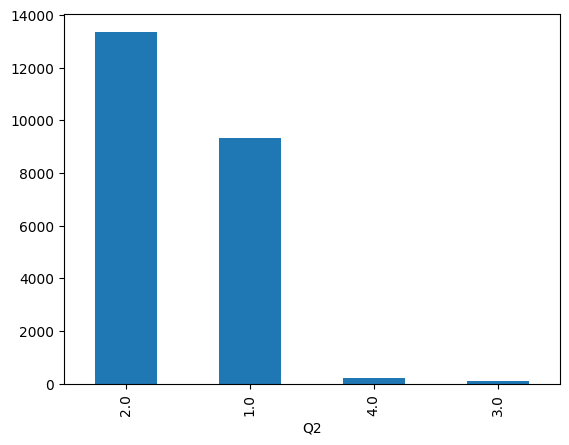

In [13]:
df['Q2'].value_counts().plot(kind='bar')  # Vẽ biểu đồ phân phối giới tính
# Show the plots
plt.show()

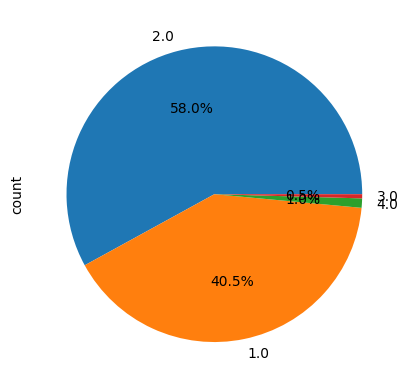

In [14]:
df['Q2'].value_counts().plot(kind='pie', autopct='%1.1f%%')  # Vẽ biểu đồ tròn phân phối giới tính
# Show the pie chart
plt.show()